# Section 1 - Modeling of the Amplitude of FFT of GW simulation signals obtained from Numerical Relativity

We have divided this notebook into different parts which deal the various sections of the Neural networks models used in the thesis. 

Common protocol which is followed in all the parts. Each part has the path of the three directories.  
main_dir_part_1: Directory from which the dataset is imported and used in this file.  
data_dir_part_1: Directory in which the dataset is saved.  
graph_dir_part_1: Directory in which the graphs are saved.  

##### Importing the necessary libraries

In [3]:
# Importing the normal libraries 
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import sys 
import os
import h5py
from scipy.optimize import curve_fit
import seaborn as sns
from numpy.fft import rfft, rfftfreq
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Importing the necessary libraries for the data processing
import sxs
import pywt 
import scipy 
import ast
import pickle
from scipy.interpolate import interp1d

# Importing the necessary libraries for the ML models
import sklearn 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


# Importing the TensorFlow libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.neural_network import MLPClassifier
from tensorflow.keras.metrics import Accuracy
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError


# Importing the necessary libraries for the plotting
# sys.path.append("/home/darsh/Masters")
# from gw import GWDataHandler, EventDetails, NRProcessor

# Assigning the necessary instructions for the plotting
plt.rcParams.update({
    'font.size': 16,
    'text.usetex': True,
    'axes.titlesize': 'large',  # Title size
    'axes.titleweight': 'bold',  
    'axes.labelsize': 'LARGE',  
    'axes.labelweight': 'bold',  
    'xtick.labelsize': 'medium',  
    'ytick.labelsize': 'medium',  
    'text.latex.preamble': r'\boldmath',
})
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.minor.width'] = 1
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['lines.markerfacecolor'] = 'none'

# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

Run the code below if you want to run the QML models and other important results about quantum computing. Avoid running it unnecessarily as it may cause unnecessary usage of the memory in the computer

In [15]:
from qiskit import *
import qiskit 

from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, EfficientSU2
from IPython.display import clear_output
from qiskit.circuit import Parameter
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap, ZFeatureMap
from qiskit_machine_learning.optimizers import COBYLA, L_BFGS_B
from qiskit_machine_learning.utils import algorithm_globals

from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier, VQC
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.circuit.library import QNNCircuit

import qiskit_aer
import torch
import torch.nn as nn
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_ibm_runtime import EstimatorV2
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import QiskitRuntimeService

## Part 1 - Data Importing and Generation 

We import the data from Numerical ralativity simulations performed by the Spacetime eXtreme Simulations (SXS) waveform catalog.

#### Importing and Loading the Dataset of the waveforms and the corresponding FFTs 

##### Assigning the paths for this dataset

In [16]:
# Choose your main folder name
folder_name = "model_fft"

# Get the current working directory
current_path = os.getcwd()
print("Current Path:", current_path)


# Define paths
folder_dir = os.path.join(current_path, folder_name)
data_dir = os.path.join(folder_dir, "dataset")
graph_dir = os.path.join(folder_dir, "graph")

# Check and create directories only if they don't exist
if not os.path.exists(folder_dir):
    os.makedirs(data_dir)
    os.makedirs(graph_dir)
    print("Directories created.")
else:
    print("Directories already exist. Nothing done.")

# Optional: print the paths for later use
print("Folder Path:", folder_dir)
print("Data Path:", data_dir)
print("Graph Path:", graph_dir)


Current Path: /mnt/d/Darsh/MSThesis/Final Code MS
Directories already exist. Nothing done.
Folder Path: /mnt/d/Darsh/MSThesis/Final Code MS/model_fft
Data Path: /mnt/d/Darsh/MSThesis/Final Code MS/model_fft/dataset
Graph Path: /mnt/d/Darsh/MSThesis/Final Code MS/model_fft/graph


##### Importing the Dataset about the physical properties/ Binary properties of the NR signal 
This dataset provides the infromation about the physical properties of the system. And is imported from the SXS waveform catalog. Their information is in reference to name of the waveforms. 

In [17]:
# Loading the simulations
simulations = sxs.load("simulations") # Load the catalog
df = simulations.dataframe  # Get the catalog as a DataFrame

# Removing the deprecated simulations
df = df[df["deprecated"]==False] # Get only the non-deprecated simulations

# Segregating the simulations based on the object types
df_BBH = df[df["object_types"]=="BHBH"] # Get only the BHBH simulations
df_BHNS = df[df["object_types"]=="BHNS"] # Get only the BHNS simulations
df_BNS = df[df["object_types"]=="NSNS"] # Get only the NSNS simulations

# Printing the simulation table for BBH
df_BBH

,deprecated,reference_time,reference_mass_ratio,reference_dimensionless_spin1,reference_dimensionless_spin1_mag,reference_dimensionless_spin2,reference_dimensionless_spin2_mag,reference_chi_eff,reference_chi1_perp,reference_chi2_perp,...,initial_position1,initial_position2,number_of_orbits,superseded_by,DOI_versions,keywords,date_link_earliest,date_run_earliest,date_run_latest,date_postprocessing
SXS:BBH:0058,False,160.0,5.001854,"[0.498409311654, 0.0270550583834, 0.0001050426...",4.991431e-01,"[2.01937971804e-09, -4.15644499623e-09, 3.2710...",3.271396e-07,1.588936e-03,4.991395e-01,4.097569e-09,...,"[2.4847843280914232, 0.0147621909749206, 0.0]","[-12.515215671908576, 0.0147621909749206, 0.0]",28.990668,NaN,"[, v1.1, v1.2, v1.3, v1.4, v1.5, v2.0]","[Precessing-Spins, ManyMergers-QuasiCircular]",2012-09-11 04:58:49+00:00,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2019-03-30 13:41:50+00:00
SXS:BBH:0059,False,190.0,5.000300,"[0.265321123923, -0.0963302558354, -0.15743783...",3.232050e-01,"[5.72038421045e-06, -8.01721814889e-06, 2.4361...",2.627728e-05,-1.336259e-01,2.806207e-01,9.260503e-06,...,"[1.577571745885004, 0.0232626259450057, 0.0]","[-7.922428254114996, 0.0232626259450057, 0.0]",6.904254,NaN,"[, v1.1, v1.2, v1.3, v1.4, v1.5, v2.0]","[Precessing-Spins, ManyMergers-QuasiCircular]",2012-09-11 04:58:49+00:00,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2019-03-30 13:41:50+00:00
SXS:BBH:0060,False,190.0,5.002173,"[-3.09188907142e-12, 4.42828977067e-12, -0.499...",4.995487e-01,"[-3.7061935564e-12, -2.21294870676e-12, 3.7512...",3.751224e-07,-4.163207e-01,9.447032e-12,4.316599e-12,...,"[2.4897672641887088, 0.0170122182493815, 0.0]","[-12.510232735811291, 0.0170122182493815, 0.0]",23.170828,NaN,"[, v1.1, v1.2, v1.3, v1.4, v1.5, v2.0]","[Aligned-Spins, ManyMergers-QuasiCircular]",2012-09-11 04:58:49+00:00,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2019-03-30 13:41:50+00:00
SXS:BBH:0065,False,210.0,8.003451,"[-8.7267498797e-11, -2.16428271052e-11, 0.499554]",4.995540e-01,"[1.71055553385e-10, 1.30641878196e-10, 4.07923...",4.079231e-07,4.440693e-01,4.417503e-10,2.152380e-10,...,"[1.42914774752272, 0.0112534630589437, 0.0]","[-11.57085225247728, 0.0112534630589437, 0.0]",33.973513,NaN,"[, v1.1, v1.2, v1.3, v1.4, v1.5, v2.0]","[Aligned-Spins, ManyMergers-QuasiCircular]",2013-03-06 21:55:55+00:00,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2019-03-30 13:41:50+00:00
SXS:BBH:0069,False,310.0,1.000000,"[6.92016331203e-10, -6.20671186466e-10, 1.1886...",1.188695e-07,"[7.38329816167e-10, 1.4177724812e-09, 1.204419...",1.204525e-07,1.196539e-07,9.295802e-10,1.598502e-09,...,"[9.050000046443222, 1.0560196e-08, 0.0]","[-9.04999995355678, 1.0560196e-08, 0.0]",30.067588,NaN,"[, v1.1, v1.2, v1.3, v1.4, v1.5, v2.0]","[Non-Spinning, ManyMergers-Eccentric]",2012-08-07 19:02:51+00:00,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2019-03-30 13:41:50+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SXS:BBH:3980,False,640.0,1.052863,"[3.19244133194e-08, 2.17242923032e-08, 0.69390...",6.939092e-01,"[-4.3580786423e-08, -1.63032988177e-08, 0.4107...",4.107661e-01,5.559832e-01,4.266801e-08,4.369319e-08,...,"[7.736029325091786, 0.0030926560572032, -7.000...","[-8.161675753008215, 0.0030926560572032, -7.00...",24.214623,NaN,"[, v2.0]",[],2018-01-25 00:47:01+00:00,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2019-05-10 02:46:53+00:00
SXS:BBH:3981,False,640.0,2.000110,"[-9.67247448754e-08, 1.17021874225e-07, -0.120...",1.204191e-01,"[1.05091258767e-08, -1.44856781641e-08, -0.654...",6.546750e-01,-2.984978e-01,1.657008e-07,8.915915e-08,...,"[5.572030131576672, 0.0196587359945945, -1.657...","[-11.14513295432333, 0.0196587359945945, -1.65...",23.115785,NaN,"[, v2.0]",[],2018-01-25 00:47:01+00:00,1970-01-01 00:00:00+00:00,1970-01-01 00:00:00+00:00,2019-05-10 02:46:53+00:00
SXS:BBH:3982,False,640.0,0.999956,"[3.92852680713e-08, 1.88812757639e-08, -0.1796...",1.796808e-01,"[

##### Important columns in the NR signal 

In [18]:
col_names = df_BBH.columns.to_numpy()
col_names
imp_cols = np.array([col_names[1], col_names[2], 
                     col_names[3], col_names[4], col_names[5], 
                     col_names[6], col_names[7], col_names[8], 
                     col_names[9], col_names[10], col_names[11], 
                     col_names[12], col_names[13], col_names[14], 
                     col_names[15], col_names[16], col_names[17], 
                     col_names[18], col_names[19], col_names[20], 
                     col_names[21], col_names[22], col_names[23], 
                     col_names[24], col_names[25], col_names[26], 
                     col_names[27], col_names[28]])
print(imp_cols)

['reference_time' 'reference_mass_ratio' 'reference_dimensionless_spin1'
 'reference_dimensionless_spin1_mag' 'reference_dimensionless_spin2'
 'reference_dimensionless_spin2_mag' 'reference_chi_eff'
 'reference_chi1_perp' 'reference_chi2_perp' 'reference_eccentricity'
 'reference_eccentricity_bound' 'reference_mean_anomaly'
 'reference_orbital_frequency' 'reference_orbital_frequency_mag'
 'reference_separation' 'reference_position1' 'reference_position2'
 'reference_mass1' 'reference_mass2' 'reference_chi1_mag'
 'reference_chi2_mag' 'relaxation_time' 'common_horizon_time'
 'remnant_mass' 'remnant_dimensionless_spin'
 'remnant_dimensionless_spin_mag' 'remnant_velocity'
 'remnant_velocity_mag']


##### Saving the above dataset with the important cols and also creating the array of the reference time 

In [19]:
df_final = df_BBH[imp_cols]

# Code to save the dataframe to a csv file
name_file = "bbh.csv"
csv_file_path = os.path.join(data_dir, name_file) # Replace with your desired file path 
df_final.to_csv(csv_file_path, index=True)

# Extracting the reference time of each simulation
ref_time = df_final["reference_time"].to_numpy()

print("The array of the reference time:", ref_time)
print(f"The shape of the reference index is {len(ref_time)}")

The array of the reference time: [160. 190. 190. ... 640. 640. 340.]
The shape of the reference index is 2476


##### Importing the names of the waveforms and downloading the dataset if not present in the computer

In [20]:
base_dir = sxs.sxs_directory("cache")

index = df_BBH.index.to_numpy()

new_index = [name.replace(":", "_") for name in index]
print(f"The shape of the index is {len(new_index)}")
print("The new index is:", new_index)

# Function to check if a folder exists and download if it doesn't
def check_and_download(simulation_id):
    folder_path = os.path.join(base_dir, simulation_id+"v2.0")
    if not os.path.exists(folder_path):
        print(f"Folder {simulation_id} not found. Downloading...")
        sxs.load(simulation_id, download=True)
    else:
        print(f"Folder {simulation_id} already exists. Skipping...")

# Check each simulation and download if the folder doesn't exist
for i in df_BBH.index:
    check_and_download(i)

print("All checks completed.")

The shape of the index is 2476
The new index is: ['SXS_BBH_0058', 'SXS_BBH_0059', 'SXS_BBH_0060', 'SXS_BBH_0065', 'SXS_BBH_0069', 'SXS_BBH_0074', 'SXS_BBH_0078', 'SXS_BBH_0082', 'SXS_BBH_0083', 'SXS_BBH_0087', 'SXS_BBH_0088', 'SXS_BBH_0089', 'SXS_BBH_0091', 'SXS_BBH_0092', 'SXS_BBH_0094', 'SXS_BBH_0097', 'SXS_BBH_0098', 'SXS_BBH_0100', 'SXS_BBH_0105', 'SXS_BBH_0106', 'SXS_BBH_0108', 'SXS_BBH_0109', 'SXS_BBH_0111', 'SXS_BBH_0114', 'SXS_BBH_0147', 'SXS_BBH_0160', 'SXS_BBH_0161', 'SXS_BBH_0163', 'SXS_BBH_0164', 'SXS_BBH_0165', 'SXS_BBH_0170', 'SXS_BBH_0171', 'SXS_BBH_0172', 'SXS_BBH_0175', 'SXS_BBH_0176', 'SXS_BBH_0177', 'SXS_BBH_0178', 'SXS_BBH_0179', 'SXS_BBH_0185', 'SXS_BBH_0186', 'SXS_BBH_0188', 'SXS_BBH_0189', 'SXS_BBH_0192', 'SXS_BBH_0194', 'SXS_BBH_0195', 'SXS_BBH_0196', 'SXS_BBH_0198', 'SXS_BBH_0199', 'SXS_BBH_0200', 'SXS_BBH_0201', 'SXS_BBH_0202', 'SXS_BBH_0203', 'SXS_BBH_0204', 'SXS_BBH_0205', 'SXS_BBH_0206', 'SXS_BBH_0207', 'SXS_BBH_0208', 'SXS_BBH_0259', 'SXS_BBH_0292', 'SXS_B

Folder SXS:BBH:1460 already exists. Skipping...
Folder SXS:BBH:1461 already exists. Skipping...
Folder SXS:BBH:1462 already exists. Skipping...
Folder SXS:BBH:1463 already exists. Skipping...
Folder SXS:BBH:1464 already exists. Skipping...
Folder SXS:BBH:1465 already exists. Skipping...
Folder SXS:BBH:1466 already exists. Skipping...
Folder SXS:BBH:1467 already exists. Skipping...
Folder SXS:BBH:1468 already exists. Skipping...
Folder SXS:BBH:1469 already exists. Skipping...
Folder SXS:BBH:1470 already exists. Skipping...
Folder SXS:BBH:1471 already exists. Skipping...
Folder SXS:BBH:1472 already exists. Skipping...
Folder SXS:BBH:1473 already exists. Skipping...
Folder SXS:BBH:1474 already exists. Skipping...
Folder SXS:BBH:1475 already exists. Skipping...
Folder SXS:BBH:1476 already exists. Skipping...
Folder SXS:BBH:1477 already exists. Skipping...
Folder SXS:BBH:1478 already exists. Skipping...
Folder SXS:BBH:1479 already exists. Skipping...
Folder SXS:BBH:1480 already exists. Skip

##### Loading of the NR sample signal (To demonstrate how to extract the signal and plot it)

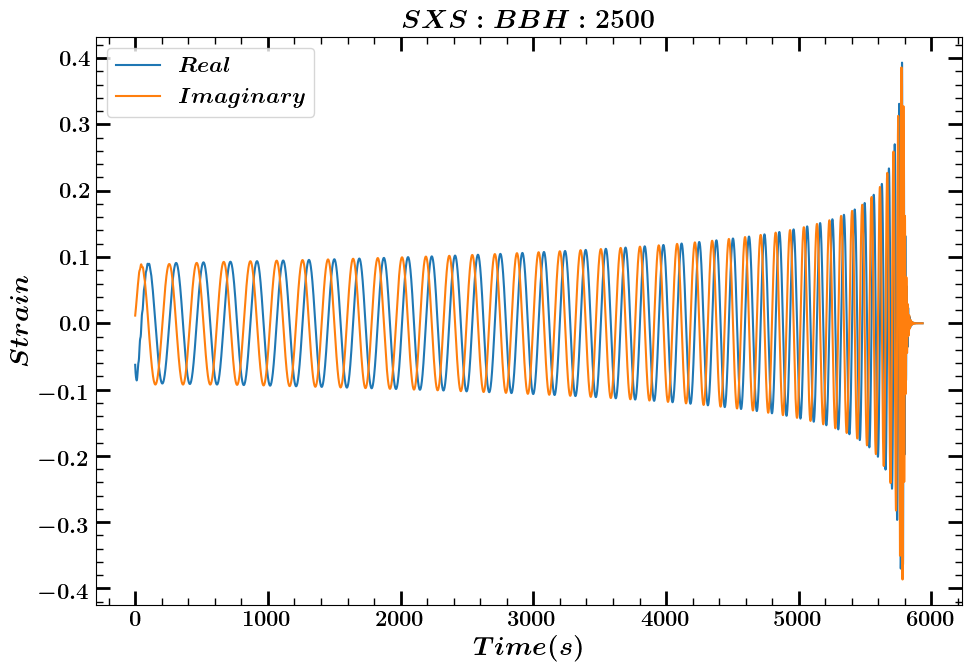

In [42]:
# Ask user to enter the full path to the "Raw" folder
data_dir_raw = input("Enter the full path to the 'Raw' folder (e.g., /home/user/data/Raw): ").strip()

# Build the full file path to the HDF5 file
file_name = "SXS_BBH_2500.h5"
file_path = os.path.join(data_dir_raw, file_name)

# Check if file exists
if not os.path.isfile(file_path):
    raise FileNotFoundError(f"The file {file_path} was not found. Please check the path and filename.")

# Open and read HDF5 file
with h5py.File(file_path, 'r') as f:
    time = f['time'][:]
    real = f['real'][:]
    imag = f['imag'][:]

# Plotting
plt.figure(figsize=(10, 7))
plt.plot(time, real, label=r'$Real$')  
plt.plot(time, imag, label=r'$Imaginary$')
plt.xlabel(r'$Time (s)$')
plt.ylabel(r'$Strain$')
plt.title(r"$SXS:BBH:2500$")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


### Preprocessing of the Numerical Relativity Signals

##### Important functions about the preprocessing of the NR signal

Preprocessing of the NR signal - 
1. Extract Mode - We extract the dominant (2, 2) mode from the database and download it in our computer. 
2. Crop to reference - We crop the dataset until the reference time to remove the spurious signal. 
3. Scaling the time scale by total masses of the system - From 40 M to 95 M. We scale the dataset. 
4. Interpolate Data - Time is not noted at equal interval of time. Hence, it is interpolated. 
5. Taper the data - Taper the data to lower the amplitude to zero from the ends. 
6. Padding - Padded the data from both the sides. 

In [43]:
class NRProcessor:
    def __init__(self, name, total_mass, fs=4096, taper=True, taper_both=False, pad=False, pad_length=None):
        """Initializes waveform processor with parameters."""
        self.name = name
        self.total_mass = total_mass
        self.fs = fs
        self.taper = taper
        self.taper_both = taper_both
        self.pad = pad
        self.pad_length = pad_length

    def extract_mode(self, mode=(2, 2), download=True):
        """Loads waveform and extracts the specified mode."""
        sim = sxs.load(self.name, download=download).h
        h_sim = sim[:, sim.index(*mode)]
        return sim, h_sim

    def crop_to_reference(self, h_sim):
        """Crops waveform from the reference time onward."""
        ref_time = sxs.load(self.name).metadata.reference_time
        ref_index = h_sim.index_closest_to(ref_time)
        h_sim = h_sim[ref_index:]
        hplus = np.array(h_sim.real)
        hcross = np.array(h_sim.imag)
        t_sim = np.array(h_sim.t) - h_sim.t[0]
        return hplus, hcross, t_sim

    def scale_time(self, t_sim):
        """Scales the time domain using the total mass factor."""
        scale = 4.92e-6 * self.total_mass
        t_scaled = t_sim * scale
        return t_scaled

    def interpolate_data(self, t_scaled, hplus, hcross):
        """Interpolates the data to match the target sampling frequency."""
        time_span = t_scaled[-1] - t_scaled[0]
        time = np.linspace(t_scaled[0], t_scaled[-1], int(time_span * self.fs))
        interp_plus = interp1d(t_scaled, hplus, kind="linear")
        interp_cross = interp1d(t_scaled, hcross, kind="linear")
        h_eqspace_plus = interp_plus(time)
        h_eqspace_cross = interp_cross(time)
        return h_eqspace_plus, h_eqspace_cross, time

    def taper_data(self, h_eqspace, alpha=0.1, taper_both=False):
        """Tapers the waveform using a Tukey window."""
        if taper_both:
            # Full Tukey window for the entire waveform
            taper_window = scipy.signal.windows.tukey(len(h_eqspace), alpha)
            h_tapered = h_eqspace * taper_window
        else:
            # Tukey window applied only to the first half of the waveform
            idx = len(h_eqspace) // 2
            taper_window = scipy.signal.windows.tukey(len(h_eqspace), alpha)[:idx]
            htap = h_eqspace[:idx] * taper_window
            h_tapered = np.concatenate((htap, h_eqspace[idx:]))
        return h_tapered

    def preprocess(self):
        """Main function to preprocess the NR waveform, with options for tapering and padding."""
        # Step 1: Load waveform and extract mode
        sim, h_sim = self.extract_mode()
        
        # Step 2: Crop waveform from reference time
        hplus, hcross, t_sim = self.crop_to_reference(h_sim)
        
        # Step 3: Scale time based on total mass
        t_scaled = self.scale_time(t_sim)
        
        # Step 4: Interpolate data to fixed sampling rate
        h_eqspace_plus, h_eqspace_cross, time = self.interpolate_data(t_scaled, hplus, hcross)
        
        # Step 5: Apply tapering if enabled
        if self.taper:
            h_eqspace_plus = self.taper_data(h_eqspace_plus, taper_both=self.taper_both)
            h_eqspace_cross = self.taper_data(h_eqspace_cross, taper_both=self.taper_both)
        
        # Step 6: Apply padding if enabled
        if self.pad:
            if self.pad_length is None:
                raise ValueError("pad_length must be provided when pad is True.")
            
            current_len = len(h_eqspace_plus)

            if self.pad_length > current_len:
                # Calculate left and right padding based on desired length
                left_pad = self.pad_length // 2
                right_pad = self.pad_length - current_len - left_pad

                # Apply asymmetric padding to the beginning of the waveform
                h_eqspace_plus = np.pad(h_eqspace_plus, (left_pad, right_pad), 'constant')
                h_eqspace_cross = np.pad(h_eqspace_cross, (left_pad, right_pad), 'constant')

                # Adjust the time array to match the padded waveform length
                extra_time_before = np.linspace(time[0] - left_pad / self.fs, time[0], left_pad, endpoint=False)
                extra_time_after = np.linspace(time[-1], time[-1] + right_pad / self.fs, right_pad)
                time = np.concatenate((extra_time_before, time, extra_time_after))

        return h_eqspace_plus, h_eqspace_cross, time

# processor = NRProcessor(name="SXS:BBH:0306", total_mass=30, fs=4096, taper=True, pad = False, pad_length = 4096*15)
# hp, hc, time = processor.preprocess()

# plt.plot(time, hp, label = "Plus polarization waveform")    
# plt.plot(time, hc, label = "Cross Polarization waveform")
# plt.legend()
# plt.show()

# Functions which we will use to preprocess the data of NR signal 
def crop_to_reference(plus, cross, time, ref_time):
    """Crops waveform from the reference time onward."""
    
    ref_index = np.argmin(np.abs(time) - ref_time)
    hplus = plus[ref_index:]
    hcross = cross[ref_index:]
    time = time[ref_index:] - time[ref_index]
    return hplus, hcross, time

def scale_time(time, total_mass):
    """Scales the time domain using the total mass factor."""
    scale = 4.92e-6 * total_mass
    t_scaled = time * scale
    return t_scaled

def interpolate_data(t_scaled, hplus, hcross, fs = 4096):
    """Interpolates the data to match the target sampling frequency."""
    time_span = t_scaled[-1] - t_scaled[0]
    time = np.linspace(t_scaled[0], t_scaled[-1], int(time_span * fs))
    interp_plus = interp1d(t_scaled, hplus, kind="linear")
    interp_cross = interp1d(t_scaled, hcross, kind="linear")
    h_eqspace_plus = interp_plus(time)
    h_eqspace_cross = interp_cross(time)
    return h_eqspace_plus, h_eqspace_cross, time

def taper_data(h_eqspace, alpha=0.1, taper_both=False):
    """Tapers the waveform using a Tukey window."""
    if taper_both:
        # Full Tukey window for the entire waveform
        taper_window = scipy.signal.windows.tukey(len(h_eqspace), alpha)
        h_tapered = h_eqspace * taper_window
    else:
        # Tukey window applied only to the first half of the waveform
        idx = len(h_eqspace) // 2
        taper_window = scipy.signal.windows.tukey(len(h_eqspace), alpha)[:idx]
        htap = h_eqspace[:idx] * taper_window
        h_tapered = np.concatenate((htap, h_eqspace[idx:]))
    return h_tapered

##### Preprocessing the Dataset for a single total mass M = 60

CAUTION: DATA Generation code below. 
 
Please note that this code is given to check whether the dat is generated corrctly or not for just one total mass and different mass ratios

In [44]:
# # Ensure that both the sxs and preprocess directories exist
data_dir_wf = os.path.join(data_dir, "sxs")
data_dir_pp = os.path.join(data_dir_wf, "preprocess")

# Check if the 'sxs' directory exists, and create it if it doesn't
if not os.path.exists(data_dir_wf):
    os.makedirs(data_dir_wf)

# Check if the 'preprocess' directory exists, and create it if it doesn't
if not os.path.exists(data_dir_pp):
    os.makedirs(data_dir_pp)

print(f"Raw data directory: {data_dir_raw}")
print(f"Preprocessed data will be saved to: {data_dir_pp}")

# -------------------Run the below code only if you want to generate the data-------------------

# # Loop over each index in new_index
# for i in range(len(new_index)):
#     # Define the path to the raw file
#     file_path = os.path.join(data_dir_raw, f"{new_index[i]}.h5")
    
#     # Check if the file exists before attempting to read
#     if not os.path.isfile(file_path):
#         print(f"File {file_path} does not exist. Skipping...")
#         continue

#     # Load the data from the raw HDF5 file
#     with h5py.File(file_path, 'r') as f:
#         time = f['time'][:]
#         real = f['real'][:]
#         imag = f['imag'][:]

#     # Processing the data
#     ref_t = ref_time[i]
#     total_mass = 60
#     hplus, hcross, time = crop_to_reference(real, imag, time, ref_t)
#     t_scaled = scale_time(time, total_mass)
#     h_eqspace_plus, h_eqspace_cross, time = interpolate_data(t_scaled, hplus, hcross)
    
#     # Apply tapering
#     h_eqspace_plus = taper_data(h_eqspace_plus, alpha=0.1, taper_both=False)
#     h_eqspace_cross = taper_data(h_eqspace_cross, alpha=0.1, taper_both=False)

#     # Save the preprocessed data to a new HDF5 file in the preprocess folder
#     output_file = os.path.join(data_dir_pp, f"{new_index[i]}_pp.h5")
#     with h5py.File(output_file, 'w') as f:
#         f.create_dataset('time', data=time)
#         f.create_dataset('plus', data=h_eqspace_plus)
#         f.create_dataset('cross', data=h_eqspace_cross)

#     print(f"Saved preprocessed TimeSeries data to {output_file}")


Raw data directory: /mnt/d/Darsh/MSThesis/numerical_relativity/dataset/sxs/Raw
Preprocessed data will be saved to: /mnt/d/Darsh/MSThesis/Final Code MS/model_fft/dataset/sxs/preprocess


##### Preprocessing the dataset for all the masses and saving them 

CAUTION: DATA Generation Codes below 

The below code is the code which I used to generate the data on Darsh's computer. Do not use this code to generate the data on your computer. Rather use the below modified code which takes care of the path issue in my PC. 

In [45]:
##---------------------Old code which works on Darsh computer only -------------------##

# total_mass = np.arange(40, 121)

# for j in total_mass:
#     # os.mkdir(f'/mnt/d/Darsh/MSThesis/numerical_relativity/dataset/sxs/preprocess_{j}')
#     for i in range(len(new_index)):
#         with h5py.File(f'/mnt/d/Darsh/MSThesis/numerical_relativity/dataset/sxs/Raw/{new_index[i]}.h5', 'r') as f:
#             # Load the datasets
#             time = f['time'][:]
#             real = f['real'][:]
#             imag = f['imag'][:]
#         ref_t = ref_time[i]
#         tot_mass = j
#         hplus, hcross, time = crop_to_reference(real, imag, time, ref_t)
#         t_scaled = scale_time(time, tot_mass)
#         h_eqspace_plus, h_eqspace_cross, time = interpolate_data(t_scaled, hplus, hcross)
#         h_eqspace_plus = taper_data(h_eqspace_plus, alpha=0.1, taper_both=False)
#         h_eqspace_cross = taper_data(h_eqspace_cross, alpha=0.1, taper_both=False)

#         with h5py.File(f'/mnt/d/Darsh/MSThesis/numerical_relativity/dataset/sxs/preprocess_{j}/{new_index[i]}_pp.h5', 'w') as f:
#             f.create_dataset('time', data = time)
#             f.create_dataset('plus', data = h_eqspace_plus)
#             f.create_dataset('cross', data = h_eqspace_cross)
#         print(f"Saved preprocessed TimeSeries data to {new_index[i]}_pp.h5")

CAUTION : DATA Generation Codes below 

The below code generates the preprocessed waveforms for all the mass ratios and all the total masses. The code takes a good amount of time to run. Hence, be careful while running the code. 

In [46]:
# Assuming 'new_index' and 'ref_time' are predefined lists or arrays
# Total mass range (40 to 120)


## -------------------------------- New Code working on every computer -------------------------##
# total_mass = np.arange(40, 121)

# # Loop over each mass value in the total_mass range
# for j in total_mass:
#     # Ensure that the preprocess directory for the current total_mass exists
#     preprocess_dir = os.path.join(data_dir_wf, f"preprocess_{j}")
#     if not os.path.exists(preprocess_dir):
#         os.makedirs(preprocess_dir)  # Create directory if it does not exist

#     # Loop over each index in new_index
#     for i in range(len(new_index)):
#         # Define the path to the raw file
#         file_path = os.path.join(data_dir_raw, f"{new_index[i]}.h5")
        
#         # Check if the raw file exists before processing
#         if not os.path.isfile(file_path):
#             print(f"File {file_path} does not exist. Skipping...")
#             continue

#         # Load the raw data
#         with h5py.File(file_path, 'r') as f:
#             time = f['time'][:]
#             real = f['real'][:]
#             imag = f['imag'][:]

#         # Reference time and total mass for this iteration
#         ref_t = ref_time[i]
#         tot_mass = j

#         # Data processing steps
#         hplus, hcross, time = crop_to_reference(real, imag, time, ref_t)
#         t_scaled = scale_time(time, tot_mass)
#         h_eqspace_plus, h_eqspace_cross, time = interpolate_data(t_scaled, hplus, hcross)

#         # Apply tapering to the data
#         h_eqspace_plus = taper_data(h_eqspace_plus, alpha=0.1, taper_both=False)
#         h_eqspace_cross = taper_data(h_eqspace_cross, alpha=0.1, taper_both=False)

#         # Save the preprocessed data to the appropriate file
#         output_file = os.path.join(preprocess_dir, f"{new_index[i]}_pp.h5")
#         with h5py.File(output_file, 'w') as f:
#             f.create_dataset('time', data=time)
#             f.create_dataset('plus', data=h_eqspace_plus)
#             f.create_dataset('cross', data=h_eqspace_cross)

#         print(f"Saved preprocessed TimeSeries data to {output_file}")


##### Defining a function which plots all the plots for visulaizing the preprocessing of NR signal 

The below code plots the preprocessing steps of NR signal for given inputs as  

name - Name of NR signal  
total_mass - Total mass of the system 
file_path - Path to save the figure plotted 
fs - Sampling Frequency  
taper_both - Asks if we need to taper both the sides or not (if False, tapers from left side only) 
pad - Asks if we need to apply padding to the signal to make the length of all the signals same.  
pad_length - If pad is True, pad_length requires the length upto which the padding of the NR signal should be done.  

In [47]:
def pp(name, total_mass, file_path, fs=4096, taper_both=False, pad=True, pad_length=8*4096):
    """Function to preprocess the NR waveform without gravitational wave memory effect and which plots the curves
    at each step to verify the steps clearly.
    
    Parameters:
    name(type - str): name of the Numerical relativity waveform
    total_mass(type - int): total mass of the system
    fs : sampling frequency required at which the waveform should be present.

    Returns:
    hp_taper - Tapered strain data for plus polarization waveform
    hc_taper - Tapered strain data for cross polarization waveform
    time - Time Domain of both the waveforms
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import sxs
    import scipy.signal
    from scipy.interpolate import interp1d
    
    # Loading the waveform
    sim = sxs.load(name).h
    h_sim = sim[:, sim.index(2, 2)] 

    # Cropping till reference time 
    ref_time = sim.metadata.reference_time
    ref_index = h_sim.index_closest_to(ref_time)

    # Cropping waveform
    h_sim = h_sim[ref_index:]
    hplus = np.array(h_sim.real)
    hcross = np.array(h_sim.imag)
    t_sim = np.array(h_sim.t)
    t_sim = t_sim - t_sim[0]

    # Scaling the time domain
    scale = 4.29e-6 * total_mass
    t_scaled = t_sim * scale
    time_span = t_scaled[-1] - t_scaled[0]

    # Interpolating the data points 
    time_eq = np.linspace(t_scaled[0], t_scaled[-1], int(time_span * fs))
    linear_interp_plus = interp1d(t_scaled, hplus, kind="linear")
    linear_interp_cross = interp1d(t_scaled, hcross, kind="linear")
    h_eqspace_plus = linear_interp_plus(time_eq)
    h_eqspace_cross = linear_interp_cross(time_eq)

    # Tapering the data
    twindow_plus = scipy.signal.windows.tukey(len(h_eqspace_plus), alpha=0.10)
    twindow_cross = scipy.signal.windows.tukey(len(h_eqspace_cross), alpha=0.10)
    
    if taper_both:
        hp_taper = h_eqspace_plus * twindow_plus
        hc_taper = h_eqspace_cross * twindow_cross
    else:
        idx_plus = len(h_eqspace_plus) // 2
        idx_cross = len(h_eqspace_cross) // 2
        twindow_plus = twindow_plus[:idx_plus]
        twindow_cross = twindow_cross[:idx_cross]
        htap_plus = h_eqspace_plus[:idx_plus] * twindow_plus
        hp_taper = np.concatenate((htap_plus, h_eqspace_plus[idx_plus:]))
        htap_cross = h_eqspace_cross[:idx_cross] * twindow_cross
        hc_taper = np.concatenate((htap_cross, h_eqspace_cross[idx_cross:]))
    
    # Padding if needed
    if pad:
        if pad_length is None:
            raise ValueError("pad_length must be provided when pad is True.")
        current_len = len(hp_taper)
        if pad_length > current_len:
            pad_half = pad_length // 2  
            left_pad = pad_half
            right_pad = pad_length - current_len - left_pad
            hp_taper_pad = np.pad(hp_taper, (left_pad, right_pad), 'constant')
            hc_taper_pad = np.pad(hc_taper, (left_pad, right_pad), 'constant')
            extra_time_before = np.linspace(time_eq[0] - left_pad / fs, time_eq[0], left_pad, endpoint=False)
            extra_time_after = np.linspace(time_eq[-1], time_eq[-1] + right_pad / fs, right_pad)
            time = np.concatenate((extra_time_before, time_eq, extra_time_after))

    # Plot all figures in one
    fig, axs = plt.subplots(3, 2, figsize=(14, 12), sharey=True)
    
    axs[0, 0].plot(h_sim.t, h_sim.real, label=r"$Raw$")
    axs[0, 0].axvline(x=ref_index, ls="--", label=r"$Reference\ Time$")
    axs[0, 0].set_xlabel(r"$Time\ (t/M_{\odot})$")
    axs[0, 0].set_ylabel(r"$Amplitude$")
    axs[0, 0].legend()
    axs[0, 0].grid(False)
    axs[0, 0].text(0.5, 0.9, r"\textbf{\LARGE (i)}", transform=axs[0, 0].transAxes, fontsize=14, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    axs[0, 1].plot(t_sim, hplus, label=r"$Cropped$")
    axs[0, 1].set_xlabel(r"$Time\ (t/M_{\odot})$")
    axs[0, 1].legend()
    axs[0, 1].grid(False)
    axs[0, 1].text(0.5, 0.9, r"\textbf{\LARGE (ii)}", transform=axs[0, 1].transAxes, fontsize=14, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    axs[1, 0].plot(t_scaled, hplus, label=r"$Scaled$")
    axs[1, 0].set_xlabel(r"$Time\ (s)$")
    axs[1, 0].set_ylabel(r"$Amplitude$")
    axs[1, 0].legend()
    axs[1, 0].grid(False)
    axs[1, 0].text(0.5, 0.9, r"\textbf{\LARGE (iii)}", transform=axs[1, 0].transAxes, fontsize=14, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    axs[1, 1].plot(time_eq, h_eqspace_plus, label=r"$Interpolated$")
    axs[1, 1].set_xlabel(r"$Time\ (s)$")
    axs[1, 1].legend()
    axs[1, 1].grid(False)
    axs[1, 1].text(0.5, 0.9, r"\textbf{\LARGE (iv)}", transform=axs[1, 1].transAxes, fontsize=14, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    axs[2, 0].plot(time_eq, hp_taper, label=r"$Tapered$")
    axs[2, 0].set_xlabel(r"$Time\ (s)$")
    axs[2, 0].set_ylabel(r"$Amplitude$")
    axs[2, 0].legend()
    axs[2, 0].grid(False)
    axs[2, 0].text(0.5, 0.9, r"\textbf{\LARGE (v)}", transform=axs[2, 0].transAxes, fontsize=14, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    axs[2, 1].plot(time, hp_taper_pad, label=r"$Padded$")
    axs[2, 1].set_xlabel(r"$Time\ (s)$")
    axs[2, 1].legend()
    axs[2, 1].grid(False)
    axs[2, 1].text(0.5, 0.9, r"\textbf{\LARGE (vi)}", transform=axs[2, 1].transAxes, fontsize=14, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    plt.tight_layout()
    # plt.savefig(os.path.join(file_path, f"{name}_pp_steps.pdf"))
    # plt.savefig(os.path.join(file_path, f"{name}_pp_steps.png"))
    plt.show()
    
    return hp_taper, hc_taper, time

##### Visualizing the preprocessing steps of the NR signal for some of the signals-  

SXS:BBH:0305

THESIS: Figure 2.1

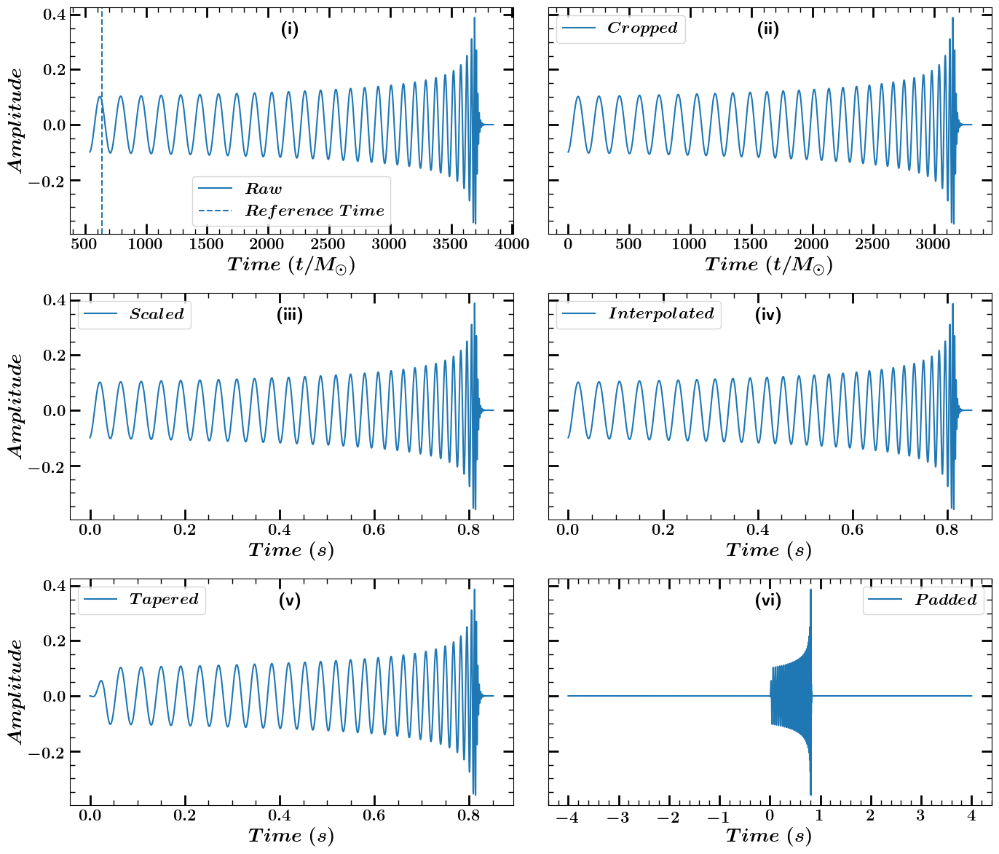

In [48]:
graph_dir_wf = os.path.join(graph_dir, "sxs")
if not os.path.exists(graph_dir_wf):
    os.makedirs(graph_dir_wf)

graph_dir_pp = os.path.join(graph_dir_wf, "preprocess")
if not os.path.exists(graph_dir_pp):
    os.makedirs(graph_dir_pp)


wf_p, wf_c, time = pp("SXS:BBH:0305", 
                      file_path = graph_dir_pp,
                      total_mass = 60, 
                      fs = 4096)

SXS:NSBH:0009

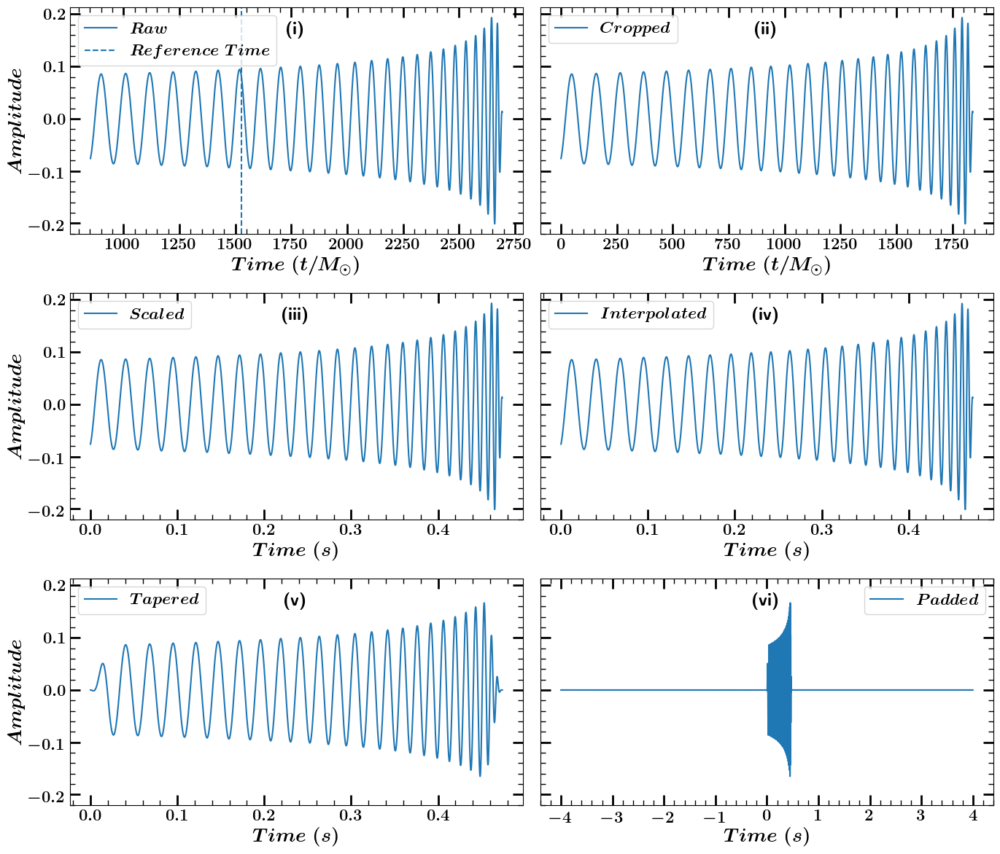

In [49]:
wf_p1, wf_c1, time1 = pp("SXS:BHNS:0009", 
                      file_path = graph_dir_pp,
                      total_mass = 60, 
                      fs = 4096, taper_both = True, pad= True, pad_length = 8*4096)

SXS:BNS:0001

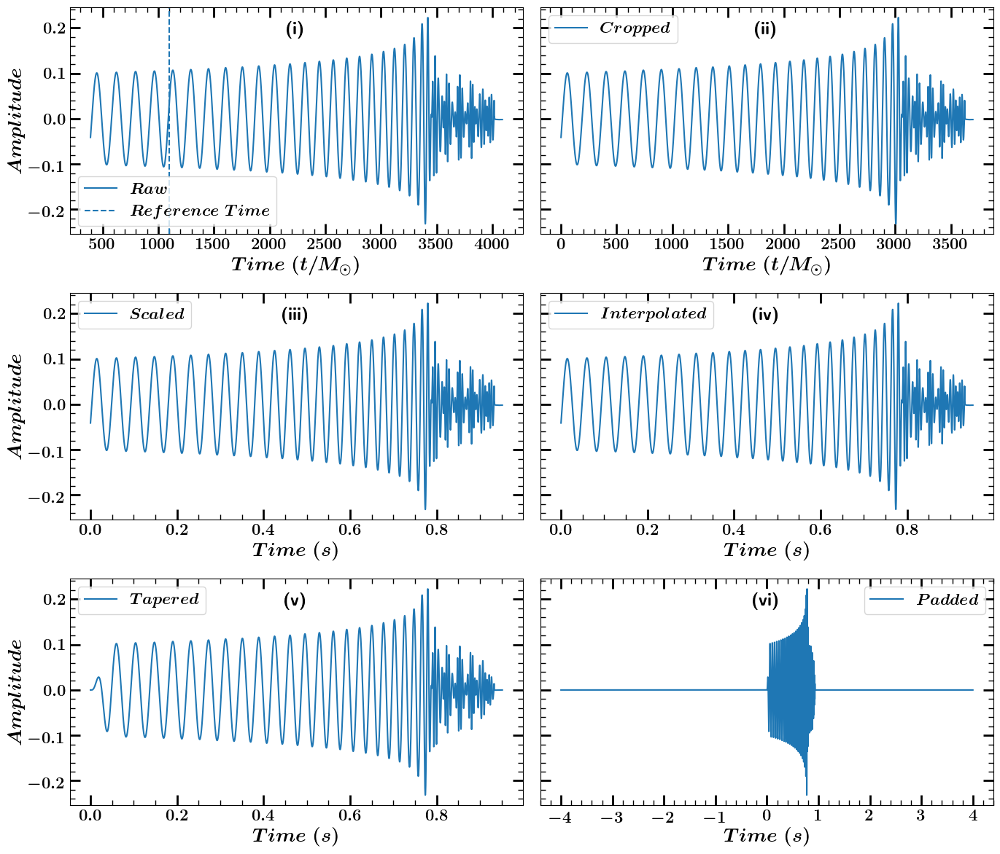

In [50]:
wf_p2, wf_c2, time2 = pp("SXS:NSNS:0001", 
                      file_path = graph_dir_pp,
                      total_mass = 60, 
                      fs = 4096, taper_both = True, pad= True, pad_length = 8*4096)

### Computing the FFT and Saving it in the Dataset

##### Computing FFT for all the preprocessed waveforms in each and every directory

CAUTION: DATA Generation code below. 

Please note that this code calculates the fft for single total mass with different mass ratios and is mentioned here because of the demo purposes to check whether the generation of data is correct or not. 

In [51]:
def compute_fft(signal, fs):
    """Function to compute the FFT of the waveform."""
    fft = np.fft.rfft(signal)
    # Compute the frequency domain
    freq = np.fft.rfftfreq(len(signal), 1/fs)
    return freq, fft

# print(data_dir_pp)

data_dir_fft = os.path.join(data_dir_wf, "fft")
if not os.path.exists(data_dir_fft):
    os.makedirs(data_dir_fft)

# for i in range(len(new_index)):
#         with h5py.File(data_dir_pp + f'/{new_index[i]}_pp.h5', 'r') as f:
#                 time = f['time'][:]
#                 plus = f['plus'][:]
#                 cross = f['cross'][:]
#         fs = 4096
#         freq_p, fft_plus = compute_fft(plus, fs)
#         freq_c, fft_cross = compute_fft(cross, fs)
#         with h5py.File(data_dir_fft + f'/{new_index[i]}_fft.h5', 'w') as f:
#             f.create_dataset('freq_p', data = freq_p)
#             f.create_dataset('fft_p', data = fft_plus)
#             f.create_dataset('freq_c', data = freq_c)
#             f.create_dataset('fft_c', data = fft_cross)

##### Computing the FFT for all the waveforms with all the total masses M = 40 - 121

CAUTION: DATA Generation Code below. DO NOT RUN THE CODE BELOW (It is meant to be run on Darsh's Computer. Given for reference and completion purpose. In case the below new code does not work. Please kindly refer to this code for the debugging purposes.)

This generates the dataset for all the waveforms having different mass ratios and different total mass ranging from 40 - 121.

In [52]:
# for j in total_mass:
#     # os.mkdir(f'/mnt/d/Darsh/MSThesis/numerical_relativity/dataset/sxs/fft_{j}')
#     for i in range(len(new_index)):
#             with h5py.File(f'/mnt/d/Darsh/MSThesis/numerical_relativity/dataset/sxs/preprocess_{j}/{new_index[i]}_pp.h5', 'r') as f:
#                     time = f['time'][:]
#                     plus = f['plus'][:]
#                     cross = f['cross'][:]
#             fs = 4096
#             freq_p, fft_plus = compute_fft(plus, fs)
#             freq_c, fft_cross = compute_fft(cross, fs)
#             with h5py.File(f'/mnt/d/Darsh/MSThesis/numerical_relativity/dataset/sxs/fft_{j}/{new_index[i]}_fft.h5', 'w') as f:
#                 f.create_dataset('freq_p', data = freq_p)
#                 f.create_dataset('fft_p', data = fft_plus)
#                 f.create_dataset('freq_c', data = freq_c)
#                 f.create_dataset('fft_c', data = fft_cross)

CAUTION: DATA Generation Code below. NEW Code for the data generation

This generates the dataset for all the waveforms having different mass ratios and different total mass ranging from 40 - 121.

In [53]:
# # Constants
# fs = 4096  # Sampling frequency
# total_mass = np.arange(40, 121)  # Total mass range (inclusive)

# # Loop over total mass values
# for j in total_mass:
#     preprocess_dir = os.path.join(data_dir_wf, f"preprocess_{j}")
#     fft_dir = os.path.join(data_dir_wf, f"fft_{j}")
    
#     # Ensure output FFT directory exists
#     if not os.path.exists(fft_dir):
#         os.makedirs(fft_dir)

#     for i in range(len(new_index)):
#         preprocess_file = os.path.join(preprocess_dir, f"{new_index[i]}_pp.h5")
#         fft_file = os.path.join(fft_dir, f"{new_index[i]}_fft.h5")

#         # Check if preprocessed file exists
#         if not os.path.isfile(preprocess_file):
#             print(f"Preprocessed file {preprocess_file} not found. Skipping.")
#             continue

#         # Load preprocessed waveform
#         with h5py.File(preprocess_file, 'r') as f:
#             time = f['time'][:]
#             plus = f['plus'][:]
#             cross = f['cross'][:]

#         # Compute FFTs
#         freq_p, fft_plus = compute_fft(plus, fs)
#         freq_c, fft_cross = compute_fft(cross, fs)

#         # Save FFT results
#         with h5py.File(fft_file, 'w') as f:
#             f.create_dataset('freq_p', data=freq_p)
#             f.create_dataset('fft_p', data=fft_plus)
#             f.create_dataset('freq_c', data=freq_c)
#             f.create_dataset('fft_c', data=fft_cross)

#         print(f"Saved FFT data to {fft_file}")

##### Plotting the sample FFT of the NR signal

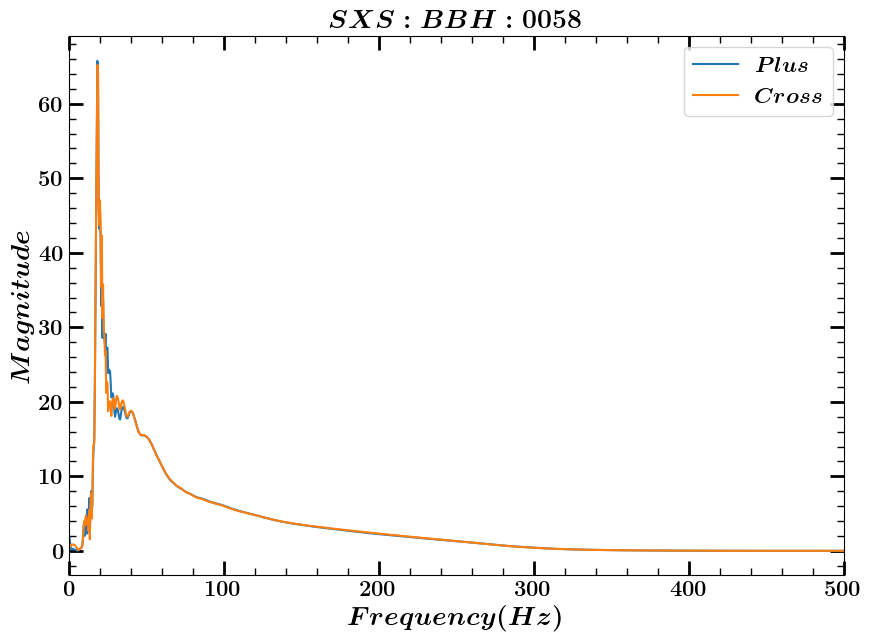

In [54]:
with h5py.File(data_dir_fft + f'/{new_index[0]}_fft.h5', 'r') as f:
                freq_p = f['freq_p'][:]
                fft_plus = f['fft_p'][:]
                freq_c = f['freq_c'][:]
                fft_cross = f['fft_c'][:]
                
plt.figure(figsize=(10, 7))
plt.plot(freq_p, np.abs(fft_plus), label=r'$Plus$')
plt.plot(freq_c, np.abs(fft_cross), label=r'$Cross$')
plt.xlabel(r'$Frequency (Hz)$')
plt.ylabel(r'$Magnitude$')
plt.xticks()
plt.yticks()
plt.title(r"$SXS:BBH:0058$")
plt.legend()
plt.xlim(0, 500)
plt.show()

##### Defining the functions to visualize the FFT of the NR signal 

In [55]:
def plot_fft(signal, fs, file_path, name):
    """Function to plot the FFT of the waveform."""
    freq, fft = compute_fft(signal, fs)
    plt.figure(figsize=(10, 7))
    plt.plot(freq, np.abs(fft), label=r"$FFT$")
    plt.xlabel(r"$Frequency (Hz)$")
    plt.ylabel(r"$Amplitude$")
    plt.legend()
    plt.xticks()
    plt.yticks()
    plt.savefig(file_path + f"/{name}_fft.pdf")
    plt.show()

def plot_fft_zoom(signal, fs, file_path, name, zoom):
    """Function to plot the FFT of the waveform."""
    freq, fft = compute_fft(signal, fs)
    plt.figure(figsize=(10, 7))
    plt.plot(freq, np.abs(fft), label=r"$FFT$")
    plt.xlabel(r"$Frequency (Hz)$")
    plt.ylabel(r"$Amplitude$")
    plt.legend()
    plt.xticks()
    plt.yticks()
    plt.xlim(0, zoom)
    plt.savefig(file_path + f"/{name}_fft_zoom.pdf")
    plt.show()

##### Visualizing the FFTs of the Signals

We plot FFTs of the following NR signals. Two plots were generated for each signal, one was the full plot the other was cropped to 500 Hz. To notice the important changes components in the lower frequency range of the FFTs. 

SXS:BBH:0305

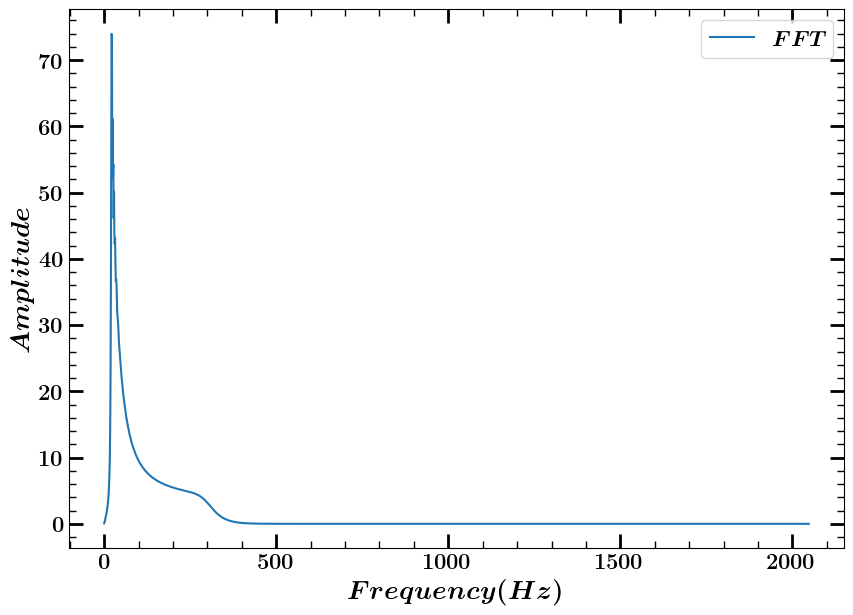

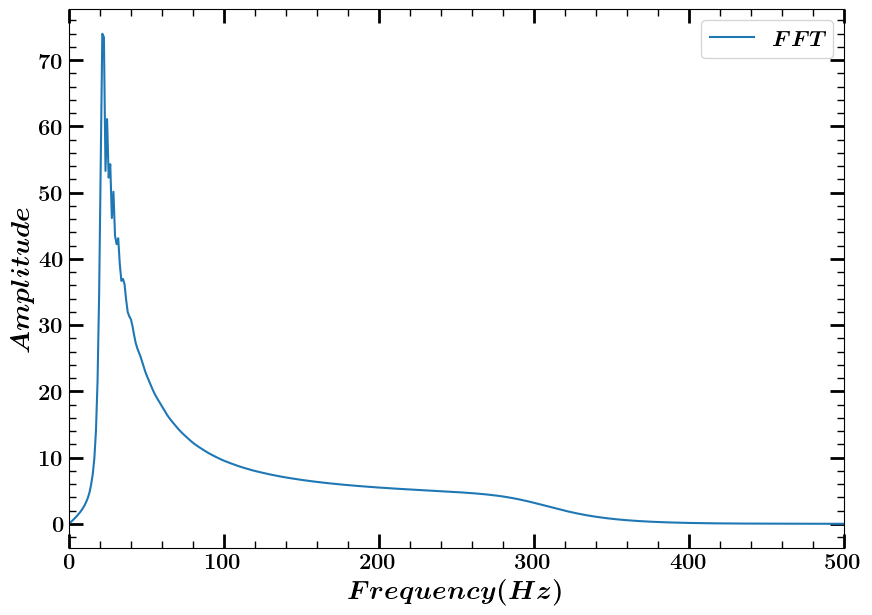

In [56]:
graph_dir_fft = os.path.join(graph_dir_wf, "fft")
if not os.path.exists(graph_dir_fft):
    os.makedirs(graph_dir_fft)


name = "SXS:BBH:0305"
processor = NRProcessor(name= name, total_mass=60, fs=4096, taper=True, pad = False)
hp, hc, time = processor.preprocess()

plot_fft(hp, 4096, graph_dir_fft, name)
plot_fft_zoom(hp, 4096, graph_dir_fft, name, zoom = 500)

SXS:NSBH:0009

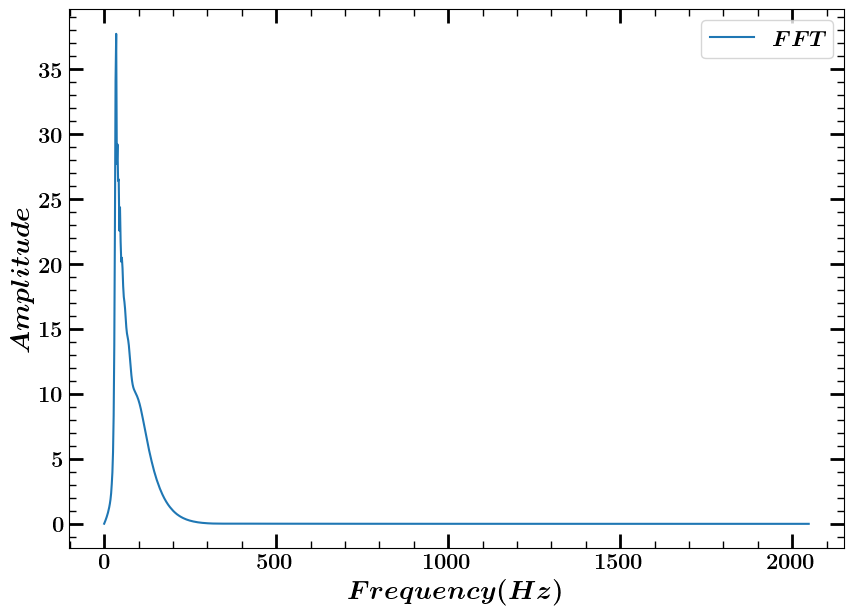

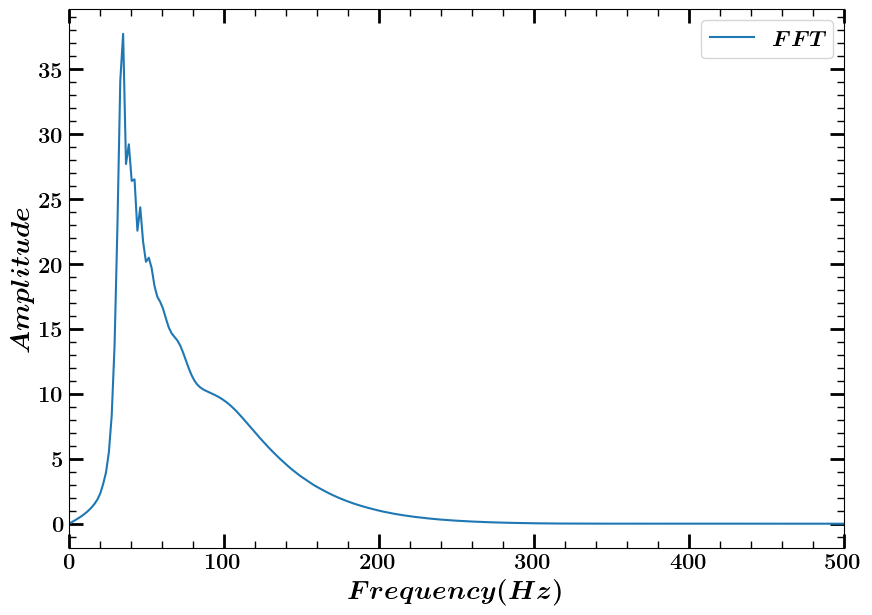

In [57]:
name = "SXS:BHNS:0009"
processor1 = NRProcessor(name=name, total_mass=60, fs=4096, taper=True, pad = False, pad_length = 8*4096)
hp1, hc1, time1 = processor1.preprocess()

plot_fft(hp1, 4096, graph_dir_fft, name)
plot_fft_zoom(hp1, 4096, graph_dir_fft, name,  zoom = 500)

SXS:BNS:0001

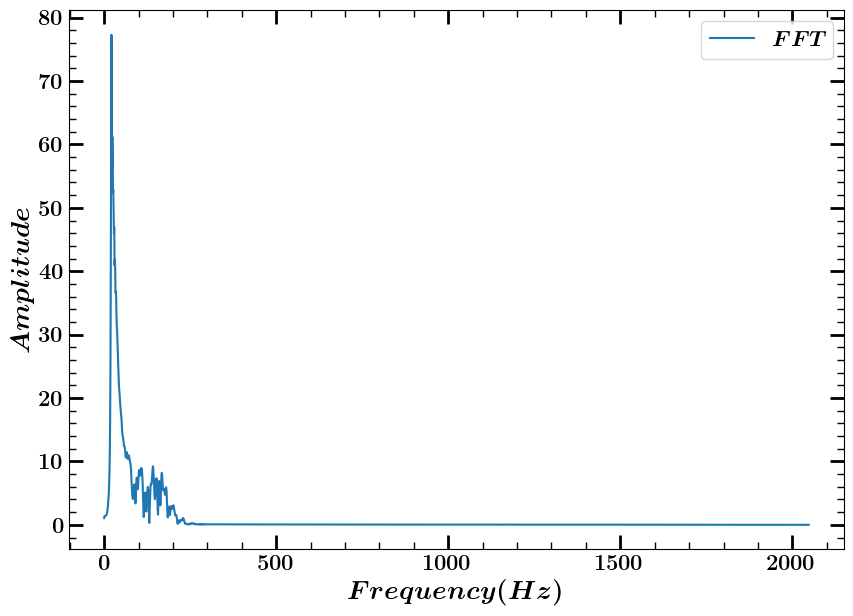

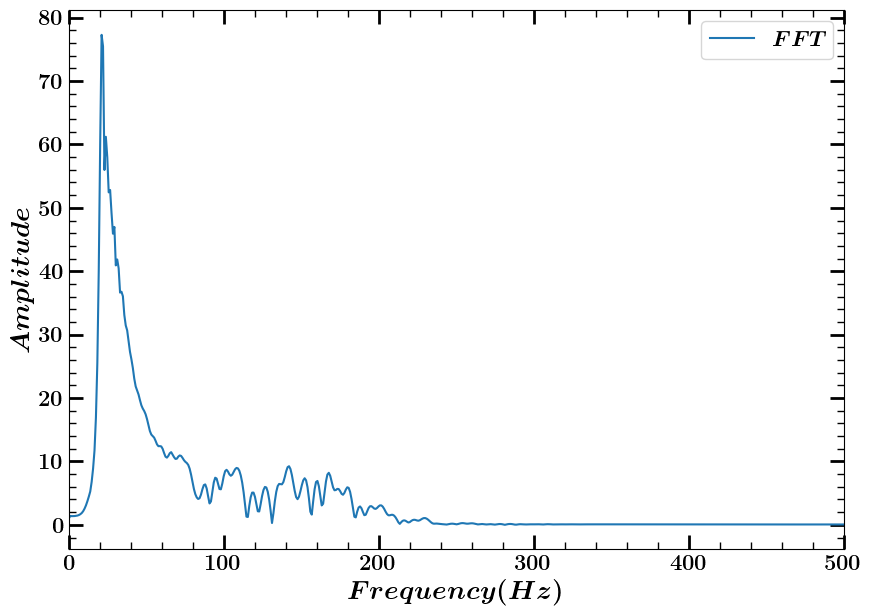

In [58]:
name = "SXS:NSNS:0001"
processor2 = NRProcessor(name=name, total_mass=60, fs=4096, taper=True, pad = False, pad_length = 8*4096)
hp2, hc2, time2 = processor2.preprocess()

plot_fft(hp2, 4096, graph_dir_fft, name)
plot_fft_zoom(hp2, 4096, graph_dir_fft, name, zoom = 500)

### Analyzing the FFTs for different Mass ratios and different total mass of the system

We first ask the user where have you saved the dataset for all the preprocessed waveforms and fft waveforms which is to be used further in the code. The user needs to provide the path of the folder sxs which contains the different waveforms fft_{j}, and preprocess_{j}, where j represents the total mass of the system. 

This is done to avoid any kind of misunderstanding in the paths 

In [59]:
data_dir_all_wf = input("Enter the full path to the folder containing the dataset for all the waveforms:").strip()
print(f"Data directory for all waveforms: {data_dir_all_wf}")

Data directory for all waveforms: /mnt/d/Darsh/MSThesis/numerical_relativity/dataset/sxs


##### Comparing the Waveforms and their corresponding frequency content of same mass ratios but different total masses

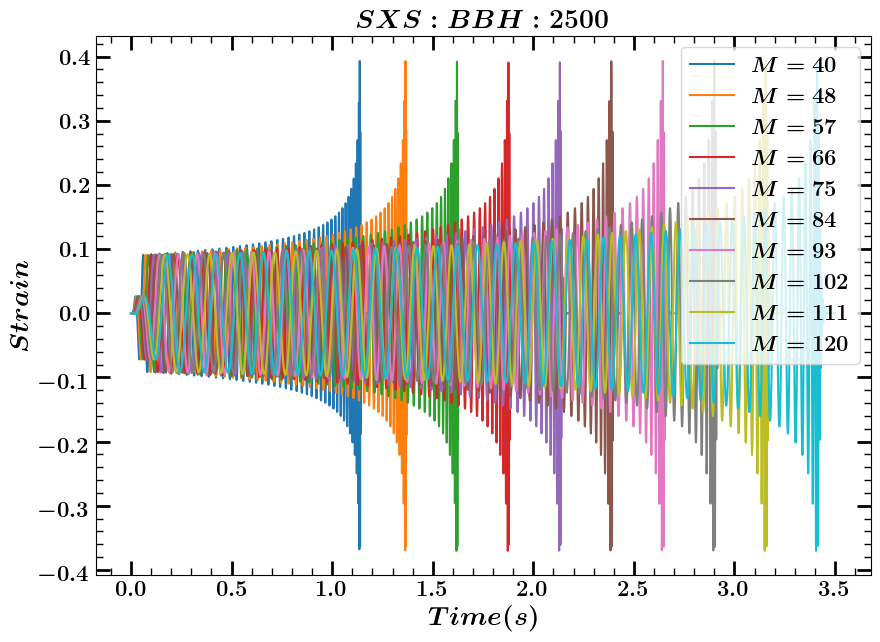

In [60]:
masses = [int(np.linspace(40, 120, 10)[i]) for i in range(10)]

# Assigning the zeros numpy.ndarrays to plot the different waveforms
Time = np.zeros(len(masses), dtype = object)
Real = np.zeros(len(masses), dtype = object)
Imag = np.zeros(len(masses), dtype = object)

time_taken = np.array([])
for i in range(len(masses)):
    with h5py.File(data_dir_all_wf + f'/preprocess_{masses[i]}/' + 'SXS_BBH_2500_pp.h5', 'r') as f:
        # Load the datasets
        Time[i] = f['time'][:]
        Real[i] = f['plus'][:]
        Imag[i] = f['cross'][:]
    time_taken = np.append(time_taken, Time[i][-1])


plt.figure(figsize=(10, 7))
for i in range(len(masses)):
    plt.plot(Time[i], Real[i], label = rf"$M$ $=$ ${masses[i]}$")
# plt.plot(Time, Imag, label=r'$Imaginary$')
plt.xlabel(r'$Time (s)$')
plt.ylabel(r'$Strain$')
plt.xticks()
plt.yticks()
plt.title(r"$SXS:BBH:2500$")
plt.legend()
plt.grid(False)
plt.savefig(graph_dir_wf + "/wfs_2500.pdf")
plt.show()

From the above graph, we can conclude that as the total mass of the system increases the time taken for merger also increases. The rate of increase can be determined by plotting the total time taken for each waveforms with same mass ratio but different total mass. 

##### Different Amplitude of FFT for total masses of the system but smae mass ratio. 

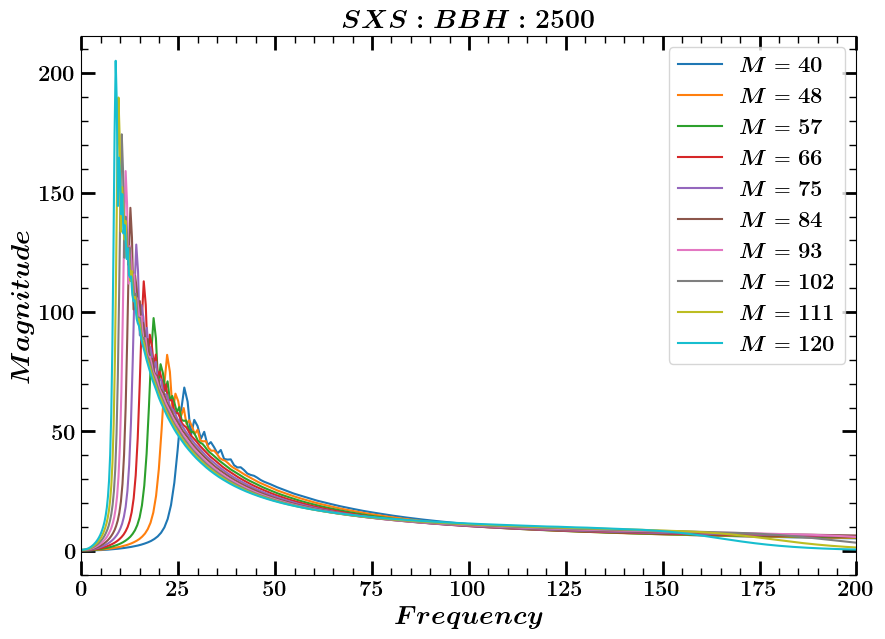

In [62]:
freq_p = np.zeros(len(masses), dtype = object)
fft_plus = np.zeros(len(masses), dtype = object)

fmax = []
Amax = []

for i in range(len(masses)):
    with h5py.File(data_dir_all_wf + f'/fft_{masses[i]}/' + 'SXS_BBH_2500_fft.h5', 'r') as f:
        freq_p[i]=(f['freq_p'][:])
        fft_plus[i]=(f['fft_p'][:])
    fmax.append(freq_p[i][np.argmax(fft_plus[i])])
    Amax.append(np.max(fft_plus[i]))

plt.figure(figsize=(10, 7))
# for i in range(1):
for i in range(len(masses)):
    plt.plot(freq_p[i], np.abs(fft_plus[i]), label = rf"$M$ = ${masses[i]}$")
    # plt.axvline(x=fmax[i], color='r', linestyle='--')
plt.xlabel(r'$Frequency$')
plt.ylabel(r'$Magnitude$')
plt.xticks()
plt.yticks()
plt.title(r"$SXS:BBH:2500$")
plt.legend()
plt.grid(False)
plt.xlim(0, 200)
plt.savefig(graph_dir_wf + "/ffts_2500_fs.pdf")
plt.show()   

##### Plot of waveforms having same total mass but different mass ratios. 

Here, we plot the FFTs of the signal having the mass ratios as 5 and 1 respectively and compare them. We can clearly observe the increase in the distortions of the FFT as the mass ratio of the system increases.

5.001854254928465 0.9999999962439973


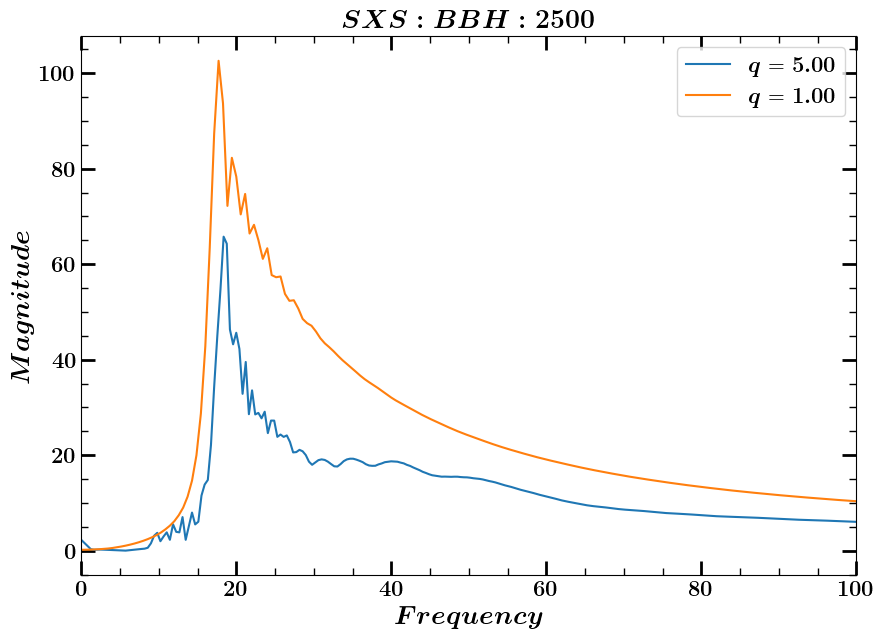

In [63]:
q1 = df_BBH.loc["SXS:BBH:0058"]["reference_mass_ratio"]
q2 = df_BBH.loc["SXS:BBH:2500"]["reference_mass_ratio"]
print(q1, q2)

fp = np.zeros(2, dtype = object)
fft = np.zeros(2, dtype = object)

with h5py.File(data_dir_all_wf + '/fft_60/' + f'SXS_BBH_0058_fft.h5', 'r') as f:
    fp[0]=(f['freq_p'][:])
    fft[0]=(f['fft_p'][:])
with h5py.File(data_dir_all_wf + '/fft_60/' + f'SXS_BBH_2500_fft.h5', 'r') as f:
    fp[1]=(f['freq_p'][:])
    fft[1]=(f['fft_p'][:])

plt.figure(figsize=(10, 7))
plt.plot(fp[0], np.abs(fft[0]), label = rf"$q$ = ${q1:.2f}$")
plt.plot(fp[1], np.abs(fft[1]), label = rf"$q$ = ${q2:.2f}$")
plt.xlabel(r'$Frequency$')
plt.ylabel(r'$Magnitude$')
plt.xticks()
plt.yticks()
plt.title(r"$SXS:BBH:2500$")
plt.legend()
plt.grid(False)
plt.xlim(0, 100)
plt.savefig(graph_dir_wf + "/ffts_2500_fs.pdf")
plt.show()  

##### Checking of the inverse law of inspiral frequency with total mass

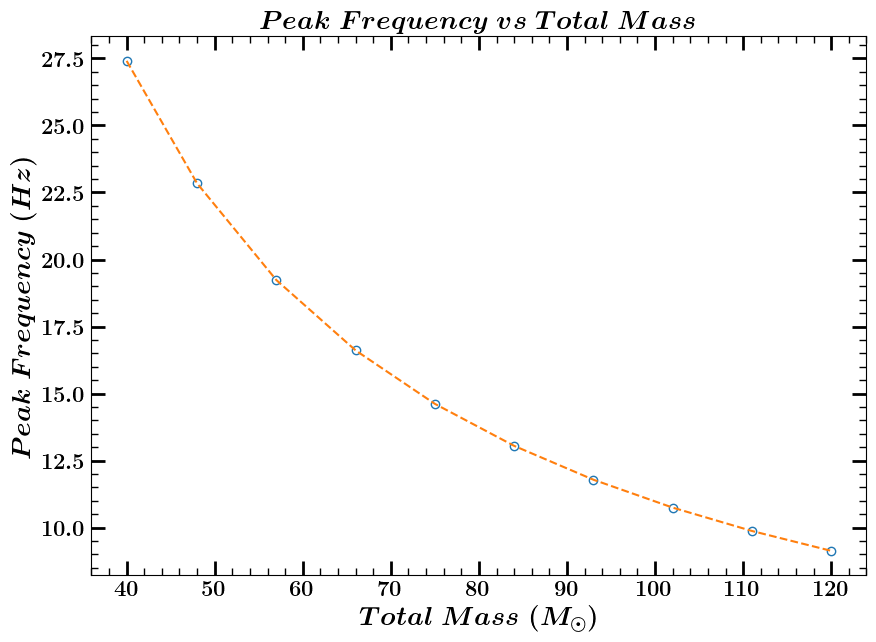

In [64]:
def fun(x, a):
    return a/x

from scipy.optimize import curve_fit
fopt, fcov = curve_fit(fun, masses, fmax)
y = fun(masses, *fopt)

plt.figure(figsize=(10, 7))
plt.plot(masses, fmax, "o")
plt.plot(masses, y, "--")
plt.xlabel(r"$Total$ $Mass$ $(M_{\odot})$")
plt.ylabel(r"$Peak$ $Frequency$ $(Hz)$")
plt.title(r"$Peak$ $Frequency$ $vs$ $Total$ $Mass$")
plt.grid(False)
plt.savefig(graph_dir_wf + "/peak_freq_vs_mass.pdf")
plt.show()

Here, we can clearly observe the inverse law satisfied by the FFTs for inspiral frequency and the total mass of the system.  

##### Variation of Maximum Amplitude of FFT with Masses 

/home/darsh/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:628: ComplexWarning: Casting complex values to real discards the imaginary part
  a = asarray(a, dtype=dtype, order=order)
/home/darsh/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/darsh/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


[ 1.52440372 -0.07352523]


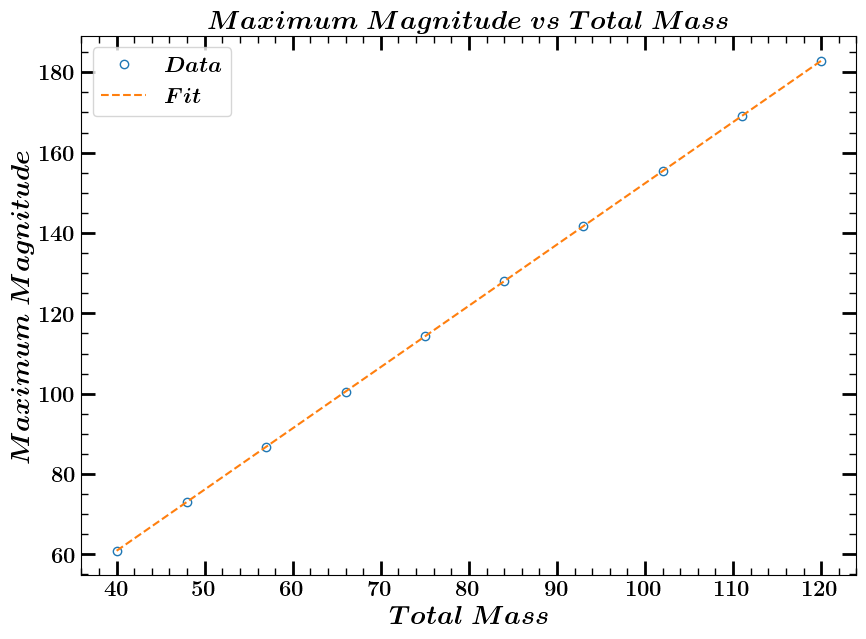

In [65]:
def fun_linear(x, a, b):
    # print(a, b)
    return a*np.array(x) + b

Amax = np.array(Amax)
from scipy.optimize import curve_fit
Aopt, Acov = curve_fit(fun_linear, masses, Amax)
# print(masses)
print(Aopt)
y_A = fun_linear(masses, Aopt[0], Aopt[1])


plt.figure(figsize=(10, 7))
plt.plot(masses, Amax, "o", label = r"$Data$")
plt.plot(masses, y_A, "--", label = r"$Fit$")
plt.xlabel(r"$Total$ $Mass$")
plt.ylabel(r"$Maximum$ $Magnitude$")
plt.title(r"$Maximum$ $Magnitude$ $vs$ $Total$ $Mass$")
plt.legend()
plt.grid(False)
plt.savefig(graph_dir_wf + "/max_mag_vs_mass.pdf")
plt.show()

As observed from the above curve, for different total masses of the system, the maximum amplitude of the GW signal increases linearly for a given mass ratio of the system.  

##### Variation of Time Taken with Masses 

The parameters of the curve fit are: [ 2.91905685e-02 -2.17412709e-12]


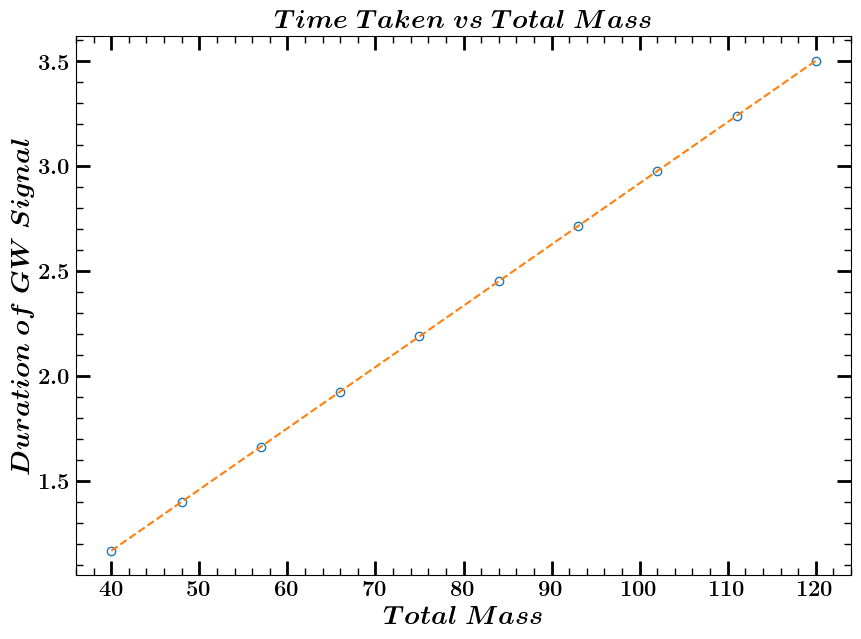

In [66]:
topt, tcov = curve_fit(fun_linear, masses, time_taken)
y_t = fun_linear(masses, topt[0], topt[1])

print(f"The parameters of the curve fit are: {topt}")

plt.figure(figsize=(10, 7))
plt.plot(masses, time_taken, "o")
plt.plot(masses, y_t, "--") 
plt.xlabel(r"$Total$ $Mass$")
plt.ylabel(r"$Duration$ $of$ $GW$ $Signal$")
plt.title(r"$Time$ $Taken$ $vs$ $Total$ $Mass$")
plt.grid(False)
plt.show()

Moreover, the total duration also increase linearly with the increase of the total mass of the system. 

##### Toy example for calculating the curvature of the curves

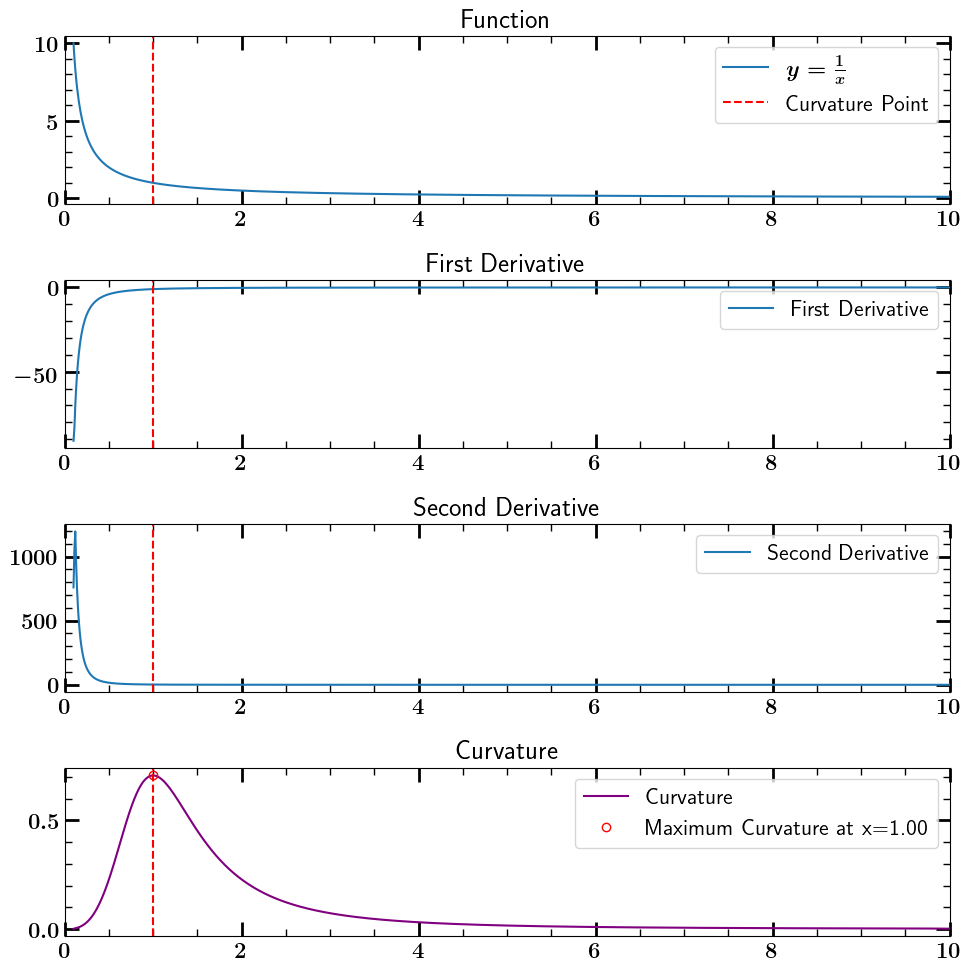

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# Define x values avoiding x=0
x = np.linspace(0.1, 10, 1000)  # Avoid x=0 to prevent division by zero
y1 = 1 / x  # Function y = 1/x

# Compute first and second derivatives
dy1 = np.gradient(y1, x)
ddy1 = np.gradient(dy1, x)

# Compute curvature
curvature = np.abs(ddy1) / (1 + dy1**2)**(3/2)
xmax = x[np.argmax(curvature)]
ymax = np.max(curvature)

# Define the point to check curvature
curve1 = 5

# Plot function, first derivative, second derivative, and curvature
fig, axs = plt.subplots(4, 1, figsize=(10, 10))

axs[0].plot(x, y1, label=r"$y = \frac{1}{x}$")
axs[0].axvline(x=xmax, color='r', linestyle='--', label="Curvature Point")
axs[0].set_xlim(0, 10)
axs[0].legend()
axs[0].grid(False)
axs[0].set_title("Function")

axs[1].plot(x, dy1, label="First Derivative")
axs[1].axvline(x=xmax, color='r', linestyle='--')
axs[1].set_xlim(0, 10)
axs[1].legend()
axs[1].grid(False)
axs[1].set_title("First Derivative")

axs[2].plot(x, ddy1, label="Second Derivative")
axs[2].axvline(x=xmax, color='r', linestyle='--')
axs[2].set_xlim(0, 10)
axs[2].legend()
axs[2].grid(False)
axs[2].set_title("Second Derivative")

axs[3].plot(x, curvature, label="Curvature", color='purple')

axs[3].plot(xmax, ymax, 'ro', label=f"Maximum Curvature at x={xmax:.2f}")
axs[3].axvline(x=xmax, color='r', linestyle='--')
axs[3].set_xlim(0, 10)
axs[3].legend()
axs[3].grid(False)
axs[3].set_title("Curvature")

plt.tight_layout()
plt.show()


## Part 2 - Waveform Analysis

Important functions to import from the libraries

In [68]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

We perform the analysis of the signal in the frequency domain and then calculate the continuous wavelet transform (wavelet transform) to understand the time - frequency evolution of the NR signal. The important difference between the noise signal and the GW signal is the unique time frequency evolution of that signal as compared to the noise. Noise can never evolve whole following such a pattern. Hence, it becomes essential to perform a detailed analysis of it. 

### Wavelet Transform - Time Frequency Evolution of the Signal

#### Function to calculate the wavelet transform and plot the time frequency evolution of NR 

In [69]:
def cwt(time, strain, wavelet="cmor1.5-1.0", num_scales=100, scale_max=1024):
    """
    Function to compute and plot the Continuous Wavelet Transform (CWT) of a gravitational wave signal.

    Parameters:
    - time_path (str): Path to the time data (.npy file).
    - strain_path (str): Path to the strain data (.npy file).
    - save_path (str): Path to save the resulting plot image.
    - wavelet (str): Wavelet type for CWT (default is 'cmor1.5-1.0').
    - num_scales (int): Number of scales for CWT (default is 100).
    - scale_max (int): Maximum scale value (default is 1024).
    """
    # Load time and strain data
    time = time
    chirp = strain
    
    # Setup for CWT
    widths = np.geomspace(1, scale_max, num=num_scales)
    sampling_period = np.diff(time).mean()
    
    # Perform CWT
    cwtmatr, freqs = pywt.cwt(chirp, widths, wavelet, sampling_period=sampling_period)
    cwtmatr = np.abs(cwtmatr[:-1, :-1])  # Take absolute value of complex result

    return time, freqs, cwtmatr

def plot_cwt(time, strain, file_path, name):
    """Function to plot the Continuous Wavelet Transform (CWT) of a gravitational wave signal."""
    time, freqs, cwtmatr = cwt(time, strain)
    
    plt.figure(figsize = (10, 7))
    plt.pcolormesh(time, freqs, cwtmatr, shading = "auto")
    plt.colorbar(label = r"$Magnitude$")
    plt.xlabel(r'$Time (s)$')
    plt.ylabel(r'$Frequency (Hz)$')
    # plt.yscale("log")
    plt.xlim(time[0], time[-1])
    plt.ylim(0, 600)
    plt.xticks()
    plt.yticks()
    plt.savefig(file_path + f"/{name}_wavelet.pdf")
    plt.show()

#### Visualizing the Wavelet Transforms 

SXS:BBH:0305

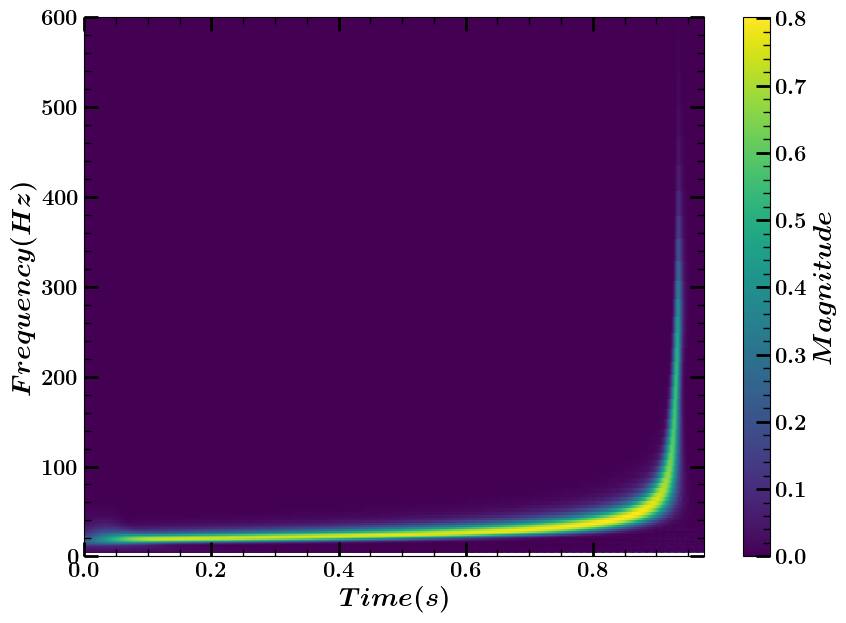

In [70]:
graph_dir_wavelet = os.path.join(graph_dir_wf, "wavelet")
if not os.path.exists(graph_dir_wavelet):
    os.makedirs(graph_dir_wavelet)

name = "SXS:BBH:0305"
processor = NRProcessor(name= name, total_mass=60, fs=4096, taper=True, pad = False)
hp, hc, time = processor.preprocess()
time, freqs, cwtmatr = cwt(time, hp)
plot_cwt(time, hp, graph_dir_wavelet, name)

SXS:NSBH:0009

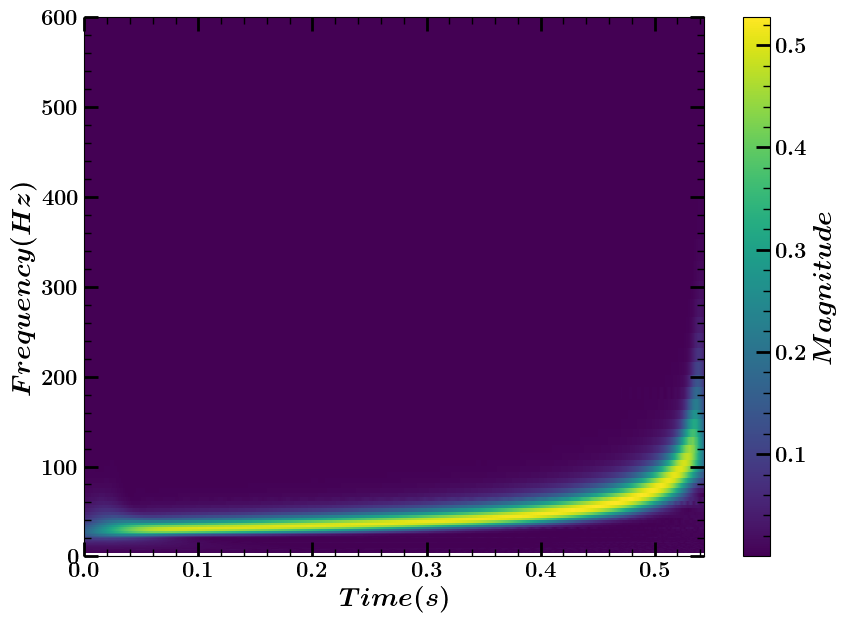

In [71]:
name = "SXS:NSBH:0009"

time1, freqs1, cwtmatr1 = cwt(time1, hp1)
plot_cwt(time1, hp1, graph_dir_wavelet, name)

SXS:BNS:0001

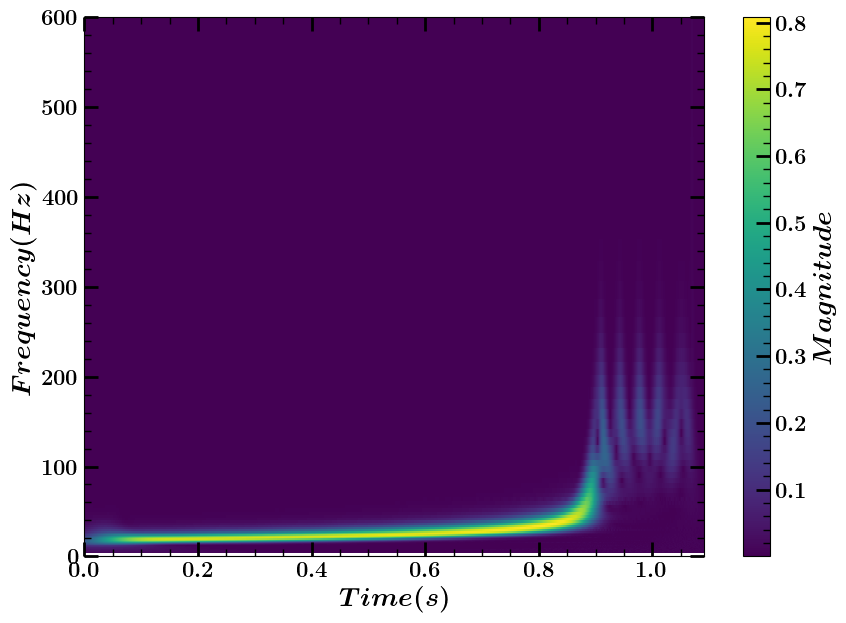

In [72]:
name = "SXS:NSNS:0001" 
time2, freqs2, cwtmatr2 = cwt(time2, hp2)
plot_cwt(time2, hp2, graph_dir_wavelet, name)

Now, we plot all the analysis plots of the NR signal in a signle plot and understand what all information can be extracted out of it. We plot the Time domain signal, The fourier or frequency domain signal and the wavelete or Time frequency domain signal to understand the evolution of signal with respect to time and frequency. 

### Waveform Analysis using all the plots obtained after signal processing techniques

#### Visualzation of the all the plots togeth to understand in detail

SXS:BBH:0305

THESIS: Figure 2.2

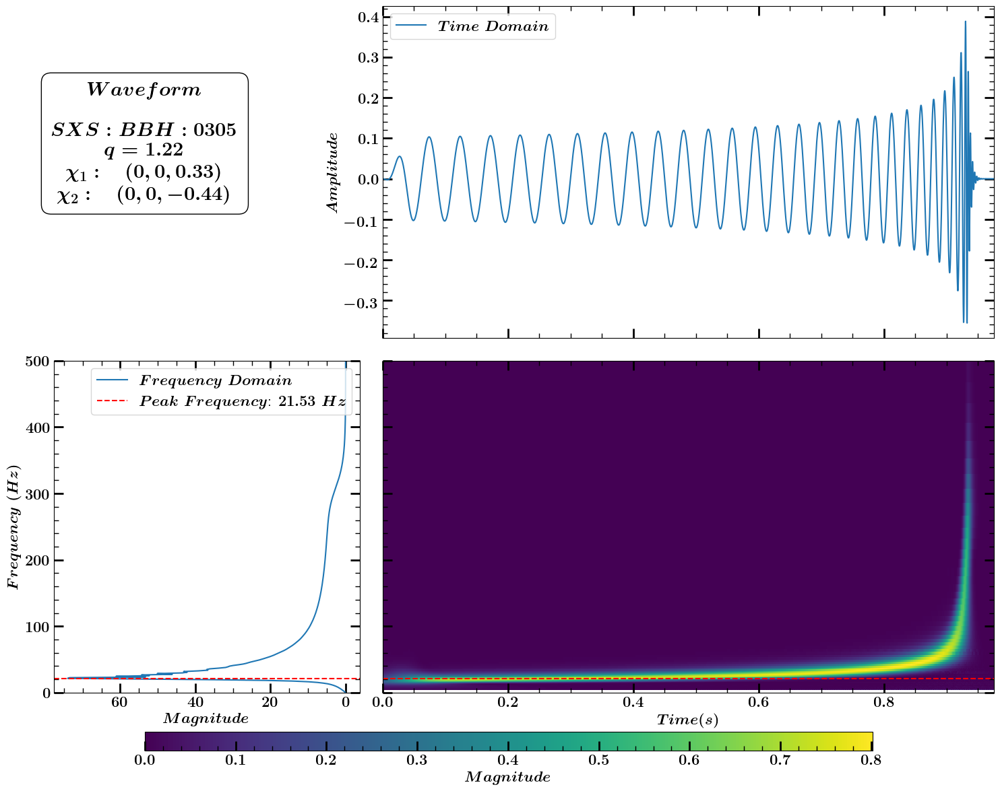

In [73]:
f = 16

def plot_all(time, signal, file_path):
    """Plot time-domain signal, CWT, and FFT with aligned axes."""
    fig = plt.figure(figsize=(18, 14))
    
    # Create grid layout for precise alignment
    gs = fig.add_gridspec(3, 2, width_ratios=[1, 2], height_ratios=[1, 1, 0.05], hspace=0.1, wspace=0.05)
    
    # Time-domain plot (Top Right)
    ax_signal = fig.add_subplot(gs[0, 1])
    ax_signal.plot(time, signal, label=r"$Time$ $Domain$")
    ax_signal.set_xlim(time[0], time[-1])
    ax_signal.set_ylabel(r"$Amplitude$", fontsize = f)
    ax_signal.legend()
    ax_signal.tick_params(axis='both', which='major', labelsize= f)
    ax_signal.set_xticklabels([])  # Remove x-axis labels to share with CWT
    
    # Continuous Wavelet Transform (CWT) plot (Middle Right, extended to right end)
    time, freqs, cwtmatr = cwt(time, signal)
    ax_cwt = fig.add_subplot(gs[1, 1])
    im = ax_cwt.pcolormesh(time, freqs, cwtmatr, shading="auto", rasterized=True)
    ax_cwt.set_xlabel(r"$Time (s)$", fontsize= f)   
    ax_cwt.set_xlim(time[0], time[-1])
    ax_cwt.set_ylim(0, 500)
    ax_cwt.tick_params(axis='both', which='major', labelsize=f)
    ax_cwt.set_yticklabels([])
    
    # FFT plot (Left Middle)
    freq, fft_vals = compute_fft(signal, 4096)
    ax_fft = fig.add_subplot(gs[1, 0])
    ax_fft.plot(np.abs(fft_vals), freq, label=r"$Frequency$ $Domain$")
    ax_fft.set_xlabel(r"$Magnitude$", fontsize= f)
    ax_fft.set_ylabel(r"$Frequency$ $(Hz)$", fontsize= f)
    ax_fft.legend()
    ax_fft.set_ylim(0, 500)
    ax_fft.invert_xaxis()  # Flip for alignment
    ax_fft.tick_params(axis='both', which='major', labelsize= f)
    
    # Find peak frequency
    peak_freq = freq[np.argmax(np.abs(fft_vals))]
    
    # Draw horizontal line at peak frequency
    ax_cwt.axhline(y=peak_freq, color='r', linestyle='--')
    ax_fft.axhline(y=peak_freq, color='r', linestyle='--', label=rf'$Peak$ $Frequency$: ${peak_freq:.2f}$ $Hz$')
    ax_fft.legend(loc='upper right')
    
    # Magnitude color bar at the bottom, below the CWT plot
    cbar_ax = fig.add_axes([0.2, 0.09, 0.6, 0.02])  # Adjust placement
    cbar = plt.colorbar(im, cax=cbar_ax, orientation="horizontal")
    cbar.ax.tick_params(labelsize=f)
    cbar.set_label(r"$Magnitude$", fontsize=f)
    
    # Add text box in the left blank space
    # fig.text(0.12, 0.8, r'$Time$$-$$Frequency$' '\n' '$Domain$ $Signal$', fontsize=f+5, rotation='horizontal', bbox=dict(facecolor='none', edgecolor='black', boxstyle='round',pad=1))
    fig.text(0.20, 0.8, 
        r'$Waveform$' '\n\n'
        r'$SXS:BBH:0305$' '\n'
        r'\vspace{3pt}$q = 1.22$' '\n'
        r'\vspace{3pt}$\chi_{1}: \quad (0, 0, 0.33)$' '\n'
        r'\vspace{3pt}$\chi_{2}: \quad (0, 0, -0.44)$',
        fontsize=f+5, rotation='horizontal',
        horizontalalignment='center',  # Centers text
        verticalalignment='top'        # Fixes text block position
        ,bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', pad=0.5)
    )

    plt.savefig(file_path + "_all_aligned.pdf")
    # plt.savefig(file_path + "_all_aligned.png")
    plt.show()

graph_dir_wf_analysis = os.path.join(graph_dir, "analysis")
if not os.path.exists(graph_dir_wf_analysis):
    os.makedirs(graph_dir_wf_analysis)

plot_all(time, hp, graph_dir_wf_analysis + "/SXS_BBH_0305")

SXS:NSBH:0009

THESIS: Figure 2.3

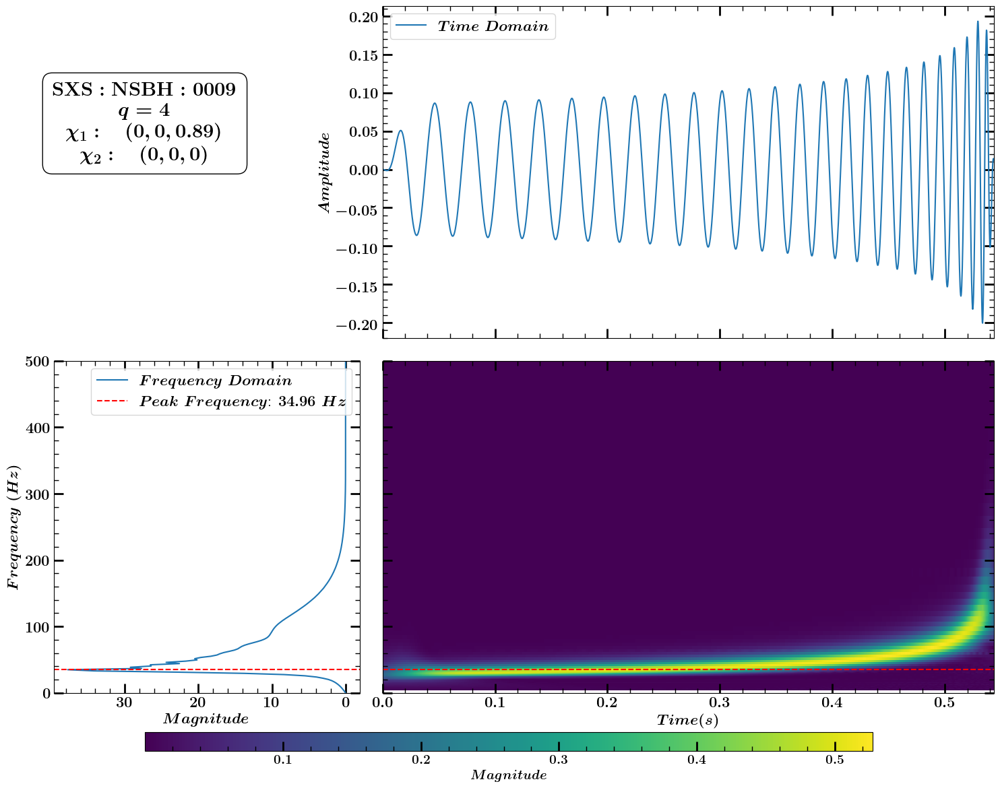

In [74]:
f = 16

def plot_all(time, signal, file_path):
    """Plot time-domain signal, CWT, and FFT with aligned axes."""
    fig = plt.figure(figsize=(18, 14))
    
    # Create grid layout for precise alignment
    gs = fig.add_gridspec(3, 2, width_ratios=[1, 2], height_ratios=[1, 1, 0.05], hspace=0.1, wspace=0.05)
    
    # Time-domain plot (Top Right)
    ax_signal = fig.add_subplot(gs[0, 1])
    ax_signal.plot(time, signal, label=r"$Time$ $Domain$")
    ax_signal.set_xlim(time[0], time[-1])
    ax_signal.set_ylabel(r"$Amplitude$", fontsize = f)
    ax_signal.legend()
    ax_signal.tick_params(axis='both', which='major', labelsize= f)
    ax_signal.set_xticklabels([])  # Remove x-axis labels to share with CWT
    
    # Continuous Wavelet Transform (CWT) plot (Middle Right, extended to right end)
    time, freqs, cwtmatr = cwt(time, signal)
    ax_cwt = fig.add_subplot(gs[1, 1])
    im = ax_cwt.pcolormesh(time, freqs, cwtmatr, shading="auto", rasterized=True)
    ax_cwt.set_xlabel(r"$Time (s)$", fontsize= f)   
    ax_cwt.set_xlim(time[0], time[-1])
    ax_cwt.set_ylim(0, 500)
    ax_cwt.tick_params(axis='both', which='major', labelsize=f)
    ax_cwt.set_yticklabels([])
    
    # FFT plot (Left Middle)
    freq, fft_vals = compute_fft(signal, 4096)
    ax_fft = fig.add_subplot(gs[1, 0])
    ax_fft.plot(np.abs(fft_vals), freq, label=r"$Frequency$ $Domain$")
    ax_fft.set_xlabel(r"$Magnitude$", fontsize= f)
    ax_fft.set_ylabel(r"$Frequency$ $(Hz)$", fontsize= f)
    ax_fft.legend()
    ax_fft.set_ylim(0, 500)
    ax_fft.invert_xaxis()  # Flip for alignment
    ax_fft.tick_params(axis='both', which='major', labelsize= f)
    
    # Find peak frequency
    peak_freq = freq[np.argmax(np.abs(fft_vals))]
    
    # Draw horizontal line at peak frequency
    ax_cwt.axhline(y=peak_freq, color='r', linestyle='--')
    ax_fft.axhline(y=peak_freq, color='r', linestyle='--', label=rf'$Peak$ $Frequency$: ${peak_freq:.2f}$ $Hz$')
    ax_fft.legend(loc='upper right')
    
    # Magnitude color bar at the bottom, below the CWT plot
    cbar_ax = fig.add_axes([0.2, 0.09, 0.6, 0.02])  # Adjust placement
    cbar = plt.colorbar(im, cax=cbar_ax, orientation="horizontal")
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label(r"$Magnitude$", fontsize=14)
    
    # Add text box in the left blank space
    # fig.text(0.12, 0.8, r'$Time$$-$$Frequency$' '\n' '$Domain$ $Signal$', fontsize=f+5, rotation='horizontal', bbox=dict(facecolor='none', edgecolor='black', boxstyle='round',pad=1))
    fig.text(0.20, 0.8, 
        r'$\mathbf{SXS:NSBH:0009}$' '\n'
        r'\vspace{3pt}$q = 4$' '\n'
        r'\vspace{3pt}$\chi_{1}: \quad (0, 0, 0.89)$' '\n'
        r'\vspace{3pt}$\chi_{2}: \quad (0, 0, 0)$',
        fontsize=f+5, rotation='horizontal',
        horizontalalignment='center',  # Centers text
        verticalalignment='top',        # Fixes text block position
        bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', pad=0.5)
    )

    plt.savefig(file_path + "_all_aligned.pdf")
    # plt.savefig(file_path + "all_aligned.png")
    plt.show()

plot_all(time1, hp1, graph_dir_wf_analysis + "/SXS_NSBH_0009")


SXS:BNS:0001

THESIS: Figure 2.4

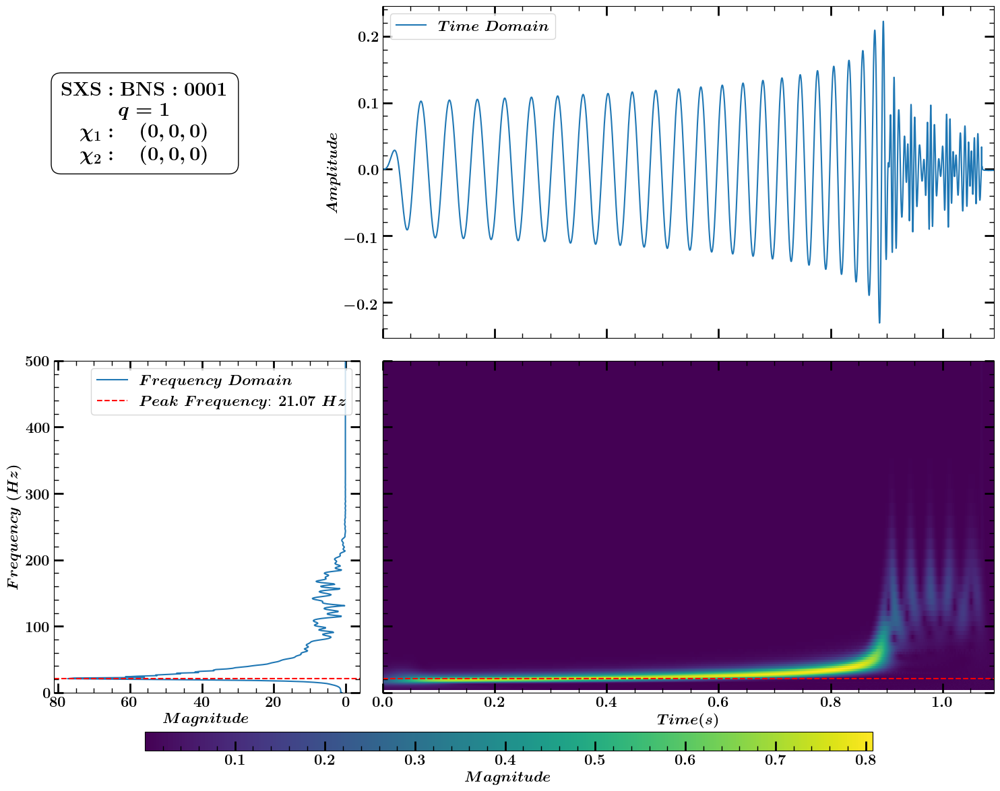

In [75]:
f = 16

def plot_all(time, signal, file_path):
    """Plot time-domain signal, CWT, and FFT with aligned axes."""
    fig = plt.figure(figsize=(18, 14))
    
    # Create grid layout for precise alignment
    gs = fig.add_gridspec(3, 2, width_ratios=[1, 2], height_ratios=[1, 1, 0.05], hspace=0.1, wspace=0.05)
    
    # Time-domain plot (Top Right)
    ax_signal = fig.add_subplot(gs[0, 1])
    ax_signal.plot(time, signal, label=r"$Time$ $Domain$")
    ax_signal.set_xlim(time[0], time[-1])
    ax_signal.set_ylabel(r"$Amplitude$", fontsize = f)
    ax_signal.legend()
    ax_signal.tick_params(axis='both', which='major', labelsize= f)
    ax_signal.set_xticklabels([])  # Remove x-axis labels to share with CWT
    
    # Continuous Wavelet Transform (CWT) plot (Middle Right, extended to right end)
    time, freqs, cwtmatr = cwt(time, signal)
    ax_cwt = fig.add_subplot(gs[1, 1])
    im = ax_cwt.pcolormesh(time, freqs, cwtmatr, shading="auto", rasterized=True)
    ax_cwt.set_xlabel(r"$Time (s)$", fontsize= f)   
    ax_cwt.set_xlim(time[0], time[-1])
    ax_cwt.set_ylim(0, 500)
    ax_cwt.tick_params(axis='both', which='major', labelsize=f)
    ax_cwt.set_yticklabels([])
    
    # FFT plot (Left Middle)
    freq, fft_vals = compute_fft(signal, 4096)
    ax_fft = fig.add_subplot(gs[1, 0])
    ax_fft.plot(np.abs(fft_vals), freq, label=r"$Frequency$ $Domain$")
    ax_fft.set_xlabel(r"$Magnitude$", fontsize= f)
    ax_fft.set_ylabel(r"$Frequency$ $(Hz)$", fontsize= f)
    ax_fft.legend()
    ax_fft.set_ylim(0, 500)
    ax_fft.invert_xaxis()  # Flip for alignment
    ax_fft.tick_params(axis='both', which='major', labelsize= f)
    
    # Find peak frequency
    peak_freq = freq[np.argmax(np.abs(fft_vals))]
    
    # Draw horizontal line at peak frequency
    ax_cwt.axhline(y=peak_freq, color='r', linestyle='--')
    ax_fft.axhline(y=peak_freq, color='r', linestyle='--', label=rf'$Peak$ $Frequency$: ${peak_freq:.2f}$ $Hz$')
    ax_fft.legend(loc='upper right')
    
    # Magnitude color bar at the bottom, below the CWT plot
    cbar_ax = fig.add_axes([0.2, 0.09, 0.6, 0.02])  # Adjust placement
    cbar = plt.colorbar(im, cax=cbar_ax, orientation="horizontal")
    cbar.ax.tick_params(labelsize=f)
    cbar.set_label(r"$Magnitude$", fontsize=f)
    
    # Add text box in the left blank space
    # fig.text(0.12, 0.8, r'$Time$$-$$Frequency$' '\n' '$Domain$ $Signal$', fontsize=f+5, rotation='horizontal', bbox=dict(facecolor='none', edgecolor='black', boxstyle='round',pad=1))
    fig.text(0.20, 0.8, 
        r'$\mathbf{SXS:BNS:0001}$' '\n'
        r'\vspace{3pt}$q = 1$' '\n'
        r'\vspace{3pt}$\chi_{1}: \quad (0, 0, 0)$' '\n'
        r'\vspace{3pt}$\chi_{2}: \quad (0, 0, 0)$',
        fontsize=f+5, rotation='horizontal',
        horizontalalignment='center',  # Centers text
        verticalalignment='top',        # Fixes text block position
        bbox=dict(facecolor='none', edgecolor='black', boxstyle='round', pad=0.5)
    )

    plt.savefig(file_path + "_all_aligned.pdf")
    # plt.savefig(file_path + "_all_aligned.png")
    plt.show()

plot_all(time2, hp2, graph_dir_wf_analysis + "/SXS_BNS_0001")

## Part 3 - Data Fitting for creating the dataset of the neural network table

This part contains the fitting of the amplitude of the FFT of NR signal obtained from SXS wavefrom catalog. 

### Defining the logistics and required variables for fitting the curves and plotting them

#### Defining the important functions

In [76]:
# Here we define the functions which we would use while fitting the FFT and determining the fitting parameters of FFT

# -------------- Plot the Aligned plot of time domain, CWT and FFT -----------------
def plot_all(time, signal):
    """Plot time-domain signal, CWT, and FFT with aligned axes."""
    fig = plt.figure(figsize=(18, 14))
    
    # Create grid layout for precise alignment
    gs = fig.add_gridspec(3, 2, width_ratios=[1, 2], height_ratios=[1, 1, 0.05], hspace=0.1, wspace=0.05)
    
    # Time-domain plot (Top Right)
    ax_signal = fig.add_subplot(gs[0, 1])
    ax_signal.plot(time, signal, label=r"$Time$ $Domain$")
    ax_signal.set_xlim(time[0], time[-1])
    ax_signal.set_ylabel(r"$Amplitude$", fontsize = a)
    ax_signal.legend()
    ax_signal.tick_params(axis='both', which='major', labelsize= a)
    ax_signal.set_xticklabels([])  # Remove x-axis labels to share with CWT
    
    # Continuous Wavelet Transform (CWT) plot (Middle Right, extended to right end)
    time, freqs, cwtmatr = cwt(time, signal)
    ax_cwt = fig.add_subplot(gs[1, 1])
    im = ax_cwt.pcolormesh(time, freqs, cwtmatr, shading="auto", rasterized=True)
    max_index = np.argmax(cwtmatr, axis = 0)
    max_freq_values = freqs[max_index]
    ax_cwt.plot(time[:-1], max_freq_values, color='black', linestyle='--', linewidth=2, label="Max Magnitude Curve")
    ax_cwt.set_xlabel(r"$Time (s)$", fontsize= a)   
    ax_cwt.set_xlim(time[0], time[-1])
    ax_cwt.set_ylim(0, 500)
    ax_cwt.tick_params(axis='both', which='major', labelsize=a)
    ax_cwt.set_yticklabels([])
    
    # FFT plot (Left Middle)
    freq, fft_vals = compute_fft(signal, 4096)
    ax_fft = fig.add_subplot(gs[1, 0])
    ax_fft.plot(np.abs(fft_vals), freq, label=r"$Frequency$ $Domain$")
    ax_fft.set_xlabel(r"$Magnitude$", fontsize= a)
    ax_fft.set_ylabel(r"$Frequency$ $(Hz)$", fontsize= a)
    ax_fft.legend()
    ax_fft.set_ylim(0, 500)
    ax_fft.invert_xaxis()  # Flip for alignment
    ax_fft.tick_params(axis='both', which='major', labelsize= a)
    
    # Find peak frequency
    peak_freq = freq[np.argmax(np.abs(fft_vals))]
    
    # Draw horizontal line at peak frequency
    ax_cwt.axhline(y=peak_freq, color='r', linestyle='--')
    ax_fft.axhline(y=peak_freq, color='r', linestyle='--', label=rf'$Peak$ $Frequency$: ${peak_freq:.2f}$ $Hz$')
    ax_fft.legend(loc='upper right')
    
    # Magnitude color bar at the bottom, below the CWT plot
    cbar_ax = fig.add_axes([0.2, 0.09, 0.6, 0.02])  # Adjust placement
    cbar = plt.colorbar(im, cax=cbar_ax, orientation="horizontal")
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label(r"$Magnitude$", fontsize=14)
    
    # Add text box in the left blank space
    # fig.text(0.12, 0.8, r'$Time$$-$$Frequency$' '\n' '$Domain$ $Signal$', fontsize=f+5, 
    # rotation='horizontal', bbox=dict(facecolor='none', edgecolor='black', boxstyle='round',pad=1))
    plt.show()



# -------------- Function to calculate the curvature of the curve -----------------
def compute_curvature(x, y):
    """Compute the curvature of a 2D curve given x, y coordinates."""
    dx = np.gradient(x)  # First derivative of x
    dy = np.gradient(y)  # First derivative of y
    ddx = np.gradient(dx)  # Second derivative of x
    ddy = np.gradient(dy)  # Second derivative of y

    # Compute curvature formula
    curvature = np.abs(ddx * dy - ddy * dx) / (dx**2 + dy**2) ** (3/2)
    return curvature



# -------------------Function to crop the FFT for the given range of frequencies and determine the maximum frequency and maximum magnitude --------------------
def params_fft(x, y, minm = 2, maxm = 2048, details = True, absolute = True):
    # x refers to frequency 
    idx_min = np.argmin(np.abs(x - minm)) # minimumn index of the frequency
    idx_max = np.argmin(np.abs(x - maxm)) # maximum index of the frequency
    x_min = x[idx_min] # 
    x_max = x[idx_max]
    x_crop = x[idx_min:idx_max] - x[idx_min]
    y_crop = y[idx_min:idx_max]
    
    if absolute:
        y_crop_abs = np.abs(y_crop)
        amp_max = np.max(y_crop_abs)
        maxx_idx = np.argmax(y_crop_abs)
        maxfreq = x_crop[maxx_idx]
    else:
        amp_max = np.max(y_crop)
        maxx_idx = np.argmax(y_crop)
        maxfreq = x_crop[maxx_idx]

    if details:
        print(f"The frequency closest to {minm} is: {x_min} Hz")
        print(f"The frequency closest to {maxm} is: {x_max} Hz")
        print(f"The index at which the frequency is {minm}, {maxm} Hz is: {idx_min}, {idx_max}")
        print("The maximum frequency is: ", maxfreq)
    
    return maxfreq, amp_max, x_crop, y_crop, y_crop_abs



# -------------- Function to calculate the curvature of the 1D curve -----------------
def compute_curvature_1d(x, y):
    """Compute the curvature for a 1D function y = f(x)."""
    dy = np.gradient(y, x)  # First derivative dy/dx
    ddy = np.gradient(dy, x)  # Second derivative d²y/dx²
    
    # Compute curvature using the formula for 1D curves
    curvature = np.abs(ddy) / (1 + dy**2) ** (3/2)
    return curvature



# ----------------Function to calculate the moving average of the signal -----------------
def moving_average(x, window_size):
    window = np.ones(window_size) / window_size  # Create a uniform window
    return np.convolve(x, window, mode='valid')  # Convolution for fast averaging



# ----------------Function to calculate the MSE of dataset -----------------
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)



# ----------------Function to replace the _ to : in the string -----------------
def replace(string):
    if "_" in string:
        return string.replace("_", ":")
    else:    
        return string

#### Defining the paths of the functions where the dataset and the corresponding plots would be saved

In [77]:
data_dir_fit = os.path.join(data_dir, "fit")
if not os.path.exists(data_dir_fit):
    os.makedirs(data_dir_fit)

graph_dir_fit = os.path.join(graph_dir, "fit")
if not os.path.exists(graph_dir_fit):
    os.makedirs(graph_dir_fit)

### Code for fitting parameters

This code generates the fitting parameters for all the waveforms in the dataset. The below codes generates the dataset and took around 2 days to complete on my PC (RAM 16 GB). It generates the CSV files of each total masses of the object and stores in the loaction defined by data_dir. (Please run this code only if you want ot validate the dataset.)

Below code is in itself can be run as a python notebook file and is parallelized to work on multiple cores. 

In [78]:
# import sxs
# import numpy as np 
# from scipy.optimize import curve_fit
# import sys 
# import h5py
# import ast
# import pandas as pd
# import pywt
# import pickle
# import os
# import logging
# from concurrent.futures import ProcessPoolExecutor, as_completed

# def compute_fft(signal, fs):
#     """Function to compute the FFT of the waveform."""
#     fft = np.fft.rfft(signal)
#     # Compute the frequency domain
#     freq = np.fft.rfftfreq(len(signal), 1/fs)
#     return freq, fft

# def cwt(time, strain, wavelet="cmor1.5-1.0", num_scales=100, scale_max=1024):
#     time = time
#     chirp = strain
#     # Setup for CWT
#     widths = np.geomspace(1, scale_max, num=num_scales)
#     sampling_period = np.diff(time).mean()
#     # Perform CWT
#     cwtmatr, freqs = pywt.cwt(chirp, widths, wavelet, sampling_period=sampling_period)
#     cwtmatr = np.abs(cwtmatr[:-1, :-1])  # Take absolute value of complex result

#     return time, freqs, cwtmatr

# def compute_curvature(x, y):
#     """Compute the curvature of a 2D curve given x, y coordinates."""
#     dx = np.gradient(x)  # First derivative of x
#     dy = np.gradient(y)  # First derivative of y
#     ddx = np.gradient(dx)  # Second derivative of x
#     ddy = np.gradient(dy)  # Second derivative of y

#     # Compute curvature formula
#     curvature = np.abs(ddx * dy - ddy * dx) / (dx**2 + dy**2) ** (3/2)
#     return curvature

# def params_fft(x, y, minm = 2, maxm = 2048, details = True, absolute = True):
#     # x refers to frequency 
#     idx_min = np.argmin(np.abs(x - minm)) # minimumn index of the frequency
#     idx_max = np.argmin(np.abs(x - maxm)) # maximum index of the frequency
#     x_min = x[idx_min] # 
#     x_max = x[idx_max]
#     x_crop = x[idx_min:idx_max] - x[idx_min]
#     y_crop = y[idx_min:idx_max]
    
#     if absolute:
#         y_crop_abs = np.abs(y_crop)
#         amp_max = np.max(y_crop_abs)
#         maxx_idx = np.argmax(y_crop_abs)
#         maxfreq = x_crop[maxx_idx]
#     else:
#         amp_max = np.max(y_crop)
#         maxx_idx = np.argmax(y_crop)
#         maxfreq = x_crop[maxx_idx]

#     if details:
#         print(f"The frequency closest to {minm} is: {x_min} Hz")
#         print(f"The frequency closest to {maxm} is: {x_max} Hz")
#         print(f"The index at which the frequency is {minm}, {maxm} Hz is: {idx_min}, {idx_max}")
#         print("The maximum frequency is: ", maxfreq)
    
#     return maxfreq, amp_max, x_crop, y_crop, y_crop_abs

# def compute_curvature_1d(x, y):
#     """Compute the curvature for a 1D function y = f(x)."""
#     dy = np.gradient(y, x)  # First derivative dy/dx
#     ddy = np.gradient(dy, x)  # Second derivative d²y/dx²
    
#     # Compute curvature using the formula for 1D curves
#     curvature = np.abs(ddy) / (1 + dy**2) ** (3/2)
#     return curvature

# def moving_average(x, window_size):
#     window = np.ones(window_size) / window_size  # Create a uniform window
#     return np.convolve(x, window, mode='valid')  # Convolution for fast averaging

# def mse(y_true, y_pred):
#     return np.mean((y_true - y_pred)**2)

# def replace(string):
#     if "_" in string:
#         return string.replace("_", ":")
#     else:    
#         return string

# # [Keep all your original functions exactly as they were]
# # [Include all your original function definitions here without any changes]

# def process_single_waveform(args):
#     """Process a single waveform-mass combination"""
#     new_index_i, total_mass = args
    
#     # Local results list for each process
#     results_list = []
    
#     try:
#         waveform_name = new_index_i + f"_M{total_mass}"
        
#         with h5py.File(data_dir_all_wf + f'/preprocess_{total_mass}/{new_index_i}_pp.h5', 'r') as f:
#             time = f['time'][:]
#             hp = f['plus'][:]

#         with h5py.File(data_dir_all_wf + f'/fft_{total_mass}/{new_index_i}_fft.h5', 'r') as f:
#             freq = f['freq_p'][:]
#             fft = np.abs(f['fft_p'][:])

#         time_cwt, freq_cwt, cwtmatr = cwt(time, hp)

#         # folder_path = data_dir_fit + f'/M_{total_mass}'
#         # if not os.path.exists(folder_path):
#         #     os.makedirs(folder_path)

#         # with open(folder_path + f'/{new_index_i}_cwt.pkl', 'wb') as f:
#         #     pickle.dump({'time_cwt': time_cwt, 'freq_cwt': freq_cwt, 'cwtmatr': cwtmatr}, f)

#         trace_cwt_idx = np.argmax(cwtmatr, axis=0)
#         trace_cwt = freq_cwt[trace_cwt_idx]
#         t_trace_cwt = np.linspace(time_cwt[0], time_cwt[-1], len(trace_cwt))

#         # with open(folder_path + f'/{new_index_i}_cwt_trace.pkl', 'wb') as f:
#         #     pickle.dump({'t_trace_cwt': t_trace_cwt, 'trace_cwt_smooth': trace_cwt}, f)

#         zero_freq = freq[np.argmax(fft)]
#         idx = np.argmax(trace_cwt)
#         second_freq = trace_cwt[idx]
#         window = 15
#         max_iterations = 5
#         iteration_count = 0

#         while True:
#             trace_cwt_smooth = moving_average(trace_cwt, window)
#             t_trace_cwt_smooth = t_trace_cwt[:len(trace_cwt_smooth)]
#             idx_smooth = np.argmax(trace_cwt_smooth)
#             curvature = compute_curvature_1d(t_trace_cwt_smooth[:idx_smooth], trace_cwt_smooth[:idx_smooth])
#             max_curvature = np.argmax(curvature)
#             first_freq = trace_cwt_smooth[max_curvature]

#             if 50 <= first_freq <= 150 or window > len(trace_cwt) / 2:
#                 if window > len(trace_cwt) / 2:
#                     pass  # Logging removed for parallel safety
#                 break

#             iteration_count += 1
#             if iteration_count >= max_iterations:
#                 break
#             window += 5

#         x, y = freq, fft
#         f0, A0, x_crop, y_crop, y_crop_abs = params_fft(x, y, maxm=2048, details=False)
#         f1, f2, f3 = first_freq, second_freq, 600

#         def fit_fun(x, alpha, beta, gamma, delta):
#             a = A0 / np.exp(f0 / alpha)
#             b = a * np.exp(f0 / alpha) * f0**beta
#             c = b * (f1)**(gamma - beta)
#             d = c * (f2)**(-gamma)
#             def lorentzian(x):
#                 return d / (1 + ((x - f2) / delta)**2)
#             result = []
#             for i in range(len(x)):
#                 if x[i] <= f0:
#                     result.append(a * np.exp(x[i] / alpha))
#                 elif f0 < x[i] <= f1:
#                     result.append(b * x[i]**(-beta))
#                 elif f1 < x[i] <= f2:
#                     result.append(c * x[i]** (-gamma))
#                 elif f2 < x[i]:
#                     result.append(lorentzian(x[i]))
#             return np.array(result)
#             # [Keep your original fit_fun implementation]

#         p0 = [1, 1, 1, 1]
#         fopt, fcov = curve_fit(fit_fun, x_crop, y_crop_abs, p0=p0)
#         fit_final1 = fit_fun(x_crop, *fopt)

#         alpha, beta, gamma, delta = fopt[0], fopt[1], fopt[2], fopt[3]
#         mse_fit = mse(y_crop_abs, fit_final1)

#         return {
#             'name': new_index_i + f"_M{total_mass}",
#             'f0': zero_freq,
#             'f1': first_freq,
#             'f2': second_freq,
#             'A0': A0,
#             'alpha': alpha,
#             'beta': beta,
#             'gamma': gamma,
#             'delta': delta,
#             'mse': mse_fit, 
#             'window':window
#         }

#     except Exception as e:
#         print(f"Error processing {new_index_i} M{total_mass}: {str(e)}")
#         return None

# if __name__ == '__main__':
    
#     simulations = sxs.load("simulations")
#     df = simulations.dataframe
#     df_working = df[df["deprecated"] == False]
#     df_BBH = df_working[df_working["object_types"] == "BHBH"]
#     new_index = [name.replace(":", "_") for name in df_BBH.index.to_numpy()]
    
#     M = np.arange(40, 121)
    
#     for m in M:
#         results_list = []
#         tasks = [(ni, m) for ni in new_index]
        
#         with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
#             futures = [executor.submit(process_single_waveform, task) for task in tasks]
#             for future in as_completed(futures):
#                 result = future.result()
#                 if result:
#                     results_list.append(result)
        
#         # Save results for the current total_mass
#         results_df = pd.DataFrame(results_list)
#         results_df.to_csv(f"{data_dir_fit}Params_{m}.csv", index=False)
        
#         print(f"Completed processing for total_mass = {m}")

#### Code for visulaizing the fit and checking it with the plot of waveform analysis for some of the indices

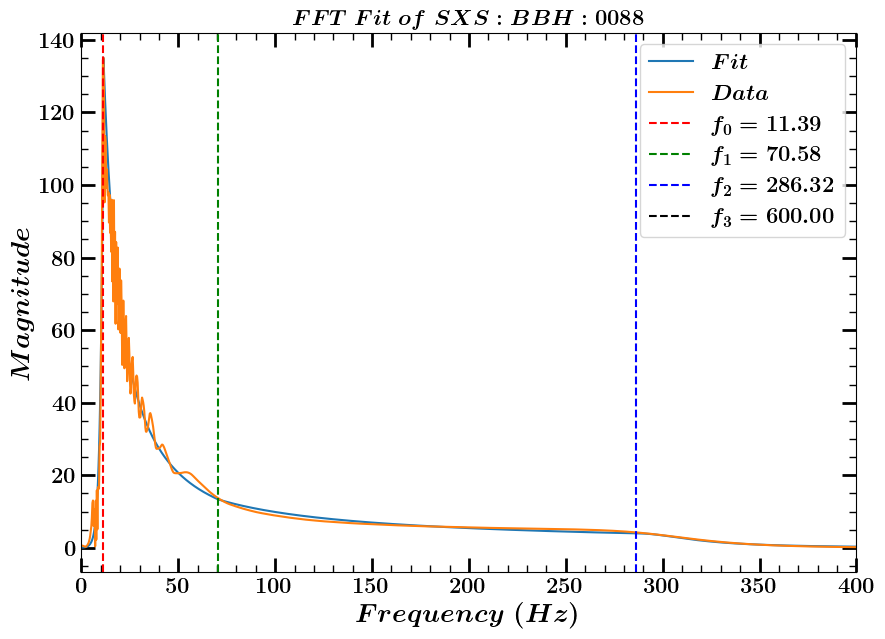

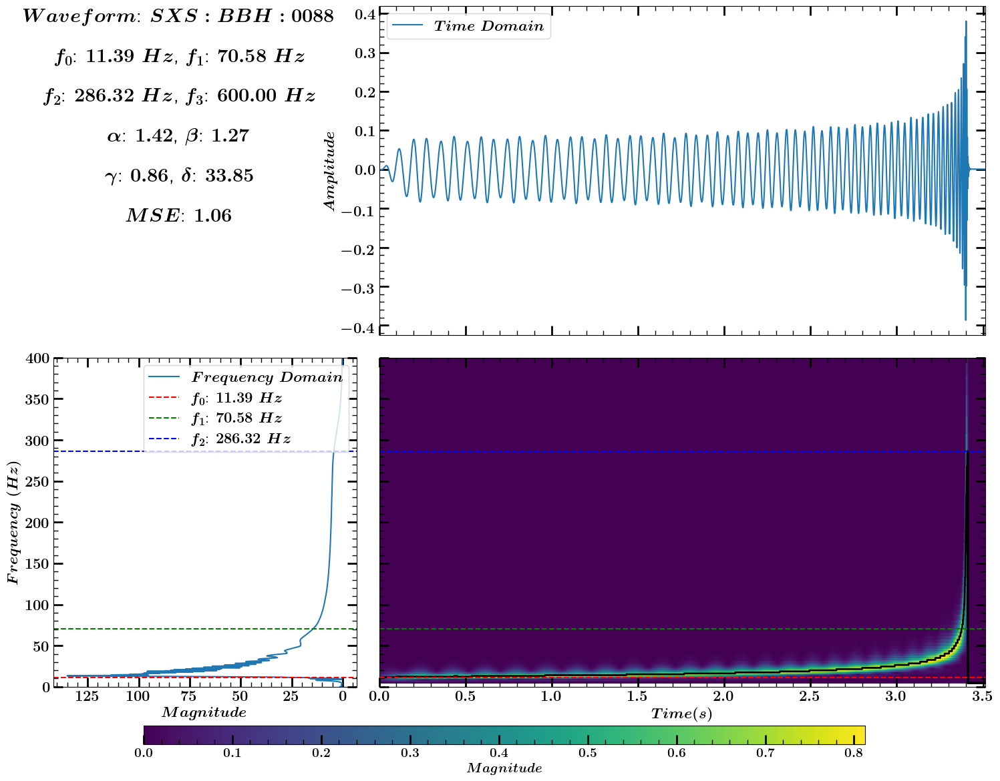

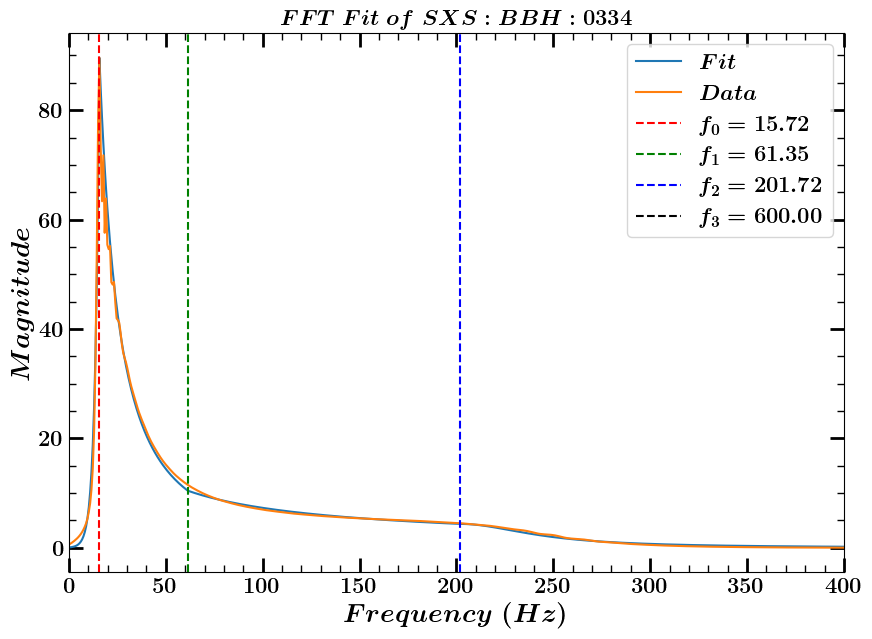

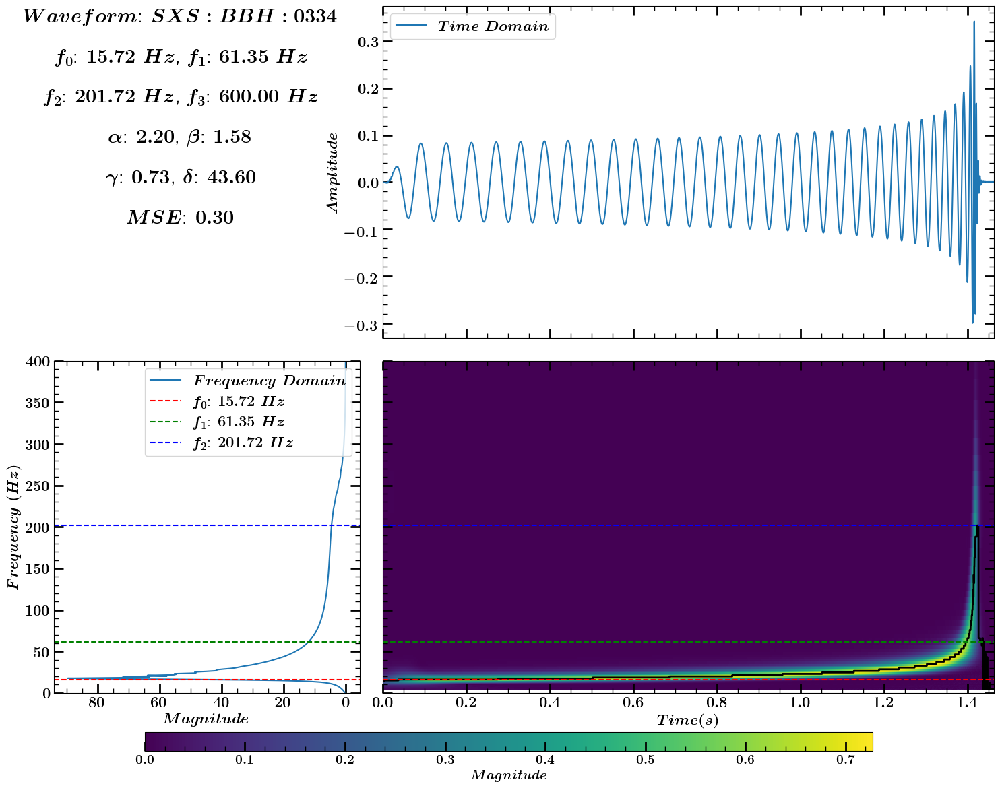

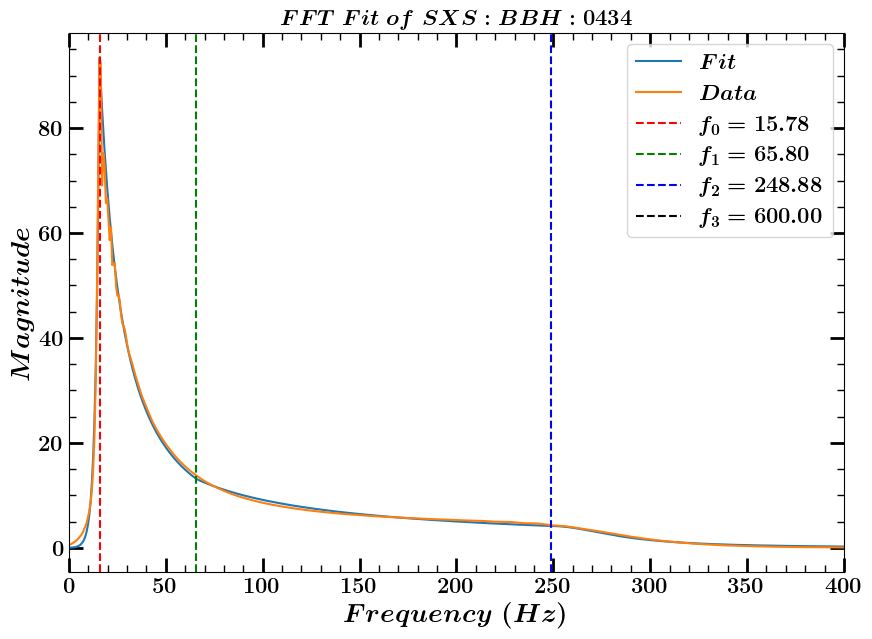

...

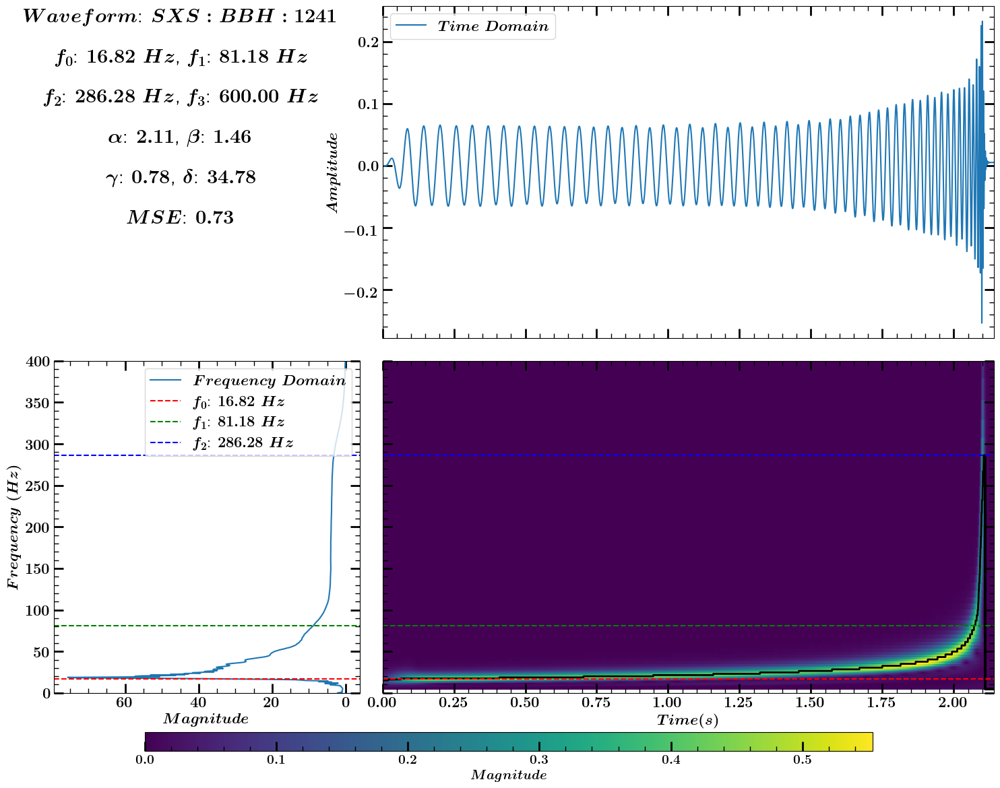

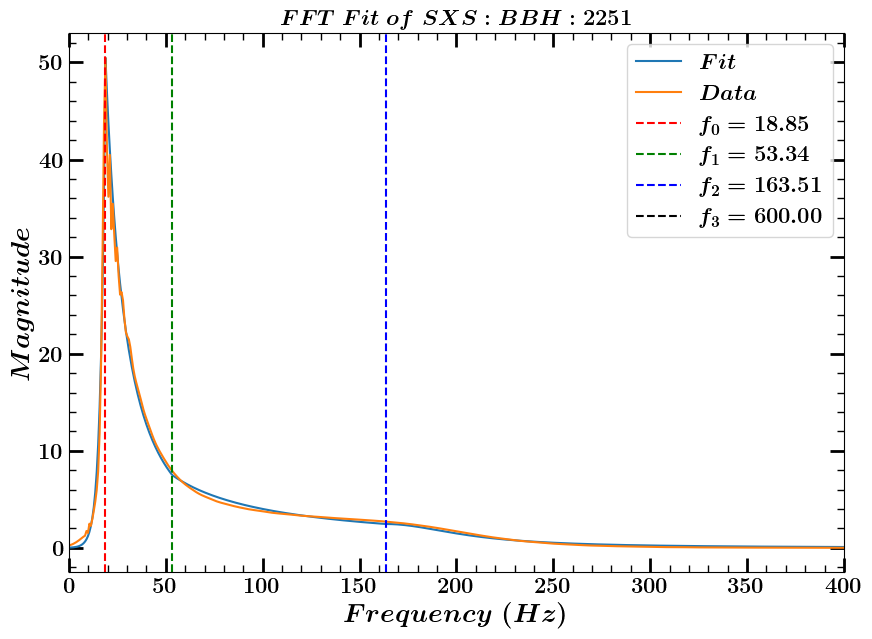

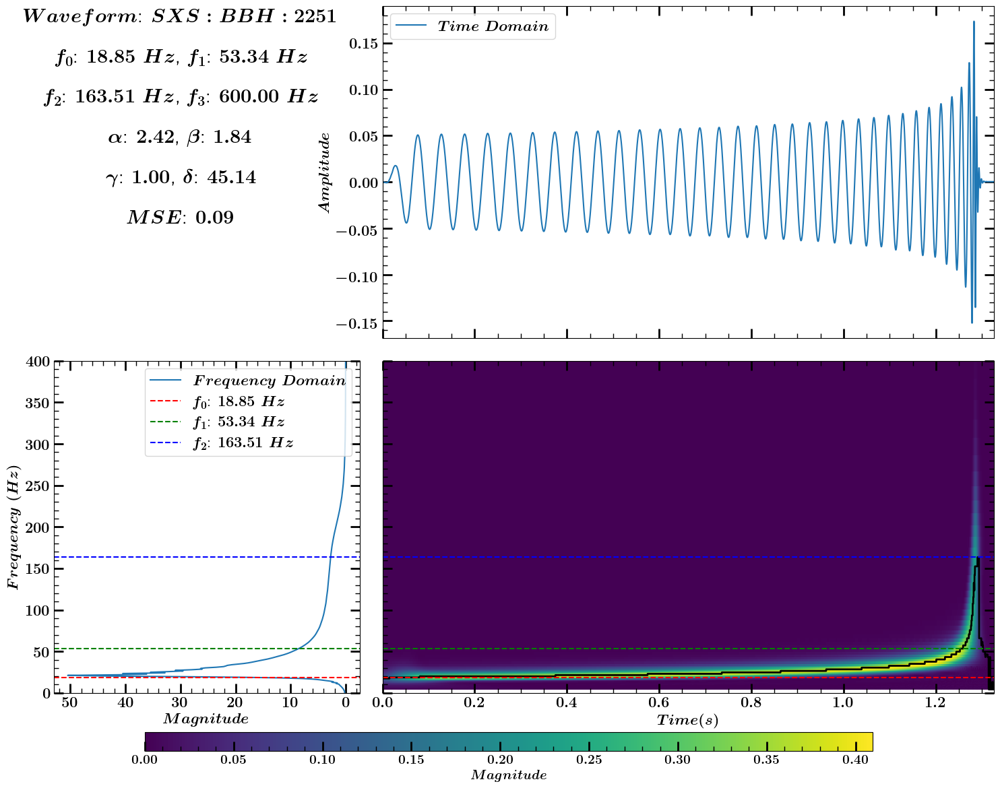

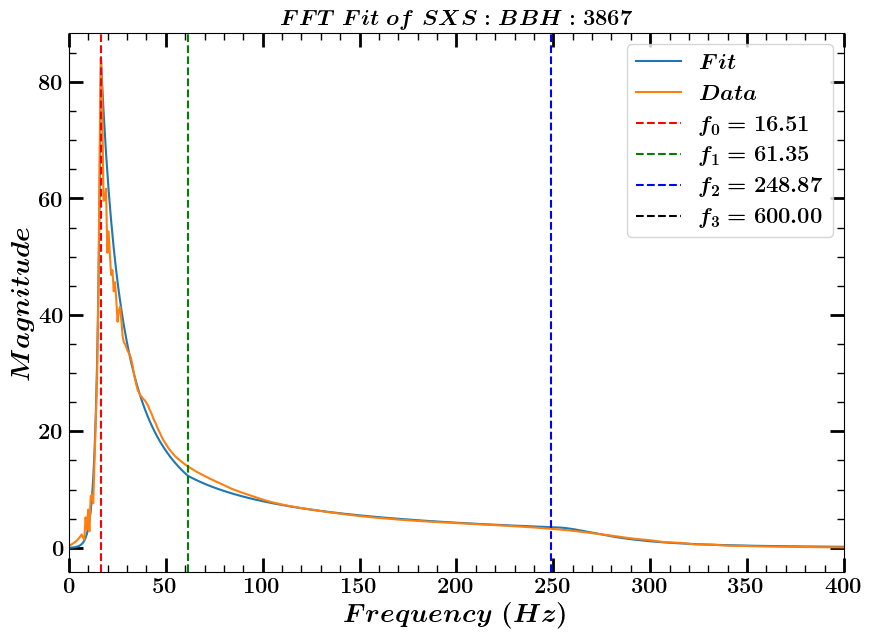

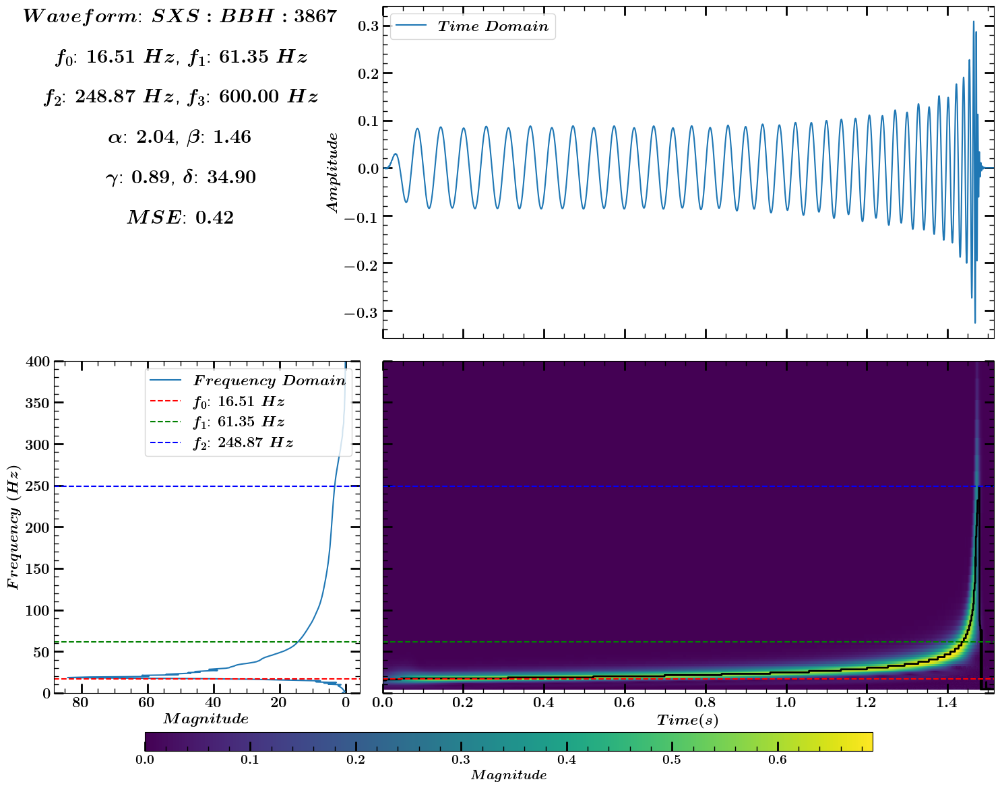

In [79]:
import logging 

i = 1
total_mass = 60

plot_shows = [10, 100, 200, 400, 500, 1000, 2000, 2400]
# plot_shows = [10]
# shows_report_dir = "/mnt/d/Darsh/MSThesis/template_model/graph/fit_2/plots_shows/report/"

for i in plot_shows:
    total_mass = 60
    waveform_name = new_index[i] + f"_M{total_mass}"
    a = 16
    with h5py.File(data_dir_all_wf + f'/preprocess_{total_mass}/{new_index[i]}_pp.h5', 'r') as f:
        time = f['time'][:]
        hp = f['plus'][:]

    with h5py.File(data_dir_all_wf + f'/fft_{total_mass}/{new_index[i]}_fft.h5', 'r') as f:
        freq = f['freq_p'][:]
        fft = np.abs(f['fft_p'][:])

    time_cwt, freq_cwt, cwtmatr = cwt(time, hp)
    folder_path = data_dir_fit + f'/M_{total_mass}'
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    with open(folder_path + f'/{new_index[i]}_cwt.pkl', 'wb') as f:
        pickle.dump({'time_cwt': time_cwt, 'freq_cwt': freq_cwt, 'cwtmatr': cwtmatr}, f)

    trace_cwt_idx = np.argmax(cwtmatr, axis=0)
    trace_cwt = freq_cwt[trace_cwt_idx]
    t_trace_cwt = np.linspace(time_cwt[0], time_cwt[-1], len(trace_cwt))

    with open(folder_path + f'/{new_index[i]}_cwt_trace.pkl', 'wb') as f:
        pickle.dump({'t_trace_cwt': t_trace_cwt, 'trace_cwt_smooth': trace_cwt}, f)

    f0 = freq[np.argmax(fft)]
    idx = np.argmax(trace_cwt)
    f2 = trace_cwt[idx]
    
    window = 15
    max_iterations = 5  # Set the maximum number of iterations
    iteration_count = 0  # Initialize the counter

    while True:
        trace_cwt_smooth = moving_average(trace_cwt, window)
        t_trace_cwt_smooth = t_trace_cwt[:len(trace_cwt_smooth)]
        idx_smooth = np.argmax(trace_cwt_smooth)
        curvature = compute_curvature_1d(t_trace_cwt_smooth[:idx_smooth], trace_cwt_smooth[:idx_smooth])
        max_curvature = np.argmax(curvature)
        f1 = trace_cwt_smooth[max_curvature]

        if 50 <= f1 <= 150 or window > len(trace_cwt) / 2:
            if window > len(trace_cwt) / 2:
                logging.warning("Smoothing window exceeded limit. Exiting loop.")
            break

        # Increment the counter each time the loop runs
        iteration_count += 1

        # Check if the number of iterations exceeds the maximum allowed
        if iteration_count >= max_iterations:
            logging.warning("Maximum iterations reached. Skipping this waveform.")
            break

        window += 5
    x, y = freq, fft
    f0, A0, x_crop, y_crop, y_crop_abs = params_fft(x, y, maxm=2048, details=False)
    f3 = 600

    def fit_fun(x, alpha, beta, gamma, delta):
        a = A0 / np.exp(f0 / alpha)
        b = a * np.exp(f0 / alpha) * f0**beta
        c = b * (f1)**(gamma - beta)
        d = c * (f2)**(-gamma)
        def lorentzian(x):
            return d / (1 + ((x - f2) / delta)**2)
        result = []
        for i in range(len(x)):
            if x[i] <= f0:
                result.append(a * np.exp(x[i] / alpha))
            elif f0 < x[i] <= f1:
                result.append(b * x[i]**(-beta))
            elif f1 < x[i] <= f2:
                result.append(c * x[i]** (-gamma))
            elif f2 < x[i]:
                result.append(lorentzian(x[i]))
        return np.array(result)

    p0 = [1, 1, 1, 1]
    fopt, fcov = curve_fit(fit_fun, x_crop, y_crop_abs, p0=p0)
    fit_final1 = fit_fun(x_crop, *fopt)

    alpha, beta, gamma, delta = fopt[0], fopt[1], fopt[2], fopt[3]
    mse_fit = mse(y_crop_abs, fit_final1)

    plt.figure(figsize=(10, 7))
    plt.plot(x_crop, fit_final1, label = r"$Fit$") 
    plt.plot(x_crop, y_crop_abs,label = r"$Data$")
    plt.axvline(x = f0, color = "red", linestyle = "--", label = rf"$f_0$ $=$ ${f0:.2f}$")
    plt.axvline(x = f1, color = "green", linestyle = "--", label =rf"$f_1$ $=$ ${f1:.2f}$")    
    plt.axvline(x = f2, color = "blue", linestyle = "--", label = rf"$f_2$ $=$ ${f2:.2f}$")
    plt.axvline(x = f3, color = "black", linestyle = "--", label =rf"$f_3$ $=$ ${f3:.2f}$")
    # plt.xscale("log")
    # plt.yscale("log")
    plt.xticks()
    plt.yticks()
    plt.legend()
    plt.xlabel(r"$Frequency$ $(Hz)$")
    plt.ylabel(r"$Magnitude$")
    plt.xlim(0, 400)
    plt.title(rf"$FFT$ $Fit$ $of$ ${replace(new_index[i])}$", fontsize=16)  # 'pad' moves the title down
    # plt.text(450, plt.ylim()[1] * 0.95,  # Adjust y to place inside the plot
    #         r"$MSE = {:.2f}$".format(mse_fit) + "\n" +
    #         r"$\alpha = {:.2f}, \gamma = {:.2f}, \delta = {:.2f}$".format(alpha, gamma, delta), 
    #         ha="center", va="top", fontsize=16, bbox=dict(facecolor='white', alpha=0.7, edgecolor='black'))
    plt.savefig(graph_dir_fit + f"/{waveform_name}_fit.pdf")
    plt.show()

    # Plotting the combined plots after fitting
    fig = plt.figure(figsize=(18, 14))
    # Create grid layout for precise alignment
    gs = fig.add_gridspec(3, 2, width_ratios=[1, 2], height_ratios=[1, 1, 0.05], hspace=0.1, wspace=0.05)

    # Time-domain plot (Top Right)
    ax_signal = fig.add_subplot(gs[0, 1])
    ax_signal.plot(time, hp, label=r"$Time$ $Domain$")
    ax_signal.set_xlim(time[0], time[-1])
    ax_signal.set_ylabel(r"$Amplitude$", fontsize = a)
    ax_signal.legend()
    ax_signal.tick_params(axis='both', which='major', labelsize= a)
    ax_signal.set_xticklabels([])  # Remove x-axis labels to share with CWT

    # Continuous Wavelet Transform (CWT) plot (Middle Right, extended to right end)
    ax_cwt = fig.add_subplot(gs[1, 1])
    im = ax_cwt.pcolormesh(time_cwt, freq_cwt, cwtmatr, shading="auto", rasterized=True)
    max_index = np.argmax(cwtmatr, axis = 0)
    max_freq_values = freq_cwt[max_index]
    ax_cwt.plot(time[:-1], max_freq_values, color='black', linewidth=2, label="Max Magnitude Curve")
    ax_cwt.set_xlabel(r"$Time (s)$", fontsize= a)   
    ax_cwt.set_xlim(time[0], time[-1])
    ax_cwt.set_ylim(0, 400)
    ax_cwt.tick_params(axis='both', which='major', labelsize=a)
    ax_cwt.set_yticklabels([])

    # FFT plot (Left Middle)
    ax_fft = fig.add_subplot(gs[1, 0])
    ax_fft.plot(fft, freq, label=r"$Frequency$ $Domain$")
    ax_fft.set_xlabel(r"$Magnitude$", fontsize= a)
    ax_fft.set_ylabel(r"$Frequency$ $(Hz)$", fontsize= a)
    ax_fft.legend()
    ax_fft.set_ylim(0, 400)
    ax_fft.invert_xaxis()  # Flip for alignment
    ax_fft.tick_params(axis='both', which='major', labelsize= a)

    # Draw horizontal lines at f0, f1, and f2
    ax_cwt.axhline(y=f0, color='r', linestyle='--')
    ax_fft.axhline(y=f0, color='r', linestyle='--', label=rf'$f_{0}$: ${f0:.2f}$ $Hz$')
    ax_fft.axhline(y=f1, color='g', linestyle='--', label=rf'$f_{1}$: ${f1:.2f}$ $Hz$')
    ax_fft.axhline(y=f2, color='b', linestyle='--', label=rf'$f_{2}$: ${f2:.2f}$ $Hz$')
    ax_cwt.axhline(y=f1, color='g', linestyle='--')
    ax_cwt.axhline(y=f2, color='b', linestyle='--')
    ax_fft.legend(loc='upper right')

    # Magnitude color bar at the bottom, below the CWT plot
    cbar_ax = fig.add_axes([0.2, 0.09, 0.6, 0.02])  # Adjust placement
    cbar = plt.colorbar(im, cax=cbar_ax, orientation="horizontal")
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label(r"$Magnitude$", fontsize=14)

    # Add text box in the left blank space
    waveform_name = new_index[i] + f"_M{total_mass}"
    fig.text(0.23, 0.65, 
            rf"$Waveform$: ${replace(new_index[i])}$" "\n\n" +
            rf"$f_0$: ${f0:.2f}$ $Hz$, $f_1$: ${f1:.2f}$ $Hz$" "\n\n" +
            rf"$f_2$: ${f2:.2f}$ $Hz$, $f_3$: ${f3:.2f}$ $Hz$" "\n\n" +
            rf"$\alpha$: ${alpha:.2f}$, $\beta$: ${beta:.2f}$" "\n\n" +
            rf"$\gamma$: ${gamma:.2f}$, $\delta$: ${delta:.2f}$" "\n\n" +
            rf"$MSE$: ${mse_fit:.2f}$",
            fontsize=a + 5, rotation='horizontal',
            ha="center")
    plt.savefig(graph_dir_fit + f"/{waveform_name}_all3.pdf")
    plt.show()

#### Code for visulaizing the fit and plot of waveform analysis for SXS:BBH:0305

THESIS: Figure 2.5, Figure 2.6, Figure 2.7 respectively.

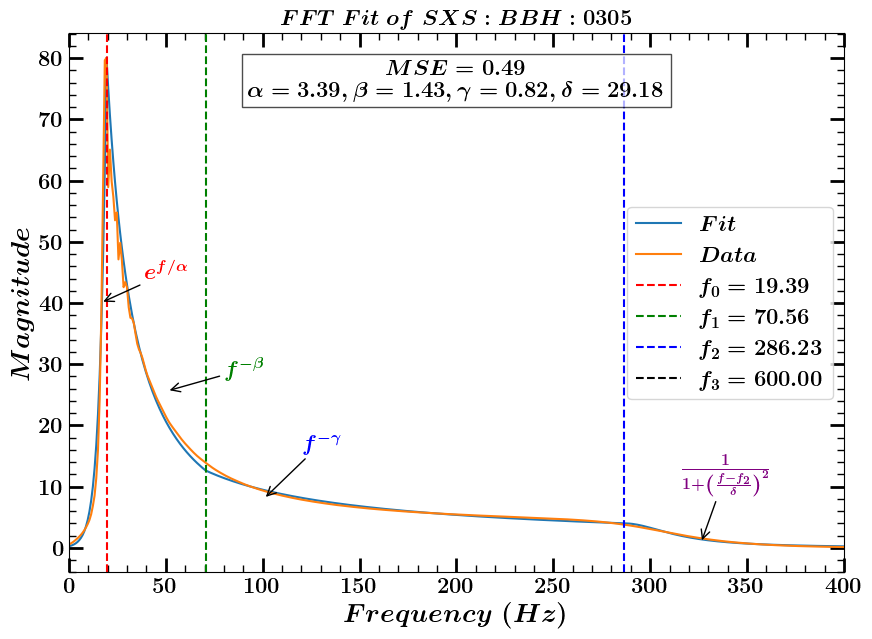

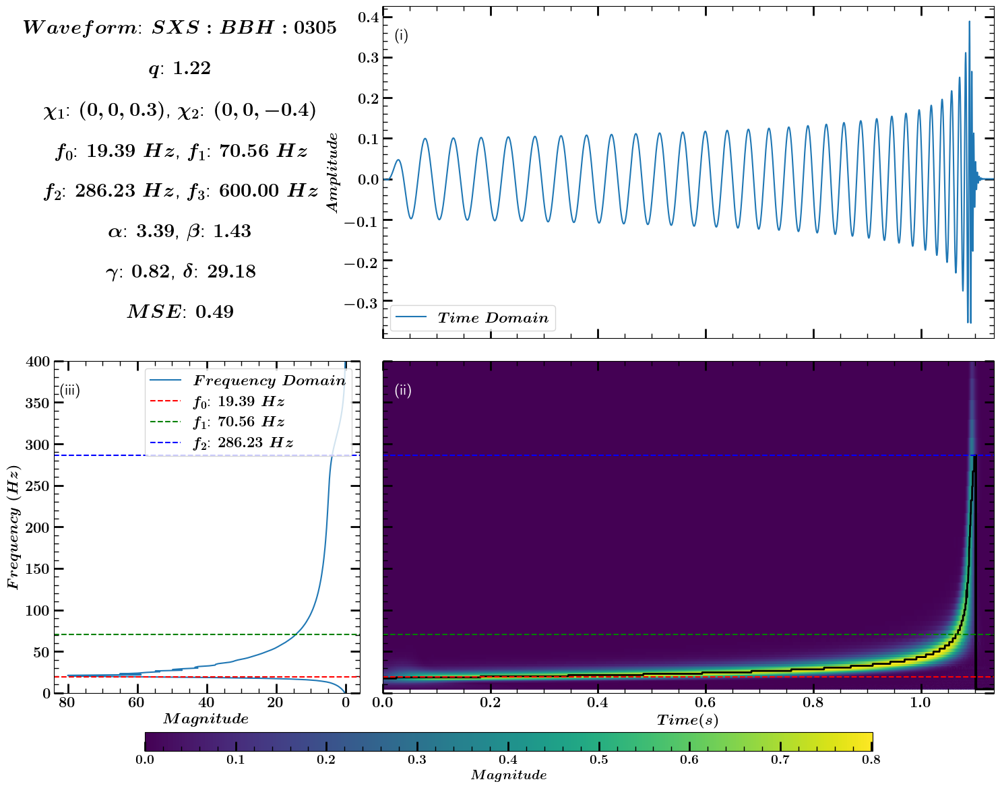

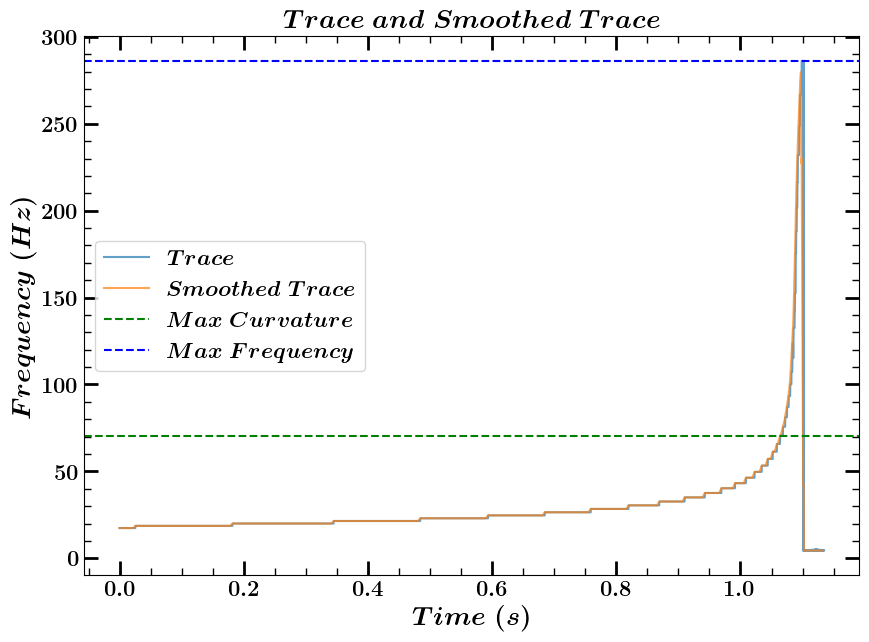

In [80]:
i = 1
total_mass = 60
xlim = 400

plot_shows = [71]
# plot_shows = [10]

for i in plot_shows:
    total_mass = 60
    waveform_name = new_index[i] + f"_M{total_mass}"
    a = 16
    with h5py.File(data_dir_all_wf + f'/preprocess_{total_mass}/{new_index[i]}_pp.h5', 'r') as f:
        time = f['time'][:]
        hp = f['plus'][:]

    with h5py.File(data_dir_all_wf + f'/fft_{total_mass}/{new_index[i]}_fft.h5', 'r') as f:
        freq = f['freq_p'][:]
        fft = np.abs(f['fft_p'][:])

    time_cwt, freq_cwt, cwtmatr = cwt(time, hp)
    folder_path = data_dir_all_wf + f'M_{total_mass}'
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    with open(folder_path + f'/{new_index[i]}_cwt.pkl', 'wb') as f:
        pickle.dump({'time_cwt': time_cwt, 'freq_cwt': freq_cwt, 'cwtmatr': cwtmatr}, f)

    trace_cwt_idx = np.argmax(cwtmatr, axis=0)
    trace_cwt = freq_cwt[trace_cwt_idx]
    t_trace_cwt = np.linspace(time_cwt[0], time_cwt[-1], len(trace_cwt))

    with open(folder_path + f'/{new_index[0]}_cwt_trace.pkl', 'wb') as f:
        pickle.dump({'t_trace_cwt': t_trace_cwt, 'trace_cwt_smooth': trace_cwt}, f)

    f0 = freq[np.argmax(fft)]
    idx = np.argmax(trace_cwt)
    f2 = trace_cwt[idx]
    
    window = 15
    max_iterations = 5  # Set the maximum number of iterations
    iteration_count = 0  # Initialize the counter

    while True:
        trace_cwt_smooth = moving_average(trace_cwt, window)
        t_trace_cwt_smooth = t_trace_cwt[:len(trace_cwt_smooth)]
        idx_smooth = np.argmax(trace_cwt_smooth)
        curvature = compute_curvature_1d(t_trace_cwt_smooth[:idx_smooth], trace_cwt_smooth[:idx_smooth])
        max_curvature = np.argmax(curvature)


        f1 = trace_cwt_smooth[max_curvature]

        if 50 <= f1 <= 150 or window > len(trace_cwt) / 2:
            break

        # Increment the counter each time the loop runs
        iteration_count += 1
        if iteration_count >= max_iterations:
            break

        window += 5
    x, y = freq, fft
    f0, A0, x_crop, y_crop, y_crop_abs = params_fft(x, y, maxm=2048, details=False)
    f3 = 600

    def fit_fun(x, alpha, beta, gamma, delta):
        a = A0 / np.exp(f0 / alpha)
        b = a * np.exp(f0 / alpha) * f0**beta
        c = b * (f1)**(gamma - beta)
        d = c * (f2)**(-gamma)
        def lorentzian(x):
            return d / (1 + ((x - f2) / delta)**2)
        result = []
        for i in range(len(x)):
            if x[i] <= f0:
                result.append(a * np.exp(x[i] / alpha))
            elif f0 < x[i] <= f1:
                result.append(b * x[i]**(-beta))
            elif f1 < x[i] <= f2:
                result.append(c * x[i]** (-gamma))
            elif f2 < x[i]:
                result.append(lorentzian(x[i]))
        return np.array(result)

    p0 = [1, 1, 1, 1]
    fopt, fcov = curve_fit(fit_fun, x_crop, y_crop_abs, p0=p0)
    fit_final1 = fit_fun(x_crop, *fopt)

    alpha, beta, gamma, delta = fopt[0], fopt[1], fopt[2], fopt[3]
    mse_fit = mse(y_crop_abs, fit_final1)

    plt.figure(figsize=(10, 7))
    plt.plot(x_crop, fit_final1, label = r"$Fit$") 
    plt.plot(x_crop, y_crop_abs,label = r"$Data$")
    plt.grid(False)
    plt.axvline(x = f0, color = "red", linestyle = "--", label = rf"$f_0$ $=$ ${f0:.2f}$")
    plt.axvline(x = f1, color = "green", linestyle = "--", label =rf"$f_1$ $=$ ${f1:.2f}$")    
    plt.axvline(x = f2, color = "blue", linestyle = "--", label = rf"$f_2$ $=$ ${f2:.2f}$")
    plt.axvline(x = f3, color = "black", linestyle = "--", label =rf"$f_3$ $=$ ${f3:.2f}$")

    # Adding annotations after each vertical line with arrows
    plt.annotate(r"$e^{f/\alpha}$", xy=(f0 - 3, max(y_crop_abs) * 0.5), xytext=(f0 + 20, max(y_crop_abs) * 0.55),
                arrowprops=dict(facecolor='red', arrowstyle='->'), fontsize=16, color='red')

    plt.annotate(r"$f^{-\beta}$", xy=(f1 - 20, max(y_crop_abs) * 0.32), xytext=(f1 + 10, max(y_crop_abs) * 0.35),
                arrowprops=dict(facecolor='green', arrowstyle='->'), fontsize=16, color='green')

    plt.annotate(r"$f^{-\gamma}$", xy=(f1 + 30, max(y_crop_abs) * 0.10), xytext=(f1 + 50, max(y_crop_abs) * 0.20),
                arrowprops=dict(facecolor='blue', arrowstyle='->'), fontsize=16, color='blue')

    plt.annotate(r"$\frac{1}{1 + \left(\frac{f - f_{2}}{\delta}\right)^2}$", xy=(f2 + 40, max(y_crop_abs) * 0.01), xytext=(f2 + 30, max(y_crop_abs) * 0.15),
                arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=16, color='purple')

    # plt.xscale("log")
    # plt.yscale("log")
    plt.xticks()
    plt.yticks()
    plt.legend()
    plt.xlabel(r"$Frequency$ $(Hz)$")
    plt.ylabel(r"$Magnitude$")
    plt.xlim(0, xlim)
    plt.title(rf"$FFT$ $Fit$ $of$ ${replace(new_index[i])}$", fontsize=16)  # 'pad' moves the title down

    plt.text(int(xlim/2), plt.ylim()[1] * 0.95,  # Adjust y to place inside the plot
            r"$MSE = {:.2f}$".format(mse_fit) + "\n" +
            r"$\alpha = {:.2f}, \beta = {:.2f}, \gamma = {:.2f}, \delta = {:.2f}$".format(alpha, beta, gamma, delta), 
            ha="center", va="top", fontsize=16, bbox=dict(facecolor='white', alpha=0.7, edgecolor='black'))
    plt.savefig(graph_dir_fit + f"/{waveform_name}_fit.pdf")
    plt.show()

    # Plotting the combined plots after fitting
    fig = plt.figure(figsize=(18, 14))
    # Create grid layout for precise alignment
    gs = fig.add_gridspec(3, 2, width_ratios=[1, 2], height_ratios=[1, 1, 0.05], hspace=0.1, wspace=0.05)

    # Time-domain plot (Top Right)
    ax_signal = fig.add_subplot(gs[0, 1])
    ax_signal.plot(time, hp, label=r"$Time$ $Domain$")
    ax_signal.set_xlim(time[0], time[-1])
    ax_signal.set_ylabel(r"$Amplitude$", fontsize=a)
    ax_signal.legend()
    ax_signal.grid(False)
    ax_signal.tick_params(axis='both', which='major', labelsize=a)
    ax_signal.set_xticklabels([])  # Remove x-axis labels to share with CWT

    # Add label (i) for the time-domain plot
    ax_signal.text(0.02, 0.9, "(i)", transform=ax_signal.transAxes, fontsize=16, fontweight='bold', color='black')

    # Continuous Wavelet Transform (CWT) plot (Middle Right, extended to right end)
    ax_cwt = fig.add_subplot(gs[1, 1])
    im = ax_cwt.pcolormesh(time_cwt, freq_cwt, cwtmatr, shading="auto", rasterized=True)
    max_index = np.argmax(cwtmatr, axis=0)
    max_freq_values = freq_cwt[max_index]
    ax_cwt.plot(time[:-1], max_freq_values, color='black', linewidth=2, label="Max Magnitude Curve")
    ax_cwt.set_xlabel(r"$Time (s)$", fontsize=a)
    ax_cwt.set_xlim(time[0], time[-1])
    ax_cwt.set_ylim(0, 400)
    ax_cwt.grid(False)
    ax_cwt.tick_params(axis='both', which='major', labelsize=a)
    ax_cwt.set_yticklabels([])

    # Add label (ii) for the CWT plot in white color
    ax_cwt.text(0.02, 0.9, "(ii)", transform=ax_cwt.transAxes, fontsize=16, fontweight='bold', color='white')

    # FFT plot (Left Middle)
    ax_fft = fig.add_subplot(gs[1, 0])
    ax_fft.plot(fft, freq, label=r"$Frequency$ $Domain$")
    ax_fft.set_xlabel(r"$Magnitude$", fontsize=a)
    ax_fft.set_ylabel(r"$Frequency$ $(Hz)$", fontsize=a)
    ax_fft.legend()
    ax_fft.grid(False)
    ax_fft.set_ylim(0, 400)
    ax_fft.invert_xaxis()  # Flip for alignment
    ax_fft.tick_params(axis='both', which='major', labelsize=a)

    # Add label (iii) for the FFT plot
    ax_fft.text(0.02, 0.9, "(iii)", transform=ax_fft.transAxes, fontsize=16, fontweight='bold', color='black')

    # Draw horizontal lines at f0, f1, and f2
    ax_cwt.axhline(y=f0, color='r', linestyle='--')
    ax_fft.axhline(y=f0, color='r', linestyle='--', label=rf'$f_{0}$: ${f0:.2f}$ $Hz$')
    ax_fft.axhline(y=f1, color='g', linestyle='--', label=rf'$f_{1}$: ${f1:.2f}$ $Hz$')
    ax_fft.axhline(y=f2, color='b', linestyle='--', label=rf'$f_{2}$: ${f2:.2f}$ $Hz$')
    ax_cwt.axhline(y=f1, color='g', linestyle='--')
    ax_cwt.axhline(y=f2, color='b', linestyle='--')
    ax_fft.legend(loc='upper right')

    # Magnitude color bar at the bottom, below the CWT plot
    cbar_ax = fig.add_axes([0.2, 0.09, 0.6, 0.02])  # Adjust placement
    cbar = plt.colorbar(im, cax=cbar_ax, orientation="horizontal")
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label(r"$Magnitude$", fontsize=14)

    # Add text box in the left blank space
    waveform_name = new_index[i] + f"_M{total_mass}"
    fig.text(0.23, 0.55, 
            rf"$Waveform$: ${replace(new_index[i])}$" "\n\n" +
            rf"$q$: $1.22$" "\n\n" +
            rf"$\chi_{1}$: $(0, 0, 0.3)$, $\chi_{2}$: $(0, 0, -0.4)$" "\n\n" +
            rf"$f_0$: ${f0:.2f}$ $Hz$, $f_1$: ${f1:.2f}$ $Hz$" "\n\n" +
            rf"$f_2$: ${f2:.2f}$ $Hz$, $f_3$: ${f3:.2f}$ $Hz$" "\n\n" +
            rf"$\alpha$: ${alpha:.2f}$, $\beta$: ${beta:.2f}$" "\n\n" +
            rf"$\gamma$: ${gamma:.2f}$, $\delta$: ${delta:.2f}$" "\n\n" +
            rf"$MSE$: ${mse_fit:.2f}$",
            fontsize=a + 5, rotation='horizontal',
            ha="center")
    plt.savefig(graph_dir_fit + f"/{waveform_name}_all3.pdf")
    plt.show()

        # Plot the trace, smoothed trace, and horizontal line for maximum curvature
    plt.figure(figsize=(10, 7))
    plt.plot(t_trace_cwt, trace_cwt, label=r"$Trace$", alpha=0.7)
    plt.plot(t_trace_cwt_smooth, trace_cwt_smooth, label=r"$Smoothed$ $Trace$", alpha=0.7)
    plt.axhline(y=trace_cwt_smooth[max_curvature], color='g', linestyle='--', label=r"$Max$ $Curvature$")
    plt.axhline(y=trace_cwt[np.argmax(trace_cwt)], color='blue', linestyle='--', label=r"$Max$ $Frequency$")
    plt.xlabel(r"$Time$ $(s)$")
    plt.ylabel(r"$Frequency$ $(Hz)$")
    plt.title(r"$Trace$ $and$ $Smoothed$ $Trace$")
    plt.legend()
    plt.grid(False)
    plt.savefig(graph_dir_fit + f"/{waveform_name}_trace.pdf")
    plt.show()

#### Plotting FFTs for different mass ratio but same total mass of the system

THESIS: Figure 2.8

/tmp/ipykernel_532223/3958080612.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  q = df_BBH["reference_mass_ratio"][plot_shows] # type: ignore # Extracting the mass ratio for the selected indices


The list of Mass Ratio is:  SXS:BBH:0088    1.000459
SXS:BBH:0334    1.999806
SXS:BBH:0434    1.335880
SXS:BBH:0534    1.984150
SXS:BBH:0634    1.000020
SXS:BBH:0734    1.999732
SXS:BBH:0834    1.000087
SXS:BBH:0934    1.999817
SXS:BBH:1034    1.352437
SXS:BBH:1141    1.000000
SXS:BBH:1241    3.499693
SXS:BBH:1341    2.999704
Name: reference_mass_ratio, dtype: float64


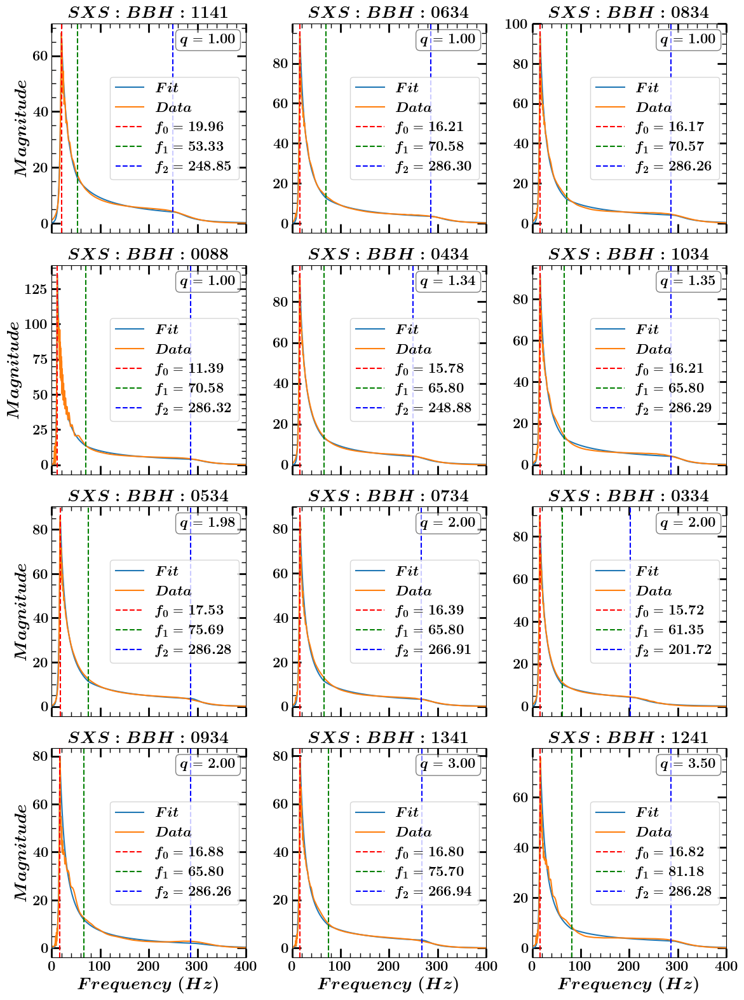

In [81]:
# main_dirs = "/mnt/d/Darsh/MSThesis/numerical_relativity/dataset/sxs/"
# df_bbh = pd.read_csv(main_dirs + "bbh.csv")

# Indices whose values are to be plotted
plot_shows = [10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100]
q = df_BBH["reference_mass_ratio"][plot_shows] # type: ignore # Extracting the mass ratio for the selected indices
print("The list of Mass Ratio is: ", q)


# Sort plot_shows based on the increasing order of q
sorted_indices = np.argsort(q.values)
plot_shows_sorted = [plot_shows[i] for i in sorted_indices]
q_sorted = q.iloc[sorted_indices]

# Update the number of plots
num_plots = len(plot_shows_sorted)

# Define subplot grid
cols = 3  # Two plots per row
rows = (num_plots + cols - 1) // cols  # Ensure enough rows

fig, axes = plt.subplots(rows, cols, figsize=(12, 16), sharex = True)
axes = axes.flatten()  # Flatten axes to ensure indexing works

for plot_idx, i in enumerate(plot_shows_sorted):
    waveform_name = new_index[i] + f"_M{total_mass}"
    
    # Load time-domain signal
    with h5py.File(data_dir_all_wf + f'/preprocess_{total_mass}/{new_index[i]}_pp.h5', 'r') as f:
        time = f['time'][:]
        hp = f['plus'][:]

    # Load FFT
    with h5py.File(data_dir_all_wf + f'/fft_{total_mass}/{new_index[i]}_fft.h5', 'r') as f:
        freq = f['freq_p'][:]
        fft = np.abs(f['fft_p'][:])

    # Compute CWT
    time_cwt, freq_cwt, cwtmatr = cwt(time, hp)

    # Compute CWT ridge trace
    trace_cwt_idx = np.argmax(cwtmatr, axis=0)
    trace_cwt = freq_cwt[trace_cwt_idx]
    t_trace_cwt = np.linspace(time_cwt[0], time_cwt[-1], len(trace_cwt))

    f0 = freq[np.argmax(fft)]
    max_idx = np.argmax(trace_cwt)  # Rename idx to max_idx
    f2 = trace_cwt[max_idx]
    
    window = 15
    max_iterations = 5
    iteration_count = 0

    while True:
        trace_cwt_smooth = moving_average(trace_cwt, window)
        t_trace_cwt_smooth = t_trace_cwt[:len(trace_cwt_smooth)]
        idx_smooth = np.argmax(trace_cwt_smooth)
        curvature = compute_curvature_1d(t_trace_cwt_smooth[:idx_smooth], trace_cwt_smooth[:idx_smooth])
        max_curvature = np.argmax(curvature)

        f1 = trace_cwt_smooth[max_curvature]

        if 50 <= f1 <= 150 or window > len(trace_cwt) / 2:
            break

        iteration_count += 1
        if iteration_count >= max_iterations:
            break

        window += 5
        
    # Compute FFT fit parameters
    x, y = freq, fft
    f0, A0, x_crop, y_crop, y_crop_abs = params_fft(x, y, maxm=2048, details=False)
    
    def fit_fun(x, alpha, beta, gamma, delta):
        a = A0 / np.exp(f0 / alpha)
        b = a * np.exp(f0 / alpha) * f0**beta
        c = b * (f1)**(gamma - beta)
        d = c * (f2)**(-gamma)
        
        def lorentzian(x):
            return d / (1 + ((x - f2) / delta)**2)
        
        result = []
        for val in x:
            if val <= f0:
                result.append(a * np.exp(val / alpha))
            elif f0 < val <= f1:
                result.append(b * val**(-beta))
            elif f1 < val <= f2:
                result.append(c * val**(-gamma))
            elif f2 < val:
                result.append(lorentzian(val))
        return np.array(result)

    p0 = [1, 1, 1, 1]
    fopt, _ = curve_fit(fit_fun, x_crop, y_crop_abs, p0=p0)
    fit_final1 = fit_fun(x_crop, *fopt)

    alpha, beta, gamma, delta = fopt
    mse_fit = mse(y_crop_abs, fit_final1)

    # Plot on respective subplot
    ax = axes[plot_idx] if num_plots > 1 else axes  # Use plot_idx instead of idx
    ax.plot(x_crop, fit_final1, label=r"$Fit$")
    ax.plot(x_crop, y_crop_abs, label=r"$Data$")
    ax.grid(False)
    ax.axvline(x=f0, color="red", linestyle="--", label=rf"$f_0$ = ${f0:.2f}$")
    ax.axvline(x=f1, color="green", linestyle="--", label=rf"$f_1$ = ${f1:.2f}$")
    ax.axvline(x=f2, color="blue", linestyle="--", label=rf"$f_2$ = ${f2:.2f}$")
    # ax.axvline(x=600, color="black", linestyle="--", label=rf"$f_3$ = $600$")
    ax.text(0.95, 0.95, rf"$q$ = ${q_sorted.iloc[plot_idx]:.2f}$", transform=ax.transAxes, verticalalignment='top', horizontalalignment='right', 
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))

    # Set x-axis label only for bottom-most plots
    if plot_idx >= (rows - 1) * cols:
        ax.set_xlabel(r"$Frequency$ $(Hz)$")
    
    # Set y-axis label only for left-most plots
    if plot_idx % cols == 0:
        ax.set_ylabel(r"$Magnitude$")
    ax.set_xlim(0, 400)
    ax.set_title(rf"${replace(new_index[i])}$")
    ax.legend()

# Adjust layout for clarity
plt.tight_layout()
plt.savefig(graph_dir_fit + f"/fft_fits_qs_multi.pdf")
plt.show()

## Part 4 - Combining the data of fitting parameters to form NN Table

### Important logistics and paths for the Part 4.

##### Importing the essential libraries

In [82]:
import sxs
import numpy as np 
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import sys 
import numpy as np
import h5py
import ast
import seaborn as sns
import pandas as pd
import pickle

##### Defining the paths for this section

In [83]:
folder_name = "nn"

# Get the current working directory
current_path = os.getcwd()
print("Current Path:", current_path)


# Define paths
folder_dir = os.path.join(current_path, folder_name)
data_dir = os.path.join(folder_dir, "dataset")
graph_dir = os.path.join(folder_dir, "graph")

# Check and create directories only if they don't exist
if not os.path.exists(folder_dir):
    os.makedirs(data_dir)
    os.makedirs(graph_dir)
    print("Directories created.")
else:
    print("Directories already exist. Nothing done.")

# Optional: print the paths for later use
print("Folder Path:", folder_dir)
print("Data Path:", data_dir)
print("Graph Path:", graph_dir)


Current Path: /mnt/d/Darsh/MSThesis/Final Code MS
Directories already exist. Nothing done.
Folder Path: /mnt/d/Darsh/MSThesis/Final Code MS/nn
Data Path: /mnt/d/Darsh/MSThesis/Final Code MS/nn/dataset
Graph Path: /mnt/d/Darsh/MSThesis/Final Code MS/nn/graph


In [84]:
# data_dir_fit

data_dir_spinless = os.path.join(data_dir, "spinless")
if not os.path.exists(data_dir_spinless):
    os.makedirs(data_dir_spinless)

graph_dir_spinless = os.path.join(graph_dir, "spinless")
if not os.path.exists(graph_dir_spinless):
    os.makedirs(graph_dir_spinless)

data_dir_spin = os.path.join(data_dir, "spin")
if not os.path.exists(data_dir_spin):
    os.makedirs(data_dir_spin)

graph_dir_spin = os.path.join(graph_dir, "spin")
if not os.path.exists(graph_dir_spin):
    os.makedirs(graph_dir_spin)

# Load the indices if not loaded above 
try:
    print(new_index)
    print("The new index is already loaded")
except:
    with open(data_dir_spinless + "/new_index.pkl", 'rb') as f:
        new_index = pickle.load(f)
    print("The new index is loaded from the file")

['SXS_BBH_0058', 'SXS_BBH_0059', 'SXS_BBH_0060', 'SXS_BBH_0065', 'SXS_BBH_0069', 'SXS_BBH_0074', 'SXS_BBH_0078', 'SXS_BBH_0082', 'SXS_BBH_0083', 'SXS_BBH_0087', 'SXS_BBH_0088', 'SXS_BBH_0089', 'SXS_BBH_0091', 'SXS_BBH_0092', 'SXS_BBH_0094', 'SXS_BBH_0097', 'SXS_BBH_0098', 'SXS_BBH_0100', 'SXS_BBH_0105', 'SXS_BBH_0106', 'SXS_BBH_0108', 'SXS_BBH_0109', 'SXS_BBH_0111', 'SXS_BBH_0114', 'SXS_BBH_0147', 'SXS_BBH_0160', 'SXS_BBH_0161', 'SXS_BBH_0163', 'SXS_BBH_0164', 'SXS_BBH_0165', 'SXS_BBH_0170', 'SXS_BBH_0171', 'SXS_BBH_0172', 'SXS_BBH_0175', 'SXS_BBH_0176', 'SXS_BBH_0177', 'SXS_BBH_0178', 'SXS_BBH_0179', 'SXS_BBH_0185', 'SXS_BBH_0186', 'SXS_BBH_0188', 'SXS_BBH_0189', 'SXS_BBH_0192', 'SXS_BBH_0194', 'SXS_BBH_0195', 'SXS_BBH_0196', 'SXS_BBH_0198', 'SXS_BBH_0199', 'SXS_BBH_0200', 'SXS_BBH_0201', 'SXS_BBH_0202', 'SXS_BBH_0203', 'SXS_BBH_0204', 'SXS_BBH_0205', 'SXS_BBH_0206', 'SXS_BBH_0207', 'SXS_BBH_0208', 'SXS_BBH_0259', 'SXS_BBH_0292', 'SXS_BBH_0293', 'SXS_BBH_0294', 'SXS_BBH_0295', 'SXS_BB

### Combining the dataset of fitting parameters

##### Combining all the CSV files together to form the single CSV file and then importing it

In [85]:
print(data_dir_fit)

/mnt/d/Darsh/MSThesis/Final Code MS/model_fft/dataset/fit


In [86]:
# Define the range of M values
M = np.arange(40, 95)
df_list = [] # Initialize an empty list to store DataFrames

# for i in range(len(M)):
#     file_name = f"/Params_{M[i]}.csv"
#     df = pd.read_csv(data_dir_fit + file_name)  # Read CSV file
#     df_list.append(df)  # Append to the list

# # Concatenate all DataFrames along the rows (axis=0)
# final_df = pd.concat(df_list, axis=0, ignore_index=True)
# # Save the merged DataFrame to a new CSV file
# final_df.to_csv(data_dir_fit + "/Params_M40-M95.csv", index=False)
# print("Merged CSV saved as Params_M40-M95.csv")

# Load the merged DataFrame
df_fitparams = pd.read_csv(data_dir_fit + "/Params_M40-M95.csv")
df_fitparams

,name,f0,f1,f2,A0,alpha,beta,gamma,delta,mse,window
0,SXS_BBH_0059_M40,55.929317,100.034136,328.903444,17.174137,11.180508,2.155797,0.918627,59.574719,0.063471,15
1,SXS_BBH_0078_M40,24.870299,93.383573,435.738601,70.585285,3.059558,1.442149,0.814286,41.643413,0.511862,15
2,SXS_BBH_0060_M40,28.135936,81.176167,286.256797,44.197113,2.794433,1.653201,1.108373,62.091040,0.096185,15
3,SXS_BBH_0082_M40,26.907396,93.367823,435.665107,63.231214,3.173450,1.439143,0.974536,47.524643,0.349197,15
4,SXS_BBH_0058_M40,27.526882,93.385217,232.043840,43.848440,2.532740,1.784379,0.555268,78.801744,0.792715,15
...,...,...,...,...,...,...,...,...,...,...,...
136175,SXS_BBH_3981_M94,10.323324,135.747482,163.523037,164.133964,1.089670,1.295959,-1.900168,16.443618,0.728552,15
136176,SXS_BBH_3928_M94,7.676573,57.213802,188.113949,254.090616,0.636665,1.178491,0.819097,18.486728,0.797218,15
136177,SXS_BBH_3929_M94,7.558971,37.589230,175.395713,258.782962,0.689144,1.213461,0.947433,18.858092,1.053265,35
136178,SXS_BBH_3983_M94,9.301630,122.466436,132.543217,176.031094,0.884772,1.319367,-6.862569,23.278731,0.536391,15


Since, all the parameters are included in the dataset because (2476)*(95 - 40) = 136180. Therefore all the waveforms have fit and gave the results.

### Adding the physical parameters of the binary system to the table

In [87]:
df_table = df_fitparams.copy()
# Importing the dataset for the physical parameters of the NR signal (taken from the SXS catalog)
df = pd.read_csv(current_path + '/model_fft/dataset/bbh.csv')

# Redifining the name of the spin parameters
spin1, spin2 = df["reference_dimensionless_spin1"].to_list(), df["reference_dimensionless_spin2"].to_list()
# Segregating the spin parameters into x, y, z components
num = len(spin1)
spin1x, spin1y, spin1z = np.zeros(num), np.zeros(num), np.zeros(num)
for i in range(num):
    string = spin1[i][:]
    if string[1] == " ":
        string = string[:1] + string[2:]
    while "  " in string:
        string = string.replace("  ", " ")
    string = string.replace(" ", ",")

    ele = ast.literal_eval(string)
    spin1x[i], spin1y[i], spin1z[i] = ele[0], ele[1], ele[2]

# Similarly, as above for the spin2 parameters
num_2 = len(spin2)
spin2x, spin2y, spin2z = np.zeros(num_2), np.zeros(num_2), np.zeros(num_2)
for i in range(num_2):
    string = spin2[i][:]
    if string[1] == " ":
        string = string[:1] + string[2:]
    while "  " in string:
        string = string.replace("  ", " ")
    string = string.replace(" ", ",")

    ele = ast.literal_eval(string)
    spin2x[i], spin2y[i], spin2z[i] = ele[0], ele[1], ele[2]

# Dropping the original spin parameters from the dataframe
df = df.drop(columns = ["reference_dimensionless_spin1", "reference_dimensionless_spin2"])
df["spin1x"] = spin1x
df["spin1y"] = spin1y
df["spin1z"] = spin1z
df["spin2x"] = spin2x
df["spin2y"] = spin2y
df["spin2z"] = spin2z

df.columns

Index(['Unnamed: 0', 'reference_time', 'reference_mass_ratio',
       'reference_dimensionless_spin1_mag',
       'reference_dimensionless_spin2_mag', 'reference_chi_eff',
       'reference_chi1_perp', 'reference_chi2_perp', 'reference_eccentricity',
       'reference_eccentricity_bound', 'reference_mean_anomaly',
       'reference_orbital_frequency', 'reference_orbital_frequency_mag',
       'reference_separation', 'reference_position1', 'reference_position2',
       'reference_mass1', 'reference_mass2', 'reference_chi1_mag',
       'reference_chi2_mag', 'relaxation_time', 'common_horizon_time',
       'remnant_mass', 'remnant_dimensionless_spin',
       'remnant_dimensionless_spin_mag', 'remnant_velocity',
       'remnant_velocity_mag', 'spin1x', 'spin1y', 'spin1z', 'spin2x',
       'spin2y', 'spin2z'],
      dtype='object')

#### Creating the Table consisting of fitting parameters and physical parameters of NR signal 

In [88]:
num = len(M)

repeated_array = np.repeat(M, len(df))
total_mass = repeated_array.tolist()
# print(total_mass)

q = df["reference_mass_ratio"].to_numpy()
q = np.tile(q, num)
s1x = np.tile(df["spin1x"].to_numpy(), num)
s1y = np.tile(df["spin1y"].to_numpy(), num)
s1z = np.tile(df["spin1z"].to_numpy(), num)
s2x = np.tile(df["spin2x"].to_numpy(), num)
s2y = np.tile(df["spin2y"].to_numpy(), num)
s2z = np.tile(df["spin2z"].to_numpy(), num)
D = np.tile(df["reference_separation"].to_numpy(), num)
e = np.tile(df["reference_eccentricity"].to_numpy(), num)

# print(q)
# Forming the table for the dataset
df_table["M"] = total_mass
df_table["q"] = q
df_table["m1"] = q/(1 + q)*total_mass
df_table["m2"] = total_mass - q/(1 + q)*total_mass
df_table["s1x"] = s1x
df_table["s1y"] = s1y
df_table["s1z"] = s1z
df_table["s2x"] = s2x
df_table["s2y"] = s2y
df_table["s2z"] = s2z
df_table["D"] = D
# df_table["e"] = e

# Calculate r1, theta1, phi1 (spherical coordinates for the spin)
df_table["r1"] = np.sqrt(df_table["s1x"]**2 + df_table["s1y"]**2 + df_table["s1z"]**2)
df_table["theta1"] = np.arccos(df_table["s1z"] / df_table["r1"])*180/np.pi
df_table["phi1"] = np.arctan2(df_table["s1y"], df_table["s1x"])*180/np.pi + 180

# Calculate r2, theta2, phi2
df_table["r2"] = np.sqrt(df_table["s2x"]**2 + df_table["s2y"]**2 + df_table["s2z"]**2)
df_table["theta2"] = np.arccos(df_table["s2z"] / df_table["r2"])*180/np.pi
df_table["phi2"] = np.arctan2(df_table["s2y"], df_table["s2x"])*180/np.pi + 180

df_final = df_table.dropna()

# df_final.to_csv(data_dir + "/All_Params_M40-M95.csv", index = False)
# print("The dataset has been saved successfully!")
# print("-"*50)

df_final

,name,f0,f1,f2,A0,alpha,beta,gamma,delta,mse,...,s2x,s2y,s2z,D,r1,theta1,phi1,r2,theta2,phi2
0,SXS_BBH_0059_M40,55.929317,100.034136,328.903444,17.174137,11.180508,2.155797,0.918627,59.574719,0.063471,...,2.019380e-09,-4.156445e-09,3.271070e-07,14.934004,4.991431e-01,89.987942,183.107127,3.271396e-07,0.809362,115.912475
1,SXS_BBH_0078_M40,24.870299,93.383573,435.738601,70.585285,3.059558,1.442149,0.814286,41.643413,0.511862,...,5.720384e-06,-8.017218e-06,2.436179e-05,10.044557,3.232050e-01,119.151099,160.045536,2.627728e-05,22.012097,125.508327
2,SXS_BBH_0060_M40,28.135936,81.176167,286.256797,44.197113,2.794433,1.653201,1.108373,62.091040,0.096185,...,-3.706194e-12,-2.212949e-12,3.751224e-07,14.868223,4.995487e-01,180.000000,304.923242,3.751224e-07,0.000659,30.841204
3,SXS_BBH_0082_M40,26.907396,93.367823,435.665107,63.231214,3.173450,1.439143,0.974536,47.524643,0.349197,...,1.710556e-10,1.306419e-10,4.079231e-07,13.062714,4.995540e-01,0.000000,13.928643,4.079231e-07,0.030232,217.370401
4,SXS_BBH_0058_M40,27.526882,93.385217,232.043840,43.848440,2.532740,1.784379,0.555268,78.801744,0.792715,...,7.383298e-10,1.417772e-09,1.204419e-07,18.794739,1.188695e-07,0.448068,138.110990,1.204525e-07,0.760384,242.490965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136175,SXS_BBH_3981_M94,10.323324,135.747482,163.523037,164.133964,1.089670,1.295959,-1.900168,16.443618,0.728552,...,-4.358079e-08,-1.630330e-08,4.107661e-01,16.153129,6.939092e-01,0.000003,214.234955,4.107661e-01,0.000006,20.510508
136176,SXS_BBH_3928_M94,7.676573,57.213802,188.113949,254.090616,0.636665,1.178491,0.819097,18.486728,0.797218,...,1.050913e-08,-1.448568e-08,-6.546750e-01,16.939570,1.204191e-01,179.999928,309.575525,6.546750e-01,179.999999,125.960280
136177,SXS_BBH_3929_M94,7.558971,37.589230,175.395713,258.782962,0.689144,1.213461,0.947433,18.858092,1.053265,...,-3.666256e-08,-1.248545e-08,7.156224e-01,16.668270,1.796808e-01,179.999986,205.669859,7.156224e-01,0.000003,18.806303
136178,SXS_BBH_3983_M94,9.301630,122.466436,132.543217,176.031094,0.884772,1.319367,-6.862569,23.278731,0.536391,...,1.910579e-09,6.285661e-10,-7.050550e-01,18.162211,9.498115e-01,180.000000,159.608325,7.050550e-01,180.000000,198.210814


### Dividing the dataset for two models: Spinless BBH systems and Spin BBH systems

#### Saving the Dataset for Spinless BBH systems

In [89]:
df = pd.read_csv(data_dir + "/All_Params_M40-M95.csv")

threshold = 1e-3
df_zero_spin = df[
    (df['s1x'].abs() <= threshold) & 
    (df['s1y'].abs() <= threshold) & 
    (df['s1z'].abs() <= threshold) & 
    (df['s2x'].abs() <= threshold) & 
    (df['s2y'].abs() <= threshold) & 
    (df['s2z'].abs() <= threshold)
]

# df_zero_spin.to_csv(data_dir_spinless + '/Zero_Spin_M40-M95.csv', index=False)
df_zero_spin = pd.read_csv(data_dir_spinless + '/Zero_Spin_M40-M95.csv')
df_zero_spin

,name,f0,f1,f2,A0,alpha,beta,gamma,delta,mse,...,s2x,s2y,s2z,D,r1,theta1,phi1,r2,theta2,phi2
0,SXS_BBH_0058_M40,27.526882,93.385217,232.043840,43.848440,2.532740,1.784379,0.555268,78.801744,0.792715,...,7.383298e-10,1.417772e-09,1.204419e-07,18.794739,1.188695e-07,0.448068,138.110990,1.204525e-07,0.760384,242.490965
1,SXS_BBH_0065_M40,33.093847,132.520315,378.781285,32.160187,2.822720,1.436146,1.113719,61.086684,0.057742,...,2.723431e-10,1.218781e-09,1.338867e-07,17.608011,1.330638e-07,0.453597,143.399819,1.338925e-07,0.534415,257.403880
2,SXS_BBH_0097_M40,26.988799,87.056138,435.674371,60.903824,3.004698,1.401119,0.948532,36.243907,0.281798,...,5.932426e-10,1.292124e-09,1.231750e-07,18.821371,1.219158e-07,0.463377,136.124555,1.231832e-07,0.661332,245.339096
3,SXS_BBH_0088_M40,20.070058,93.394746,435.790733,90.041960,2.123620,1.309405,0.916166,48.562295,0.730894,...,1.520225e-09,1.610835e-09,9.938600e-08,19.795964,9.667162e-08,0.452334,156.123356,9.941068e-08,1.276685,226.657620
4,SXS_BBH_0100_M40,22.213757,93.388057,406.293443,80.856438,2.190383,1.362660,0.917328,55.074455,0.289278,...,5.869573e-10,-1.520756e-10,1.604326e-07,17.683217,9.598546e-08,0.434416,43.424148,1.604337e-07,0.216542,165.474555
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10280,SXS_BBH_3870_M94,11.503310,37.583770,163.511695,153.712529,1.484005,1.365876,0.868779,23.068346,0.703541,...,1.162902e-10,-4.068522e-10,-1.047677e-07,40.190117,1.035156e-07,179.812761,284.074782,1.047686e-07,179.768590,105.951475
10281,SXS_BBH_3871_M94,11.773740,53.338318,152.456298,131.169810,1.288631,1.343705,0.772086,25.808069,0.633074,...,-3.788128e-11,-1.505973e-10,-1.967077e-07,40.186860,3.495297e-08,179.957913,69.786363,1.967077e-07,179.954769,75.880732
10282,SXS_BBH_3872_M94,11.663582,37.584570,175.373968,149.015123,1.642408,1.359375,0.808632,16.289700,0.779613,...,1.122048e-10,-2.543447e-11,-1.029648e-07,40.318456,1.029410e-07,179.861860,264.238289,1.029648e-07,179.935978,167.228090
10283,SXS_BBH_3891_M94,7.262907,126.579116,142.168097,257.109340,0.582256,1.241529,-3.722773,22.156509,0.775013,...,-4.225759e-10,-5.856067e-10,-1.949559e-07,40.315264,3.818093e-08,179.889736,91.055423,1.949573e-07,179.787767,54.185651


#### Saving the Dataset for Spin BBH systems

In [90]:
df = pd.read_csv(data_dir + "/All_Params_M40-M95.csv")

# Define the threshold for zero spins
threshold = 1e-3

# Filter out the entries that have zero spins
df_spin = df[
    (df['s1x'].abs() > threshold) | 
    (df['s1y'].abs() > threshold) | 
    (df['s1z'].abs() > threshold) | 
    (df['s2x'].abs() > threshold) | 
    (df['s2y'].abs() > threshold) | 
    (df['s2z'].abs() > threshold)
]

# # Save the non-zero spin dataset
# df_spin.to_csv(data_dir_spin + '/Spins_M40-M95.csv', index=False)
df_spin = pd.read_csv(data_dir_spin + '/Spins_M40-M95.csv')

# Display the non-zero spin dataset
df_spin

,name,f0,f1,f2,A0,alpha,beta,gamma,delta,mse,...,s2x,s2y,s2z,D,r1,theta1,phi1,r2,theta2,phi2
0,SXS_BBH_0059_M40,55.929317,100.034136,328.903444,17.174137,11.180508,2.155797,0.918627,59.574719,0.063471,...,2.019380e-09,-4.156445e-09,3.271070e-07,14.934004,0.499143,89.987942,183.107127,3.271396e-07,0.809362,115.912475
1,SXS_BBH_0078_M40,24.870299,93.383573,435.738601,70.585285,3.059558,1.442149,0.814286,41.643413,0.511862,...,5.720384e-06,-8.017218e-06,2.436179e-05,10.044557,0.323205,119.151099,160.045536,2.627728e-05,22.012097,125.508327
2,SXS_BBH_0060_M40,28.135936,81.176167,286.256797,44.197113,2.794433,1.653201,1.108373,62.091040,0.096185,...,-3.706194e-12,-2.212949e-12,3.751224e-07,14.868223,0.499549,180.000000,304.923242,3.751224e-07,0.000659,30.841204
3,SXS_BBH_0082_M40,26.907396,93.367823,435.665107,63.231214,3.173450,1.439143,0.974536,47.524643,0.349197,...,1.710556e-10,1.306419e-10,4.079231e-07,13.062714,0.499554,0.000000,13.928643,4.079231e-07,0.030232,217.370401
4,SXS_BBH_0074_M40,22.607976,93.381717,435.729941,82.194957,2.529902,1.377254,0.890540,41.034454,0.432007,...,7.846361e-09,5.271180e-09,2.482164e-07,16.575613,0.499277,90.051462,185.656179,2.483963e-07,2.180878,213.893179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125863,SXS_BBH_3982_M94,10.587106,43.236192,201.745093,176.294479,1.190493,1.261245,0.867967,14.720790,0.761397,...,-1.152010e-09,-7.854383e-09,9.495960e-01,15.612066,0.693485,0.000002,111.959573,9.495960e-01,0.000000,81.655870
125864,SXS_BBH_3981_M94,10.323324,135.747482,163.523037,164.133964,1.089670,1.295959,-1.900168,16.443618,0.728552,...,-4.358079e-08,-1.630330e-08,4.107661e-01,16.153129,0.693909,0.000003,214.234955,4.107661e-01,0.000006,20.510508
125865,SXS_BBH_3928_M94,7.676573,57.213802,188.113949,254.090616,0.636665,1.178491,0.819097,18.486728,0.797218,...,1.050913e-08,-1.448568e-08,-6.546750e-01,16.939570,0.120419,179.999928,309.575525,6.546750e-01,179.999999,125.960280
125866,SXS_BBH_3929_M94,7.558971,37.589230,175.395713,258.782962,0.689144,1.213461,0.947433,18.858092,1.053265,...,-3.666256e-08,-1.248545e-08,7.156224e-01,16.668270,0.179681,179.999986,205.669859,7.156224e-01,0.000003,18.806303


# Section 2 - Neural Networks for Mapping Fitting parameters with Binary Parameters of NR signal
This mapping may be in the forward or backward direction and leads us to predict about the binary parameters of GW signal using the fitting parameters.  

We divide the dataset into two types : Spinless BBH systems (having zero spin of both the black holes) and Spin BBH systems (either of the black holes have spins). 

## Part 1 - Spinless BBH Systems

### Defining the logistics for this part

#### Defining the paths where plots and datasets are saved

#### Defining the functions to be used in the dataset

In [91]:
def cols_fit(cols):
    renamed_cols = []
    for i in cols:
        if i == 'alpha':
            renamed_cols.append(r'$\alpha$')
        elif i == 'beta':
            renamed_cols.append(r'$\beta$')
        elif i == 'gamma':
            renamed_cols.append(r'$\gamma$')
        elif i == 'delta':
            renamed_cols.append(r'$\delta$')       
        elif i == 'A0':
            renamed_cols.append(r'$A_{0}$')
        elif i == 'f0':
            renamed_cols.append(r'$f_{0}$')
        elif i == 'f1':
            renamed_cols.append(r'$f_{1}$')
        elif i == 'f2':
            renamed_cols.append(r'$f_{2}$')
        elif i == 'mse':
            renamed_cols.append(r'$MSE$')
        else:
            renamed_cols.append(i)
    return renamed_cols

def cols_binary(cols):
    renamed_cols = []
    for i in cols:
        if i == 'm1':
            renamed_cols.append(r'$m_{1}$')
        elif i == 'r1':
            renamed_cols.append(r'$r_{1}$')
        elif i == 'theta1':
            renamed_cols.append(r'$\theta_{1}$')
        elif i == 'phi1':
            renamed_cols.append(r'$\phi_{1}$')       
        elif i == 'm2':
            renamed_cols.append(r'$m_{2}$')
        elif i == 'r2':
            renamed_cols.append(r'$r_{2}$')
        elif i == 'theta2':
            renamed_cols.append(r'$\theta_{2}$')
        elif i == 'phi2':
            renamed_cols.append(r'$\phi_{2}$')
        elif i == 'D':
            renamed_cols.append(r'$D$')
        elif i == 'M':
            renamed_cols.append(r'$M$')
        elif i == 'q':
            renamed_cols.append(r'$q$')
        else:
            renamed_cols.append(i)
    return renamed_cols

#### Imprting the Dataset for the SPinless BBH Systems 

In [92]:
df = pd.read_csv(data_dir_spinless + "/Zero_Spin_M40-M95.csv")

# Defining two important parameters which missed during the data generation
df["M"] = df['m1'].values + df['m2'].values
df["q"] = df['m1'].values / df['m2'].values
df

,name,f0,f1,f2,A0,alpha,beta,gamma,delta,mse,...,s2x,s2y,s2z,D,r1,theta1,phi1,r2,theta2,phi2
0,SXS_BBH_0058_M40,27.526882,93.385217,232.043840,43.848440,2.532740,1.784379,0.555268,78.801744,0.792715,...,7.383298e-10,1.417772e-09,1.204419e-07,18.794739,1.188695e-07,0.448068,138.110990,1.204525e-07,0.760384,242.490965
1,SXS_BBH_0065_M40,33.093847,132.520315,378.781285,32.160187,2.822720,1.436146,1.113719,61.086684,0.057742,...,2.723431e-10,1.218781e-09,1.338867e-07,17.608011,1.330638e-07,0.453597,143.399819,1.338925e-07,0.534415,257.403880
2,SXS_BBH_0097_M40,26.988799,87.056138,435.674371,60.903824,3.004698,1.401119,0.948532,36.243907,0.281798,...,5.932426e-10,1.292124e-09,1.231750e-07,18.821371,1.219158e-07,0.463377,136.124555,1.231832e-07,0.661332,245.339096
3,SXS_BBH_0088_M40,20.070058,93.394746,435.790733,90.041960,2.123620,1.309405,0.916166,48.562295,0.730894,...,1.520225e-09,1.610835e-09,9.938600e-08,19.795964,9.667162e-08,0.452334,156.123356,9.941068e-08,1.276685,226.657620
4,SXS_BBH_0100_M40,22.213757,93.388057,406.293443,80.856438,2.190383,1.362660,0.917328,55.074455,0.289278,...,5.869573e-10,-1.520756e-10,1.604326e-07,17.683217,9.598546e-08,0.434416,43.424148,1.604337e-07,0.216542,165.474555
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10280,SXS_BBH_3870_M94,11.503310,37.583770,163.511695,153.712529,1.484005,1.365876,0.868779,23.068346,0.703541,...,1.162902e-10,-4.068522e-10,-1.047677e-07,40.190117,1.035156e-07,179.812761,284.074782,1.047686e-07,179.768590,105.951475
10281,SXS_BBH_3871_M94,11.773740,53.338318,152.456298,131.169810,1.288631,1.343705,0.772086,25.808069,0.633074,...,-3.788128e-11,-1.505973e-10,-1.967077e-07,40.186860,3.495297e-08,179.957913,69.786363,1.967077e-07,179.954769,75.880732
10282,SXS_BBH_3872_M94,11.663582,37.584570,175.373968,149.015123,1.642408,1.359375,0.808632,16.289700,0.779613,...,1.122048e-10,-2.543447e-11,-1.029648e-07,40.318456,1.029410e-07,179.861860,264.238289,1.029648e-07,179.935978,167.228090
10283,SXS_BBH_3891_M94,7.262907,126.579116,142.168097,257.109340,0.582256,1.241529,-3.722773,22.156509,0.775013,...,-4.225759e-10,-5.856067e-10,-1.949559e-07,40.315264,3.818093e-08,179.889736,91.055423,1.949573e-07,179.787767,54.185651


### Preprocessing of the dataset

#### Removing the Entries lying outside the 95 percent confidence interval of the dataset for each column.

In [93]:
# Columns to be used for the analysis
print("-"*100)
print("Columns present in the dataset are:")
print(df.columns)
print("-"*100)

numeric_cols = ['alpha', 'beta', 'gamma', 'delta', 'A0', 'f0', 'f1', 'f2', 'mse']

# Form the dataset with just numeric columns
df_numeric = df[numeric_cols]
means = df_numeric.mean()
variances =  df_numeric.var()
stds = df_numeric.std()
maxm = df_numeric.max()
minm = df_numeric.min()
z_scores = (df_numeric - means)/stds


# Print the statistics of the dataset
print("The maximum absolute value of Z scores for each column :")
print(z_scores.abs().max())
print("-"*100)

# Defining the throeshold for the z_scores and for the MSE
confidence = 2
mse_threshold = 1

# Get indices satisfying the conditions for each column
alpha_indices = set(z_scores.index[z_scores["alpha"].abs() > confidence])
beta_indices = set(z_scores.index[z_scores["beta"].abs() > confidence])
gamma_indices = set(z_scores.index[z_scores["gamma"].abs() > confidence])
delta_indices = set(z_scores.index[z_scores["delta"].abs() > confidence])
A0_indices = set(z_scores.index[z_scores["A0"].abs() > confidence])
f0_indices = set(z_scores.index[z_scores["f0"].abs() > confidence])
f1_indices = set(z_scores.index[z_scores["f1"].abs() > confidence])
f2_indices = set(z_scores.index[z_scores["f2"].abs() > confidence])
mse_indices = set(z_scores.index[z_scores["mse"].abs() > mse_threshold])

# Get the final set of unique indices
wrong_indices = alpha_indices | beta_indices | gamma_indices | delta_indices | A0_indices | f0_indices | f1_indices | f2_indices | mse_indices

negative_beta_gamma_indices = set(df.index[(df["beta"] < 0) | (df["gamma"] < 0)])
wrong_indices = wrong_indices | negative_beta_gamma_indices
# Convert to a sorted list if needed
wrong_indices = sorted(wrong_indices)

print("The indices which we should remove are:\n", wrong_indices)
print("The number of indices to be removed :", len(wrong_indices))
print("The confidence interval which we take to reduce the dataset is :", confidence)
print("-"*100)  # Partition 

df_removed = df.drop(wrong_indices)
df_removed

----------------------------------------------------------------------------------------------------
Columns present in the dataset are:
Index(['name', 'f0', 'f1', 'f2', 'A0', 'alpha', 'beta', 'gamma', 'delta',
       'mse', 'window', 'M', 'q', 'm1', 'm2', 's1x', 's1y', 's1z', 's2x',
       's2y', 's2z', 'D', 'r1', 'theta1', 'phi1', 'r2', 'theta2', 'phi2'],
      dtype='object')
----------------------------------------------------------------------------------------------------
The maximum absolute value of Z scores for each column :
alpha    66.032429
beta     79.734285
gamma    46.690815
delta     7.366467
A0        8.559681
f0       18.301677
f1        5.098120
f2        4.853361
mse       5.761602
dtype: float64
----------------------------------------------------------------------------------------------------
The indices which we should remove are:
 [0, 1, 2, 3, 4, 5, 8, 9, 10, 13, 14, 15, 17, 18, 19, 23, 24, 25, 28, 29, 30, 31, 32, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46,

,name,f0,f1,f2,A0,alpha,beta,gamma,delta,mse,...,s2x,s2y,s2z,D,r1,theta1,phi1,r2,theta2,phi2
6,SXS_BBH_0186_M40,35.530249,100.156223,329.304853,27.365328,3.308118,1.628621,1.235238,48.308586,0.033494,...,-6.213752e-08,-1.174558e-07,-1.433890e-05,12.582060,1.281141e-05,0.167660,313.040477,1.433951e-05,179.469052,62.119858
7,SXS_BBH_0188_M40,35.244651,100.144173,329.265235,29.860356,3.564193,1.640014,1.159623,50.359273,0.053076,...,1.120449e-08,2.159264e-08,-8.823772e-08,13.011403,1.369647e-06,42.031945,241.128825,9.152966e-08,164.586803,242.575061
11,SXS_BBH_0192_M40,35.292959,100.144937,329.267748,30.733582,3.635610,1.620813,1.131925,52.381352,0.053374,...,-5.777149e-08,4.182985e-09,-8.569149e-05,15.830757,3.192519e-05,0.091312,146.638478,8.569151e-05,179.961271,355.858686
12,SXS_BBH_0195_M40,36.748788,100.145281,329.268878,27.658236,4.059446,1.681801,1.170335,48.488972,0.058840,...,-2.819912e-08,1.159838e-07,-4.007894e-05,12.570122,1.319209e-05,0.130737,21.696553,4.007912e-05,179.829363,283.665176
16,SXS_BBH_0200_M40,30.131494,93.363966,378.722141,47.794848,3.290195,1.505500,1.005419,44.108590,0.120160,...,4.394404e-08,8.736389e-08,-1.094558e-05,14.670647,5.029715e-05,179.919019,303.578424,1.094602e-05,179.488104,243.297604
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10274,SXS_BBH_3885_M94,0.000000,5.818339,163.227899,13.361198,1.000000,1.000000,1.000000,1.000000,3.926684,...,-1.486523e-10,-3.076042e-10,-7.898202e-08,39.811204,8.287044e-08,179.718432,279.027008,7.898276e-08,179.752166,64.207454
10275,SXS_BBH_3886_M94,0.000000,5.915182,163.261572,12.818637,1.000000,1.000000,1.000000,1.000000,3.549898,...,5.003222e-10,2.930812e-10,-1.536810e-07,39.807757,5.200287e-08,173.218695,273.823942,1.536821e-07,179.783822,210.361123
10280,SXS_BBH_3870_M94,11.503310,37.583770,163.511695,153.712529,1.484005,1.365876,0.868779,23.068346,0.703541,...,1.162902e-10,-4.068522e-10,-1.047677e-07,40.190117,1.035156e-07,179.812761,284.074782,1.047686e-07,179.768590,105.951475
10281,SXS_BBH_3871_M94,11.773740,53.338318,152.456298,131.169810,1.288631,1.343705,0.772086,25.808069,0.633074,...,-3.788128e-11,-1.505973e-10,-1.967077e-07,40.186860,3.495297e-08,179.957913,69.786363,1.967077e-07,179.954769,75.880732


### Exploratory Data Analysis

#### Plot of distributions of all the fitting parameters of the dataset

THESIS: Figure 2.9

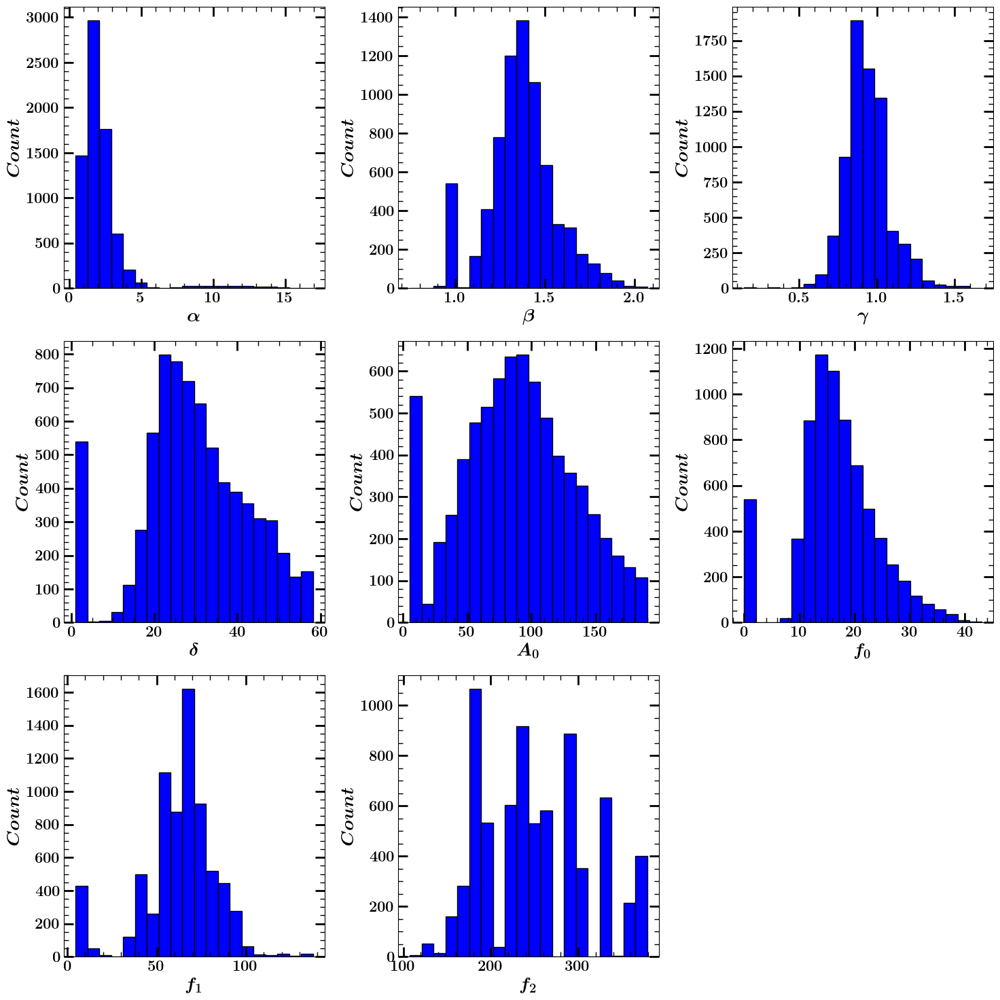

In [94]:
cols = ['alpha', 'beta', 'gamma', 'delta', 'A0', 'f0', 'f1', 'f2']

renamed_cols = cols_fit(cols)

fig, ax = plt.subplots(3, 3, figsize=(15, 15))  
for i in range(len(cols)):
    ax[i//3, i%3].hist(df_removed[cols[i]], bins = 20, color = 'blue', edgecolor = 'black')
    ax[i//3, i%3].set_xlabel(renamed_cols[i])
    ax[i//3, i%3].set_ylabel(r'$Count$')
    ax[i//3, i%3].grid(False)
    # ax[i//3, i%3].set_title(rf'$Histogram$ $of$ {renamed_cols[i]}', fontsize = 16)
ax[2, 2].axis('off')  # Hide the empty subplot
plt.tight_layout()
plt.savefig(graph_dir_spinless + "/hist_fit.pdf")
plt.show()

#### Box plot of the fitting parameters of NR signal database providing information about the outliers and the fraction of entries present inside the inter quartile region

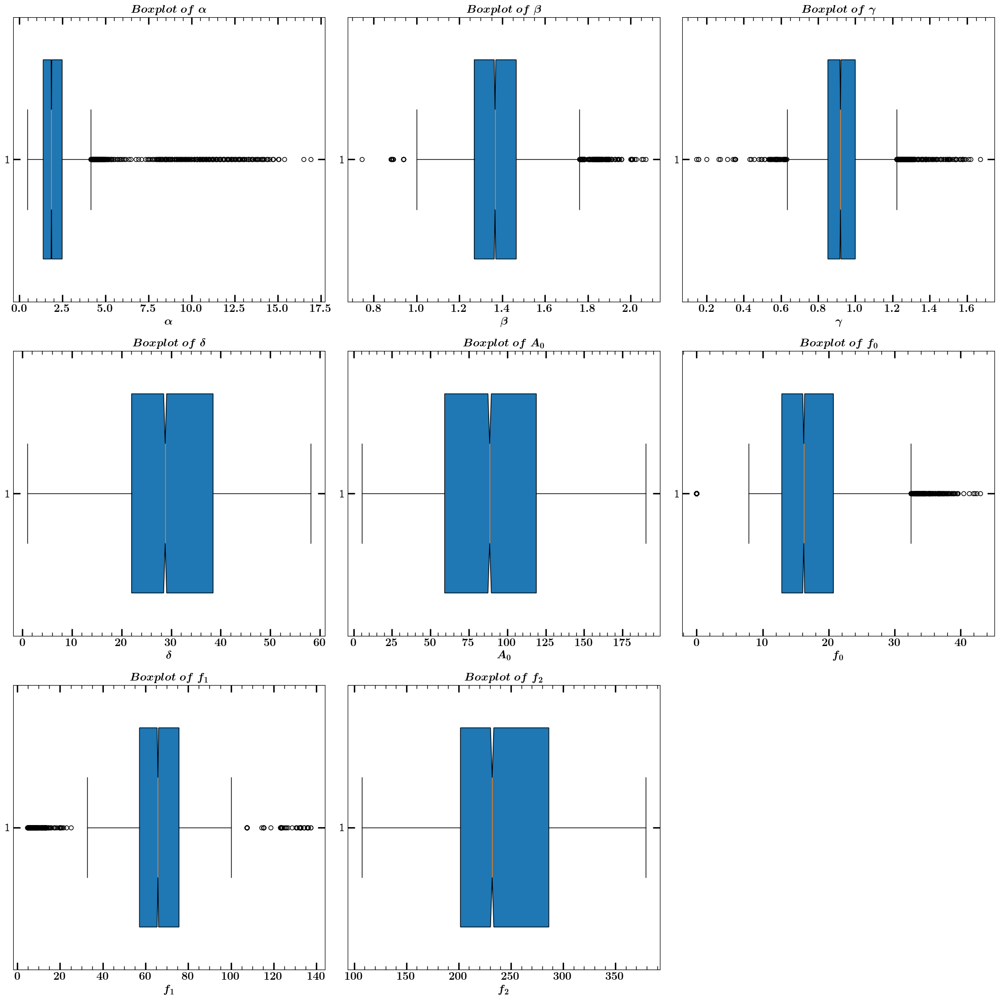

In [95]:
fig, ax = plt.subplots(3, 3, figsize=(20, 20))
for i in range(len(cols)):
    ax[i//3, i%3].boxplot(df_removed[cols[i]], patch_artist = True, notch = True, vert = 0, widths = 0.7)
    ax[i//3, i%3].set_xlabel(renamed_cols[i], fontsize = 16)
    ax[i//3, i%3].set_title(rf'$Boxplot$ $of$ {renamed_cols[i]}', fontsize = 16)
ax[2, 2].axis('off')  # Hide the empty subplot
plt.tight_layout()  
plt.savefig(graph_dir_spinless + "/box_fit.pdf")
plt.show()

#### Distribution of Binary Parameters of NR signal for Spinless BBH Systems (m1, m2)

THESIS: Figure 2.10

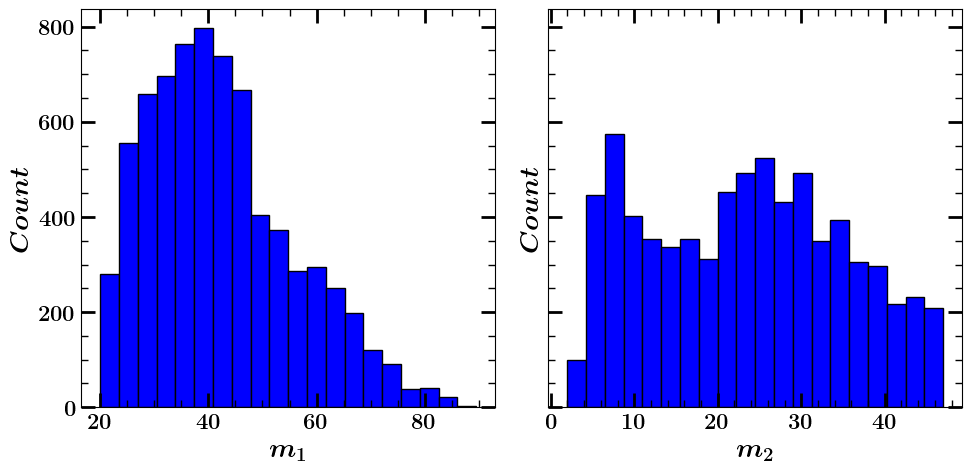

In [96]:
phys_cols = ['m1', 'm2']
renamed_phys_cols = cols_binary(phys_cols)

n_rows = 1
n_cols = 2
fig, ax = plt.subplots(n_rows, n_cols, figsize=(10, 5), sharey=True)  
for i in range(len(phys_cols)):
    ax[i].hist(df_removed[phys_cols[i]], bins=20, color='blue', edgecolor='black')
    ax[i].set_xlabel(renamed_phys_cols[i])
    ax[i].set_ylabel(r'$Count$')
    ax[i].grid(False)
# plt.suptitle(r'$Histogram$ $of$ $Binary$ $Parameters$')
plt.tight_layout()
plt.savefig(graph_dir_spinless + "/hist_phys_m1_m2_spinless.pdf")
plt.show()

#### Distribution of Binary Parameters of NR signal for Spinless BBH Systems (M, q)

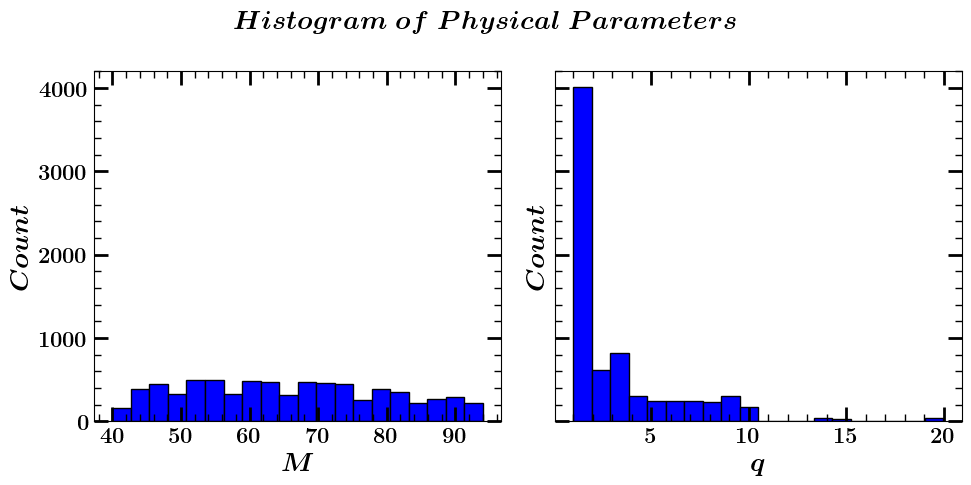

In [97]:
phys_cols = ['M', 'q']    

renamed_phys_cols = cols_binary(phys_cols)

n_rows = 1
n_cols = 2
fig, ax = plt.subplots(n_rows, n_cols, figsize=(10, 5), sharey=True)  
for i in range(len(phys_cols)):
    ax[i].hist(df_removed[phys_cols[i]], bins=20, color='blue', edgecolor='black')
    ax[i].set_xlabel(renamed_phys_cols[i])
    ax[i].set_ylabel(r'$Count$')
    ax[i].grid(False)

plt.suptitle(r'$Histogram$ $of$ $Physical$ $Parameters$')
plt.tight_layout()
plt.savefig(graph_dir_spinless + "/hist_phys_M_q_spinless.pdf")
plt.show()

#### Pearson Correlation matrix for all the parameters in NN table for Spinless BBH Systems

THESIS: Figure 2.11

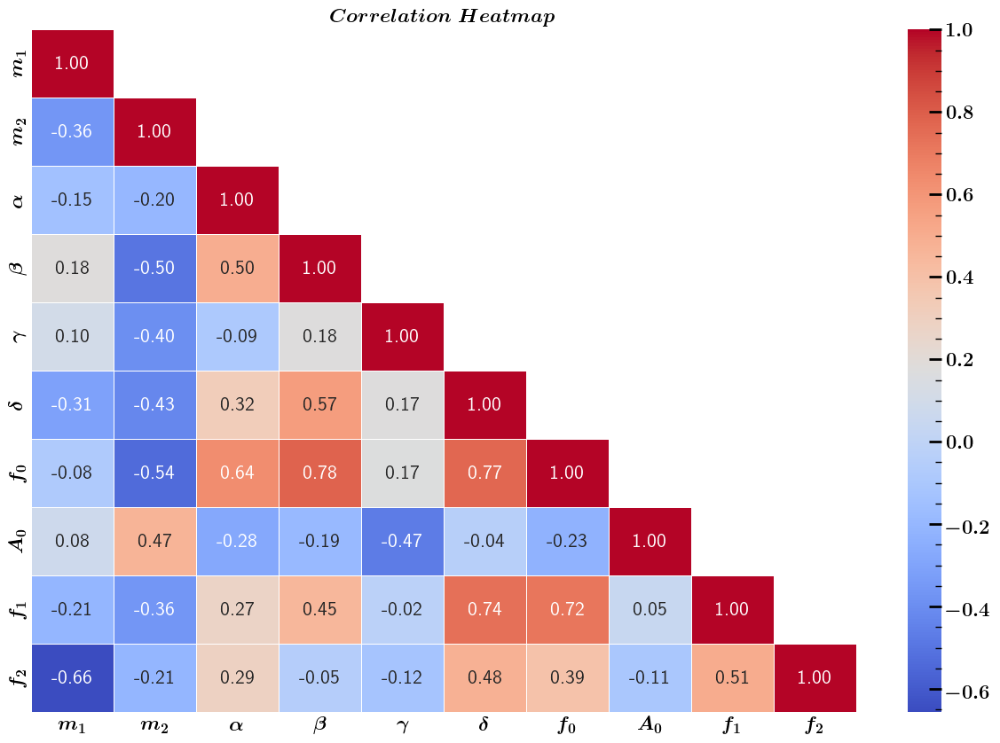

In [98]:
latex_labels = {
    "m1": r"$m_1$", "m2": r"$m_2$",
    "alpha": r"$\alpha$", "beta": r"$\beta$", "gamma": r"$\gamma$", "delta": r"$\delta$", 
    "f0": r"$f_{0}$", "A0": r"$A_{0}$", "f1": r"$f_1$", "f2": r"$f_2$"
}

all_cols = list(latex_labels.keys())

# Correlation Heatmap
df_cols = df_removed[all_cols]
corr = df_cols.corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(15, 10))
ax = sns.heatmap(
    corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, 
    xticklabels=[latex_labels[col] for col in all_cols], 
    yticklabels=[latex_labels[col] for col in all_cols]
)
plt.grid(False)
plt.title(r"$Correlation$ $Heatmap$", fontsize=16)  # Adjust title font size
ax.xaxis.set_ticks_position('none')  
ax.yaxis.set_ticks_position('none')  
plt.xticks() # Increase tick label font size 
plt.yticks()
plt.savefig(graph_dir_spinless + "/corr_all.pdf")
plt.show()

#### Plot of variation of fitting parameters of NR signals with binary parameters (m1, m2)

THESIS: Figure 2.12

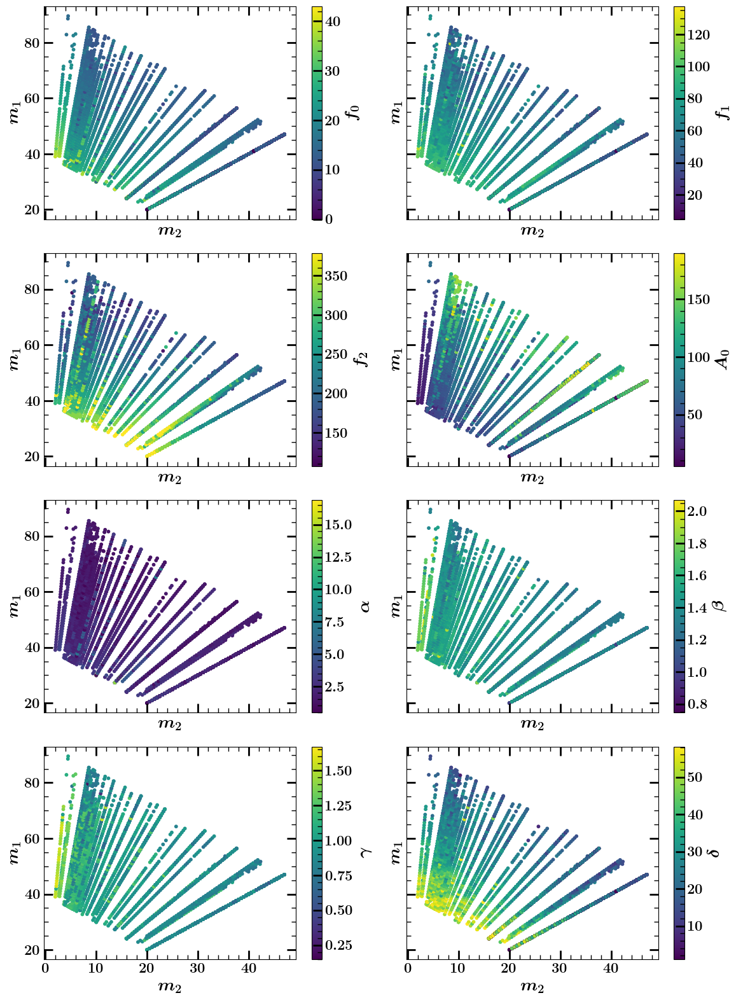

In [99]:
fitting_params = ['f0', 'f1', 'f2', 'A0', 'alpha', 'beta', 'gamma', 'delta']
titles = [r'$f_{0}$', r'$f_{1}$', r'$f_{2}$', r'$A_{0}$', r'$\alpha$', r'$\beta$', r'$\gamma$', r'$\delta$']

fig, axes = plt.subplots(4, 2, figsize=(12, 16), sharex=True, sharey=True)  # Adjusted rows, cols, and figure size

for i, param in enumerate(fitting_params):
    ax = axes[i // 2, i % 2]
    scatter = ax.scatter(df_removed['m2'], df_removed['m1'], c=df_removed[param], s=10, cmap='viridis', rasterized=True)
    # ax.set_title(titles[i], fontsize=20)
    ax.set_xlabel(r'$m_{2}$')
    ax.set_ylabel(r'$m_{1}$')
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label(titles[i])
    ax.grid(False)

# axes[2, 2].axis('off')  # Hide the last subplot
plt.tight_layout()
plt.savefig(graph_dir_spinless + "/m1_m2_fitparams_l.pdf")
plt.show()

#### Plot of variation of fitting parameters of NR signals with binary parameters (M, q)

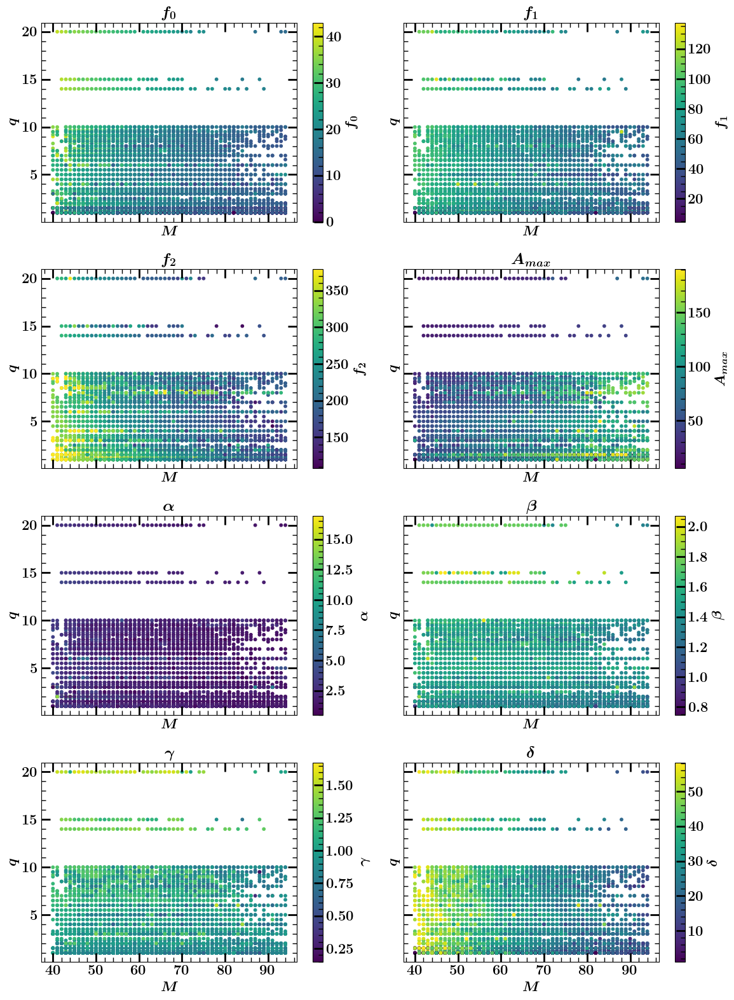

In [100]:
fitting_params = ['f0', 'f1', 'f2', 'A0', 'alpha', 'beta', 'gamma', 'delta']
titles = [r'$f_{0}$', r'$f_{1}$', r'$f_{2}$', r'$A_{max}$', r'$\alpha$', r'$\beta$', r'$\gamma$', r'$\delta$']

fig, axes = plt.subplots(4, 2, figsize=(12, 16), sharex=True, sharey=True)  # Increased figure size

for i, param in enumerate(fitting_params):
    ax = axes[i // 2, i % 2]
    scatter = ax.scatter(df_removed['M'], df_removed['q'], c=df_removed[param], s=10, cmap='viridis', rasterized = True)  # Increased marker size
    ax.set_title(titles[i], fontsize=18)  # Larger font size for titles
    ax.set_xlabel(r'$M$', fontsize=16)
    ax.set_ylabel(r'$q$', fontsize=16)
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label(titles[i], fontsize=16)
    ax.grid(False)

plt.tight_layout()
plt.savefig(graph_dir_spinless + "/M_q_fitparams.pdf")
plt.show()

### Neural Network Model

#### Defining the logistics and libraries

##### Importing the libraries required for this part

In [101]:
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

##### Defining the Dataset to be used for this model

In [102]:
df_ml = df_removed.copy()

# Defining the rows for total mass and mass ratios 
M = df_ml['m1'].values + df_ml['m2'].values
q = df_ml['m1'].values / df_ml['m2'].values

NOTE - The below models give slightly different results on each run of the model. However, the accuracy of the model remains almost same for all the runs. Therefore, we may observe some slight changes in the approach of the loss curve for taining and validation set. 

#### ML Model for $m_{1}$ and $m_{2}$ as the output parameters

##### Defining the input and output parameters for the given problem

In [105]:
# Defining the input and output parameters for the neural network
output_cols = ['m1', 'm2']
input_cols = ['beta', 'gamma', 'delta', 'A0', 'f0', 'f1', 'f2']
# output_cols = ["beta"]

# Assigning the input and output columns to the dataset
X = df_ml[input_cols].values
y = df_ml[output_cols].values

# Normalizing the input and output data
X_norm = X/np.max(X, axis = 0)
y_norm = y/np.max(y, axis = 0)

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, train_size = 0.8, shuffle = True, random_state = 42)
# X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, shuffle = True, random_state = 42)

# Print the shapes of the datasets
print("The shape of the X_train dataset is :", X_train.shape)
print("The shape of the X_test dataset is :", X_test.shape)
print("The shape of the y_train dataset is :", y_train.shape)
print("The shape of the y_test dataset is :", y_test.shape)

The shape of the X_train dataset is : (5819, 7)
The shape of the X_test dataset is : (1455, 7)
The shape of the y_train dataset is : (5819, 2)
The shape of the y_test dataset is : (1455, 2)


##### Defining the NN Models 

Code of the model 1 on the spinless BBH systems. Running the training of the model is not advisable as it may change the results of the model. Hence, I request you to import the information saved in the dataset about the model and print it as shown below. 

In [ ]:
# # # Defining the hyperparameters for the neural network
# tf.random.set_seed(42)

# learning_rate = 1e-5
# epochs = 200
# batch_size = 64
# name = "mse_epoch.pdf"
# num = X_train.shape[1]

# # Defining the neural network model
# model = Sequential()
# model.add(Input(shape = (num,)))
# model.add(Dense(32, activation='relu'))
# model.add(Dense(16, activation='relu'))
# # model.add(Dense(8, activation='relu'))
# model.add(Dense(2, activation='relu'))

# # # from tensorflow.keras.callbacks import LearningRateScheduler
# from tensorflow.keras.callbacks import ReduceLROnPlateau
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)

# model.compile(optimizer=Adam(learning_rate= learning_rate), loss='mse')

# history = model.fit(X_train, y_train, 
#                     batch_size=batch_size, 
#                     epochs=epochs, verbose=1, 
#                     validation_data=(X_test, y_test),
#                     callbacks=[reduce_lr]
#                     )
# mse_per_epoch = history.history['loss']
# y_pred_train = model.predict(X_train)
# y_pred_test = model.predict(X_test)

# # Calculate metrics
# mse_train = mean_squared_error(y_train, y_pred_train)
# r2_train = r2_score(y_train, y_pred_train)

# mse_test = mean_squared_error(y_test, y_pred_test)
# r2_test = r2_score(y_test, y_pred_test)

# print(f"Mean Squared Error for training dataset: {mse_train}")
# print(f"R^2 Score for training dataset: {r2_train}")
# print(f"Mean Squared Error for test dataset: {mse_test}")
# print(f"R^2 Score for test dataset: {r2_test}")

# # from tensorflow import keras

# # model = keras.models.load_model(data_dir_spinless + "model_spin0.keras")
# # model.summary()


Epoch 1/200
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2003 - val_loss: 0.1930 - learning_rate: 1.0000e-05
Epoch 2/200
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1967 - val_loss: 0.1896 - learning_rate: 1.0000e-05
Epoch 3/200
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1934 - val_loss: 0.1864 - learning_rate: 1.0000e-05
Epoch 4/200
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1902 - val_loss: 0.1832 - learning_rate: 1.0000e-05
Epoch 5/200
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1870 - val_loss: 0.1797 - learning_rate: 1.0000e-05
Epoch 6/200
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1834 - val_loss: 0.1751 - learning_rate: 1.0000e-05
Epoch 7/200
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1786 - val_loss: 0.1695 - learning_rate: 1.0000e-05
Epoch 8/200
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1727 - val_loss: 0.1627 - learning_rate: 1.0000e-05
Epoch 9/200
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1657 - val_loss: 0.1547 - learning_

##### Plotting the loss function of the model

THESIS: Figure 4.1

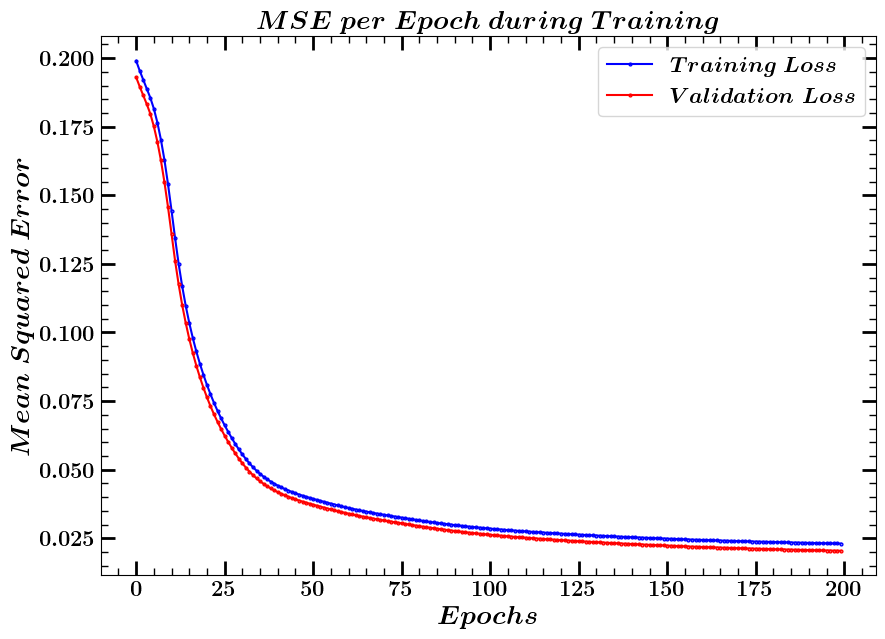

In [ ]:
# Plot MSE vs. Epochs
plt.figure(figsize=(10, 7))
plt.plot(history.history['loss'], linestyle='-', marker = "o", color='b', markersize=2, label = r"$Training$ $Loss$")
plt.plot(history.history['val_loss'], linestyle='-', marker = "o", color='r', markersize=2, label = r"$Validation$ $Loss$")
plt.xlabel(r"$Epochs$")
plt.ylabel(r"$Mean$ $Squared$ $Error$")
plt.title(r"$MSE$ $per$ $Epoch$ $during$ $Training$")
plt.legend()
plt.xticks()
plt.yticks()
# plt.yscale("log")
plt.grid(False)
# plt.yscale("log")
# plt.savefig(graph_dir_spinless + "tf_loss_spin0_model1.pdf")
# plt.savefig(graph_dir_spinless + "tf_loss_spin0_model1.png")
plt.show()

Saving the details about the model to regenerate the results

In [ ]:
# # Save model
# model.save(data_dir_spinless + "/spinless_model1_m1_m2_final.keras")

# # Save training history as HDF5
# with h5py.File(data_dir_spinless + "/spinless_model1_m1_m2_final_history.h5", "w") as f:
#     for key, values in history.history.items():
#         f.create_dataset(key, data=np.array(values))

# # Predictions
# y_pred_train = model.predict(X_train)
# y_pred_test = model.predict(X_test)

# # Save predictions
# np.savez(data_dir_spinless + "/spinless_model1_m1_m2_final_pred.npz", 
#          y_pred_train=y_pred_train, y_pred_test=y_pred_test)

# # Compute metrics
# mse_train = mean_squared_error(y_train, y_pred_train)
# r2_train = r2_score(y_train, y_pred_train)
# mse_test = mean_squared_error(y_test, y_pred_test)
# r2_test = r2_score(y_test, y_pred_test)

# # Save metrics as HDF5
# with h5py.File(data_dir_spinless + "/spinless_model1_m1_m2_final_metrics.h5", "w") as f:
#     f.create_dataset("mse_train", data=mse_train)
#     f.create_dataset("r2_train", data=r2_train)
#     f.create_dataset("mse_test", data=mse_test)
#     f.create_dataset("r2_test", data=r2_test)

# # Print metrics
# print("Metrics:")
# print(f"Train MSE: {mse_train}, R²: {r2_train}")
# print(f"Test  MSE: {mse_test}, R²: {r2_test}")


182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 862us/step
Metrics:
Train MSE: 0.023059454650162528, R²: 0.4797982573351576
Test  MSE: 0.020443247660935488, R²: 0.5192228932467191


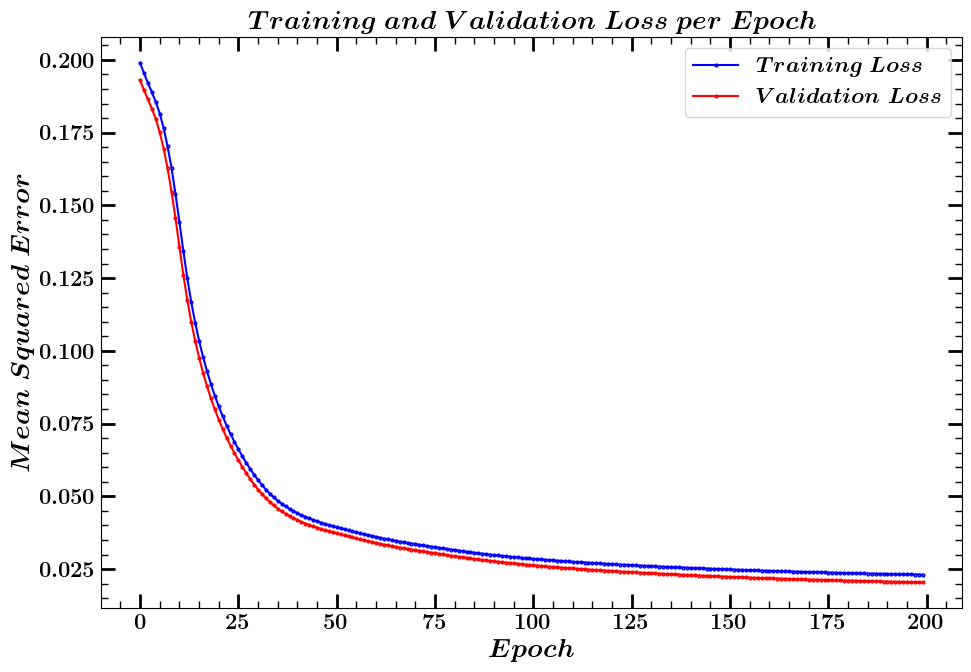

In [161]:
# Load training history
with h5py.File(data_dir_spinless + "/spinless_model1_m1_m2_final_history.h5", "r") as f:
    loss = np.array(f['loss'])
    val_loss = np.array(f['val_loss'])

# Plot training and validation loss
plt.figure(figsize=(10, 7))
plt.plot(loss, linestyle='-', marker = "o", color='b', markersize=2, label=r'$Training$ $Loss$')
plt.plot(val_loss,linestyle='-', marker = "o", color='r', markersize=2, label=r'$Validation$ $Loss$')
plt.xlabel(r'$Epoch$')
plt.ylabel(r'$Mean$ $Squared$ $Error$')
plt.title(r'$Training$ $and$ $Validation$ $Loss$ $per$ $Epoch$')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.savefig(graph_dir_spinless + "/spinless_model1_m1_m2_final_loss_plot.pdf")
plt.show()

In [103]:
# Load evaluation metrics
with h5py.File(data_dir_spinless + "/spinless_model1_m1_m2_final_metrics.h5", "r") as f:
    mse_train = f['mse_train'][()]
    r2_train = f['r2_train'][()]
    mse_test = f['mse_test'][()]
    r2_test = f['r2_test'][()]

# Print metrics
print("Final Model Evaluation Metrics (from saved data):\n")
print(f"Train MSE  : {mse_train:.6f}")
print(f"Train R²   : {r2_train:.6f}")
print(f"Test MSE   : {mse_test:.6f}")
print(f"Test R²    : {r2_test:.6f}")


Final Model Evaluation Metrics (from saved data):

Train MSE  : 0.023059
Train R²   : 0.479798
Test MSE   : 0.020443
Test R²    : 0.519223


#### ML Model for $M$ and $q$ as the output parameters

##### Defining the input and output columns of the dataset

In [106]:
# Input and output columns for the neural network
X = df_ml[input_cols].values
y = np.vstack((M, q)).T
# y = df_ml[output_cols].values

# Normalizing the input and output data
X_norm = X/np.max(X, axis = 0)
y_norm = y/np.max(y, axis = 0)

# Dividing the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, train_size = 0.8, shuffle = True, random_state = 42)
# X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, shuffle = True, random_state = 42)

# Print the shapes of the datasets
print("The shape of the X_train dataset is :", X_train.shape)
print("The shape of the X_test dataset is :", X_test.shape)
print("The shape of the y_train dataset is :", y_train.shape)
print("The shape of the y_test dataset is :", y_test.shape)

The shape of the X_train dataset is : (5819, 7)
The shape of the X_test dataset is : (1455, 7)
The shape of the y_train dataset is : (5819, 2)
The shape of the y_test dataset is : (1455, 2)


##### Defining the model

It is not advisable to run the model as it may lead to different loss function while training and validation loss, Hence I highly recommend to plot the learned models using the saved dataset

In [107]:
# # Defining the hyperparameters for the neural network model

# learning_rate = 5e-5
# epochs = 100
# batch_size = 64
# name = "mse_epoch.pdf"
# num = X_train.shape[1]

# # Defining the neural network model
# model = Sequential()
# model.add(Input(shape = (num,)))
# model.add(Dense(32, activation='relu'))
# model.add(Dense(16, activation='relu'))
# # model.add(Dense(8, activation='relu'))
# model.add(Dense(2, activation='relu'))

# # from tensorflow.keras.callbacks import LearningRateScheduler

# from tensorflow.keras.callbacks import ReduceLROnPlateau
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)


# model.compile(optimizer=Adam(learning_rate= learning_rate), loss='mse')

# history = model.fit(X_train, y_train, 
#                     batch_size=batch_size, 
#                     epochs=epochs, verbose=1, 
#                     validation_data=(X_test, y_test)
#                     , callbacks=[reduce_lr]
#                     )

# mse_per_epoch = history.history['loss']
# y_pred_train = model.predict(X_train)
# y_pred_test = model.predict(X_test)

# # Calculate metrics
# mse_train = mean_squared_error(y_train, y_pred_train)
# r2_train = r2_score(y_train, y_pred_train)

# mse_test = mean_squared_error(y_test, y_pred_test)
# r2_test = r2_score(y_test, y_pred_test)

# print(f"Mean Squared Error for training dataset: {mse_train}")
# print(f"R^2 Score for training dataset: {r2_train}")
# print(f"Mean Squared Error for test dataset: {mse_test}")
# print(f"R^2 Score for test dataset: {r2_test}")

Mean Squared Error for training dataset: 0.008388797578746122   
R^2 Score for training dataset: 0.6490854725952457   
Mean Squared Error for test dataset: 0.007132992239374985   
R^2 Score for test dataset: 0.6666698044012056   

##### Plotting the training and validation loss of the functions

THESIS: Figure 4.2

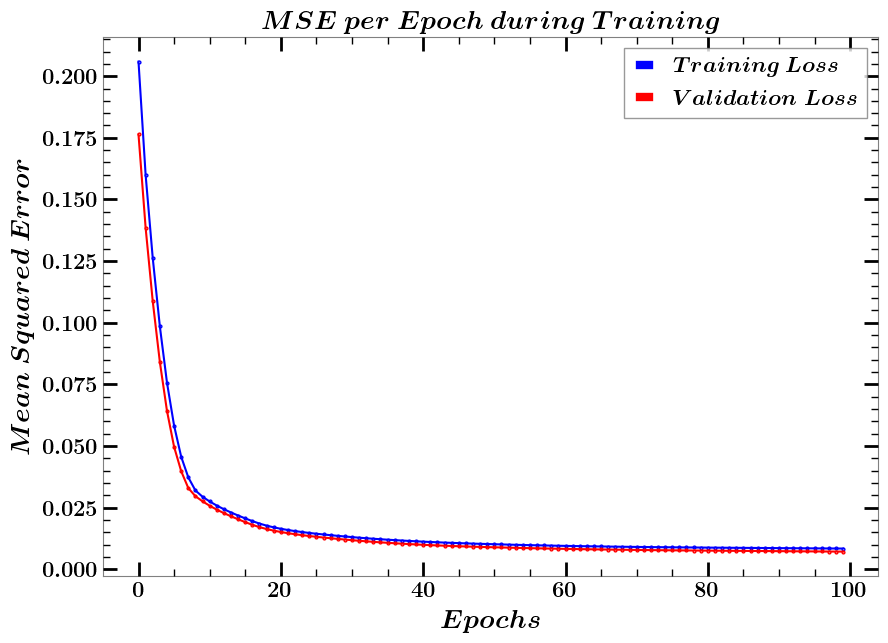

In [ ]:
# Plot MSE vs. Epochs
plt.figure(figsize=(10, 7))
plt.plot(history.history['loss'], linestyle='-', marker = "o", color='b', markersize=2, label = r"$Training$ $Loss$")
plt.plot(history.history['val_loss'], linestyle='-', marker = "o", color='r', markersize=2, label = r"$Validation$ $Loss$")
plt.xlabel(r"$Epochs$")
plt.ylabel(r"$Mean$ $Squared$ $Error$")
plt.title(r"$MSE$ $per$ $Epoch$ $during$ $Training$")
plt.legend()
plt.xticks()
plt.yticks()
# plt.yscale("log")
plt.grid(False)
# plt.yscale("log")
# plt.savefig(graph_dir_spinless + "tf_loss_spin0_model2.pdf")
# plt.savefig(graph_dir_spinless + "tf_loss_spin0_model2.png")

plt.show()

Saving the details of the model 

In [108]:
# import h5py
# import numpy as np
# from sklearn.metrics import mean_squared_error, r2_score

# # Save model
# model.save(data_dir_spinless + "spinless_model2_M_q_final.keras")

# # Save training history as HDF5
# with h5py.File(data_dir_spinless + "spinless_model2_M_q_final_history.h5", "w") as f:
#     for key, values in history.history.items():
#         f.create_dataset(key, data=np.array(values))

# # Predictions
# y_pred_train = model.predict(X_train)
# y_pred_test = model.predict(X_test)

# # Save predictions
# np.savez(data_dir_spinless + "spinless_model2_M_q_final_pred.npz", 
#          y_pred_train=y_pred_train, y_pred_test=y_pred_test)

# # Compute metrics
# mse_train = mean_squared_error(y_train, y_pred_train)
# r2_train = r2_score(y_train, y_pred_train)
# mse_test = mean_squared_error(y_test, y_pred_test)
# r2_test = r2_score(y_test, y_pred_test)

# # Save metrics as HDF5
# with h5py.File(data_dir_spinless + "spinless_model2_M_q_final_metrics.h5", "w") as f:
#     f.create_dataset("mse_train", data=mse_train)
#     f.create_dataset("r2_train", data=r2_train)
#     f.create_dataset("mse_test", data=mse_test)
#     f.create_dataset("r2_test", data=r2_test)

# # Print metrics
# print("Metrics:")
# print(f"Train MSE: {mse_train}, R²: {r2_train}")
# print(f"Test  MSE: {mse_test}, R²: {r2_test}")


In [109]:
from tensorflow.keras.models import load_model
model = load_model(data_dir_spinless + "/spinless_model2_M_q_final.keras")
model.summary()

2025-05-01 16:14:58.219766: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,456 (9.60 KB)

 Trainable params: 818 (3.20 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,638 (6.40 KB)

In [110]:
# Load training history
history_path = data_dir_spinless + "/spinless_model2_M_q_final_history.h5"

with h5py.File(history_path, "r") as f:
    print("Datasets in training history:")
    for key in f.keys():
        print(f"{key}: {np.array(f[key])[:5]} ...")  # print first 5 values
    
    # Load loss arrays
    loss = np.array(f['loss'])
    val_loss = np.array(f['val_loss'])

Datasets in training history:
learning_rate: [4.99999987e-05 4.99999987e-05 4.99999987e-05 4.99999987e-05
 4.99999987e-05] ...
loss: [0.20590916 0.15996006 0.12623619 0.09850503 0.07571123] ...
val_loss: [0.17635055 0.13848436 0.10871466 0.08404027 0.06423108] ...


Plotting the loss function using the saved dataset

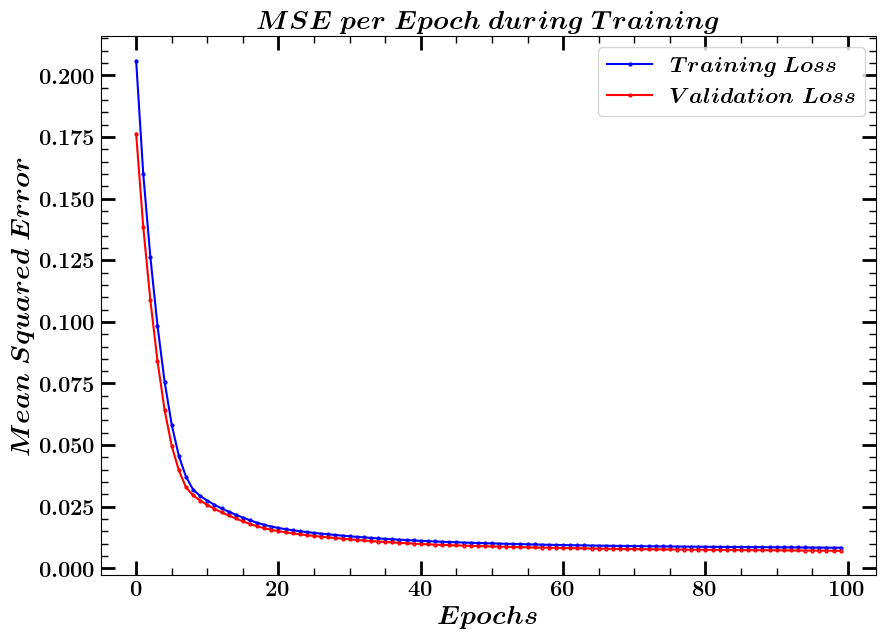

In [167]:
plt.figure(figsize=(10, 7))
plt.plot(loss, linestyle='-', marker='o', color='b', markersize=2, label=r"$Training$ $Loss$")
plt.plot(val_loss, linestyle='-', marker='o', color='r', markersize=2, label=r"$Validation$ $Loss$")
plt.xlabel(r"$Epochs$")
plt.ylabel(r"$Mean$ $Squared$ $Error$")
plt.title(r"$MSE$ $per$ $Epoch$ $during$ $Training$")
plt.legend()
plt.xticks()
plt.yticks()
plt.grid(False)
# plt.yscale("log")
plt.savefig(graph_dir_spinless + "/spinless_model2_M_q_final_loss_plot.pdf")
plt.show()


##### Printing the table which prints the comparison between the actual and predicted values

Run the below code if you have run the model yourself on the computer. if not then skip this code and run the next code.

In [ ]:
# import pandas as pd

# # Define parameter names corresponding to the output layer
# parameter_names = ['M', 'q']

# # Create a DataFrame for actual and predicted values
# comparison_df = pd.DataFrame({f'Actual {name}': y_test[:, idx] for idx, name in enumerate(parameter_names)})
# for idx, name in enumerate(parameter_names):
#     comparison_df[f'Predicted {name}'] = y_pred_test[:, idx]

# # Calculate the squared error for each parameter
# for idx, name in enumerate(parameter_names):
#     comparison_df[f'Squared Error {name}'] = (comparison_df[f'Actual {name}'] - comparison_df[f'Predicted {name}']) ** 2

# # Calculate the Mean Squared Error (MSE) for each sample
# comparison_df['MSE'] = comparison_df[[f'Squared Error {name}' for name in parameter_names]].mean(axis=1)

# # Display the top 10 rows with the smallest MSE
# print(comparison_df.head(10).to_string(index=False))


 Actual M  Actual q  Predicted M  Predicted q  Squared Error M  Squared Error q      MSE
 0.872340  0.475085     0.843475     0.148952         0.000833     1.063628e-01 0.053598
 0.819149  0.150026     0.786160     0.172384         0.001088     4.998438e-04 0.000794
 0.989362  0.050009     0.982217     0.154110         0.000051     1.083707e-02 0.005444
 0.691489  0.425135     0.734811     0.283370         0.001877     2.009715e-02 0.010987
 0.702128  0.300070     0.709594     0.211064         0.000056     7.922070e-03 0.003989
 0.457447  0.050009     0.503752     0.084510         0.002144     1.190272e-03 0.001667
 0.957447  0.062515     0.906078     0.113827         0.002639     2.632923e-03 0.002636
 0.659574  0.050009     0.749450     0.097706         0.008078     2.274957e-03 0.005176
 0.776596  0.091618     0.734127     0.128314         0.001804     1.346561e-03 0.001575
 0.744681  0.100019     0.841771     0.100595         0.009426     3.311005e-07 0.004713


##### Comparisons Table of the predictions and actual value for the above model

The below table was generated from the saved dataset. If the model was run on the computer generate the table from the above code. If the model is generated from saved dataset then run the below code to generate the predicted table.

THESIS: Table 4.1

In [ ]:
# Load saved predictions
pred_path = data_dir_spinless + "/spinless_model2_M_q_final_pred.npz"
pred_data = np.load(pred_path)
y_pred_test = pred_data["y_pred_test"]

# Define parameter names corresponding to the output layer
parameter_names = ['M', 'q']

# Create DataFrame comparing actual vs. predicted values
comparison_df = pd.DataFrame({f'Actual {name}': y_test[:, idx] for idx, name in enumerate(parameter_names)})
for idx, name in enumerate(parameter_names):
    comparison_df[f'Predicted {name}'] = y_pred_test[:, idx]

# Compute squared error for each parameter
for idx, name in enumerate(parameter_names):
    comparison_df[f'Squared Error {name}'] = (comparison_df[f'Actual {name}'] - comparison_df[f'Predicted {name}']) ** 2

# Compute per-sample mean squared error (MSE)
comparison_df['MSE'] = comparison_df[[f'Squared Error {name}' for name in parameter_names]].mean(axis=1)

# Display top 10 rows with the smallest MSE
print(comparison_df.head(10).to_string(index=False))


 Actual M  Actual q  Predicted M  Predicted q  Squared Error M  Squared Error q      MSE
 0.872340  0.475085     0.843475     0.148952         0.000833     1.063628e-01 0.053598
 0.819149  0.150026     0.786160     0.172384         0.001088     4.998438e-04 0.000794
 0.989362  0.050009     0.982217     0.154110         0.000051     1.083707e-02 0.005444
 0.691489  0.425135     0.734811     0.283370         0.001877     2.009715e-02 0.010987
 0.702128  0.300070     0.709594     0.211064         0.000056     7.922070e-03 0.003989
 0.457447  0.050009     0.503752     0.084510         0.002144     1.190272e-03 0.001667
 0.957447  0.062515     0.906078     0.113827         0.002639     2.632923e-03 0.002636
 0.659574  0.050009     0.749450     0.097706         0.008078     2.274957e-03 0.005176
 0.776596  0.091618     0.734127     0.128314         0.001804     1.346561e-03 0.001575
 0.744681  0.100019     0.841771     0.100595         0.009426     3.311005e-07 0.004713


## Part 2 - Spin BBH Systems

### Defining the Logistics for this part

#### Importing the Dataset for the model 

In [111]:
df = pd.read_csv(data_dir_spin + "/Spins_M40-M95.csv")

df["M"] = df["m1"] + df["m2"]
df["q"] = df["m1"] / df["m2"]
df

,name,f0,f1,f2,A0,alpha,beta,gamma,delta,mse,...,s2x,s2y,s2z,D,r1,theta1,phi1,r2,theta2,phi2
0,SXS_BBH_0059_M40,55.929317,100.034136,328.903444,17.174137,11.180508,2.155797,0.918627,59.574719,0.063471,...,2.019380e-09,-4.156445e-09,3.271070e-07,14.934004,0.499143,89.987942,183.107127,3.271396e-07,0.809362,115.912475
1,SXS_BBH_0078_M40,24.870299,93.383573,435.738601,70.585285,3.059558,1.442149,0.814286,41.643413,0.511862,...,5.720384e-06,-8.017218e-06,2.436179e-05,10.044557,0.323205,119.151099,160.045536,2.627728e-05,22.012097,125.508327
2,SXS_BBH_0060_M40,28.135936,81.176167,286.256797,44.197113,2.794433,1.653201,1.108373,62.091040,0.096185,...,-3.706194e-12,-2.212949e-12,3.751224e-07,14.868223,0.499549,180.000000,304.923242,3.751224e-07,0.000659,30.841204
3,SXS_BBH_0082_M40,26.907396,93.367823,435.665107,63.231214,3.173450,1.439143,0.974536,47.524643,0.349197,...,1.710556e-10,1.306419e-10,4.079231e-07,13.062714,0.499554,0.000000,13.928643,4.079231e-07,0.030232,217.370401
4,SXS_BBH_0074_M40,22.607976,93.381717,435.729941,82.194957,2.529902,1.377254,0.890540,41.034454,0.432007,...,7.846361e-09,5.271180e-09,2.482164e-07,16.575613,0.499277,90.051462,185.656179,2.483963e-07,2.180878,213.893179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125863,SXS_BBH_3982_M94,10.587106,43.236192,201.745093,176.294479,1.190493,1.261245,0.867967,14.720790,0.761397,...,-1.152010e-09,-7.854383e-09,9.495960e-01,15.612066,0.693485,0.000002,111.959573,9.495960e-01,0.000000,81.655870
125864,SXS_BBH_3981_M94,10.323324,135.747482,163.523037,164.133964,1.089670,1.295959,-1.900168,16.443618,0.728552,...,-4.358079e-08,-1.630330e-08,4.107661e-01,16.153129,0.693909,0.000003,214.234955,4.107661e-01,0.000006,20.510508
125865,SXS_BBH_3928_M94,7.676573,57.213802,188.113949,254.090616,0.636665,1.178491,0.819097,18.486728,0.797218,...,1.050913e-08,-1.448568e-08,-6.546750e-01,16.939570,0.120419,179.999928,309.575525,6.546750e-01,179.999999,125.960280
125866,SXS_BBH_3929_M94,7.558971,37.589230,175.395713,258.782962,0.689144,1.213461,0.947433,18.858092,1.053265,...,-3.666256e-08,-1.248545e-08,7.156224e-01,16.668270,0.179681,179.999986,205.669859,7.156224e-01,0.000003,18.806303


### Preprocessing the Dataset

#### Removing the rows having very high values as compared to standard deviation
We take the $95\%$ confidence interval for the whole dataset. That is, values having the zscore greater than 2, for each column in the dataset. 

In [112]:
# Columns to be used for the analysis
print("-"*100)
print("Columns present in the dataset are:")
print(df.columns)
print("-"*100)

numeric_cols = ['alpha', 'beta', 'gamma', 'delta', 'A0', 'f0', 'f1', 'f2', 'mse']

# Form the dataset with just numeric columns
df_numeric = df[numeric_cols]
means = df_numeric.mean()
variances =  df_numeric.var()
stds = df_numeric.std()
maxm = df_numeric.max()
minm = df_numeric.min()
z_scores = (df_numeric - means)/stds


# Print the statistics of the dataset
print("The maximum absolute value of Z scores for each column :")
print(z_scores.abs().max())
print("-"*100)

# Defining the throeshold for the z_scores and for the MSE
confidence = 2
mse_threshold = 1

# Get indices satisfying the conditions for each column
alpha_indices = set(z_scores.index[z_scores["alpha"].abs() > confidence])
beta_indices = set(z_scores.index[z_scores["beta"].abs() > confidence])
gamma_indices = set(z_scores.index[z_scores["gamma"].abs() > confidence])
delta_indices = set(z_scores.index[z_scores["delta"].abs() > confidence])
A0_indices = set(z_scores.index[z_scores["A0"].abs() > confidence])
f0_indices = set(z_scores.index[z_scores["f0"].abs() > confidence])
f1_indices = set(z_scores.index[z_scores["f1"].abs() > confidence])
f2_indices = set(z_scores.index[z_scores["f2"].abs() > confidence])
mse_indices = set(z_scores.index[z_scores["mse"].abs() > mse_threshold])

# Get the final set of unique indices
wrong_indices = alpha_indices | beta_indices | gamma_indices | delta_indices | A0_indices | f0_indices | f1_indices | f2_indices | mse_indices

negative_beta_gamma_indices = set(df.index[(df["beta"] < 0) | (df["gamma"] < 0)])
wrong_indices = wrong_indices | negative_beta_gamma_indices
# Convert to a sorted list if needed
wrong_indices = sorted(wrong_indices)

print("The indices which we should remove are:\n", wrong_indices)
print("The number of indices to be removed :", len(wrong_indices))
print("The confidence interval which we take to reduce the dataset is :", confidence)
print("-"*100)  # Partition 

df_removed = df.drop(wrong_indices)
df_removed

----------------------------------------------------------------------------------------------------
Columns present in the dataset are:
Index(['name', 'f0', 'f1', 'f2', 'A0', 'alpha', 'beta', 'gamma', 'delta',
       'mse', 'window', 'M', 'q', 'm1', 'm2', 's1x', 's1y', 's1z', 's2x',
       's2y', 's2z', 'D', 'r1', 'theta1', 'phi1', 'r2', 'theta2', 'phi2'],
      dtype='object')
----------------------------------------------------------------------------------------------------
The maximum absolute value of Z scores for each column :
alpha     17.014631
beta     294.055023
gamma     18.696279
delta     27.070820
A0        10.571391
f0         9.393600
f1         6.191669
f2         4.262445
mse       26.162223
dtype: float64
----------------------------------------------------------------------------------------------------
The indices which we should remove are:
 [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 36,

,name,f0,f1,f2,A0,alpha,beta,gamma,delta,mse,...,s2x,s2y,s2z,D,r1,theta1,phi1,r2,theta2,phi2
8,SXS_BBH_0092_M40,25.929179,87.068215,378.798382,67.262758,3.069110,1.517011,0.920167,56.138658,0.307230,...,-2.287131e-10,9.220523e-12,1.376824e-07,18.727792,0.499501,180.000000,96.071713,1.376826e-07,0.095255,357.691383
15,SXS_BBH_0105_M40,22.318882,87.072201,329.316778,69.314286,2.191044,1.487382,1.002997,52.921219,0.250068,...,-9.442605e-12,-8.044940e-12,5.589273e-07,12.887726,0.499549,180.000000,162.959281,5.589273e-07,0.001272,40.430437
23,SXS_BBH_0161_M40,25.749837,81.176105,406.247617,64.444409,2.891050,1.483316,0.969839,55.722454,0.359119,...,-1.704871e-01,-7.178710e-02,-2.361948e-01,10.448256,0.909636,122.136610,203.989357,3.000121e-01,141.932455,22.834523
32,SXS_BBH_0259_M40,23.524509,93.382978,378.799263,70.552623,2.305304,1.419968,0.953133,54.511639,0.251929,...,7.847936e-10,-5.799445e-09,-1.709832e-05,17.251500,0.600009,0.000002,111.379017,1.709832e-05,179.980389,97.706576
38,SXS_BBH_0203_M40,22.554767,115.224196,378.847025,53.939021,1.486635,1.375651,1.167736,54.411154,0.112673,...,3.125172e-10,-2.035349e-09,-2.853133e-06,20.376005,0.899959,180.000000,285.344408,2.853134e-06,179.958648,98.729293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125856,SXS_BBH_3978_M94,11.782064,61.359993,266.952370,160.779921,1.377656,1.191378,0.732026,16.430833,0.876823,...,-2.706901e-05,-1.049692e-05,4.517048e-05,11.286069,0.899650,83.016443,158.124270,5.369626e-05,32.730613,21.195472
125857,SXS_BBH_3977_M94,10.221747,40.313906,188.109367,181.260612,1.149712,1.296012,0.879586,14.215889,0.756829,...,2.006755e-05,1.731972e-05,-6.091924e-05,10.973293,0.899848,80.326660,176.167684,6.643668e-05,156.484451,220.796522
125859,SXS_BBH_3975_M94,11.161439,35.047108,107.439830,106.506404,1.089942,1.668688,0.959701,27.231409,0.273408,...,3.673858e-07,-4.072702e-07,7.865899e-05,15.981234,0.649938,173.912102,281.035560,7.866091e-05,0.399518,132.052637
125861,SXS_BBH_3979_M94,11.443221,46.370578,248.892720,159.028940,1.204405,1.192615,0.859801,12.009915,0.500151,...,4.681142e-09,2.697605e-09,-9.494824e-01,17.234162,0.949567,0.000000,15.910816,9.494824e-01,180.000000,209.953584


### Exploratory Data Analysis

#### Plotting the distribution of the fitting parameters of NR signal

THESIS: Figure 2.13

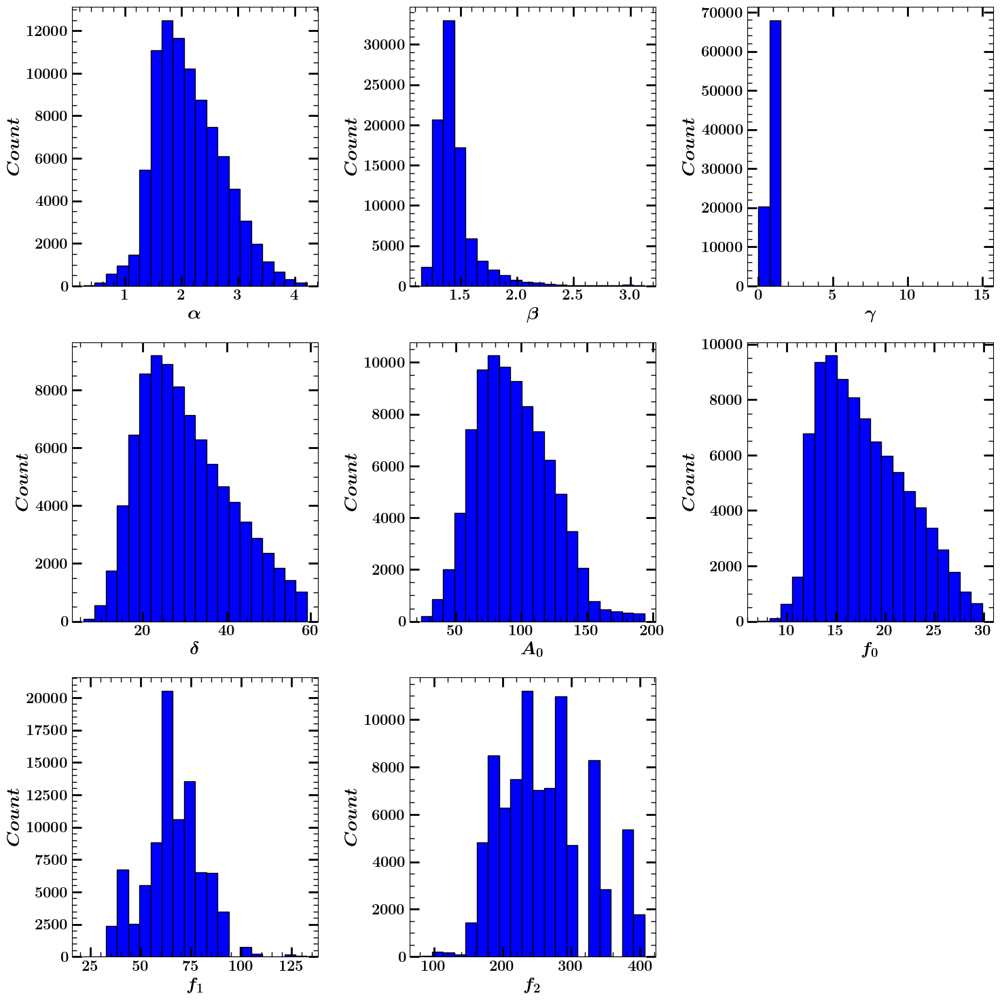

In [181]:
cols = ['alpha', 'beta', 'gamma', 'delta', 'A0', 'f0', 'f1', 'f2']

renamed_cols = cols_fit(cols)
fig, ax = plt.subplots(3, 3, figsize=(15, 15))  
for i in range(len(cols)):
    ax[i//3, i%3].hist(df_removed[cols[i]], bins=20, color='blue', edgecolor='black')
    ax[i//3, i%3].set_xlabel(renamed_cols[i])
    ax[i//3, i%3].set_ylabel(r'$Count$')
    ax[i//3, i%3].grid(False)
    # ax[i//3, i%3].set_title(rf'$Histogram$ $of$ {renamed_cols[i]}')

# Hide the last unused subplot
if len(cols) < 9:
    for j in range(len(cols), 9):
        fig.delaxes(ax[j//3, j%3])

plt.tight_layout()
plt.savefig(graph_dir_spin + "/hist_fit_spin.pdf")
plt.show()

#### Box plot of the fitting parameters of NR signal with Spin BBH systems 

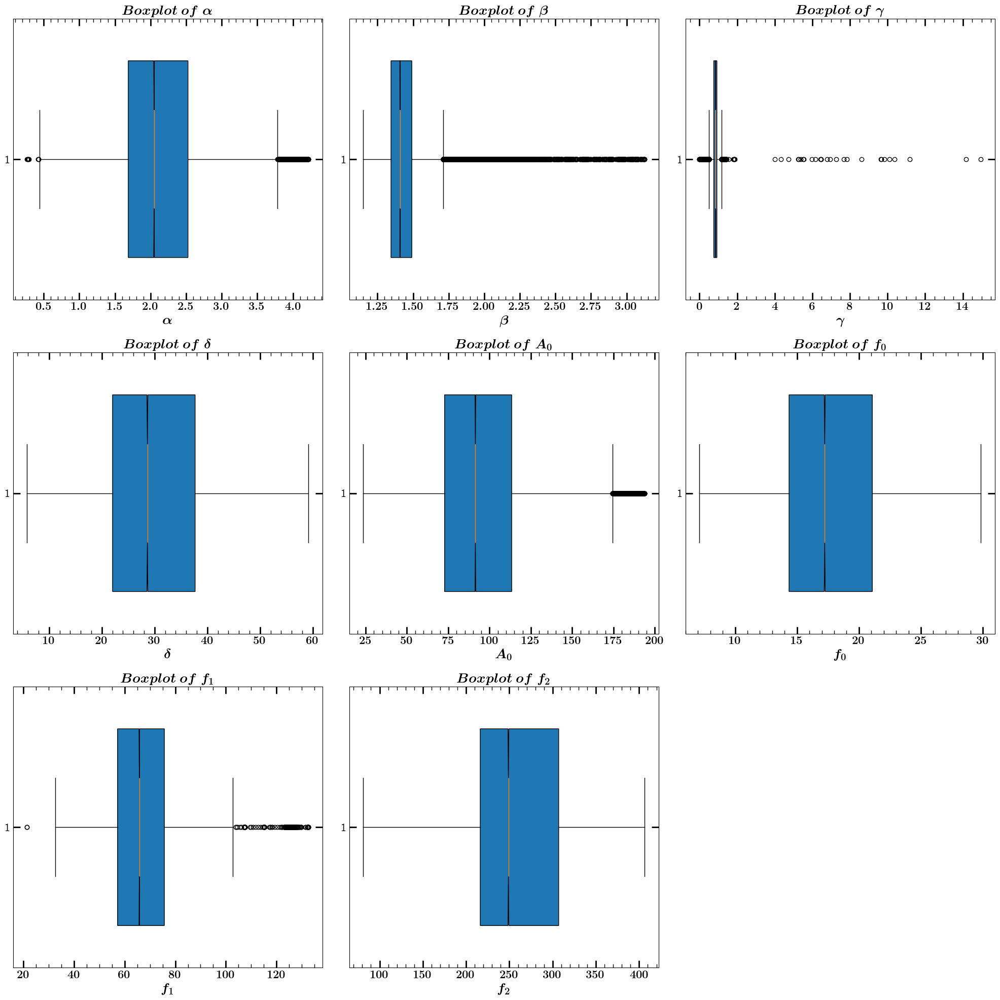

In [182]:
fig, ax = plt.subplots(3, 3, figsize=(20, 20))
for i in range(len(cols)):
    ax[i//3, i%3].boxplot(df_removed[cols[i]], patch_artist = True, notch = True, vert = 0, widths = 0.7)
    ax[i//3, i%3].set_xlabel(renamed_cols[i])
    ax[i//3, i%3].set_title(rf'$Boxplot$ $of$ {renamed_cols[i]}')
    ax[i//3, i%3].grid(False)

ax[2, 2].axis('off')  # Hide the empty subplot
plt.tight_layout()  
plt.savefig(graph_dir_spin + "/box_fit.pdf")
plt.show()

#### Plotting the distribution of binary parameters of GW signal of NR signal for Spin BBH Systems

The below plot is generated for the spins defined in the spherical coordinates. Originally the spins were defined in the cartesian corrdiante system. 

THESIS: Figure 2.14

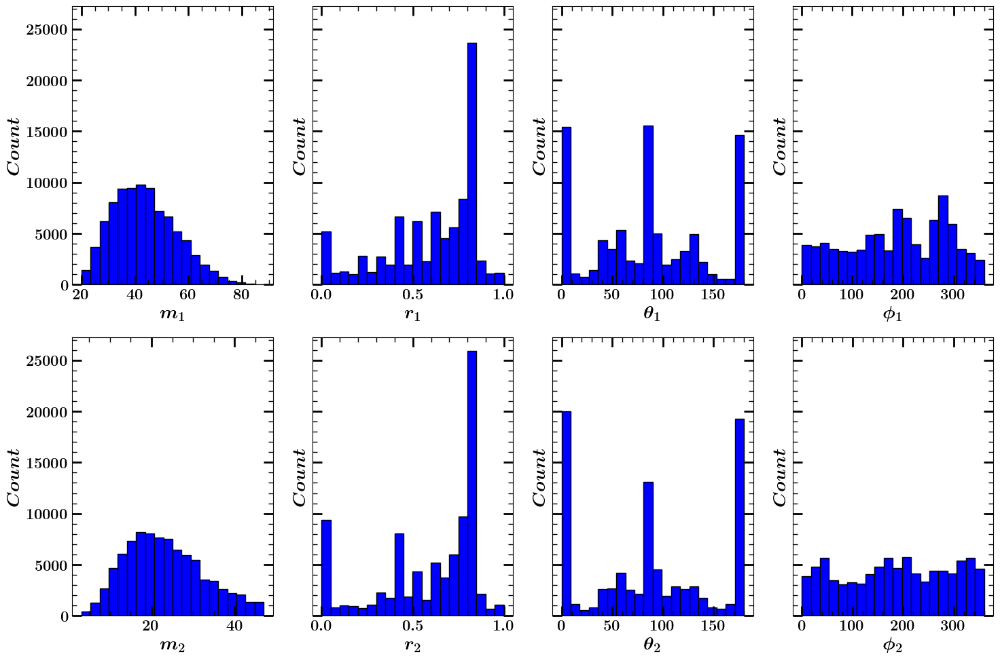

In [183]:
phys_cols = ['m1', 'r1', 'theta1', 'phi1', 'm2', 'r2', 'theta2', 'phi2']

renamed_phys_cols = cols_binary(phys_cols)

n_rows = 2
n_cols = 4
fig, ax = plt.subplots(n_rows, n_cols, figsize=(15, 10), sharey=True)  
for i in range(len(phys_cols)):
    ax[i//n_cols, i%n_cols].hist(df_removed[phys_cols[i]], bins=20, color='blue', edgecolor='black')
    ax[i//n_cols, i%n_cols].set_xlabel(renamed_phys_cols[i])
    ax[i//n_cols, i%n_cols].set_ylabel(r'$Count$')
    ax[i//n_cols, i%n_cols].grid(False)

# plt.suptitle(r'$Histogram$ $of$ $Physical$ $Parameters$')
plt.tight_layout()
plt.savefig(graph_dir_spin + "/hist_phys.pdf")
plt.show()

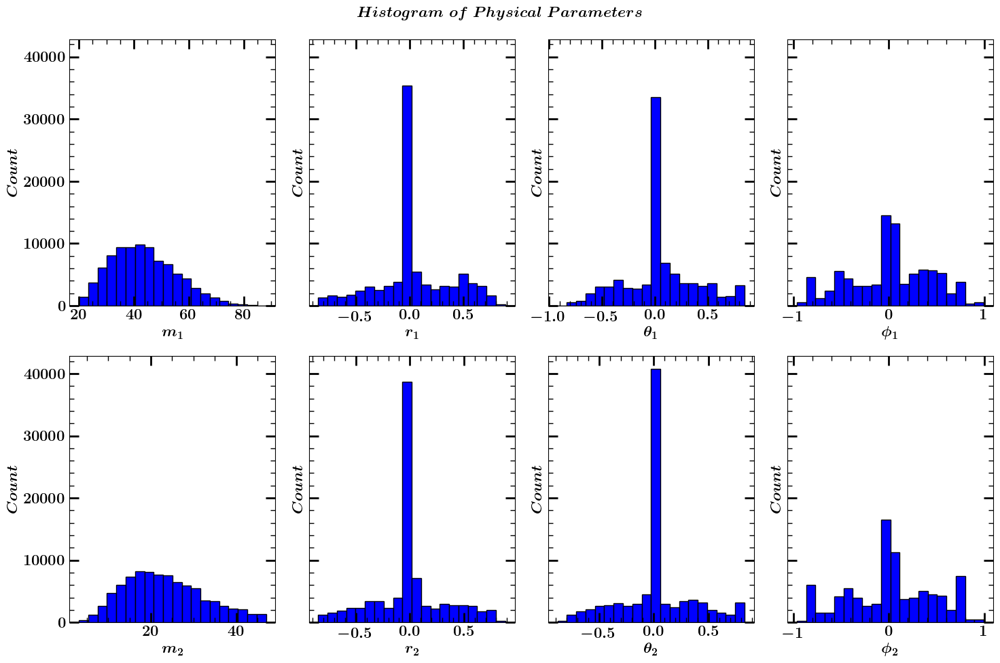

In [184]:
phys_cols = ['m1', 's1x', 's1y', 's1z', 'm2', 's2x', 's2y', 's2z']    

n_rows = 2
n_cols = 4
fig, ax = plt.subplots(n_rows, n_cols, figsize=(15, 10), sharey=True)  
for i in range(len(phys_cols)):
    ax[i//n_cols, i%n_cols].hist(df_removed[phys_cols[i]], bins=20, color='blue', edgecolor='black')
    ax[i//n_cols, i%n_cols].set_xlabel(renamed_phys_cols[i], fontsize=16)
    ax[i//n_cols, i%n_cols].set_ylabel(r'$Count$', fontsize=16)
    ax[i//n_cols, i%n_cols].grid(False)

plt.suptitle(r'$Histogram$ $of$ $Physical$ $Parameters$', fontsize=16)
plt.tight_layout()
plt.savefig(graph_dir_spin + "/hist_phys_cart.pdf")
plt.show()

#### Pearson correlation matrix for all the parameters in the NN Table having the Spins in the Cartesian coordiante system

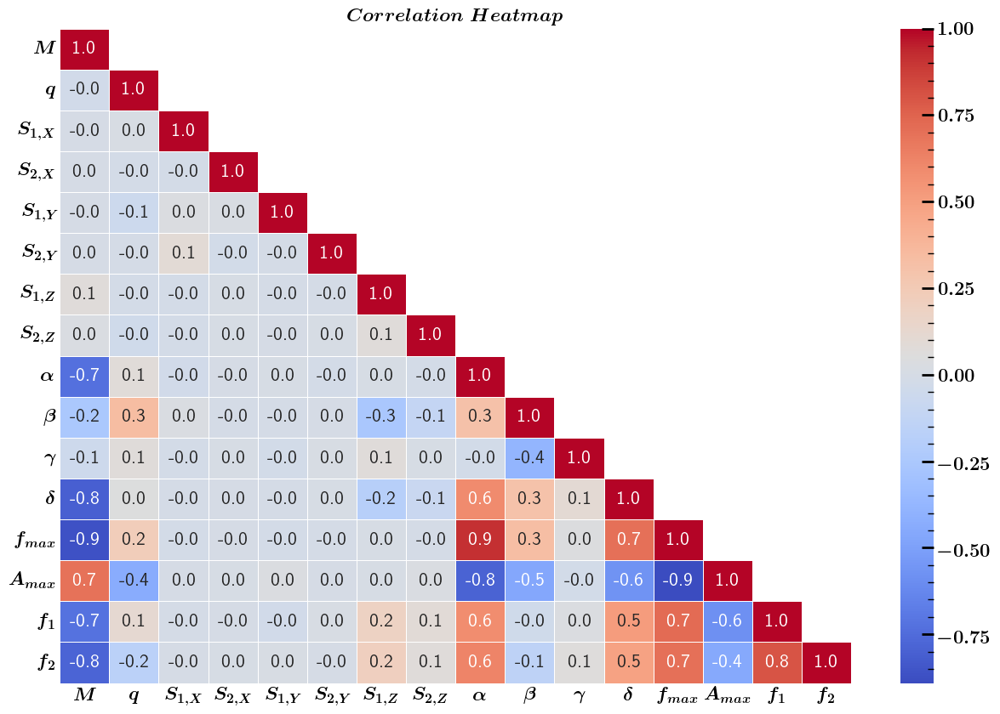

In [185]:
latex_labels = {
    "M": r"$M$", "q": r"$q$", "s1x": r"$S_{1, X}$", "s2x": r"$S_{2, X}$",
    "s1y": r"$S_{1, Y}$", "s2y": r"$S_{2, Y}$", "s1z": r"$S_{1, Z}$", "s2z": r"$S_{2, Z}$",
    "alpha": r"$\alpha$", "beta": r"$\beta$", "gamma": r"$\gamma$", "delta": r"$\delta$", 
    "f0": r"$f_{max}$", "A0": r"$A_{max}$", "f1": r"$f_1$", "f2": r"$f_2$"
}

all_cols = list(latex_labels.keys())

# Correlation Heatmap
df_cols = df_removed[all_cols]
corr = df_cols.corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(15, 10))
ax = sns.heatmap(
    corr, mask=mask, annot=True, cmap="coolwarm", fmt=".1f", linewidths=0.5, 
    xticklabels=[latex_labels[col] for col in all_cols], 
    yticklabels=[latex_labels[col] for col in all_cols]
)

plt.grid(False)
plt.title(r"$Correlation$ $Heatmap$", fontsize=16)  # Adjust title font size

# Remove only ticks but keep labels
ax.xaxis.set_ticks_position('none')  
ax.yaxis.set_ticks_position('none')  

# Increase tick label font size
plt.xticks(fontsize=16)  
plt.yticks(fontsize=16)

plt.savefig(graph_dir_spin + "/corr_all_spin_M_q.pdf")
plt.show()

#### Pearson correlation matrix for all the parameters in the NN Table having the Spins in the Spherical coordiante system

THESIS: Figure 2.15

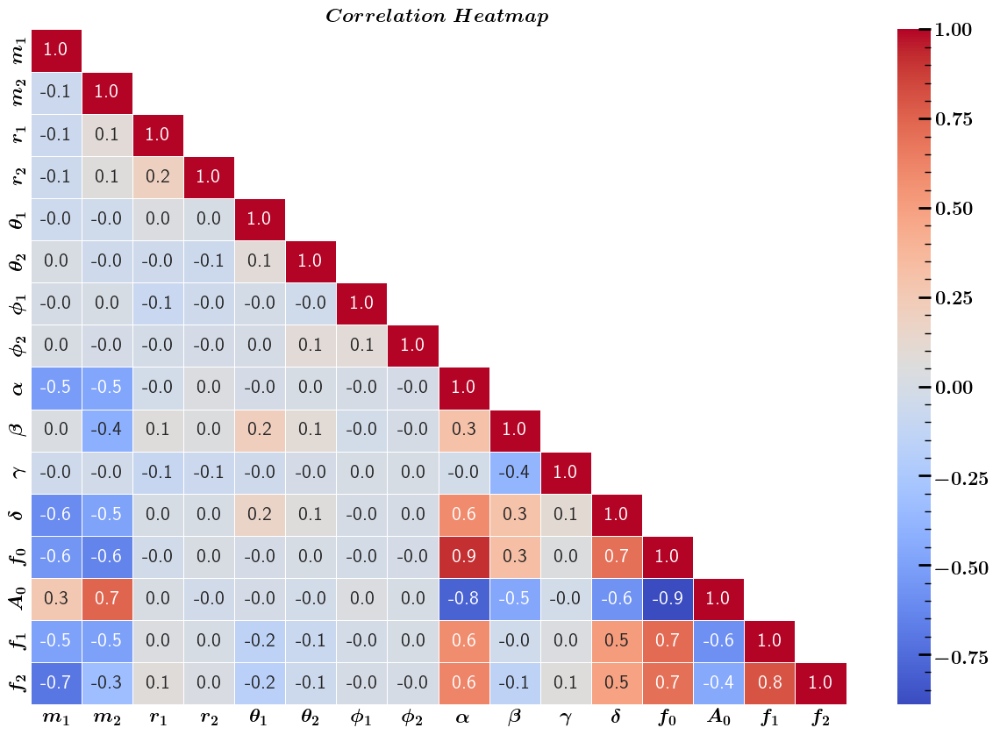

In [186]:
latex_labels = {
    "m1": r"$m_1$", "m2": r"$m_2$", "r1": r"$r_1$", "r2": r"$r_2$",
    "theta1": r"$\theta_1$", "theta2": r"$\theta_2$", "phi1": r"$\phi_1$", "phi2": r"$\phi_2$",
    "alpha": r"$\alpha$", "beta": r"$\beta$", "gamma": r"$\gamma$", "delta": r"$\delta$", 
    "f0": r"$f_{0}$", "A0": r"$A_{0}$", "f1": r"$f_1$", "f2": r"$f_2$"
}

all_cols = list(latex_labels.keys())

# Correlation Heatmap
df_cols = df_removed[all_cols]
corr = df_cols.corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(15, 10))
ax = sns.heatmap(
    corr, mask=mask, annot=True, cmap="coolwarm", fmt=".1f", linewidths=0.5, 
    xticklabels=[latex_labels[col] for col in all_cols], 
    yticklabels=[latex_labels[col] for col in all_cols]
)

plt.grid(False)
plt.title(r"$Correlation$ $Heatmap$", fontsize=16)  # Adjust title font size

# Remove only ticks but keep labels
ax.xaxis.set_ticks_position('none')  
ax.yaxis.set_ticks_position('none')  

# Increase tick label font size
plt.xticks()  
plt.yticks()

plt.savefig(graph_dir_spin + "/corr_all_sph.pdf")
plt.show()

#### Plot of variation of fitting parameters of GW signal with binary parameters of GW signal ($m_{1}$, $m_{2}$)

THESIS: Figure 2.16

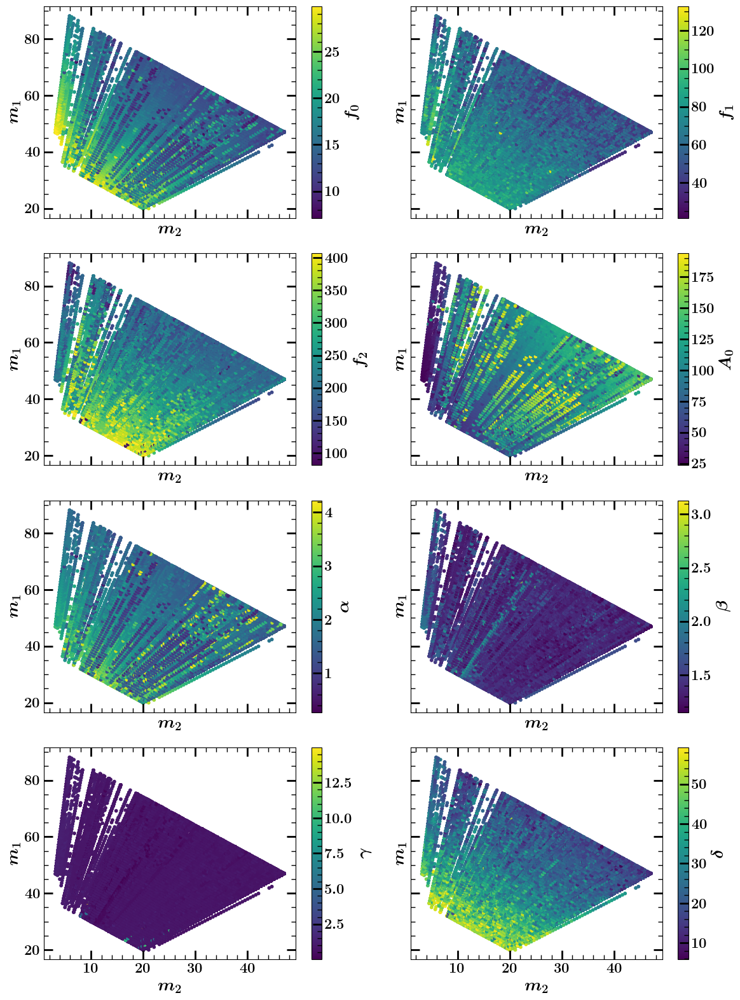

In [188]:
fitting_params = ['f0', 'f1', 'f2', 'A0', 'alpha', 'beta', 'gamma', 'delta']
titles = [r'$f_{0}$', r'$f_{1}$', r'$f_{2}$', r'$A_{0}$', r'$\alpha$', r'$\beta$', r'$\gamma$', r'$\delta$']

fig, axes = plt.subplots(4, 2, figsize=(12, 16), sharex=True, sharey=True)  # Increased figure size

for i, param in enumerate(fitting_params):
    ax = axes[i // 2, i % 2]
    scatter = ax.scatter(df_removed['m2'], df_removed['m1'], c=df_removed[param], s=10, cmap='viridis', rasterized = True)  # Increased marker size
    # ax.set_title(titles[i])  # Larger font size for titles
    ax.set_xlabel(r'$m_{2}$')
    ax.set_ylabel(r'$m_{1}$')
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label(titles[i])
    ax.grid(False)

plt.tight_layout()
plt.savefig(graph_dir_spin + "/m1_m2_fitparams_spin.pdf")
plt.show()


#### Plot of variation of fitting parameters of GW signal with binary parameters of GW signal ($S_{1}$, $S_{2}$) or alternatively represented as ($\chi_1$, $\chi_2$)

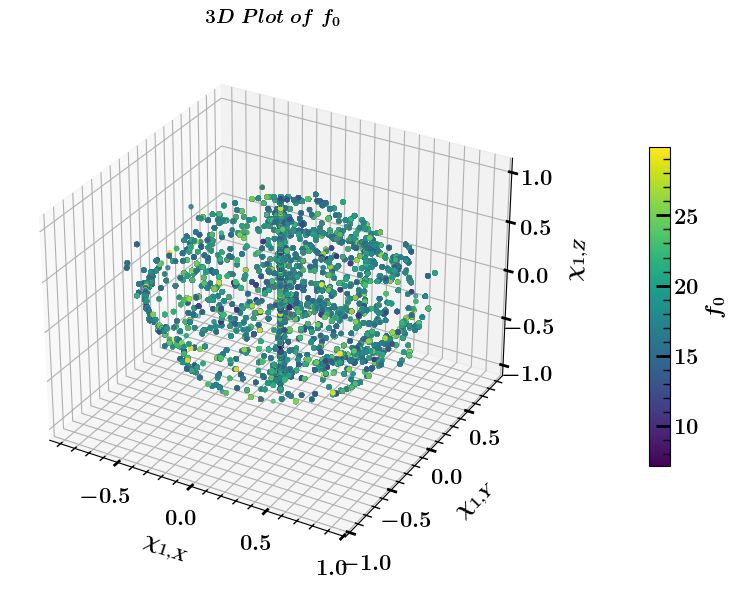

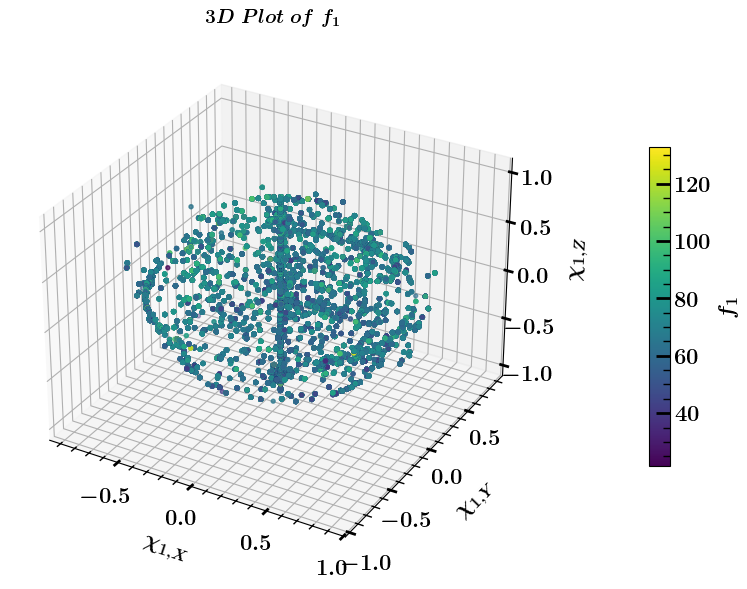

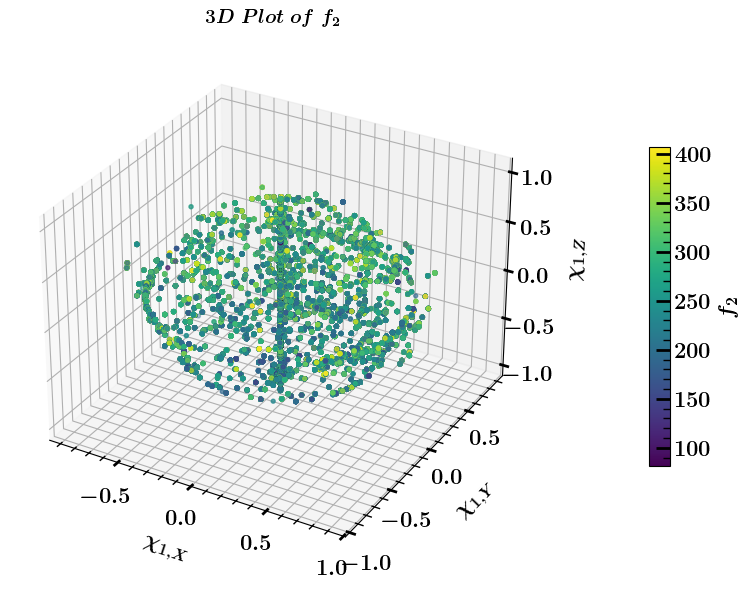

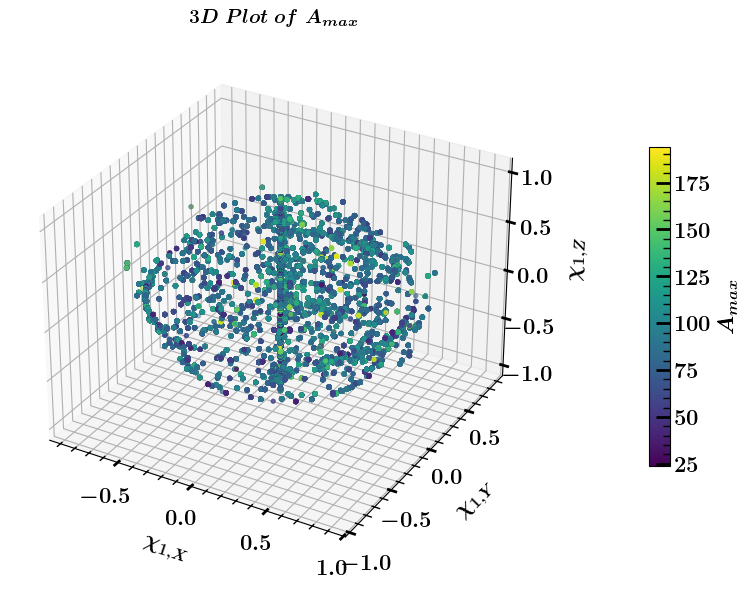

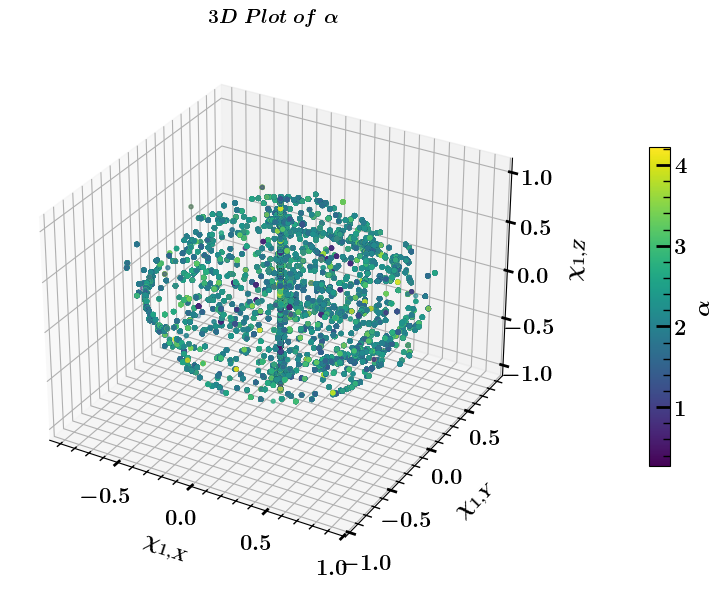

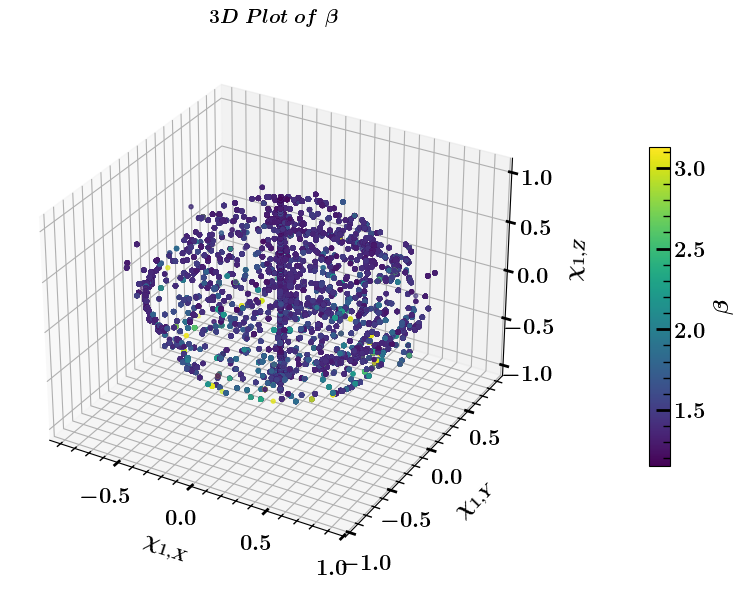

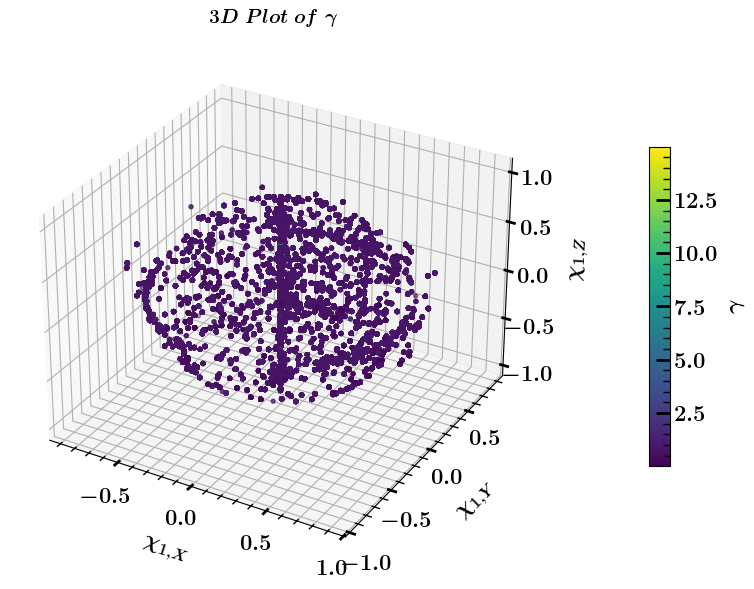

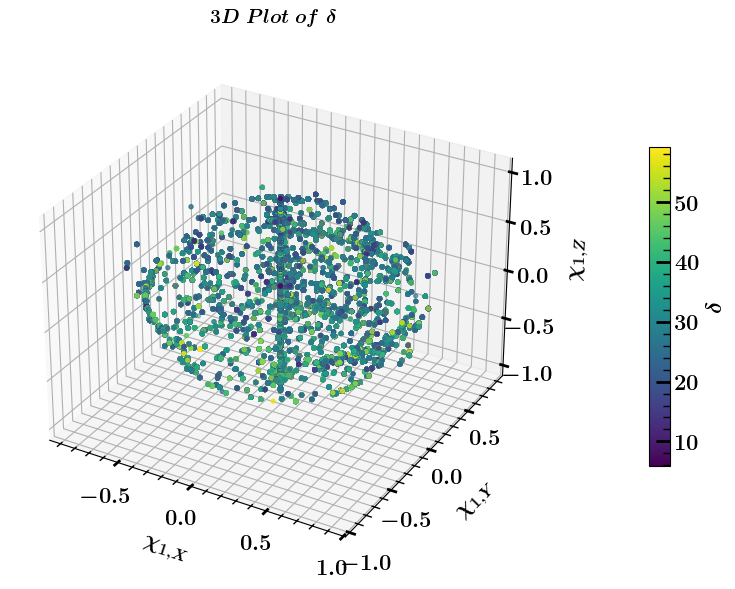

In [189]:
from mpl_toolkits.mplot3d import Axes3D

fitting_params = ['f0', 'f1', 'f2', 'A0', 'alpha', 'beta', 'gamma', 'delta']
titles = [r'$f_{0}$', r'$f_{1}$', r'$f_{2}$', r'$A_{max}$', r'$\alpha$', r'$\beta$', r'$\gamma$', r'$\delta$']

for i, param in enumerate(fitting_params):
    fig = plt.figure(figsize=(8, 6))  # Reduced figure size
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(
        df_removed['s1x'], df_removed['s1y'], df_removed['s1z'], 
        c=df_removed[param], cmap='viridis', s=8, rasterized=True  # Reduced marker size
    )
    ax.set_title(rf"$3D$ $Plot$ $of$ {titles[i]}", fontsize=14, pad=15)  # Adjusted font size and padding
    ax.set_xlabel(r'$\chi_{1, X}$', fontsize=16, labelpad=10)
    ax.set_ylabel(r'$\chi_{1, Y}$', fontsize=16, labelpad=10)
    ax.set_zlabel(r'$\chi_{1, Z}$', fontsize=16, labelpad=10)
    
    # Adjust the color bar position
    cbar = fig.colorbar(scatter, ax=ax, shrink=0.6, aspect=15, pad=0.15)  # Increased padding
    cbar.set_label(titles[i], fontsize=16)
    
    plt.tight_layout()
    plt.savefig(graph_dir_spin + f"/3d_s1_{param}.pdf")
    plt.show()


#### Condensed plot of the above plot showing the variation of fitting parameters with binary parameters of NR signal.

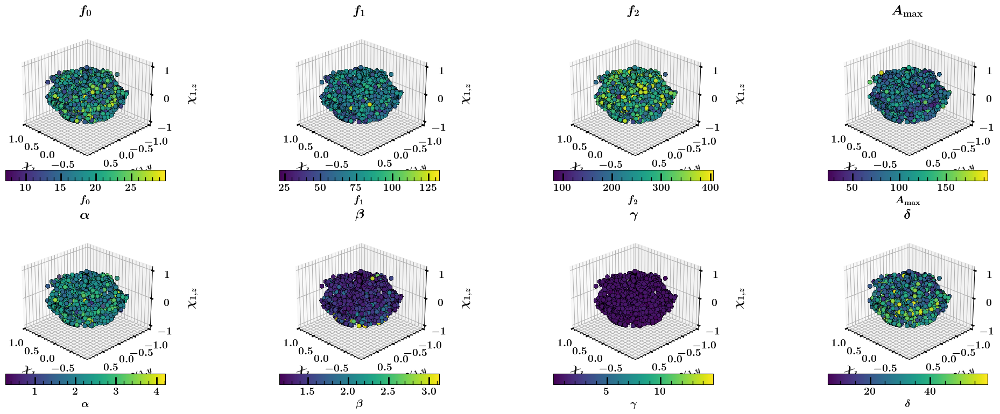

In [190]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl

# --- Parameters ---
fitting_params = ['f0', 'f1', 'f2', 'A0', 'alpha', 'beta', 'gamma', 'delta']
titles = [r'$f_{0}$', r'$f_{1}$', r'$f_{2}$', r'$A_{\mathrm{max}}$', 
          r'$\alpha$', r'$\beta$', r'$\gamma$', r'$\delta$']
axis_labels = [r'$\chi_{1,x}$', r'$\chi_{1,y}$', r'$\chi_{1,z}$']

# --- Plot settings ---
colormap = 'viridis'
point_size = 30  
elev_angle = 25
azim_angle = 135
fontsize_title = 18  
fontsize_label = 16
fontsize_tick = 14
cbar_fontsize = 14
dpi = 300

# --- Create multi-panel figure (2 rows, 4 columns) ---
fig, axes = plt.subplots(2, 4, figsize=(20, 8), subplot_kw={'projection': '3d'})

for i, (ax, param) in enumerate(zip(axes.flat, fitting_params)):
    # 3D scatter plot
    scatter = ax.scatter(
        df_removed['s1x'], df_removed['s1y'], df_removed['s1z'],
        c=df_removed[param], cmap=colormap, s=point_size,
        alpha=0.9, edgecolor='k', linewidth=0.2, rasterized=True
    )

    # Labels and titles
    ax.set_title(titles[i], fontsize=fontsize_title, pad=15)
    ax.set_xlabel(axis_labels[0], fontsize=fontsize_label, labelpad=10)
    ax.set_ylabel(axis_labels[1], fontsize=fontsize_label, labelpad=10)
    ax.set_zlabel(axis_labels[2], fontsize=fontsize_label, labelpad=10)

    ax.tick_params(axis='both', which='major', labelsize=fontsize_tick)
    ax.view_init(elev=elev_angle, azim=azim_angle)
    ax.dist = 8  # Adjust 3D perspective depth

    # Colorbar below each subplot
    mappable = mpl.cm.ScalarMappable(cmap=colormap)
    mappable.set_array(df_removed[param])
    cbar = plt.colorbar(mappable, ax=ax, shrink=0.7, aspect=15, pad=0.02, orientation='horizontal')
    cbar.set_label(titles[i], fontsize=cbar_fontsize)
    cbar.ax.tick_params(labelsize=fontsize_tick)

# Adjust layout to minimize space and overlapping
plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.2)

# Save the optimized figure
fig.savefig(graph_dir_spin + "/optimized_3d_s1_fitparams.pdf")
plt.show()

### Neural Network Model for Spin BBH systems

#### Importing the logistics for this part

##### Importing the libraries to be used in the model

In [191]:
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, r2_score


#### ML model for the Spin BBH Systems

##### Importing the dataset to be used for the model

In [192]:
df_ml = df_removed.copy()

input_cols = ['m1', 'm2', 'r1', 'r2', 'theta1', 'theta2', 'phi1', 'phi2']
# input_cols = ['M', 's1x', 's1y', 's1z', 'q', 's2x', 's2y', 's2z']
output_cols = ['alpha', 'delta', 'A0', 'f0', 'f1', 'f2']
# output_cols = ['alpha', 'beta', 'delta', 'A0', 'f0', 'f1', 'f2']


X = df_ml[input_cols].values
y = df_ml[output_cols].values


# Store the maximum values for rescaling
X_max = np.max(X, axis=0)
y_max = np.max(y, axis=0)

X_norm = X/np.max(X, axis = 0)
y_norm = y/np.max(y, axis = 0)

X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, train_size = 0.8, shuffle = True, random_state = 42)
# X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, shuffle = True, random_state = 42)

print("The shape of the X_train dataset is :", X_train.shape)
print("The shape of the X_test dataset is :", X_test.shape)
print("The shape of the y_train dataset is :", y_train.shape)
print("The shape of the y_test dataset is :", y_test.shape)

The shape of the X_train dataset is : (70662, 8)
The shape of the X_test dataset is : (17666, 8)
The shape of the y_train dataset is : (70662, 6)
The shape of the y_test dataset is : (17666, 6)


##### Defining the ML model for the Spin BBH systems

It is not advisable to run the below model as it may change the training and loss curve of the model. Hence, it is advised to use the saved dataset for the model curve and predictions which is given below.

In [ ]:
# # Hyperparameters
# learning_rate = 5e-4  # Increased learning rate
# epochs = 50           # More epochs for better convergence
# batch_size = 64
# num = X_train.shape[1]

# # Model Definition
# model = Sequential()
# model.add(Input(shape=(num,)))

# # Increase model depth
# model.add(Dense(512, activation='relu'))
# model.add(BatchNormalization())
# model.add(Dropout(0.1))

# model.add(Dense(512, activation='relu'))
# model.add(BatchNormalization())
# model.add(Dropout(0.1))

# model.add(Dense(256, activation='relu'))
# model.add(BatchNormalization())
# model.add(Dropout(0.1))

# model.add(Dense(128, activation='relu'))
# model.add(BatchNormalization())
# model.add(Dropout(0.1))

# model.add(Dense(64, activation='relu'))
# model.add(BatchNormalization())
# model.add(Dropout(0.1))

# model.add(Dense(32, activation='relu'))
# model.add(Dropout(0.1))

# # Output layer (Linear activation for regression)
# model.add(Dense(6, activation='linear'))

# # Learning Rate Scheduler
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# # Compile Model
# model.compile(optimizer=AdamW(learning_rate=learning_rate), loss='mse')

# # Train Model
# history = model.fit(X_train, y_train, 
#                     batch_size=batch_size, 
#                     epochs=epochs, verbose=1, 
#                     validation_data=(X_test, y_test), 
#                     callbacks=[reduce_lr])

# # Predictions
# y_pred_train = model.predict(X_train)
# y_pred_test = model.predict(X_test)

# # Calculate Metrics
# mse_train = mean_squared_error(y_train, y_pred_train)
# r2_train = r2_score(y_train, y_pred_train)

# mse_test = mean_squared_error(y_test, y_pred_test)
# r2_test = r2_score(y_test, y_pred_test)

# print(f"Train MSE: {mse_train}, Train R^2: {r2_train}")
# print(f"Test MSE: {mse_test}, Test R^2: {r2_test}")

# # model.save(data_dir + "model_tf_best.keras")
# # with open(data_dir + 'model_2_history.h5', 'wb') as f:
# #     pickle.dump(history.history, f)

Epoch 1/50
1105/1105 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 0.3279 - val_loss: 0.0137 - learning_rate: 5.0000e-04
Epoch 2/50
1105/1105 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0260 - val_loss: 0.0101 - learning_rate: 5.0000e-04
Epoch 3/50
1105/1105 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0152 - val_loss: 0.0081 - learning_rate: 5.0000e-04
Epoch 4/50
1105/1105 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0110 - val_loss: 0.0071 - learning_rate: 5.0000e-04
Epoch 5/50
1105/1105 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 0.0092 - val_loss: 0.0067 - learning_rate: 5.0000e-04
Epoch 6/50
1105/1105 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0084 - val_loss: 0.0065 - learning_rate: 5.0000e-04
Epoch 7/50
1105/1105 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 0.0079 - val_loss: 0.0065 - learning_rate: 5.0000e-04
Epoch 8/50
1105/1105 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0077 - val_loss: 0.0063 - learning_rate: 5.0000e-04
Epoch 9/50
1105/1105 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step 

##### Plotting the loss function of the training and validation set for each epoch

THESIS: Figure 4.3

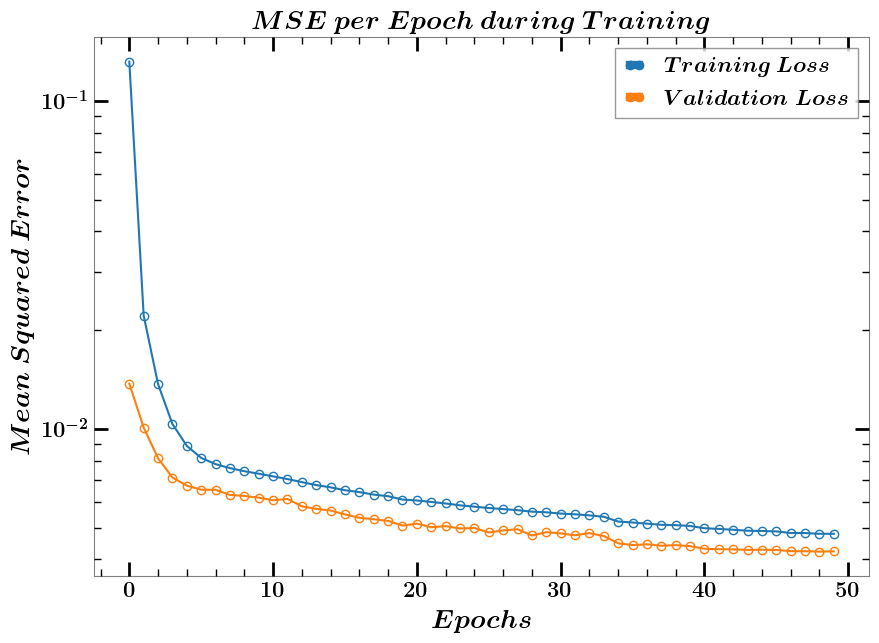

In [ ]:
# Plot MSE vs. Epochs
plt.figure(figsize=(10, 7))
plt.plot(history.history["loss"], marker='o', linestyle='-', label = r"$Training$ $Loss$")
plt.plot(history.history["val_loss"], marker='o', linestyle='-', label = r"$Validation$ $Loss$")
plt.xlabel(r"$Epochs$")
plt.ylabel(r"$Mean$ $Squared$ $Error$")
plt.title(r"$MSE$ $per$ $Epoch$ $during$ $Training$")
plt.xticks()
plt.yticks()
plt.grid(False)
plt.legend()
plt.yscale("log")
# plt.savefig(graph_dir_spin + "model_2_loss_sph.pdf")
# plt.savefig(graph_dir_spin + "model_2_loss_sph.png")
plt.show()

Saving each and every information about the model and predicting the dataset

In [ ]:
# import os
# import numpy as np
# import h5py
# import pickle
# import json

# # Create save directory
# data_dir_spin = "/mnt/d/Darsh/MSThesis/template_model/dataset/dataset_2_spin/"
# os.makedirs(data_dir_spin, exist_ok=True)

# # 1. Save the model in Keras format (.keras)
# model.save(os.path.join(data_dir_spin, "spin_model_final.keras"))

# # 2. Save training history in HDF5 format
# with h5py.File(os.path.join(data_dir_spin, "spin_model_final_history.h5"), "w") as f:
#     for key, val in history.history.items():
#         f.create_dataset(key, data=np.array(val))

# # 3. Save predictions in HDF5 format
# with h5py.File(os.path.join(data_dir_spin, "spin_model_final_predictions.h5"), "w") as f:
#     f.create_dataset("y_pred_train", data=y_pred_train)
#     f.create_dataset("y_pred_test", data=y_pred_test)

# # 4. Save true target values in HDF5 format
# with h5py.File(os.path.join(data_dir_spin, "spin_model_final_targets.h5"), "w") as f:
#     f.create_dataset("y_train", data=y_train)
#     f.create_dataset("y_test", data=y_test)

# # 5. Save metrics in HDF5 format
# with h5py.File(os.path.join(data_dir_spin, "spin_model_final_metrics.h5"), "w") as f:
#     f.create_dataset("mse_train", data=np.array(mse_train))
#     f.create_dataset("r2_train", data=np.array(r2_train))
#     f.create_dataset("mse_test", data=np.array(mse_test))
#     f.create_dataset("r2_test", data=np.array(r2_test))


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 512)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,337,844 (5.10 MB)

 Trainable params: 444,966 (1.70 MB)

 Non-trainable params: 2,944 (11.50 KB)

 Optimizer params: 889,934 (3.39 MB)

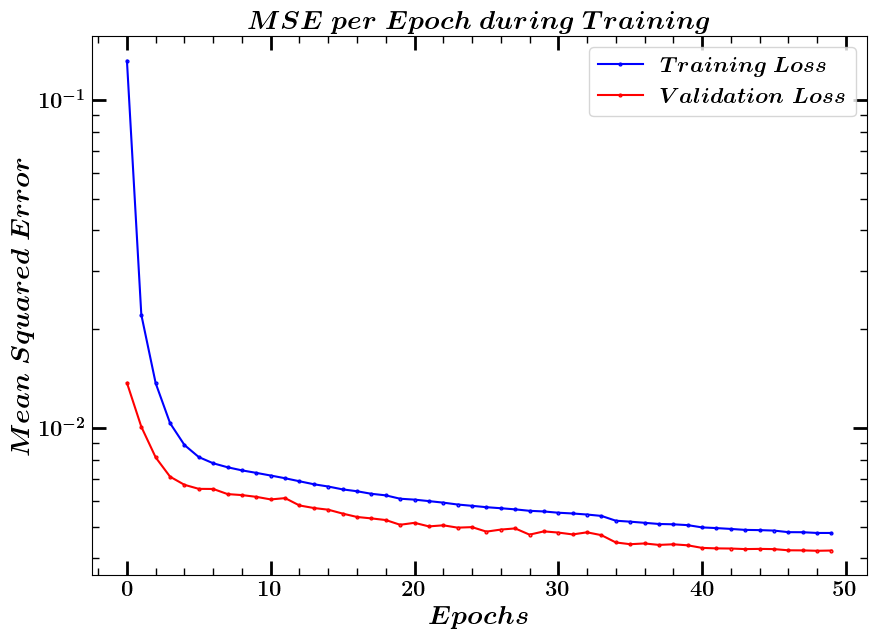


Final Model Evaluation Metrics (from saved data):

Train MSE  : 0.003973
Train R²   : 0.816432
Test MSE   : 0.004230
Test R²    : 0.804097


In [195]:
# -------------------------------
# 1. Load the saved Keras model
# -------------------------------
model = load_model(os.path.join(data_dir_spin, "spin_model_final.keras"))
model.summary()

# -------------------------------
# 2. Load training history
# -------------------------------
with h5py.File(os.path.join(data_dir_spin, "spin_model_final_history.h5"), "r") as f:
    history = {key: np.array(f[key]) for key in f.keys()}

# -------------------------------
# 3. Plot loss function (MSE) per epoch
# -------------------------------
plt.figure(figsize=(10, 7))
plt.plot(history['loss'], linestyle='-', marker='o', color='b', markersize=2, label=r"$Training$ $Loss$")
plt.plot(history['val_loss'], linestyle='-', marker='o', color='r', markersize=2, label=r"$Validation$ $Loss$")
plt.xlabel(r"$Epochs$")
plt.ylabel(r"$Mean$ $Squared$ $Error$")
plt.title(r"$MSE$ $per$ $Epoch$ $during$ $Training$")
plt.legend()
plt.yscale("log")
plt.grid(False)
plt.show()

# -------------------------------
# 4. Load and print evaluation metrics
# -------------------------------
with h5py.File(os.path.join(data_dir_spin, "spin_model_final_metrics.h5"), "r") as f:
    mse_train = f['mse_train'][()]
    r2_train = f['r2_train'][()]
    mse_test = f['mse_test'][()]
    r2_test = f['r2_test'][()]

print("\nFinal Model Evaluation Metrics (from saved data):\n")
print(f"Train MSE  : {mse_train:.6f}")
print(f"Train R²   : {r2_train:.6f}")
print(f"Test MSE   : {mse_test:.6f}")
print(f"Test R²    : {r2_test:.6f}")


##### Plotting the results obtained from the predictions of the model and the model

Results of the predictions of the model and its comparison with the actual values. Please note that the below code only works when you have trained the model in your computer. However, the training of the model is not advised, as the different training causes different loss functions and its values over iteration to vary. Causing different predictions. 

Note that - However, the result will almost be same after running the code with some slight variations in the model. 

THESIS: Table 4.2

In [ ]:
# Define parameter names corresponding to the output layer
parameter_names = ['α', 'δ', 'A₀', 'f₀', 'f₁', 'f₂']

# Create a DataFrame for actual and predicted values
comparison_df = pd.DataFrame({
    f'Actual {name}': y_test[:, idx] for idx, name in enumerate(parameter_names)
})
for idx, name in enumerate(parameter_names):
    comparison_df[f'Predicted {name}'] = y_pred_test[:, idx]

# Calculate the squared error for each parameter (internally)
squared_errors = []
for idx, name in enumerate(parameter_names):
    error = (comparison_df[f'Actual {name}'] - comparison_df[f'Predicted {name}']) ** 2
    squared_errors.append(error)

# Calculate Mean Squared Error (MSE) per sample
comparison_df['MSE'] = pd.concat(squared_errors, axis=1).mean(axis=1)

# Select only the relevant columns for display: Actual, Predicted, MSE
columns_to_display = [f'Actual {name}' for name in parameter_names] + \
                     [f'Predicted {name}' for name in parameter_names] + \
                     ['MSE']

# Display the top 10 rows with the smallest MSE
print(comparison_df[columns_to_display].head(5).to_string(index=False))

 Actual α  Actual δ  Actual A₀  Actual f₀  Actual f₁  Actual f₂  Predicted α  Predicted δ  Predicted A₀  Predicted f₀  Predicted f₁  Predicted f₂      MSE
 0.461061  0.337840   0.673707   0.461638   0.462595   0.571062     0.407280     0.369977      0.631626      0.467450      0.414158      0.532448 0.001594
 0.527503  0.375392   0.572609   0.547738   0.532082   0.704479     0.481079     0.408003      0.506563      0.562808      0.518297      0.667892 0.001556
 0.411788  0.399736   0.666044   0.469739   0.462570   0.571032     0.398616     0.325744      0.648949      0.468244      0.446282      0.584198 0.001064
 0.361190  0.756889   0.618228   0.475700   0.431347   0.532488     0.423142     0.601251      0.539941      0.550408      0.516211      0.649308 0.010103
 0.423319  0.503798   0.521055   0.517232   0.704097   0.571048     0.436772     0.455315      0.539195      0.520510      0.469500      0.587849 0.009698


##### Predictions of the model

Table of the predictions of the Spin BBH systems loaded from the saved dataset. Please not that the below code will work always. If you have run the code in your computer (training the model on your PC), then you may generate the predictions from the above code. 

In [197]:
# Define directory path
# Define parameter names as per output layer
parameter_names = ['α', 'δ', 'A₀', 'f₀', 'f₁', 'f₂']

# Load predictions
with h5py.File(os.path.join(data_dir_spin, "spin_model_final_predictions.h5"), "r") as f:
    y_pred_test = f["y_pred_test"][:]

# Load true target values
with h5py.File(os.path.join(data_dir_spin, "spin_model_final_targets.h5"), "r") as f:
    y_test = f["y_test"][:]

# Create a DataFrame for actual and predicted values
comparison_df = pd.DataFrame({
    f'Actual {name}': y_test[:, idx] for idx, name in enumerate(parameter_names)
})
for idx, name in enumerate(parameter_names):
    comparison_df[f'Predicted {name}'] = y_pred_test[:, idx]

# Calculate squared errors
squared_errors = []
for idx, name in enumerate(parameter_names):
    error = (comparison_df[f'Actual {name}'] - comparison_df[f'Predicted {name}']) ** 2
    squared_errors.append(error)

# Compute Mean Squared Error (MSE) per sample
comparison_df['MSE'] = pd.concat(squared_errors, axis=1).mean(axis=1)

# Select columns for display
columns_to_display = [f'Actual {name}' for name in parameter_names] + \
                     [f'Predicted {name}' for name in parameter_names] + ['MSE']

# Display top 5 rows with lowest MSE
print(comparison_df[columns_to_display].head(5).to_string(index=False))


 Actual α  Actual δ  Actual A₀  Actual f₀  Actual f₁  Actual f₂  Predicted α  Predicted δ  Predicted A₀  Predicted f₀  Predicted f₁  Predicted f₂      MSE
 0.461061  0.337840   0.673707   0.461638   0.462595   0.571062     0.407280     0.369977      0.631626      0.467450      0.414158      0.532448 0.001594
 0.527503  0.375392   0.572609   0.547738   0.532082   0.704479     0.481079     0.408003      0.506563      0.562808      0.518297      0.667892 0.001556
 0.411788  0.399736   0.666044   0.469739   0.462570   0.571032     0.398616     0.325744      0.648949      0.468244      0.446282      0.584198 0.001064
 0.361190  0.756889   0.618228   0.475700   0.431347   0.532488     0.423142     0.601251      0.539941      0.550408      0.516211      0.649308 0.010103
 0.423319  0.503798   0.521055   0.517232   0.704097   0.571048     0.436772     0.455315      0.539195      0.520510      0.469500      0.587849 0.009698


# Section 3 - Quantum Neural Network

## Introduction to Quantum Neural Network

### Importing the logistics and defining the loaction of paths

##### Importing the libraries 

In [113]:
from qiskit import *
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, EfficientSU2

##### Defining the loactions of the dataset

In [114]:
# Choose your main folder name
folder_name = "qnn"

# Get the current working directory
current_path = os.getcwd()
print("Current Path:", current_path)


# Define paths
folder_dir = os.path.join(current_path, folder_name)
data_dir = os.path.join(folder_dir, "dataset")
graph_dir = os.path.join(folder_dir, "graph")

# Check and create directories only if they don't exist
if not os.path.exists(folder_dir):
    os.makedirs(data_dir)
    os.makedirs(graph_dir)
    print("Directories created.")
else:
    print("Directories already exist. Nothing done.")

# Optional: print the paths for later use
print("Folder Path:", folder_dir)
print("Data Path:", data_dir)
print("Graph Path:", graph_dir)

Current Path: /mnt/d/Darsh/MSThesis/Final Code MS
Directories already exist. Nothing done.
Folder Path: /mnt/d/Darsh/MSThesis/Final Code MS/qnn
Data Path: /mnt/d/Darsh/MSThesis/Final Code MS/qnn/dataset
Graph Path: /mnt/d/Darsh/MSThesis/Final Code MS/qnn/graph


In [115]:
data_dir_intro_qnn = os.path.join(data_dir, "intro")
graph_dir_intro_qnn = os.path.join(graph_dir, "intro")
# Check and create directories only if they don't exist
if not os.path.exists(data_dir_intro_qnn):
    os.makedirs(data_dir_intro_qnn)

if not os.path.exists(graph_dir_intro_qnn):
    os.makedirs(graph_dir_intro_qnn)

### Comparison between Quantum Neural Networks and Classical Neural Networks

#### One Feature Problem 
We compare the QNN and NN using one feature problem for Classical NN, I used MLP Classifier (The problem is a classification problem) and NN from Tensorflow to get the result for one feature problem 

##### Importing the libraries

In [116]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from tensorflow.keras.metrics import Accuracy

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap, ZFeatureMap
from qiskit_machine_learning.optimizers import COBYLA, L_BFGS_B
from qiskit_machine_learning.utils import algorithm_globals

from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier, VQC
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.circuit.library import QNNCircuit
from sklearn.model_selection import train_test_split

# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

##### Assigning the Dataset

In [117]:
X = np.array(np.random.rand(1, 200)).flatten()
Y = [1 if x >= 0.5 else 0 for x in X]

# Split into train/test
X_train, X_test = X[:175], X[175:]
Y_train, Y_test = Y[:175], Y[175:]
# print(X_train)
# print(Y_train)

# Convert to numpy arrays with the correct shape
X_train = np.array(X_train).reshape(-1, 1)
X_test = np.array(X_test).reshape(-1, 1)
Y_train = np.array(Y_train)
Y_test = np.array(Y_test)

##### MLP Classifiers

In [202]:
# Define the model
mlp = MLPClassifier(
    hidden_layer_sizes=(1, 4, 1),  # Three hidden layers with specified sizes
    activation='tanh',                 # Activation function
    solver='adam',                     # Optimizer
    learning_rate='constant',          # Adjust learning rate dynamically
    learning_rate_init=0.005,          # Initial learning rate
    max_iter=50000,                      # Maximum number of iterations
    random_state=42,                   # Ensure reproducibility
    verbose=True, tol = 1e-5, n_iter_no_change=100                      # Print training progress
)

# Train the model
mlp.fit(X_train, Y_train)

# Evaluate the model for mlp 
predict_test = mlp.predict(X_test)
predict_train = mlp.predict(X_train)

acc_test = mlp.score(X_test, Y_test)
acc_train = mlp.score(X_train, Y_train)

print(f"Classical MLP Accuracy over train dataset: {acc_train:.4f}")
print(f"Classical MLP Accuracy over test dataset: {acc_test:.4f}")

Iteration 1, loss = 0.81496505
Iteration 2, loss = 0.80572595
Iteration 3, loss = 0.79668105
Iteration 4, loss = 0.78787366
Iteration 5, loss = 0.77934683
Iteration 6, loss = 0.77114228
Iteration 7, loss = 0.76329937
Iteration 8, loss = 0.75585391
Iteration 9, loss = 0.74883713
Iteration 10, loss = 0.74227468
Iteration 11, loss = 0.73618591
Iteration 12, loss = 0.73058331
Iteration 13, loss = 0.72547226
Iteration 14, loss = 0.72085111
Iteration 15, loss = 0.71671145
Iteration 16, loss = 0.71303868
Iteration 17, loss = 0.70981271
Iteration 18, loss = 0.70700882
Iteration 19, loss = 0.70459867
Iteration 20, loss = 0.70255120
Iteration 21, loss = 0.70083367
Iteration 22, loss = 0.69941254
Iteration 23, loss = 0.69825432
Iteration 24, loss = 0.69732629
Iteration 25, loss = 0.69659708
Iteration 26, loss = 0.69603716
Iteration 27, loss = 0.69561918
Iteration 28, loss = 0.69531814
Iteration 29, loss = 0.69511154
Iteration 30, loss = 0.69497941
Iteration 31, loss = 0.69490428
Iteration 32, los

##### Neural Network Classifier from TensorFlow

In [203]:
# Define a very simple model
model = keras.Sequential([
    layers.Dense(1, activation='sigmoid', input_shape=(1,))  # Single neuron with sigmoid
])

# Compile model with SGD (better for small datasets)
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.5),  # Higher LR for fast convergence
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train model
model.fit(X_train, Y_train, epochs=500, verbose=0)  # Train longer for better accuracy

# Evaluate the model properly
loss, acc_test = model.evaluate(X_test, Y_test, verbose=0)
acc_train = model.evaluate(X_train, Y_train, verbose=0)[1]

# Predict and apply thresholding
predict_train = (model.predict(X_train) >= 0.5).astype(int).flatten()
predict_test = (model.predict(X_test) >= 0.5).astype(int).flatten()

# Compute final accuracy manually
train_acc_manual = np.mean(predict_train == Y_train)
test_acc_manual = np.mean(predict_test == Y_test)

print(f"\nTrain Predictions: {predict_train}")
print(f"Test Predictions: {predict_test}")
print(f"\nClassical NN Accuracy over train dataset: {train_acc_manual:.4f}")
print(f"Classical NN Accuracy over test dataset: {test_acc_manual:.4f}")

/home/darsh/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Train Predictions: [0 1 1 1 0 0 0 1 1 1 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 1 1 0 1 0 0 1 1 1 0
 0 1 0 0 1 0 1 0 1 0 1 1 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0 0 1 0 1 0 1 1 0 0 1
 1 1 1 0 0 0 1 1 0 0 0 0 1 1 1 0 0 1 1 1 1 1 1 0 0 0 0 1 0 1 1 0 0 1 0 0 0
 0 1 1 1 1 1 0 1 1 1 1 0 0 0 0 1 1 0 1 0 0 0 0 1 0 1 1 0 1 1 0 1 0 0 0 1 1
 0 0 1 0 0 0 1 0 1 1 0 1 0 1 1 1 0 1 0 0 0 1 1 0 1 0 1]
Test Predictions: [0 1 0 1 0 0 0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 1 1 1 1]

Classical NN Accuracy over train dataset: 0.9829
Classical NN Accuracy over test dataset: 1.0000


##### Neural Network Regressor from Qiskit_Machine_Learning 
This contains 2 repititions of the ZZFeatureMap and 8 repititions of RealAmplitudes with Sampler using the optimizer as L_BFGS_B

THESIS: Figure 1.19

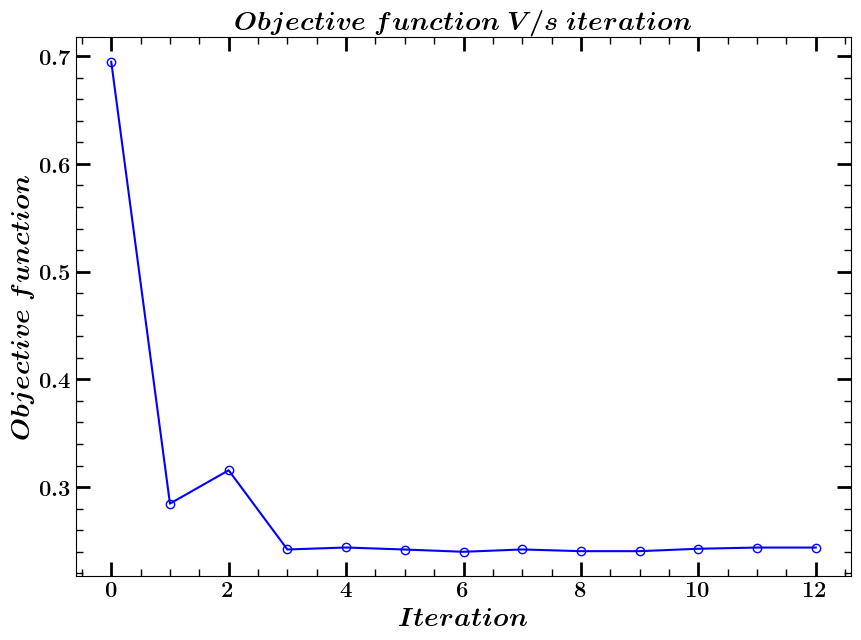

The Score of the training dataset is : 0.9885714285714285
The Score of the test dataset is : 0.96


In [206]:
algorithm_globals.random_seed = 42
np.random.seed(42)

n = 1
rep_fm = 2  # repitions for feature map ZFeatureMap
rep_an = 8  # repititions for ansatz

feature_map = ZFeatureMap(feature_dimension = n, reps = rep_fm)
ansatz = RealAmplitudes(num_qubits = n, reps = rep_an)

qc = QNNCircuit(num_qubits=n, feature_map = feature_map, ansatz = ansatz)
# qc.draw("mpl")

from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.primitives import StatevectorSampler as Sampler

# estimator = Estimator()
sampler = Sampler()

# estimator_qnn = EstimatorQNN(circuit=qc, estimator=estimator)
sampler_qnn = SamplerQNN(circuit=qc, sampler=sampler)

# estimator_qnn.forward(X_train[0], algorithm_globals.random.random(estimator_qnn.num_weights))
sampler_qnn.forward(X_train[0], algorithm_globals.random.random(sampler_qnn.num_weights))

def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title(r"$Objective$ $function$ $V/s$ $iteration$")
    plt.xlabel(r"$Iteration$")
    plt.ylabel(r"$Objective$ $function$")
    plt.plot(range(len(objective_func_vals)), objective_func_vals, "bo-")
    plt.xticks()
    plt.yticks()
    plt.savefig(graph_dir_intro_qnn + "/1_feature_loss.pdf", bbox_inches = "tight")
    plt.show()

# estimator_classifier = NeuralNetworkClassifier(estimator_qnn, 
#                                                optimizer=COBYLA(maxiter=50), 
#                                                callback=callback_graph)

sampler_classifier = NeuralNetworkClassifier(sampler_qnn,
                                            optimizer=L_BFGS_B(maxiter=50), 
                                            callback=callback_graph)
objective_func_vals = []
plt.rcParams["figure.figsize"] = (10, 7)
# estimator_classifier.fit(X_train, Y_train)
sampler_classifier.fit(X_train, Y_train)


plt.rcParams["figure.figsize"] = (6, 4)


# score_test = estimator_classifier.score(X_test, Y_test)
# score_train = estimator_classifier.score(X_train, Y_train)

score_test = sampler_classifier.score(X_test, Y_test)
score_train = sampler_classifier.score(X_train, Y_train)

print("The Score of the training dataset is :", score_train)
print("The Score of the test dataset is :", score_test)

#### Two Feature Problem 
This problem consists of two features and is again a demo problem which is used to establish the use case of QML for the simple deterministic problem. We first define the dataset and then define the CLassical and Quantum Models and then compare them.  

##### Creating the dataset for the two feature problem and plotting it 

THESIS: Figure 1.20

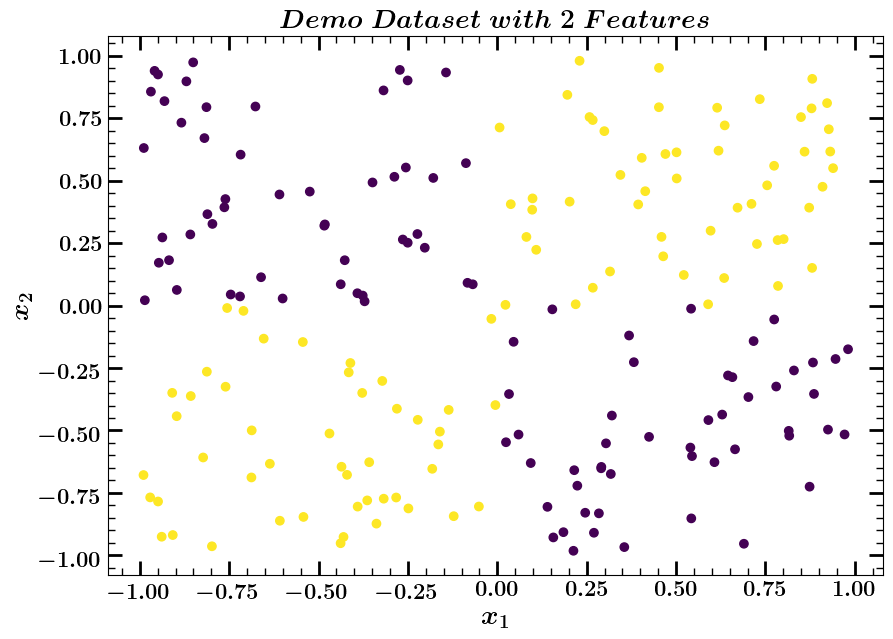

In [207]:
np.random.seed(42)
tf.random.set_seed(42)

num_samples = 200
# Two features
X = np.random.rand(num_samples, 2) * 2 - 1  # Random values in range [-1, 1]
# Labels: simple XOR-like pattern
Y = (X[:, 0] * X[:, 1] > 0).astype(int)  # 1 if both values have the same sign, else 0

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Convert labels to required shape
Y_train = Y_train.reshape(-1)
Y_test = Y_test.reshape(-1)

plt.figure(figsize = (10, 7))
plt.scatter(X[:, 0], X[:, 1], c = Y)
plt.xlabel(r"$x_{1}$")
plt.ylabel(r"$x_{2}$")
plt.xticks()
plt.yticks()
plt.grid(False)
plt.title(r"$Demo$ $Dataset$ $with$ $2$ $Features$")
plt.savefig(graph_dir_intro_qnn + "/demo_dataset.pdf")
plt.show()

##### MLP Classifier

In [208]:
# Define the model
mlp = MLPClassifier(
    hidden_layer_sizes=(2, 4, 1),  # Three hidden layers with specified sizes
    activation='tanh',                 # Activation function
    solver='adam',                     # Optimizer
    learning_rate='constant',          # Adjust learning rate dynamically
    learning_rate_init=0.005,          # Initial learning rate
    max_iter=50000,                      # Maximum number of iterations
    random_state=42,                   # Ensure reproducibility
    verbose=True, tol = 1e-5, n_iter_no_change=100                      # Print training progress
)

# Train the model
mlp.fit(X_train, Y_train)

# Evaluate the model for mlp 
predict_test = mlp.predict(X_test)
predict_train = mlp.predict(X_train)

acc_test = mlp.score(X_test, Y_test)
acc_train = mlp.score(X_train, Y_train)

print(f"Classical MLP Accuracy over train dataset: {acc_train:.4f}")
print(f"Classical MLP Accuracy over test dataset: {acc_test:.4f}")

Iteration 1, loss = 0.70151057
Iteration 2, loss = 0.70078450
Iteration 3, loss = 0.70011286
Iteration 4, loss = 0.69948861
Iteration 5, loss = 0.69890749
Iteration 6, loss = 0.69836487
Iteration 7, loss = 0.69785674
Iteration 8, loss = 0.69738038
Iteration 9, loss = 0.69693370
Iteration 10, loss = 0.69651474
Iteration 11, loss = 0.69612153
Iteration 12, loss = 0.69575212
Iteration 13, loss = 0.69540460
Iteration 14, loss = 0.69507716
Iteration 15, loss = 0.69476807
Iteration 16, loss = 0.69447572
Iteration 17, loss = 0.69419858
Iteration 18, loss = 0.69393519
Iteration 19, loss = 0.69368418
Iteration 20, loss = 0.69344426
Iteration 21, loss = 0.69321421
Iteration 22, loss = 0.69299288
Iteration 23, loss = 0.69277910
Iteration 24, loss = 0.69257174
Iteration 25, loss = 0.69236961
Iteration 26, loss = 0.69217150
Iteration 27, loss = 0.69197619
Iteration 28, loss = 0.69178244
Iteration 29, loss = 0.69158902
Iteration 30, loss = 0.69139472
Iteration 31, loss = 0.69119837
Iteration 32, los

##### Classical Neural Network from TensorFlow

In [210]:
tf.random.set_seed(42)
# Define a very simple model
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(2,)),  # Input shape should be (2,)
    layers.Dense(4, activation = "relu"),
    layers.Dense(2, activation = "relu"),
    layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile model with Adam optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001)
model.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train model
model.fit(X_train, Y_train, epochs = 100, verbose=1)

# Predict and apply thresholding
predict_train = (model.predict(X_train) >= 0.5).astype(int).flatten()
predict_test = (model.predict(X_test) >= 0.5).astype(int).flatten()

# Compute final accuracy manually
train_acc_manual = np.mean(predict_train == Y_train.flatten())
test_acc_manual = np.mean(predict_test == Y_test.flatten())

print(f"\nTrain Predictions: {predict_train}")
print(f"Test Predictions: {predict_test}")
print(f"\nClassical NN Accuracy over train dataset: {train_acc_manual:.4f}")
print(f"Classical NN Accuracy over test dataset: {test_acc_manual:.4f}")


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5379 - loss: 0.6905
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5379 - loss: 0.6855 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5379 - loss: 0.6810 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5400 - loss: 0.6766  
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5613 - loss: 0.6719 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6043 - loss: 0.6671  
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6243 - loss: 0.6624 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6431 - loss: 0.6578 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6226 - loss: 0.6536  
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6096 - loss: 0.6496 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6153 - loss: 0.6456 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6466 - 

##### Variational Quantum Classifiers 

THESIS: Figure 1.21, 1.22, respectively

Iteration 30:
Weights: [0.01795112 0.0368071  1.23852979 2.12160044]
--------------------------------------------------
The score of the VQC model on the training dataset is 0.96875
The score of the VQC model on the test dataset is 0.625


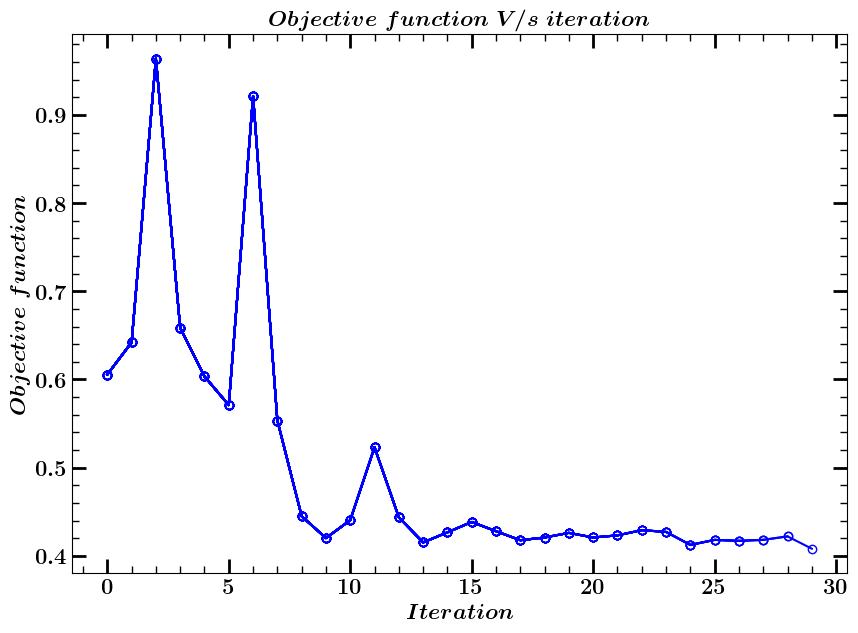

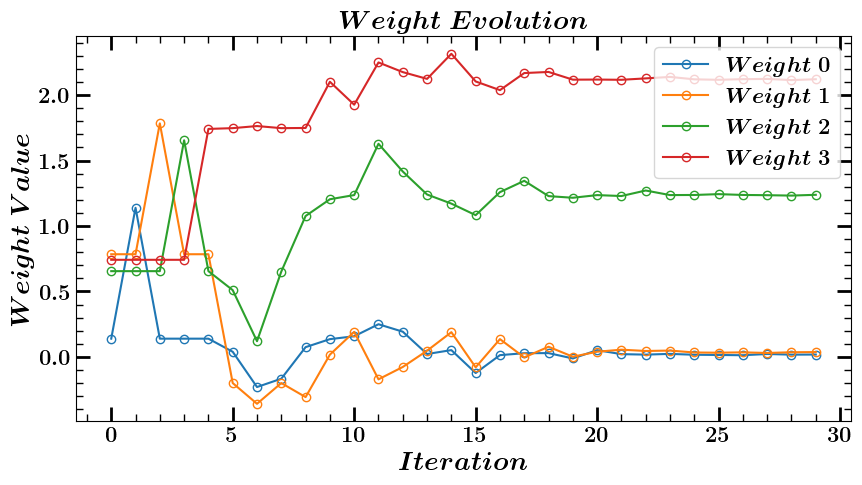

In [118]:
np.random.seed(42)
a = 16
# Generate dataset
num_samples = 40
# Two features
X = np.random.rand(num_samples, 2) * 2 - 1  # Random values in range [-1, 1]
# Labels: simple XOR-like pattern
Y = (X[:, 0] * X[:, 1] > 0).astype(int)  # 1 if both values have the same sign, else 0
# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# Convert labels to required shape
Y_train = Y_train.reshape(-1, 1)  # Ensure labels are column vectors
Y_test = Y_test.reshape(-1, 1)

Y_train = Y_train.flatten()  # Convert to (num_samples,)
Y_test = Y_test.flatten()  # Convert to (num_samples,)

Y_train = 2 * Y_train - 1  # Convert {0,1} → {-1,1}
Y_test = 2 * Y_test - 1  # Convert {0,1} → {-1,1}

y_one_hot = np.zeros((len(X_train), 2))
for i in range(len(X_train)):
    y_one_hot[i, Y_train[i]] = 1

# print(y_one_hot.shape)

y_one_hot_test = np.zeros((len(X_test), 2))
for i in range(len(X_test)):
    y_one_hot_test[i, Y_test[i]] = 1

num_inputs = 2

qc = QNNCircuit(ansatz=RealAmplitudes(num_inputs, reps=1))
# qc.draw("mpl")

def parity(x):
    return "{:b}".format(x).count("1") % 2
output_shape = 2

feature_map = ZZFeatureMap(num_inputs)
ansatz = RealAmplitudes(num_inputs, reps=1)

weights_history = []
objective_func_vals = []

def callback_graph(weights, obj_func_eval):
    """Callback function to track weight updates and objective function values."""
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    weights_history.append(weights.copy())  # Store a copy of the weights

    # Plot objective function values
    plt.title(r"$Objective$ $function$ $V/s$ $iteration$", fontsize = a)
    plt.xlabel(r"$Iteration$", fontsize = a)
    plt.ylabel(r"$Objective$ $function$", fontsize = a)
    plt.plot(range(len(objective_func_vals)), objective_func_vals, "bo-")

    # Print the weights at each iteration
    print(f"Iteration {len(objective_func_vals)}:")
    print("Weights:", weights)
    print("-" * 50)

from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()
# construct QNN

# construct variational quantum classifier
vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    loss="cross_entropy",
    optimizer=COBYLA(maxiter=30),
    callback=callback_graph,
    sampler=sampler,
)

# create empty array for callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (10, 7)

# fit classifier to data
vqc.fit(X_train, y_one_hot)
# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)
plt.savefig(graph_dir_intro_qnn + "/loss_2_feature_vqc.pdf")

# score classifier
train_score = vqc.score(X_train, y_one_hot)
test_score = vqc.score(X_test, y_one_hot_test)
print("The score of the VQC model on the training dataset is", train_score)
print("The score of the VQC model on the test dataset is", test_score)

weights_history = np.array(weights_history)

# Plot weight evolution over iterations
plt.figure(figsize=(10, 5))
for i in range(weights_history.shape[1]):
    plt.plot(weights_history[:, i], "o-", label=rf'$Weight$ ${i}$')
plt.xlabel(r"$Iteration$")
plt.ylabel(r"$Weight$ $Value$")
plt.title(r"$Weight$ $Evolution$")
plt.legend()
plt.savefig(graph_dir_intro_qnn + "/weights_2_feature_vqc.pdf")
plt.show()

## Qunatum Neural Networks on our Spinless BBH System Model

### Importing the logistics things

#### Importing the libraries and defining the paths of the datasets 

##### Importing the Libraries

In [119]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_machine_learning.optimizers import COBYLA, L_BFGS_B
from qiskit_machine_learning.utils import algorithm_globals

from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier, VQC
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.circuit.library import QNNCircuit
from sklearn.model_selection import train_test_split
from qiskit.primitives import BaseSamplerV2, Sampler
from qiskit.circuit import ParameterVector 


import qiskit_aer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import torch
import torch.nn as nn
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_ibm_runtime import EstimatorV2
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import QiskitRuntimeService

##### Defining the paths and importing the dataset

In [120]:
df = pd.read_csv(data_dir_spinless + "/Zero_Spin_M40-M95.csv")
df

,name,f0,f1,f2,A0,alpha,beta,gamma,delta,mse,...,s2x,s2y,s2z,D,r1,theta1,phi1,r2,theta2,phi2
0,SXS_BBH_0058_M40,27.526882,93.385217,232.043840,43.848440,2.532740,1.784379,0.555268,78.801744,0.792715,...,7.383298e-10,1.417772e-09,1.204419e-07,18.794739,1.188695e-07,0.448068,138.110990,1.204525e-07,0.760384,242.490965
1,SXS_BBH_0065_M40,33.093847,132.520315,378.781285,32.160187,2.822720,1.436146,1.113719,61.086684,0.057742,...,2.723431e-10,1.218781e-09,1.338867e-07,17.608011,1.330638e-07,0.453597,143.399819,1.338925e-07,0.534415,257.403880
2,SXS_BBH_0097_M40,26.988799,87.056138,435.674371,60.903824,3.004698,1.401119,0.948532,36.243907,0.281798,...,5.932426e-10,1.292124e-09,1.231750e-07,18.821371,1.219158e-07,0.463377,136.124555,1.231832e-07,0.661332,245.339096
3,SXS_BBH_0088_M40,20.070058,93.394746,435.790733,90.041960,2.123620,1.309405,0.916166,48.562295,0.730894,...,1.520225e-09,1.610835e-09,9.938600e-08,19.795964,9.667162e-08,0.452334,156.123356,9.941068e-08,1.276685,226.657620
4,SXS_BBH_0100_M40,22.213757,93.388057,406.293443,80.856438,2.190383,1.362660,0.917328,55.074455,0.289278,...,5.869573e-10,-1.520756e-10,1.604326e-07,17.683217,9.598546e-08,0.434416,43.424148,1.604337e-07,0.216542,165.474555
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10280,SXS_BBH_3870_M94,11.503310,37.583770,163.511695,153.712529,1.484005,1.365876,0.868779,23.068346,0.703541,...,1.162902e-10,-4.068522e-10,-1.047677e-07,40.190117,1.035156e-07,179.812761,284.074782,1.047686e-07,179.768590,105.951475
10281,SXS_BBH_3871_M94,11.773740,53.338318,152.456298,131.169810,1.288631,1.343705,0.772086,25.808069,0.633074,...,-3.788128e-11,-1.505973e-10,-1.967077e-07,40.186860,3.495297e-08,179.957913,69.786363,1.967077e-07,179.954769,75.880732
10282,SXS_BBH_3872_M94,11.663582,37.584570,175.373968,149.015123,1.642408,1.359375,0.808632,16.289700,0.779613,...,1.122048e-10,-2.543447e-11,-1.029648e-07,40.318456,1.029410e-07,179.861860,264.238289,1.029648e-07,179.935978,167.228090
10283,SXS_BBH_3891_M94,7.262907,126.579116,142.168097,257.109340,0.582256,1.241529,-3.722773,22.156509,0.775013,...,-4.225759e-10,-5.856067e-10,-1.949559e-07,40.315264,3.818093e-08,179.889736,91.055423,1.949573e-07,179.787767,54.185651


#### Preprocessing of the Dataset
We perform the feature selection and engineering by removing the values in the dataset having the zscore > 2. Meaning, taking the dataset lying within $95 \%$ confidence interval. 

In [121]:
# Columns to be used for the analysis
print("-"*100)
print("Columns present in the dataset are:")
print(df.columns)
print("-"*100)

numeric_cols = ['alpha', 'beta', 'gamma', 'delta', 'A0', 'f0', 'f1', 'f2', 'mse']

# Form the dataset with just numeric columns
df_numeric = df[numeric_cols]
means = df_numeric.mean()
variances =  df_numeric.var()
stds = df_numeric.std()
maxm = df_numeric.max()
minm = df_numeric.min()
z_scores = (df_numeric - means)/stds


# Print the statistics of the dataset
print("The maximum absolute value of Z scores for each column :")
print(z_scores.abs().max())
print("-"*100)

# Defining the throeshold for the z_scores and for the MSE
confidence = 2
mse_threshold = 1

# Get indices satisfying the conditions for each column
alpha_indices = set(z_scores.index[z_scores["alpha"].abs() > confidence])
beta_indices = set(z_scores.index[z_scores["beta"].abs() > confidence])
gamma_indices = set(z_scores.index[z_scores["gamma"].abs() > confidence])
delta_indices = set(z_scores.index[z_scores["delta"].abs() > confidence])
A0_indices = set(z_scores.index[z_scores["A0"].abs() > confidence])
f0_indices = set(z_scores.index[z_scores["f0"].abs() > confidence])
f1_indices = set(z_scores.index[z_scores["f1"].abs() > confidence])
f2_indices = set(z_scores.index[z_scores["f2"].abs() > confidence])
mse_indices = set(z_scores.index[z_scores["mse"].abs() > mse_threshold])

# Get the final set of unique indices
wrong_indices = alpha_indices | beta_indices | gamma_indices | delta_indices | A0_indices | f0_indices | f1_indices | f2_indices | mse_indices

# negative_beta_gamma_indices = set(df.index[(df["beta"] < 0) | (df["gamma"] < 0)])
# wrong_indices = wrong_indices | negative_beta_gamma_indices
# Convert to a sorted list if needed
wrong_indices = sorted(wrong_indices)

print("The indices which we should remove are:\n", wrong_indices)
print("The number of indices to be removed :", len(wrong_indices))
print("The confidence interval which we take to reduce the dataset is :", confidence)
print("-"*100)  # Partition 

df_removed = df.drop(wrong_indices)
df_removed

----------------------------------------------------------------------------------------------------
Columns present in the dataset are:
Index(['name', 'f0', 'f1', 'f2', 'A0', 'alpha', 'beta', 'gamma', 'delta',
       'mse', 'window', 'M', 'q', 'm1', 'm2', 's1x', 's1y', 's1z', 's2x',
       's2y', 's2z', 'D', 'r1', 'theta1', 'phi1', 'r2', 'theta2', 'phi2'],
      dtype='object')
----------------------------------------------------------------------------------------------------
The maximum absolute value of Z scores for each column :
alpha    66.032429
beta     79.734285
gamma    46.690815
delta     7.366467
A0        8.559681
f0       18.301677
f1        5.098120
f2        4.853361
mse       5.761602
dtype: float64
----------------------------------------------------------------------------------------------------
The indices which we should remove are:
 [0, 1, 2, 3, 4, 5, 8, 9, 10, 13, 14, 15, 17, 18, 19, 23, 24, 25, 28, 29, 30, 31, 32, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46,

,name,f0,f1,f2,A0,alpha,beta,gamma,delta,mse,...,s2x,s2y,s2z,D,r1,theta1,phi1,r2,theta2,phi2
6,SXS_BBH_0186_M40,35.530249,100.156223,329.304853,27.365328,3.308118,1.628621,1.235238,48.308586,0.033494,...,-6.213752e-08,-1.174558e-07,-1.433890e-05,12.582060,1.281141e-05,0.167660,313.040477,1.433951e-05,179.469052,62.119858
7,SXS_BBH_0188_M40,35.244651,100.144173,329.265235,29.860356,3.564193,1.640014,1.159623,50.359273,0.053076,...,1.120449e-08,2.159264e-08,-8.823772e-08,13.011403,1.369647e-06,42.031945,241.128825,9.152966e-08,164.586803,242.575061
11,SXS_BBH_0192_M40,35.292959,100.144937,329.267748,30.733582,3.635610,1.620813,1.131925,52.381352,0.053374,...,-5.777149e-08,4.182985e-09,-8.569149e-05,15.830757,3.192519e-05,0.091312,146.638478,8.569151e-05,179.961271,355.858686
12,SXS_BBH_0195_M40,36.748788,100.145281,329.268878,27.658236,4.059446,1.681801,1.170335,48.488972,0.058840,...,-2.819912e-08,1.159838e-07,-4.007894e-05,12.570122,1.319209e-05,0.130737,21.696553,4.007912e-05,179.829363,283.665176
16,SXS_BBH_0200_M40,30.131494,93.363966,378.722141,47.794848,3.290195,1.505500,1.005419,44.108590,0.120160,...,4.394404e-08,8.736389e-08,-1.094558e-05,14.670647,5.029715e-05,179.919019,303.578424,1.094602e-05,179.488104,243.297604
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10274,SXS_BBH_3885_M94,0.000000,5.818339,163.227899,13.361198,1.000000,1.000000,1.000000,1.000000,3.926684,...,-1.486523e-10,-3.076042e-10,-7.898202e-08,39.811204,8.287044e-08,179.718432,279.027008,7.898276e-08,179.752166,64.207454
10275,SXS_BBH_3886_M94,0.000000,5.915182,163.261572,12.818637,1.000000,1.000000,1.000000,1.000000,3.549898,...,5.003222e-10,2.930812e-10,-1.536810e-07,39.807757,5.200287e-08,173.218695,273.823942,1.536821e-07,179.783822,210.361123
10280,SXS_BBH_3870_M94,11.503310,37.583770,163.511695,153.712529,1.484005,1.365876,0.868779,23.068346,0.703541,...,1.162902e-10,-4.068522e-10,-1.047677e-07,40.190117,1.035156e-07,179.812761,284.074782,1.047686e-07,179.768590,105.951475
10281,SXS_BBH_3871_M94,11.773740,53.338318,152.456298,131.169810,1.288631,1.343705,0.772086,25.808069,0.633074,...,-3.788128e-11,-1.505973e-10,-1.967077e-07,40.186860,3.495297e-08,179.957913,69.786363,1.967077e-07,179.954769,75.880732


### Restricted Spinless BBH Systems 
This model utilizes the dataset of spinless BBH systems but with some specific constraints. It takes 2 input features $m_1$, $m_2$ and outputs $f_0$. These parameters were taken because there variation could be visualized easily from the above graph. 

#### Defining the dataset and the input and output features of the dataset

In [130]:
graph_dir_res_qnn = os.path.join(graph_dir, "res_qnn")
data_dir_res_qnn = os.path.join(data_dir, "res_qnn")

# Check and create directories only if they don't exist
if not os.path.exists(graph_dir_res_qnn):
    os.makedirs(graph_dir_res_qnn)
if not os.path.exists(data_dir_res_qnn):
    os.makedirs(data_dir_res_qnn)

##### Defining the input and output features among the dataset

In [131]:
df_qml = df_removed.copy()

input_cols = ['m1', 'm2']
output_cols = ['f0']

X = df_qml[input_cols].values
y = df_qml[output_cols].values

##### Normalizing the dataset between the values $(0, \pi/4)$, and then scaling all the values for the above normalization. 

In [132]:
# -------------------Define the normalization range ------------------
# a, b = -np.pi, np.pi
a, b = 0, np.pi/4

# Compute min and max of each feature across axis 0 (column-wise)
X_min = X.min(axis=0)
X_max = X.max(axis=0)

# Apply min-max scaling to [-pi/2, pi/2]
X_scaled = a + ((X - X_min) * (b - a)) / (X_max - X_min)

# Similarly for y (if it's 1D or 2D)
y_min = y.min(axis=0)
y_max = y.max(axis=0)
y_scaled = a + ((y - y_min) * (b - a)) / (y_max - y_min)

##### Splitting the dataset into train and test dataset and also assigning the fraction of the whole data to be used in the model 

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, train_size = 0.8, shuffle = True, random_state = 42)
# X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, shuffle = True, random_state = 42)

print("The shape of the X_train dataset is :", X_train.shape)
print("The shape of the X_test dataset is :", X_test.shape)
print("The shape of the y_train dataset is :", y_train.shape)
print("The shape of the y_test dataset is :", y_test.shape)
print("-"*100)

def crop_data(X, y, fraction):
    if not (0.0 <= fraction <= 1.0):
        raise ValueError("Fraction must be between 0.0 and 1.0")
    
    num_samples = int(len(X) * fraction)
    return X[:num_samples], y[:num_samples]

# Example usage
fraction = 1  # Change this value to control the fraction of data
X_train_crop, y_train_crop = crop_data(X_train, y_train, fraction)
X_test_crop, y_test_crop = crop_data(X_test, y_test, fraction)

print("X_train_crop shape:", X_train_crop.shape)
print("y_train_crop shape:", y_train_crop.shape)
print("X_test_crop shape:", X_test_crop.shape)
print("y_test_crop shape:", y_test_crop.shape)

The shape of the X_train dataset is : (6055, 2)
The shape of the X_test dataset is : (1514, 2)
The shape of the y_train dataset is : (6055, 1)
The shape of the y_test dataset is : (1514, 1)
----------------------------------------------------------------------------------------------------
X_train_crop shape: (6055, 2)
y_train_crop shape: (6055, 1)
X_test_crop shape: (1514, 2)
y_test_crop shape: (1514, 1)


#### Defining the Restricted Spinless BBH Systems Model

##### Quantum Circuit of the Model 

In [134]:
# -------------------Defining the circuit------------------
# Set seed for reproducibility
algorithm_globals.random_seed = 42
num_inputs = 2

# ----------- Quantum Circuit with 8 Inputs ------------
feature_map = ZZFeatureMap(feature_dimension=num_inputs, entanglement='linear', reps=3)
ansatz = RealAmplitudes(num_inputs, entanglement='linear', reps=8)

qc = QuantumCircuit(num_inputs)
qc.compose(feature_map, inplace=True)
qc.barrier()
qc.compose(ansatz, inplace=True)
# qc.draw("mpl")

##### Defining the Observable whose expectation value will be evaluated using Estimator

In [135]:
# ----------- Observable: 1 Output ------------
# Measure Pauli-Z expectation values on qubit 0 and 1
observables = [SparsePauliOp.from_list([("Z" + "I"*(num_inputs-1), 1.0)])]

##### Defining the EstimatorQNN with the given circuit and observables 

In [136]:
feature_params = list(feature_map.parameters)    # Input features
weight_params = list(ansatz.parameters)        # Trainable weights
# ----------- Estimator QNN ------------
estimator = Estimator()

qnn = EstimatorQNN(
    circuit=qc,
    input_params=feature_params,
    weight_params=weight_params,
    observables=observables,
    estimator=estimator
)
print(qnn.output_shape)

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


(1,)


##### Defining the Callback function

In [137]:
weights_history = []
objective_func_vals = []
def callback_graph(weights, obj_func_eval):
    """Callback function to track weight updates and objective function values."""
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    weights_history.append(weights.copy())  # Store a copy of the weights

    # Plot objective function values
    plt.title(r"$Objective$ $function$ $value$ $against$ $iteration$")
    plt.xlabel(r"$Iteration$")
    plt.ylabel(r"$Objective$ $function$ $value$")
    plt.plot(range(len(objective_func_vals)), objective_func_vals, "bo-")
    plt.savefig(graph_dir_res_qnn + "/loss_spinless.pdf") 
    plt.show()

    # Print the weights at each iteration
    print(f"Iteration {len(objective_func_vals)}:")
    print("Weights:", weights)
    print("-" * 50)

##### Defining the Neural Network Regressor 

In [138]:
regressor = NeuralNetworkRegressor(
    neural_network= qnn,
    loss="squared_error",
    optimizer=COBYLA(maxiter=60),
    callback=callback_graph,
)
# create empty array for callback to store evaluations of the objective function


##### Plotting the result (Objective Value function) and printing the score value of the model

THESIS: Figure 4.10

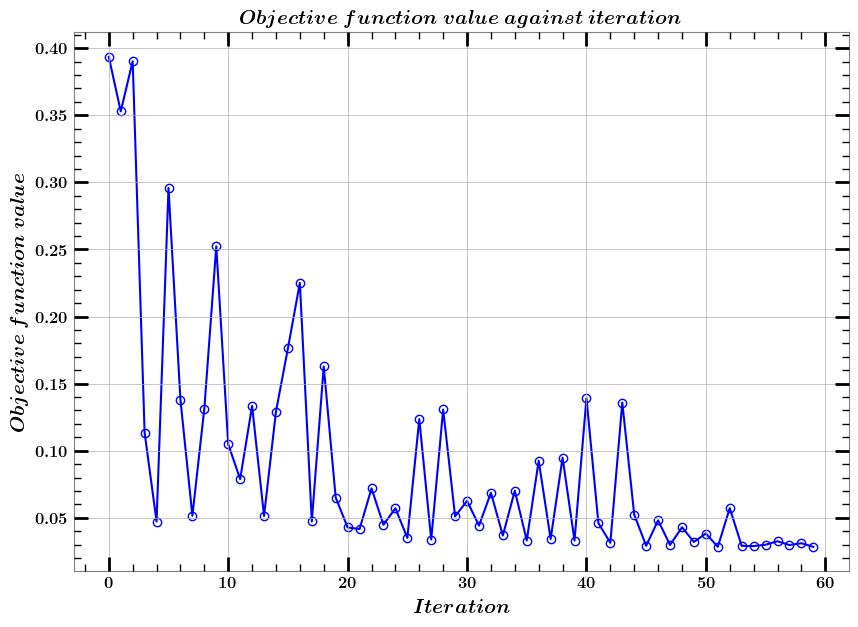

Iteration 60:
Weights: [ 2.07188023  0.51591676  2.2001951   1.48908092 -0.16030665
  1.11175535  0.29505579  0.85094728  0.09464091  0.3678942
  0.34390464  0.78165214  0.76345871  0.63316168  0.38774592
 -0.15400685  0.30445086 -0.04855332]
--------------------------------------------------
Train score: -0.6234
Test score: -0.6042


In [275]:
objective_func_vals = []
plt.rcParams["figure.figsize"] = (10, 7)
# fit to data
regressor.fit(X_train_crop, y_train_crop)
# return to default figsize
plt.rcParams["figure.figsize"] = (10, 7)

# score the result
train_score = regressor.score(X_train_crop, y_train_crop)
test_score = regressor.score(X_test_crop, y_test_crop) 

print(f"Train score: {train_score:.4f}")
print(f"Test score: {test_score:.4f}")

##### Plotting the output prediction accuracy of the model

In [276]:
# Final MSE for training data
train_preds = regressor.predict(X_train_crop)
test_preds = regressor.predict(X_test_crop)
mse_train = mean_squared_error(y_train_crop, train_preds)
mse_test = mean_squared_error(y_test_crop, test_preds)
print(f"Final Train MSE: {mse_train:.6f}")
print(f"Final Test MSE: {mse_test:.6f}")

Final Train MSE: 0.028162
Final Test MSE: 0.029467


##### Plot of evolutions of weights with iterations

THESIS: Figure 4.11

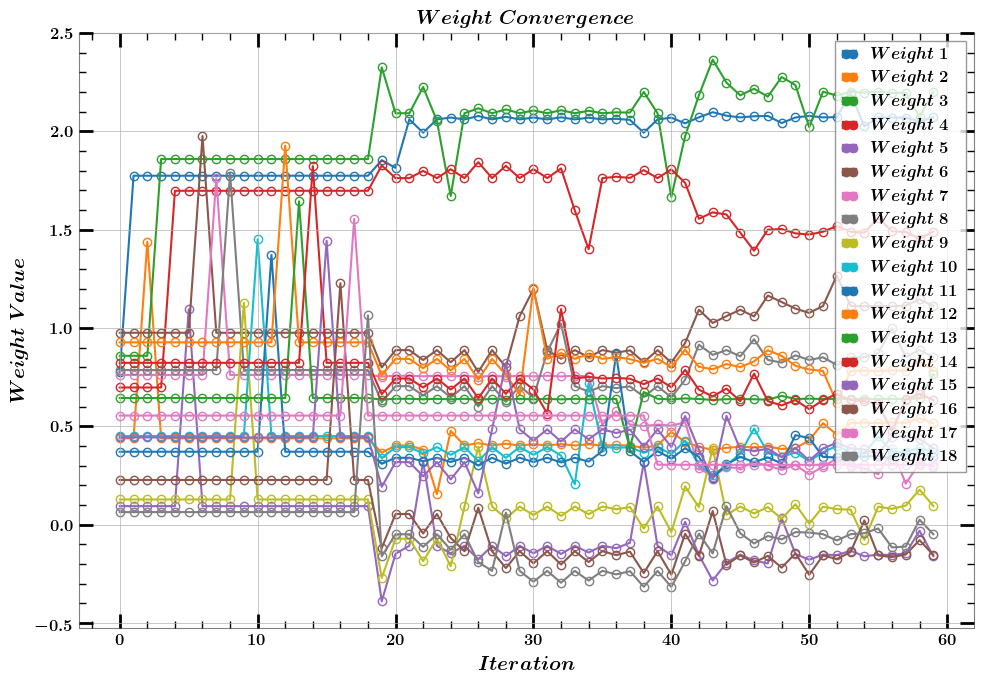

In [ ]:
# Ensure weights_history is a NumPy array
weights_history = np.array(weights_history)

plt.figure(figsize=(10, 7))
for i in range(weights_history.shape[1]):
    plt.plot(weights_history[:, i], "o-", label=f'$Weight$ ${i + 1}$')
    
plt.xlabel(r'$Iteration$')
plt.ylabel(r'$Weight$ $Value$')
plt.title(r'$Weight$ $Convergence$')
plt.legend()
plt.tight_layout()
# plt.savefig(graph_dir_res_qnn + "/weights_res_qnn.pdf")  # Ensure '/' is used
plt.show()

### Complete Spinless BBH Systems

#### Defining the dataset and logistics 

##### Important functions to be defined for this model

In [150]:
from copy import deepcopy
from sklearn.base import BaseEstimator, RegressorMixin

class MultiOutputQNNRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, base_qnn, optimizer=None, loss="squared_error", callback=None, n_outputs=2):
        self.base_qnn = base_qnn
        self.optimizer = optimizer
        self.loss = loss
        self.callback = callback
        self.n_outputs = n_outputs
        self.regressors = []

        # Initialize individual regressors with deep copies of the base QNN
        for _ in range(self.n_outputs):
            qnn_copy = deepcopy(self.base_qnn)
            reg = NeuralNetworkRegressor(
                neural_network=qnn_copy,
                loss=self.loss,
                optimizer=self.optimizer,
                callback=self.callback
            )
            self.regressors.append(reg)

    def fit(self, X, y):
        y = np.asarray(y)
        if y.ndim == 1:
            y = y.reshape(-1, 1)

        for i in range(self.n_outputs):
            self.regressors[i].fit(X, y[:, i])
        return self

    def predict(self, X):
        predictions = [reg.predict(X).flatten() for reg in self.regressors]  # Ensure 1D output
        return np.stack(predictions, axis=1)  # shape: (n_samples, n_outputs)

    def score(self, X, y):
        y_pred = self.predict(X)
        return -mean_squared_error(y, y_pred)  # Return negative MSE (higher is better)

##### Defining the Dataset to be used defining the input and output features of the dataset

In [151]:
graph_dir_com_qnn = os.path.join(graph_dir, "com_qnn")
data_dir_com_qnn = os.path.join(data_dir, "com_qnn")

# Check and create directories only if they don't exist
if not os.path.exists(graph_dir_com_qnn):
    os.makedirs(graph_dir_com_qnn)
if not os.path.exists(data_dir_com_qnn):
    os.makedirs(data_dir_com_qnn)

In [152]:
# ------------------- Preprocessing -------------------
df_qml = df_removed.copy()

output_cols = ['m1', 'm2']
input_cols = ['beta', 'gamma', 'delta', 'A0', 'f0', 'f1', 'f2']

X = df_qml[input_cols].values
y = df_qml[output_cols].values

#### Defining the normalization and the fraction of data

In [153]:
# Normalize X and y to [0, π/4]
a, b = 0, np.pi/4
X_min, X_max = X.min(axis=0), X.max(axis=0)
y_min, y_max = y.min(axis=0), y.max(axis=0)

X_scaled = a + ((X - X_min) * (b - a)) / (X_max - X_min)
y_scaled = a + ((y - y_min) * (b - a)) / (y_max - y_min)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, train_size=0.8, random_state=42, shuffle=True)

# Optional: Crop dataset
def crop_data(X, y, fraction):
    num_samples = int(len(X) * fraction)
    return X[:num_samples], y[:num_samples]

X_train_crop, y_train_crop = crop_data(X_train, y_train, 1)
X_test_crop, y_test_crop = crop_data(X_test, y_test, 1)

#### QNN Model

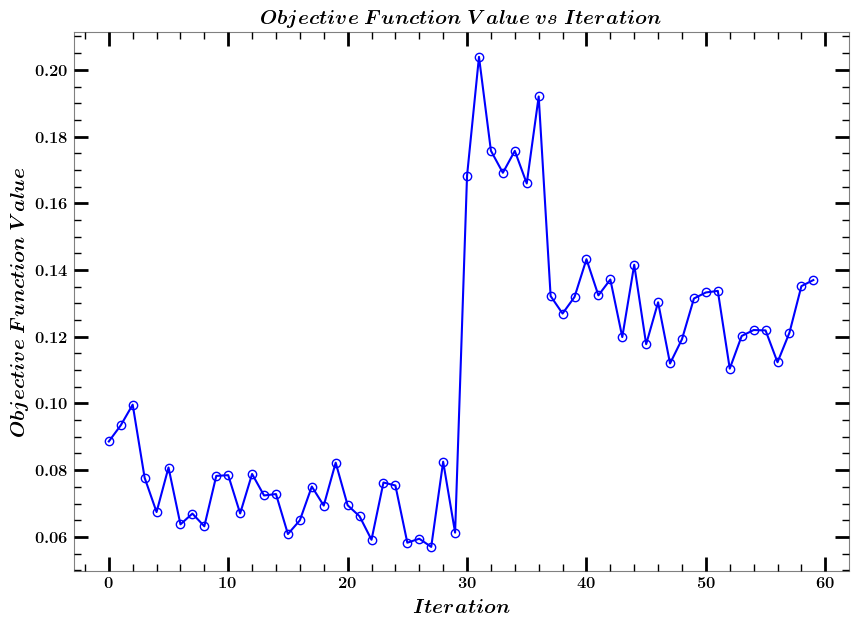

Iteration 60:
Weights: [0.76499886 0.63471832 0.5535794  0.55920716 1.3039501
 0.03081783 1.43671739 1.21458467 0.40852864 0.85340307
 0.23393949 0.05830274 1.28138389 0.29359376 1.66191651
 0.55703215 1.78389821 0.66431354 0.40638686 0.81402038
 0.16697292 1.02271207 0.09004786 0.72235935 0.46187723
 0.16127178 0.50104478 0.1523121  1.69632038 0.44615628
 0.38102123 0.30151209 0.63028259 0.36181261 0.08764992
 0.1180059  0.96189766 0.90858069 0.69970713 0.26586996
 0.96917638 0.7787509  0.71689019 0.4493615  0.27224156
 0.09639096 0.9026024  0.45577629 0.20236336 0.30595662
 0.57921957 0.17677278 0.85661428 0.75851953 0.71946296
 0.43209304 0.62730884 0.58409797 0.6498466  0.08444432
 0.4158074  0.04161417 0.49399082]
--------------------------------------------------
Expected shape: (1514, 2)
Predicted shape: (1514, 2)


In [158]:
# ------------------- Quantum Neural Network -------------------
algorithm_globals.random_seed = 42
num_inputs = X.shape[1]


# Define quantum circuit
qc = QuantumCircuit(num_inputs)
feature_map = ZZFeatureMap(feature_dimension=num_inputs, reps=2, entanglement='linear')
ansatz = RealAmplitudes(num_inputs, reps=8, entanglement='linear')  # adjust reps if needed

qc.compose(feature_map, inplace=True)
qc.barrier()
qc.compose(ansatz, inplace=True)
qc.draw("mpl")

# Use a single observable for scalar output QNN
observable = SparsePauliOp.from_list([("Z" + "I" * (num_inputs - 1), 1.0)])  # only one observable!

# Estimator QNN
qnn = EstimatorQNN(
    circuit=qc,
    input_params=list(feature_map.parameters),
    weight_params=list(ansatz.parameters),
    observables=observable,
    estimator=Estimator(),
    input_gradients=True
)

# --------------------------------------
# Callback for plotting training process
# --------------------------------------

weights_history = []
objective_func_vals = []

from IPython.display import clear_output

def callback_graph(weights, obj_func_eval):
    """Callback function to track weight updates and objective function values."""
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    weights_history.append(weights.copy())  # Store a copy of the weights

    # Plot objective function values
    plt.figure(figsize=(10, 7))
    plt.title(r"$Objective$ $Function$ $Value$ $vs$ $Iteration$")
    plt.xlabel(r"$Iteration$")
    plt.ylabel(r"$Objective$ $Function$ $Value$")
    plt.plot(range(len(objective_func_vals)), objective_func_vals, "bo-")
    plt.grid(False)
    plt.savefig(graph_dir_com_qnn + "/com_qnn_loss.pdf")
    plt.show()

    # Print weights (can be removed for large models)
    print(f"Iteration {len(objective_func_vals)}:")
    print("Weights:", weights)
    print("-" * 50)


# ------------------- MultiOutput Wrapper -------------------
multi_output_qnn = MultiOutputQNNRegressor(
    base_qnn = qnn,
    optimizer = COBYLA(maxiter=30),
    n_outputs = 2,  # for 'm1' and 'm2'
    callback=callback_graph
)

# Fit the model
multi_output_qnn.fit(X_train_crop, y_train_crop)

# Predict
y_pred = multi_output_qnn.predict(X_test_crop)

print("Expected shape:", y_test_crop.shape)
print("Predicted shape:", y_pred.shape)

In [159]:
# Final MSE for training data
train_preds = multi_output_qnn.predict(X_train_crop)
test_preds = multi_output_qnn.predict(X_test_crop)
mse_train = mean_squared_error(y_train_crop, train_preds)
mse_test = mean_squared_error(y_test_crop, test_preds)
print(f"Final Train MSE: {mse_train:.6f}")
print(f"Final Test MSE: {mse_test:.6f}")

Final Train MSE: 0.083874
Final Test MSE: 0.080279


#### Second QNN Model using TorchConnector

##### Defining the dataset to be used and other things to be included in the dataset

In [161]:
df_qml = df_removed.copy()

output_cols = ['m1', 'm2']
input_cols = ['beta', 'gamma', 'delta', 'A0', 'f0', 'f1', 'f2']

X = df_qml[input_cols].values
y = df_qml[output_cols].values



# a, b = -np.pi, np.pi
a, b = 0, np.pi/4

# Compute min and max of each feature across axis 0 (column-wise)
X_min = X.min(axis=0)
X_max = X.max(axis=0)

# Apply min-max scaling to [-pi/2, pi/2]
X_scaled = a + ((X - X_min) * (b - a)) / (X_max - X_min)

# Similarly for y (if it's 1D or 2D)
y_min = y.min(axis=0)
y_max = y.max(axis=0)
y_scaled = a + ((y - y_min) * (b - a)) / (y_max - y_min)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, train_size = 0.8, shuffle = True, random_state = 42)
# X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, shuffle = True, random_state = 42)

print("The shape of the X_train dataset is :", X_train.shape)
print("The shape of the X_test dataset is :", X_test.shape)
print("The shape of the y_train dataset is :", y_train.shape)
print("The shape of the y_test dataset is :", y_test.shape)
print("-"*100)

def crop_data(X, y, fraction):
    if not (0.0 <= fraction <= 1.0):
        raise ValueError("Fraction must be between 0.0 and 1.0")
    
    num_samples = int(len(X) * fraction)
    return X[:num_samples], y[:num_samples]

# Example usage
fraction = 0.2  # Change this value to control the fraction of data
X_train_crop, y_train_crop = crop_data(X_train, y_train, fraction)
X_test_crop, y_test_crop = crop_data(X_test, y_test, fraction)

print("X_train_crop shape:", X_train_crop.shape)
print("y_train_crop shape:", y_train_crop.shape)
print("X_test_crop shape:", X_test_crop.shape)
print("y_test_crop shape:", y_test_crop.shape)



# Set seed for reproducibility
algorithm_globals.random_seed = 42
# ----------- Quantum Circuit with 8 Inputs ------------
num_inputs = 7
# feature_map = ZZFeatureMap(feature_dimension=num_inputs, entanglement='linear', reps=2)
# ansatz = RealAmplitudes(num_inputs, entanglement='linear', reps=8)

feature_map = ZZFeatureMap(feature_dimension=num_inputs, entanglement='linear', reps=3)
ansatz = RealAmplitudes(num_inputs, entanglement='linear', reps=8)
qc = QuantumCircuit(num_inputs)
qc.compose(feature_map, inplace=True)
qc.barrier()
qc.compose(ansatz, inplace=True)
qc.draw("mpl")


feature_params = list(feature_map.parameters)    # Input features
weight_params = list(ansatz.parameters)        # Trainable weights

# You can also add more blocks as needed

# ----------- Observable: 2 Outputs ------------
# Measure Pauli-Z expectation values on qubit 0 and 1
observables = [SparsePauliOp.from_list([("Z" + "I"*(num_inputs-1), 1.0)]),
               SparsePauliOp.from_list([("I" + "Z" + "I"*(num_inputs-2), 1.0)])]

# observables = SparsePauliOp([
#     ("Z" + "I"*(num_inputs-1), 1.0),
#     ("I" + "Z" + "I"*(num_inputs-2), 1.0)
# ])

# ----------- Estimator QNN ------------
estimator = Estimator()

qnn = EstimatorQNN(
    circuit=qc,
    input_params=feature_params,
    weight_params=weight_params,
    observables=observables,
    estimator=estimator
)
print(qnn.output_shape)

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


The shape of the X_train dataset is : (6055, 7)
The shape of the X_test dataset is : (1514, 7)
The shape of the y_train dataset is : (6055, 2)
The shape of the y_test dataset is : (1514, 2)
----------------------------------------------------------------------------------------------------
X_train_crop shape: (1211, 7)
y_train_crop shape: (1211, 2)
X_test_crop shape: (302, 7)
y_test_crop shape: (302, 2)
(2,)


##### Defining about the model 

In [162]:
out_1 = qnn.forward(X_train[0, :], algorithm_globals.random.random(qnn.num_weights))
print("The shape of the output is :", out_1.shape)

import torch
import torch.nn as nn
from qiskit_machine_learning.connectors import TorchConnector

# Create a QNN layer
qnn_layer = TorchConnector(qnn)

# Wrap it in a PyTorch Module
class QNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.qnn = qnn_layer

    def forward(self, x):
        return self.qnn(x)

# Convert your numpy data to torch tensors
X_train_torch = torch.tensor(X_train_crop, dtype=torch.float32)
y_train_torch = torch.tensor(y_train_crop, dtype=torch.float32)
X_test_torch = torch.tensor(X_test_crop, dtype=torch.float32)
y_test_torch = torch.tensor(y_test_crop, dtype=torch.float32)

The shape of the output is : (1, 2)


##### Running the Model on the TorchConnector 

In [ ]:
# import torch
# from torch.utils.data import TensorDataset, DataLoader

# # Set device
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = QNNModel().to(device)

# # Dataset and DataLoader
# batch_size = 32  # You can experiment with 32, 64, 128
# dataset = TensorDataset(X_train_torch, y_train_torch)
# loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# # Loss and optimizer
# loss_fn = nn.MSELoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# # Training loop
# num_epochs = 14
# train_losses = []

# for epoch in range(num_epochs):
#     model.train()
#     epoch_loss = 0.0

#     for X_batch, y_batch in loader:
#         X_batch = X_batch.to(device)
#         y_batch = y_batch.to(device)

#         optimizer.zero_grad()
#         output = model(X_batch)
#         loss = loss_fn(output, y_batch)
#         loss.backward()
#         optimizer.step()

#         epoch_loss += loss.item() * X_batch.size(0)  # total loss for the batch

#     avg_loss = epoch_loss / len(loader.dataset)
#     train_losses.append(avg_loss)
#     print(f"Epoch {epoch}, Loss: {avg_loss:.4f}")

In [ ]:
# np.save(data_dir_com_qnn + "/train_losses.npy", np.array(train_losses))

In [ ]:
train_losses = np.load(data_dir_com_qnn + "/train_losses.npy")
# Plot the training loss curve
plt.figure(figsize=(10, 7))
plt.plot(train_losses, 'bo-', label='Training Loss')
plt.xlabel(r"$Epochs$")
plt.ylabel(r"$MSE$ $Loss$")
plt.title(r"$Training$ $Loss$ $over$ $Epochs$")
plt.grid(False)
plt.legend()
# plt.tight_layout()
# plt.savefig(graph_dir + "loss_curve.pdf")
plt.show()

# LSTM for GW signals 

## Analysis of the noise and GW signals

### Importing the logistics and defining the path for the dataset

#### Importing the libraries

In [4]:
import gwpy
from gwpy.signal.filter_design import bandpass
from gwpy.timeseries import TimeSeries
from gwpy.signal import filter_design
from gwpy.plot import Plot

/home/darsh/.local/lib/python3.10/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


#### Assigning the paths of the dataset

In [33]:
# Choose your main folder name
folder_name = "lstm"

# Get the current working directory
current_path = os.getcwd()
print("Current Path:", current_path)


# Define paths
folder_dir = os.path.join(current_path, folder_name)
data_dir = os.path.join(folder_dir, "dataset")
graph_dir = os.path.join(folder_dir, "graph")

# Check and create directories only if they don't exist
if not os.path.exists(folder_dir):
    os.makedirs(data_dir)
    os.makedirs(graph_dir)
    print("Directories created.")
else:
    print("Directories already exist. Nothing done.")

# Optional: print the paths for later use
print("Folder Path:", folder_dir)
print("Data Path:", data_dir)
print("Graph Path:", graph_dir)

Current Path: /mnt/d/Darsh/MSThesis/Final Code MS
Directories already exist. Nothing done.
Folder Path: /mnt/d/Darsh/MSThesis/Final Code MS/lstm
Data Path: /mnt/d/Darsh/MSThesis/Final Code MS/lstm/dataset
Graph Path: /mnt/d/Darsh/MSThesis/Final Code MS/lstm/graph


#### Essential functions required in this section

In [6]:
import gwosc
import gwpy
from gwpy.timeseries import TimeSeries
from gwosc.datasets import event_gps

# -----------------------Function to download the dataset from GWOSC website -----------------
def gw_raw(event, detector, time_frame):
    """"
    Function to download the dataset from the gwosc datasets using gwpy python package
    Parameters: 
    event (str) : The name of the event registered in the datasets (example: GW150914)
    detector (str) : The name of detector from wholm to download the data. 
    time_frame (int) : Amount of time frame of data required before and after the event.

    Returns(timeseries):
    raw_data : Timeseries data downloaded from the datasets of gwosc
    """
    gps = gwosc.datasets.event_gps(event)
    start = int(gps) - float(time_frame)
    end = int(gps) + float(time_frame)
    raw_data = TimeSeries.fetch_open_data(detector, start, end)
    return raw_data

import pycbc
from pycbc.catalog import Merger 

# ------------------------- Function to get the details about a event in the dataset --------------
class EventDetails:
    """Class to extract details of a gravitational wave event using the pycbc package."""
    

    def __init__(self, name):
        self.merger = Merger(name)  # Extracting merger data
        self.name = name
        self._fetch_details()  # Fetch all details when the class is initialized
    
    def _fetch_details(self):
        """Private method to fetch all details and store them."""
        self.t_gw1 = self.merger.time
        self.m1 = self.merger.median1d("mass1")
        self.m2 = self.merger.median1d("mass2")
        self.spin_eff = self.merger.median1d("chi_eff")
        self.distance = self.merger.median1d("distance")
    
    def get_all_details(self):
        """Returns all event details as a dictionary."""
        return {
            "event_name": self.name,
            "merger_time": self.t_gw1,
            "mass1": self.m1,
            "mass2": self.m2,
            "spin_eff": self.spin_eff,
            "distance": self.distance
        }
    
    def get_merger_time(self):
        """Returns the time of the merger."""
        return self.t_gw1
    
    def get_mass1(self):
        """Returns the mass of the primary black hole."""
        return self.m1
    
    def get_mass2(self):
        """Returns the mass of the secondary black hole."""
        return self.m2
    
    def get_spin_eff(self):
        """Returns the effective spin parameter."""
        return self.spin_eff
    
    def get_distance(self):
        """Returns the distance between the black holes initially."""
        return self.distance
    
# ------------Function 
def compute_fft(data, fs):
    """
    Function to compute the FFT of the given data
    """
    # Compute the FFT of the given data
    fft_data = np.fft.rfft(data)
    freq = np.fft.rfftfreq(len(data), 1/fs)
    return fft_data, freq

def plot_fft(data, fs): 
    """
    Function to plot the FFT of the given data
    """
    # Compute the FFT of the given data
    fft_data, freqs = compute_fft(data, fs)
    # Plot the FFT of the data
    plt.figure(figsize = (10, 7))
    plt.plot(freqs, np.abs(fft_data))
    plt.xticks()
    plt.yticks()
    plt.xlabel(r"$Frequency$ $(Hz)$")
    plt.ylabel(r"$Amplitude$")
    plt.title(r"$Frequency$ $Spectrum$ $Signal$")
    # plt.xscale("log")
    # plt.yscale("log")
    plt.xlim(0, 100)
    plt.grid(False)
    plt.show()

import pywt
def cwt(time, strain, wavelet="cmor1.5-1.0", num_scales=100, scale_max=1024):
    """
    Function to compute and plot the Continuous Wavelet Transform (CWT) of a gravitational wave signal.

    Parameters:
    - time_path (str): Path to the time data (.npy file).
    - strain_path (str): Path to the strain data (.npy file).
    - save_path (str): Path to save the resulting plot image.
    - wavelet (str): Wavelet type for CWT (default is 'cmor1.5-1.0').
    - num_scales (int): Number of scales for CWT (default is 100).
    - scale_max (int): Maximum scale value (default is 1024).
    """
    # Load time and strain data
    time = time
    chirp = strain
    
    # Setup for CWT
    widths = np.geomspace(1, scale_max, num=num_scales)
    sampling_period = np.diff(time).mean()
    
    # Perform CWT
    cwtmatr, freqs = pywt.cwt(chirp, widths, wavelet, sampling_period=sampling_period)
    cwtmatr = np.abs(cwtmatr[:-1, :-1])  # Take absolute value of complex result

    return time, freqs, cwtmatr

def plot_cwt(time, strain):
    """Function to plot the Continuous Wavelet Transform (CWT) of a gravitational wave signal."""
    time, freqs, cwtmatr = cwt(time, strain)
    
    plt.figure(figsize = (10, 7))
    plt.pcolormesh(time, freqs, cwtmatr, shading = "auto")
    plt.colorbar(label = r"$Magnitude$")
    plt.xlabel(r'$Time (s)$')
    plt.ylabel(r'$Frequency (Hz)$')
    # plt.yscale("log")
    plt.xlim(time[0], time[-1])
    # plt.ylim(0, 600)
    plt.xticks()
    plt.yticks()
    plt.show()

def bandpass_filter(data, fs, low_freq=2, high_freq=1024, notches=[60, 120, 180],
                     whiten = True, 
                     normalize = True):
    """
    Function to apply bandpass filtering to the gravitational wave data.
    
    Parameters:
    data (TimeSeries): The input time series data to be filtered.
    fs (int): The sampling frequency.
    low_freq (int): The lower frequency for the bandpass filter.
    high_freq (int): The upper frequency for the bandpass filter.
    notches (list): List of notch filter frequencies.
    
    Returns:
    TimeSeries: The filtered time series data.
    """
    bp = bandpass(low_freq, high_freq, fs)
    notch_filters = [filter_design.notch(line, fs) for line in notches]
    zpk = filter_design.concatenate_zpks(bp, *notch_filters)
    data_filt = data.filter(zpk, filtfilt=True)
    if normalize:
        data_filt = data_filt/np.max(data_filt)
    if whiten:
        data_filt = data_filt.whiten()

    return data_filt


PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


### Working on Noisy Dataset of LIGO 

##### Importing the noisy dataset

In [164]:
start_gps = 1238175744
fs = 4096
total_dur = 190
t_epoch = 32
num = int(total_dur/t_epoch)

file_names = []
for i in range(num):
    gps_current = start_gps + 4096*i
    file_names.append(data_dir + f"/H-H1_GWOSC_O3a_4KHZ_R1-{gps_current}-4096.hdf5")

n_dur = 4
t_noise = np.linspace(0, n_dur, n_dur*fs)

with h5py.File(file_names[0], "r") as f:
    noise_1 = f["/strain/Strain"][:]  # Convert dataset to NumPy array

noise_1 = noise_1[:n_dur*fs]

##### Defining the path of the dataset

In [34]:
data_dir_lstm_analysis = os.path.join(data_dir, "analysis")
graph_dir_lstm_analysis = os.path.join(graph_dir, "analysis")

if not os.path.exists(graph_dir_lstm_analysis):
    os.makedirs(graph_dir_lstm_analysis)

# Check and create directories only if they don't exist
if not os.path.exists(data_dir_lstm_analysis):
    os.makedirs(data_dir_lstm_analysis)
    print("Directories created.")

#### Plotting the Wavelet transform for the small component of noise signal

/tmp/ipykernel_532223/171050324.py:20: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 600)


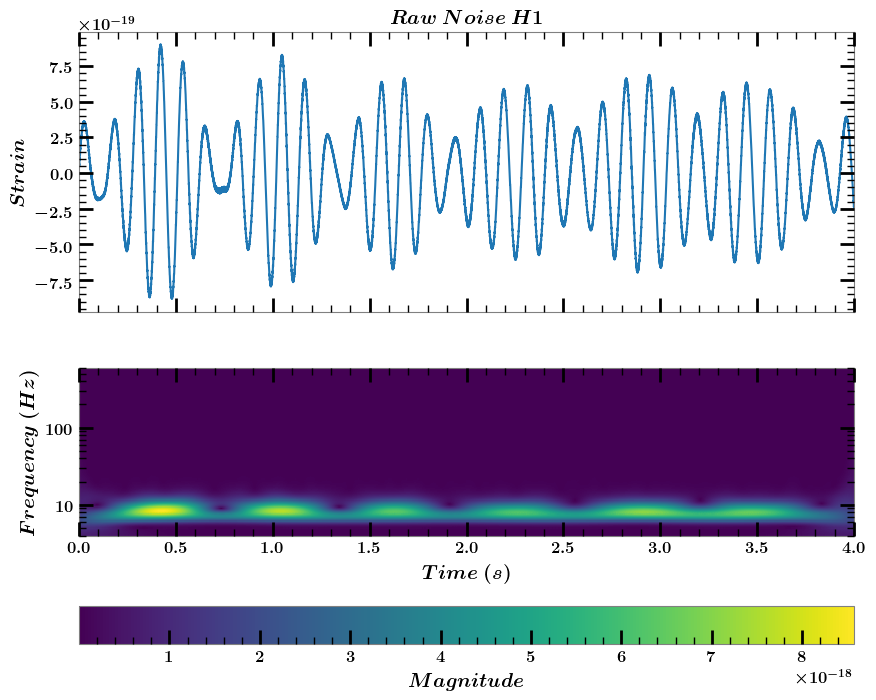

In [166]:
time, freqs, cwtmatr = cwt(t_noise, noise_1, 
                           wavelet = "cmor1.5-1.0", 
                           # wavelet = "gaus8",
                            num_scales = 200, scale_max = 1024)

plt.subplots(2, 1, figsize = (10, 8), sharex = True)
plt.subplot(2, 1, 1)
plt.plot(t_noise, noise_1)
plt.ylabel(r"$Strain$")
plt.title(r"$Raw$ $Noise$ $H1$")
plt.grid(False)

plt.subplot(2, 1, 2)
plt.pcolormesh(time, freqs, cwtmatr, shading = "auto", rasterized = True)
plt.colorbar(label = r"$Magnitude$", pad = 0.25, orientation = "horizontal")
plt.xlabel(r'$Time$ $(s)$')
plt.ylabel(r'$Frequency$ $(Hz)$')
plt.yscale("log")
plt.xlim(time[0], time[-1])
plt.ylim(0, 600)
plt.grid(False)
plt.xticks()
plt.yticks()
# plt.savefig(graph_dir + "cwt_noise.pdf")
plt.savefig(graph_dir_lstm_analysis + "/cwt_noise.png")
plt.show()

#### Event Data Analysis of GW150914 event 

In [168]:
### Importing the event Dataset
import pickle
import os
# # Example usage:
event_name = "GW150914"
l_detector = ["H1", "L1"]
duration = 2
fs = 4096
font_size = 16

# # # Example usage:
event = EventDetails(event_name)
all_details = event.get_all_details()
print("All details as dictionary:", all_details)
merger_t_ligo = event.get_merger_time()

detector = l_detector[0]
file_path_h1 = os.path.join(data_dir_lstm_analysis, f'{event_name}_{duration*2}s_{detector}.pkl')
if not os.path.exists(file_path_h1):
    eve_sig_h1 = gw_raw(event_name, detector=detector, time_frame=duration)
    with open(file_path_h1, 'wb') as h:
        pickle.dump(eve_sig_h1, h)

detector = l_detector[1]
file_path_l1 = os.path.join(data_dir_lstm_analysis, f'{event_name}_{duration*2}s_{detector}.pkl')
if not os.path.exists(file_path_l1):
    eve_sig_l1 = gw_raw(event_name, detector=detector, time_frame=duration)
    with open(file_path_l1, 'wb') as l:
        pickle.dump(eve_sig_l1, l)

# Loading the Dataset
with open(data_dir_lstm_analysis + f'/{event_name}_{duration*2}s_H1.pkl', 'rb') as h:
    eve_sig_h1 = pickle.load(h)
with open(data_dir_lstm_analysis + f'/{event_name}_{duration*2}s_L1.pkl', 'rb') as l:
    eve_sig_l1 = pickle.load(l)

All details as dictionary: {'event_name': 'GW150914', 'merger_time': 1126259462.4, 'mass1': 35.6, 'mass2': 30.6, 'spin_eff': -0.01, 'distance': 440.0}


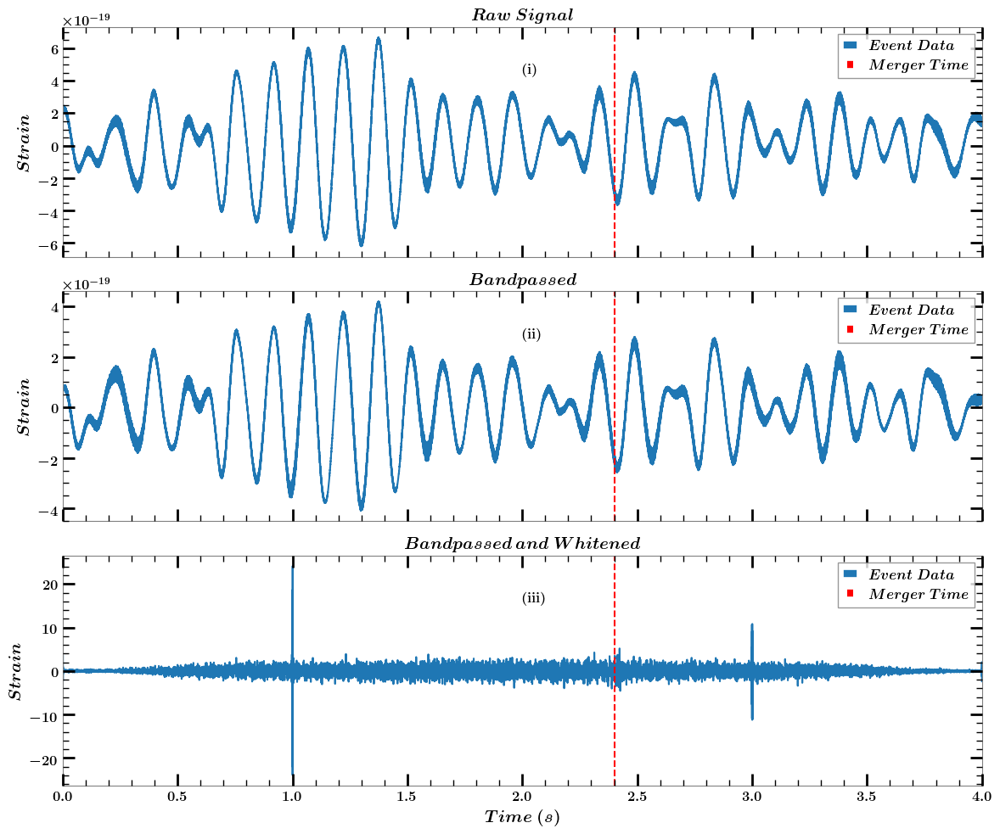

In [ ]:
# Applying the bandpass filter
t_ligo = eve_sig_h1.times.value
t_real = np.linspace(0, 2*duration, 2*fs*duration)
merger_t_real = t_real[np.argmin(abs(t_ligo - merger_t_ligo))]


eve_sig_bp = bandpass_filter(eve_sig_h1, fs, normalize=False, whiten=False)
eve_sig_bp_whiten = bandpass_filter(eve_sig_h1, fs, whiten=True, normalize=True)

# Create the figure and axes
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot the raw signal
ax[0].plot(t_real, eve_sig_h1, label=r"$Event$ $Data$")
ax[0].axvline(x=merger_t_real, color="red", linestyle="--", label=r"$Merger$ $Time$")
ax[0].set_ylabel(r"$Strain$")
ax[0].set_title(r"$Raw$ $Signal$")
ax[0].set_xlim(t_real[0], t_real[-1])
ax[0].grid(False)
ax[0].legend()
ax[0].text(0.5, 0.8, r"$\mathbf{(i)}$", transform=ax[0].transAxes)

# Plot the bandpassed signal
ax[1].plot(t_real, eve_sig_bp, label=r"$Event$ $Data$")
ax[1].axvline(x=merger_t_real, color="red", linestyle="--", label=r"$Merger$ $Time$")
ax[1].set_ylabel(r"$Strain$")
ax[1].set_title(r"$Bandpassed$")
ax[1].set_xlim(t_real[0], t_real[-1])
ax[1].grid(False)
ax[1].legend()
ax[1].text(0.5, 0.8, r"$\mathbf{(ii)}$", transform=ax[1].transAxes)

# Plot the bandpassed and whitened signal
ax[2].plot(t_real, eve_sig_bp_whiten, label=r"$Event$ $Data$")
ax[2].axvline(x=merger_t_real, color="red", linestyle="--", label=r"$Merger$ $Time$")
ax[2].set_xlabel(r"$Time$ $(s)$")
ax[2].set_ylabel(r"$Strain$")
ax[2].set_title(r"$Bandpassed$ $and$ $Whitened$")
ax[2].set_xlim(t_real[0], t_real[-1])
ax[2].grid(False)
ax[2].legend()
ax[2].text(0.5, 0.8, r"$\mathbf{(iii)}$", transform=ax[2].transAxes)

# Adjust layout
plt.tight_layout()
# plt.savefig(graph_dir + f"{event_name}_pp.pdf")
plt.savefig(graph_dir + f"/{event_name}_pp.png")
plt.show()

## LSTM Autoencoders for denoising GW signals

In [7]:
data_dir_ae = os.path.join(data_dir, "ae")
graph_dir_ae = os.path.join(graph_dir, "ae")

if not os.path.exists(graph_dir_ae):
    os.makedirs(graph_dir_ae)

# Check and create directories only if they don't exist
if not os.path.exists(data_dir_ae):
    os.makedirs(data_dir_ae)
    print("Directories created.")

Directories created.


### LSTM Autoencoder Code to train the model 

This is the code for the LSTM autoencoders. Do not run the code on the PC. It is advisable to run it on the hpc rather than running on the normal personal computer. Please not that the training of dataset almost took 12 Hrs when the code was using 7 cores at a time for computation.  

The data saved for the below file is saved in the name of lstm_5. Meaning if you want to just get the results of the file you need to get the results named after the "lstm_5". If not, (Meaning, you are running your own code for training, then it will be stored after the name of the file - "lstm_ae".)

#### Defining the name of the file 

In [21]:
file_name = "lstm_5" # Change the filename if you are running the training of the model yourself

#### Full Code 

In [ ]:
# ##############################################################
# file_name = "lstm_ae"
# look_back = 64
# batch_size = 128
# epochs = 40
# learning_rate = 0.0001
# #######################################################################

# from gwpy.timeseries import TimeSeries
# import numpy as np 
# import pandas as pd 
# import matplotlib.pyplot as plt 
# import tensorflow as tf 
# import sklearn as sk
# import h5py
# import logging

# import numpy as np
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, Dropout, BatchNormalization
# from tensorflow.keras.optimizers import Adam
# from sklearn.preprocessing import StandardScaler, MinMaxScaler
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error


# import gwpy
# from gwpy.signal.filter_design import bandpass
# from gwpy.timeseries import TimeSeries
# from gwpy.signal import filter_design
# from gwpy.plot import Plot
# import scipy
# from scipy import signal
# from scipy.signal import decimate
# import sxs
# import os
# import pickle
# import sys


# # Define parameters for the Gaussian white noise
# mean = 0
# std_dev = 1
# duration = 64  # duration in seconds
# fs = 4096  # sampling frequency in Hz
# num_samples = duration * fs  # total number of samples

# # Generate Gaussian white noise
# gauss_noise = np.random.normal(mean, std_dev, num_samples)

# # Create a time series object
# noise = TimeSeries(gauss_noise, sample_rate=fs)
# noise_norm = noise/np.max(np.abs(noise))
# t_noise = np.linspace(0, duration, num_samples)

# ############## Saving the Dataset ##################
# with open(data_dir_ae + "/noise_data.pkl", "wb") as f:
#     pickle.dump({"noise": noise, "noise_norm": noise_norm}, f)

# # # Obtaining the Dataset from where the names of the waveforms are available 
# # simulations = sxs.load("simulations")  # Load the simulations catalog
# # df = simulations.dataframe  # Get the catalog as a DataFrame

# # df_working = df[df["deprecated"] == False]  # Get only the non-deprecated BHBH simulations
# # df_BBH = df_working[df_working["object_types"] == "BHBH"]  # Filter for binary black hole (BBH) mergers

# # index = df_BBH.index.to_numpy()  # Get the list of simulation names
# # new_index = [name.replace(":", "_") for name in index]  # Format names properly

# with open(data_dir_ae + "/new_index.pkl", "rb") as f:
#     new_index = pickle.load(f)

# len_noise = len(t_noise)  # Define total noise length
# waveforms = []
# names = [] # Names of the waveforms which will be used in the injection
# remaining_length = len_noise  # Track remaining space for waveforms

# def nearest_power_of_2(n):  
#     return 2 ** int(np.ceil(np.log2(n)))  # Compute nearest power of 2

# i = 0
# while remaining_length > 1024 and i < len(new_index):  
#     with h5py.File(data_dir_all_wf + '/preprocess_60/' + f'{new_index[i]}_pp.h5', 'r') as f:
#         time = f['time'][:]
#         wf = f['plus'][:]  # Load waveform data
        
#     if len(wf) < 1024:  # Skip waveforms smaller than 1024 samples
#         i += 1
#         continue  
#     wf = wf / np.max(np.abs(wf))  # Normalize waveform
#     wf_ds = scipy.signal.decimate(wf, 2)  # Downsample by factor of 2

#     if len(wf_ds) < 1024:  # Skip again if downsampled waveform is too small
#         i += 1
#         continue  
#     new_len = nearest_power_of_2(len(wf_ds))  # Find nearest power of 2
#     if new_len > remaining_length:  
#         i += 1
#         continue  # Skip if waveform is too long

#     pad_width = (new_len - len(wf_ds)) // 2  # Compute padding width
#     wf_ds = np.pad(wf_ds, (pad_width, new_len - len(wf_ds) - pad_width), mode='constant')  # Pad to nearest power of 2

#     names.append(new_index[i])  # Store waveform name
#     waveforms.append(wf_ds)  # Append padded waveform

#     remaining_length -= len(wf_ds)  # Update remaining length
#     i += 1

# if remaining_length > 0:  
#     waveforms.append(np.zeros(remaining_length))  # Pad with zeros if space is left
# app_wf = np.concatenate(waveforms)  # Concatenate all waveforms
# app_wf = app_wf[:len_noise]  # Ensure final waveform matches len_noise



# ############ Saving the Data ####################
# with open(data_dir_ae + "/inj_waveforms.pkl", "wb") as f:
#     pickle.dump({"waveforms": waveforms, "names_waveforms": names, "time": t_noise,
#                   "inj_data": app_wf}, f)


# signal = noise_norm + app_wf
# # signal = noise + app_wf
# signal_norm = signal / np.max(np.abs(signal))
# app_wf_norm = app_wf / np.max(np.abs(signal))
# norm_noise = noise_norm / np.max(np.abs(signal))

# ############ Saving the Data ####################
# with open(data_dir_ae + "/signal.pkl", "wb") as f:
#     pickle.dump({"signal": signal, "signal_norm": signal_norm}, f)


# def create_seq(data, look_back=64, step=1):
#     sequences = []
#     for i in range(0, len(data) - look_back + 1, step):
#         sequences.append(data[i:i+look_back])
#     return np.array(sequences).reshape(-1, look_back, 1)

# def reverse_seq(seq):
#     recon_signal = list(seq[0, :, 0])  # Start with the first sequence
#     for i in range(1, seq.shape[0]):
#         recon_signal.append(seq[i, -1, 0])  # Append only the last element of each subsequent sequence
#     return np.array(recon_signal)


# # Create overlapping sequences (sliding window) with look_back=64 and step=1
# # look_back = 64
# X = create_seq(signal_norm, look_back=look_back)
# y = create_seq(app_wf_norm, look_back=look_back)

# # print("Shape of X (simulated noise with injected waveforms):", X.shape)
# # print("Shape of y (clean target waveform):", y.shape)

# # Split into training and test sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle = False)

# # print("Length of X_train data:", X_train.shape)
# # print("Length of X_test data:", X_test.shape)
# # print("Length of y_train data:", y_train.shape)
# # print("Length of y_test data:", y_test.shape)

# ################## Save the Dataset ###############
# with open(data_dir_ae + "/train_test_dataset.pkl", "wb") as f:
#     pickle.dump({"X_train": X_train, "X_test": X_test, "y_train": y_train, "y_test": y_test}, f)

# # Build the LSTM autoencoder model

# # batch_size = 128
# # epochs = 30

# model = Sequential()
# model.add(Input(shape=(look_back, 1)))
# # model.add(LSTM(64, activation='tanh', return_sequences=True))
# model.add(LSTM(32, activation='tanh', return_sequences=True))
# # model.add(Dropout(0.2))
# model.add(LSTM(16, activation='tanh', return_sequences= True))
# model.add(LSTM(8, activation = 'tanh', return_sequences = False))
# model.add(RepeatVector(look_back))
# model.add(LSTM(8, activation = 'tanh', return_sequences = True))
# model.add(LSTM(16, activation='tanh', return_sequences=True))
# # model.add(Dropout(0.2))
# model.add(LSTM(32, activation='tanh', return_sequences=True))
# # model.add(LSTM(64, activation='tanh', return_sequences=True))
# model.add(TimeDistributed(Dense(1)))  # Output shape same as input
# # Define learning rate schedule


# # Configure logging
# logging.basicConfig(filename= data_dir_ae + f"/training_log_{file_name}.txt", 
#                     level=logging.INFO, format="%(asctime)s - %(message)s")

# class LossLoggerCallback(tf.keras.callbacks.Callback):
#     def on_epoch_end(self, epoch, logs=None):
#         logging.info(f"Epoch {epoch+1}: Loss={logs['loss']}, Val_Loss={logs.get('val_loss')}")

# # Use the callback
# loss_logger = LossLoggerCallback()

# lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
#     initial_learning_rate= learning_rate,
#     decay_steps = 10000,
#     decay_rate=0.96,
#     staircase=True
# )
# optimizer = Adam(learning_rate=lr_schedule)
# model.compile(optimizer=optimizer, loss='mse')
# model.summary()
# history = model.fit(X_train, y_train, epochs= epochs, batch_size=batch_size, 
#                     validation_data=(X_test, y_test), callbacks=[loss_logger], verbose=1)

# ################### Save the model ################
# model.save(data_dir_ae + f"/model_{file_name}.keras")
# ################### Save the history ################
# with open(data_dir_ae + f"/hist_model_{file_name}.pkl", "wb") as f:
#     pickle.dump(history.history, f)


# # Predict on test data
# predicted_waveform = model.predict(X_test)

# # Test Dataset
# test_sig = reverse_seq(y_test)
# test_pred = reverse_seq(predicted_waveform)
# signal_sig = reverse_seq(X_test)

# # Train Dataset
# train_sig = reverse_seq(y_train)
# train_pred = reverse_seq(model.predict(X_train))
# signal_sig_train = reverse_seq(X_train)

# # Time vector
# t_train = np.linspace(0, len(train_sig)/fs, len(train_sig))
# t_test = np.linspace(0, len(test_sig)/fs, len(test_sig))

# # Mean Squared Error
# mse_train = mean_squared_error(train_sig, train_pred)
# mse_test = mean_squared_error(test_sig, test_pred)

# # Normalized Cross-Correlation
# def normalized_cross_correlation(x_true, x_pred):
#     """Compute Normalized Cross-Correlation (NCC) between true and predicted waveforms."""
#     x_true = x_true.flatten()
#     x_pred = x_pred.flatten()

#     numerator = np.sum(x_true * x_pred)
#     denominator = np.sqrt(np.sum(x_true**2) * np.sum(x_pred**2))

#     return numerator / denominator if denominator != 0 else 0

# # Compute NCC
# ncc = normalized_cross_correlation(test_sig, test_pred)

# # Save the dataset
# dataset = {
#     "test_pred": test_pred,
#     "train_pred": train_pred,
#     "test_sig": test_sig,
#     "train_sig": train_sig
#     }

# # Save the dataset as a pickle file
# with open(data_dir_ae + f"/model_{file_name}_results.pkl", "wb") as f:
#     pickle.dump(dataset, f)

# # Create the log file
# with open(data_dir_ae + f"/model_{file_name}_log.txt", "w") as log_file:
#     # Write dataset information
#     log_file.write("### Dataset Information ###\n")
#     log_file.write(f"Number of waveforms used: {len(waveforms)}\n")
#     log_file.write(f"Waveforms used: {names}\n")
#     log_file.write(f"Train dataset length: {len(train_sig)}\n")
#     log_file.write(f"Test dataset length: {len(test_sig)}\n")
#     log_file.write("\n")

#     # Write model summary
#     log_file.write("### Model Summary ###\n")
#     model_summary = []
#     model.summary(print_fn=lambda x: model_summary.append(x))
#     log_file.write("\n".join(model_summary))
#     log_file.write("\n")

#     # Write prediction accuracy
#     log_file.write("### Prediction Accuracy ###\n")
#     log_file.write(f"Mean Squared Error (Train): {mse_train}\n")
#     log_file.write(f"Mean Squared Error (Test): {mse_test}\n")
#     log_file.write(f"Normalized Cross-Correlation (NCC): {ncc}\n")
#     log_file.write("\n")

#     # Write additional information
#     log_file.write("### Additional Information ###\n")
#     log_file.write(f"Standard Deviation of Noise: {std_dev}\n")
#     log_file.write("\n")

### Plotting the results of the dataset from the lstm_5 file

#### Additive White gaussian Noise for the Noisy Dataset

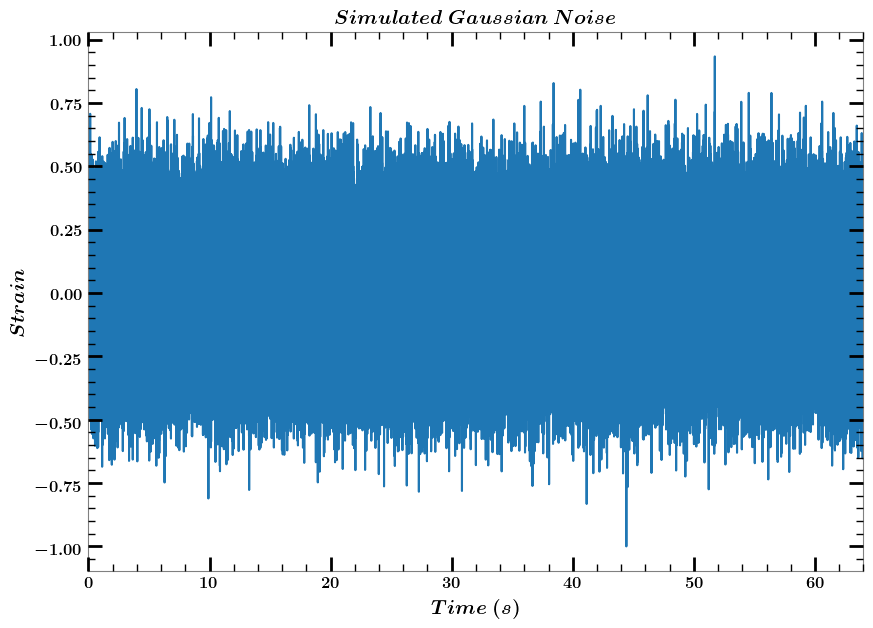

In [ ]:
with open(data_dir_ae + "/noise_data.pkl", "rb") as f:
    noise_data = pickle.load(f)
# Extract the variables
noise = noise_data["noise"]
noise_norm = noise_data["noise_norm"]
    
t_noise = np.linspace(0, len(noise)/4096, len(noise))

# Plot the time series
plt.figure(figsize=(10, 7))
plt.plot(noise_norm.times.value, noise_norm.value)
# plt.plot(t_noise, noise, color='blue', lw=1)
plt.title(r'$Simulated$ $Gaussian$ $Noise$')
plt.xlabel(r'$Time$ $(s)$')
plt.ylabel(r'$Strain$')
plt.xlim(t_noise[0], t_noise[-1])
plt.xticks()
plt.yticks()
plt.grid(False)
plt.savefig(graph_dir_ae + "/sim_noise.png")
plt.show()

#### Creating the waveforms signal which needs to be injected into the dataset of the noise

##### Making the waveforms data which consits of the injection of the waveforms only 

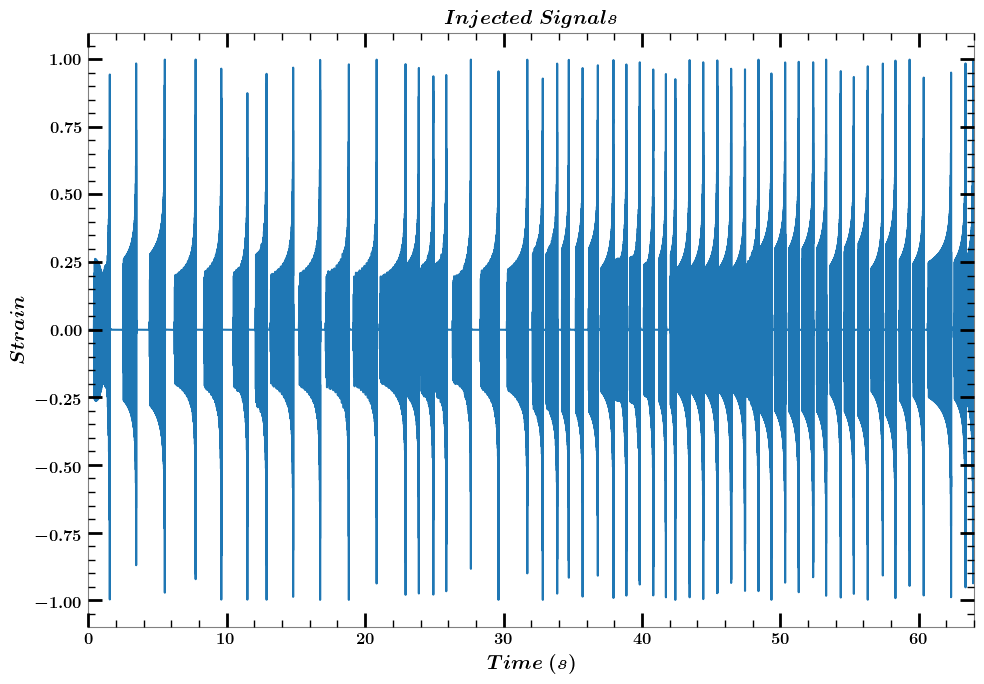

In [12]:
# Load the data
with open(data_dir_ae + "/inj_waveforms.pkl", "rb") as f:
    data_wf = pickle.load(f)

# Extract the variables
waveforms = data_wf["waveforms"]
names_waveforms = data_wf["names_waveforms"]
time = data_wf["time"]
inj_data = data_wf["inj_data"]


plt.figure(figsize=(10, 7))
plt.plot(t_noise, inj_data)  # Plot final injected waveform
plt.xlabel(r'$Time$ $(s)$')
plt.ylabel(r'$Strain$')
plt.title(r"$Injected$ $Signals$")
plt.xlim(t_noise[0], t_noise[-1])
# plt.legend()
plt.grid(False)
plt.tight_layout()
# plt.savefig(graph_dir + "inj_waveform.pdf")
plt.savefig(graph_dir_ae + "/inj_waveform.png")
plt.show()

### Forming the final signal which is equal to noise + injected waveforms

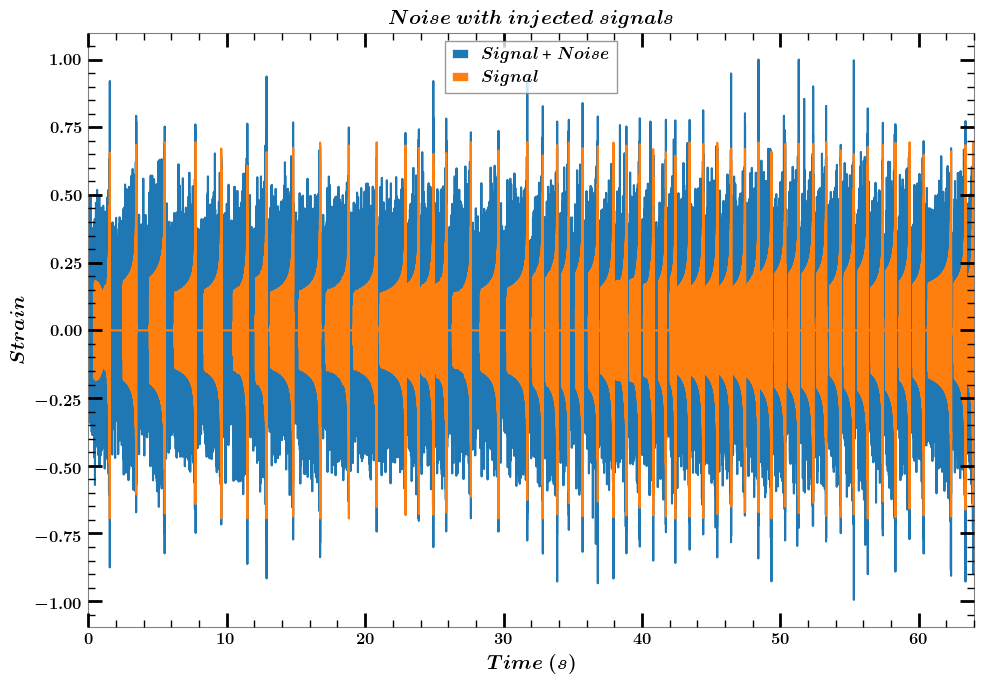

In [23]:
# Load the data
with open(data_dir_ae + "/signal.pkl", "rb") as f:
    data_signal = pickle.load(f)

# Extract the variables
signal = data_signal["signal"]
signal_norm = data_signal["signal_norm"]

# Plot the time series
plt.figure(figsize=(10, 7))
# plt.plot(t_noise, noise_norm, label =  r'$Normalized$ $Noise$')
plt.plot(t_noise, signal_norm, label = r'$Signal$ + $Noise$')
plt.plot(t_noise, inj_data/np.max(np.abs(signal)), label = r'$Signal$')
plt.title(r'$Noise$ $with$ $injected$ $signals$')
plt.xlabel(r'$Time$ $(s)$')
plt.ylabel(r'$Strain$')
plt.xlim(t_noise[0], t_noise[-1])
plt.xticks()
plt.yticks()
plt.grid(False)
plt.legend()
plt.tight_layout()
# plt.savefig(graph_dir_ae + "/normalized_signal_wf.pdf")
plt.savefig(graph_dir_ae + "/normalized_signal_wf.png")
# plt.savefig(graph_dir_ae + "/normalized_signal.png")
plt.show()

#### Generating the waveforms

In [19]:
with open(data_dir_ae + "/train_test_dataset.pkl", "rb") as f:
    dataset = pickle.load(f)

# Extract the variables
X_train = dataset["X_train"]
X_test = dataset["X_test"]
y_train = dataset["y_train"]
y_test = dataset["y_test"]


# # Split into training and test sets
# print("Length of X_train data:", X_train.shape)
# print("Length of X_test data:", X_test.shape)
# print("Length of y_train data:", y_train.shape)
# print("Length of y_test data:", y_test.shape)

#### Checking whether the generated waveforms are correct or not 

In [22]:
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError


path = data_dir_ae + f"/model_{file_name}.keras"

model = load_model(path)
# Verify the loaded model
model.summary()


2025-05-01 18:48:22.952544: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64, 16)         │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 64, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64, 8)          │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64, 16)         │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 64, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,212 (196.14 KB)

 Trainable params: 16,737 (65.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 33,475 (130.77 KB)

#### Plotting the loss function for the training and validation set

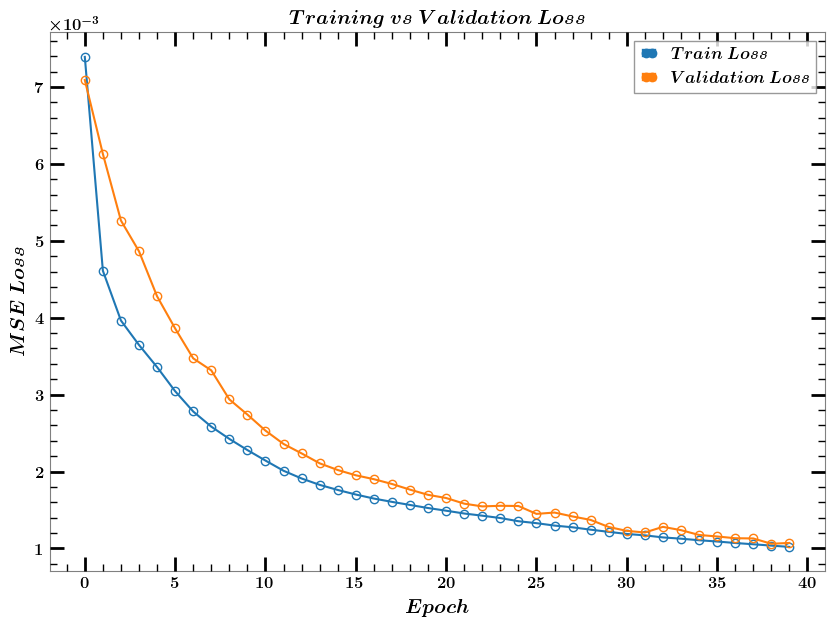

In [24]:
with open(data_dir_ae + f"/hist_model_{file_name}.pkl", "rb") as f:
    history = pickle.load(f)

# Plot training and validation loss
plt.figure(figsize=(10, 7))
plt.plot(history['loss'], "o-", label=r'$Train$ $Loss$')
plt.plot(history['val_loss'],"o-", label=r'$Validation$ $Loss$')
plt.xlabel(r'$Epoch$')
plt.ylabel(r'$MSE$ $Loss$')
plt.legend()
plt.xticks()
plt.yticks()
# plt.yscale('log')
plt.grid(False)
plt.title(r'$Training$ $vs$ $Validation$ $Loss$')
# plt.savefig(graph_dir + "train_valid_loss.pdf")
plt.savefig(graph_dir_ae + "/train_valid_loss.png")
plt.show()

#### Prediction for the test and train dataset by the model

In [28]:
def create_seq(data, look_back=64, step=1):
    sequences = []
    for i in range(0, len(data) - look_back + 1, step):
        sequences.append(data[i:i+look_back])
    return np.array(sequences).reshape(-1, look_back, 1)

def reverse_seq(seq):
    recon_signal = list(seq[0, :, 0])  # Start with the first sequence
    for i in range(1, seq.shape[0]):
        recon_signal.append(seq[i, -1, 0])  # Append only the last element of each subsequent sequence
    return np.array(recon_signal)

with open(data_dir_ae + f"/model_{file_name}_results.pkl", "rb") as f:
    dataset = pickle.load(f)

# Extract the variables
test_pred = dataset["test_pred"]
train_pred = dataset["train_pred"]
test_sig = dataset["test_sig"]
train_sig = dataset["train_sig"]

#### Plot of Training Dataset

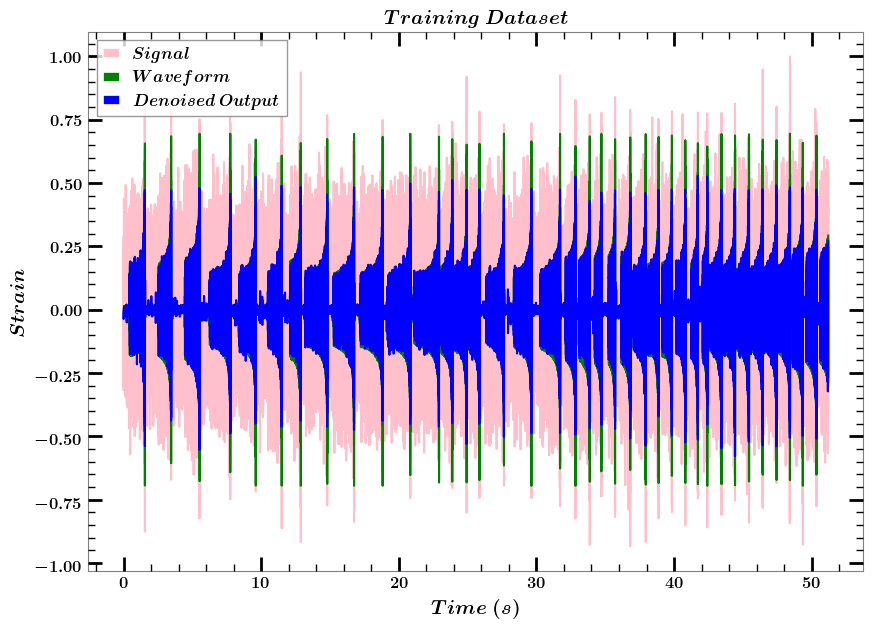

In [29]:
t_train = np.linspace(0, len(train_sig)/4096, len(train_sig))
t_test = np.linspace(0, len(test_sig)/4096, len(test_sig))

signal_train = reverse_seq(X_train)

# # Plot an example from the test set
plt.figure(figsize=(10, 7))
plt.plot(t_train, signal_train, label=r"$Signal$", color="pink")
plt.plot(t_train, train_sig, label=r"$Waveform$", color="green")
plt.plot(t_train, train_pred, label=r"$Denoised$ $Output$", color="blue")
plt.xlabel(r'$Time$ $(s)$')
plt.ylabel(r'$Strain$')
plt.title(r'$Training$ $Dataset$')
plt.legend()
plt.xticks()
plt.yticks()
plt.grid(False)
# plt.savefig(graph_dir_ae + "/train_fit.pdf")
plt.savefig(graph_dir_ae + "/train_fit.png")
plt.show()

#### Plot of Test Dataset zoomed

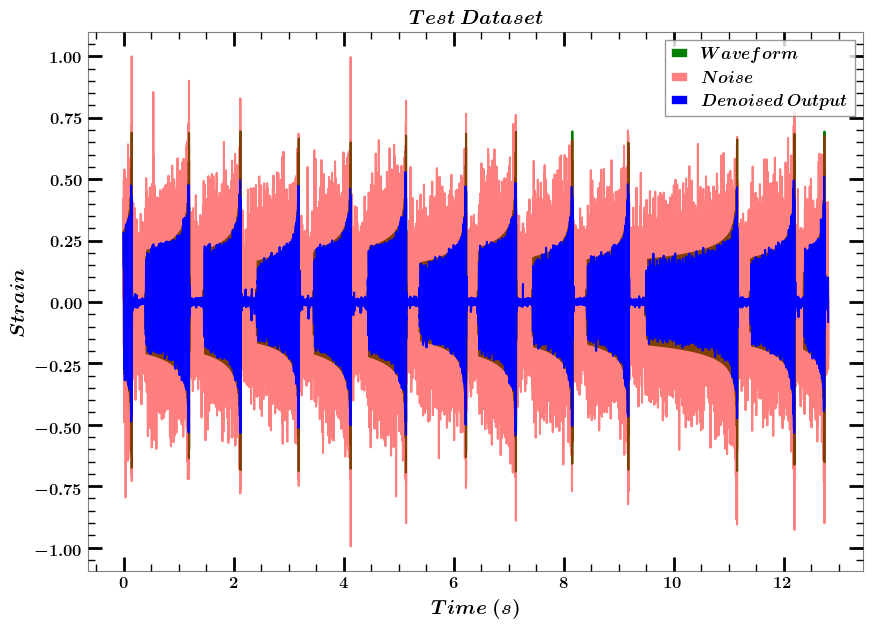

In [30]:
signal_test = reverse_seq(X_test)

# # Plot an example from the test set
plt.figure(figsize=(10, 7))
plt.plot(t_test, test_sig, label=r"$Waveform$", color="green")
plt.plot(t_test, signal_test, label=r"$Noise$", color="red", alpha=0.5)
plt.plot(t_test, test_pred, label=r"$Denoised$ $Output$", color="blue")
plt.xlabel(r'$Time$ $(s)$')
plt.ylabel(r'$Strain$')
plt.title(r'$Test$ $Dataset$')
plt.xticks()
plt.yticks()
plt.legend()
plt.grid(False)
# plt.savefig(graph_dir + "test_fit.pdf")
plt.savefig(graph_dir_ae + "/test_fit.png")
plt.show()

#### Zoomed predictions of test dataset

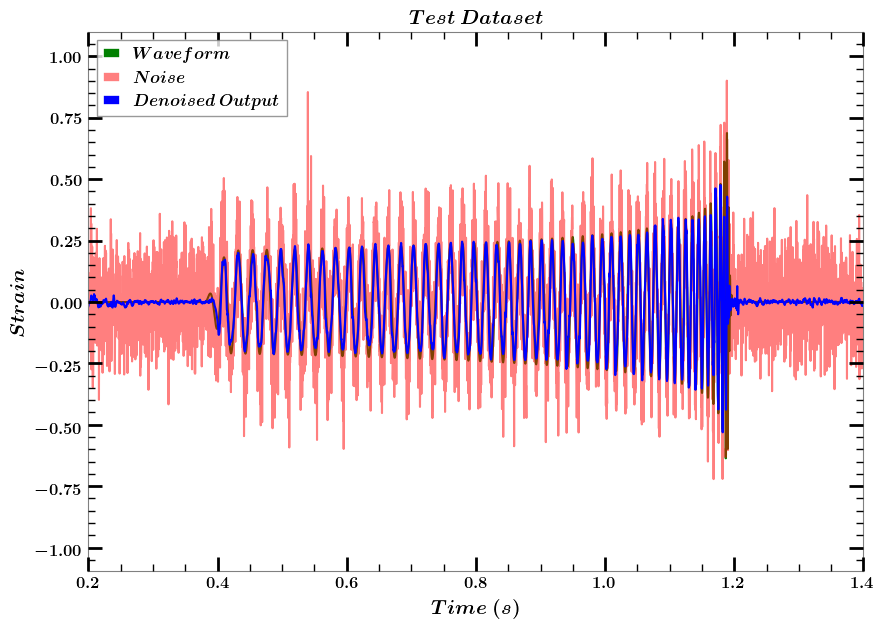

In [31]:
plt.figure(figsize=(10, 7))
plt.plot(t_test, test_sig, label=r"$Waveform$", color="green")
plt.plot(t_test, signal_test, label=r"$Noise$", color="red", alpha=0.5)
plt.plot(t_test, test_pred, label=r"$Denoised$ $Output$", color="blue")
plt.xlabel(r'$Time$ $(s)$')
plt.ylabel(r'$Strain$')
plt.title(r'$Test$ $Dataset$')
plt.xticks()
plt.yticks()
plt.legend()
plt.grid(False)
plt.xlim(0.2, 1.4)
# plt.savefig(graph_dir + "test_fit_zoom.pdf")
plt.savefig(graph_dir_ae + "/test_fit_zoom.png")
plt.show()

#### Evaluating the predictions of the model on the LIGO dataset in the presence of the event 

All details as dictionary: {'event_name': 'GW150914', 'merger_time': 1126259462.4, 'mass1': 35.6, 'mass2': 30.6, 'spin_eff': -0.01, 'distance': 440.0}


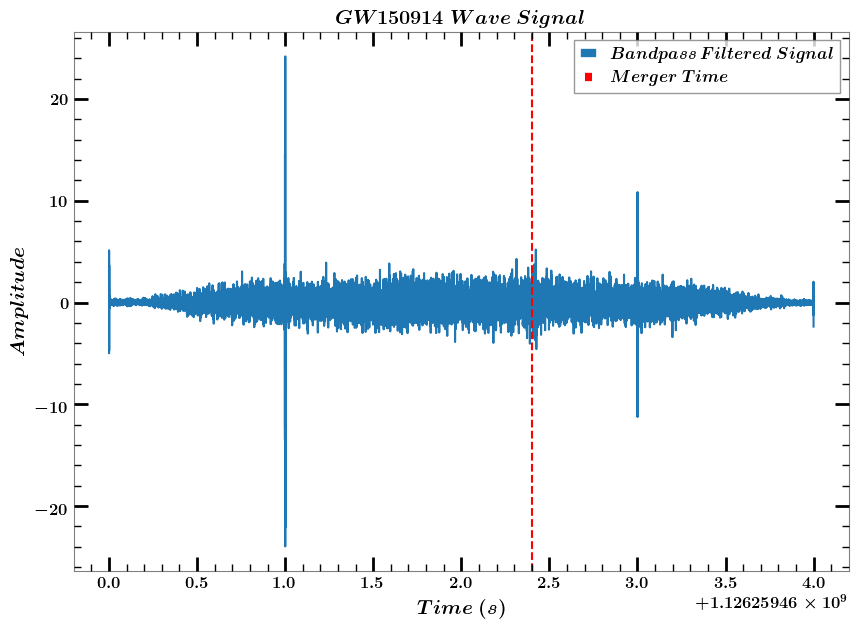

Print the shape of event_test: (16257, 128, 1)
509/509 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step


In [35]:
### Importing the event Dataset
import pickle
# # Example usage:
event_name = "GW150914"
detector = "H1"
duration = 2
fs = 4096
font_size = 16

# # # Example usage:
event = EventDetails(event_name)
all_details = event.get_all_details()
print("All details as dictionary:", all_details)
merger_t_ligo = event.get_merger_time()


# Loading the Dataset
with open(data_dir_lstm_analysis + f'/{event_name}_{duration*2}s_H1.pkl', 'rb') as h:
    eve_sig_h1 = pickle.load(h)
with open(data_dir_lstm_analysis + f'/{event_name}_{duration*2}s_L1.pkl', 'rb') as l:
    eve_sig_l1 = pickle.load(l)

eve_sig_bp_whiten = bandpass_filter(eve_sig_h1, fs, whiten = True, normalize = True)

plt.figure(figsize=(10, 7))
# plt.plot(eve_sig_h1.times.value, eve_sig_h1.value, label = r'$Raw$ $Signal$', color = "blue")
plt.plot(eve_sig_bp_whiten.times.value, eve_sig_bp_whiten.value, label = r'$Bandpass$ $Filtered$ $Signal$')
plt.axvline(x = merger_t_ligo, color = "red", linestyle = "--", label = r'$Merger$ $Time$')
plt.title(r"$GW150914$ $Wave$ $Signal$")
plt.xlabel(r"$Time$ $(s)$")
plt.ylabel(r"$Amplitude$")
# plt.xlim(eve_sig_h1.times[0], eve_sig_h1.times[-1])
plt.xticks()
plt.yticks()
plt.legend()
plt.grid(False)
plt.show()

eve_test = eve_sig_bp_whiten.value/np.max(np.abs(eve_sig_bp_whiten.value))

# import scipy
# eve_test = scipy.signal.decimate(eve_test, 2)

look_back = 128
eve_test_seq = create_seq(eve_test, look_back=look_back)
print("Print the shape of event_test:", eve_test_seq.shape)

predicted_eve = model.predict(eve_test_seq)
pred_eve = reverse_seq(predicted_eve)

t_pred_eve = np.linspace(0, len(pred_eve)/fs, len(pred_eve))

#### Denoised signal obtained from the model 

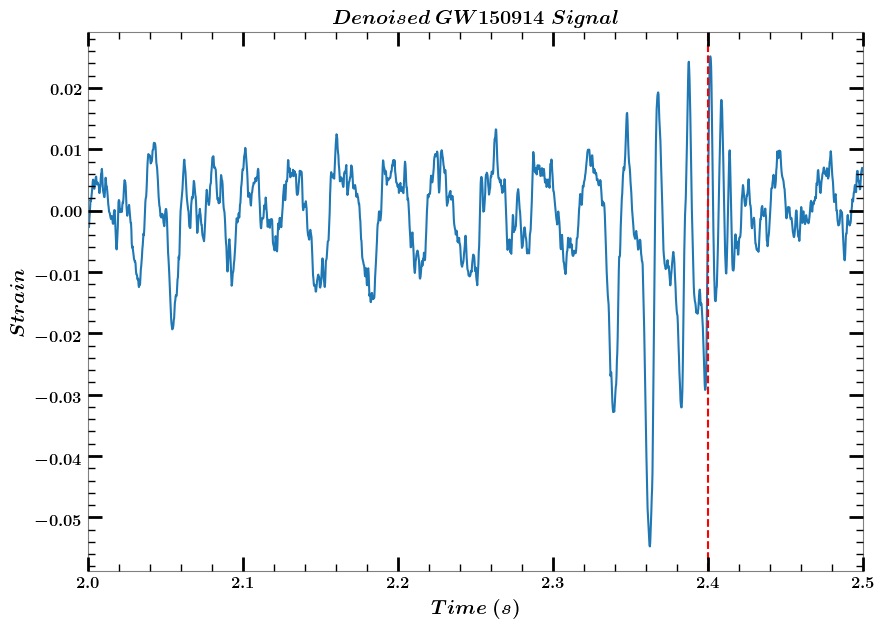

In [37]:
plt.figure(figsize = (10, 7))
# plt.plot(t_pred_eve, eve_test, label = r'$Original$ $Signal$', color = "green")
plt.plot(t_pred_eve, pred_eve)
plt.axvline(x = 2.4, color = "red", linestyle = "--", label = r'$Merger$ $Time$')
plt.title(rf"$Denoised$ ${event_name}$ $Signal$")
plt.xlabel(r"$Time$ $(s)$")
plt.ylabel(r"$Strain$")
plt.xlim(2.0, 2.5)
# plt.ylim(-0.25, 0.25)
plt.xticks()
plt.yticks()
plt.grid(False)
# plt.xlim(duration, duration + 0.5)
# plt.savefig(graph_dir + f"dn_{event_name}_zoom.pdf")
plt.savefig(graph_dir_ae + f"/dn_{event_name}_zoom.png")
plt.show()

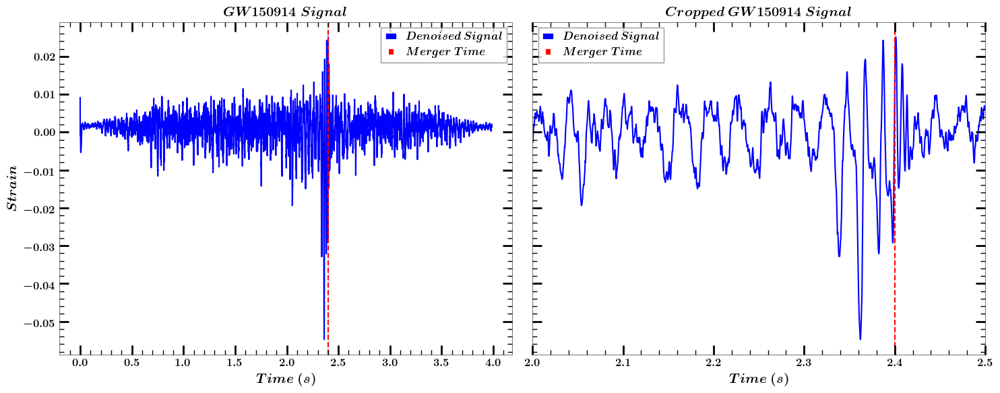

In [38]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey = True)

# Plot the first signal
axs[0].plot(t_pred_eve, pred_eve, color="blue", label=r"$Denoised$ $Signal$")
axs[0].axvline(x=2.4, color="red", linestyle="--", label=r"$Merger$ $Time$")
axs[0].set_title(r"$GW150914$ $Signal$")
axs[0].set_xlabel(r"$Time$ $(s)$")
axs[0].set_ylabel(r"$Strain$")
axs[0].legend()
axs[0].grid(False)

# Plot the second signal
axs[1].plot(t_pred_eve, pred_eve, label=r'$Denoised$ $Signal$', color="blue", linestyle="solid")
axs[1].axvline(x=2.4, color="red", linestyle="--", label=r"$Merger$ $Time$")
axs[1].set_title(rf"$Cropped$ ${event_name}$ $Signal$")
axs[1].set_xlabel(r"$Time$ $(s)$")
# axs[1].set_ylabel(r"$Strain$")
axs[1].set_xlim(duration, duration + 0.5)
axs[1].legend()
axs[1].grid(False)

# Adjust layout and show the plot
plt.tight_layout()
# plt.savefig(graph_dir + f"{event_name}_pred.pdf")
plt.savefig(graph_dir_ae + f"/{event_name}_pred.png")
plt.show()


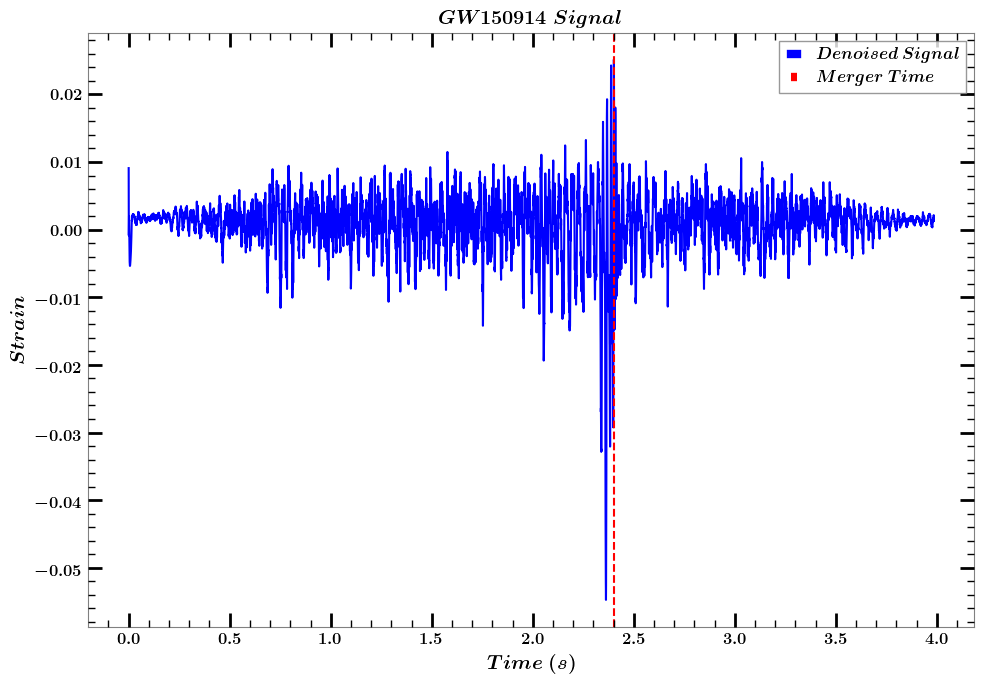

In [39]:
fig, ax = plt.subplots(figsize=(10, 7))

# Plot the first signal
ax.plot(t_pred_eve, pred_eve, color="blue", label=r"$Denoised$ $Signal$")
ax.axvline(x=2.4, color="red", linestyle="--", label=r"$Merger$ $Time$")
ax.set_title(r"$GW150914$ $Signal$")
ax.set_xlabel(r"$Time$ $(s)$")
ax.set_ylabel(r"$Strain$")
ax.legend()
ax.grid(False)

# Adjust layout and show the plot
plt.tight_layout()
plt.savefig(graph_dir_ae + f"/{event_name}_pred.png")
# plt.savefig(graph_dir + f"{event_name}_pred.pdf")
plt.show()


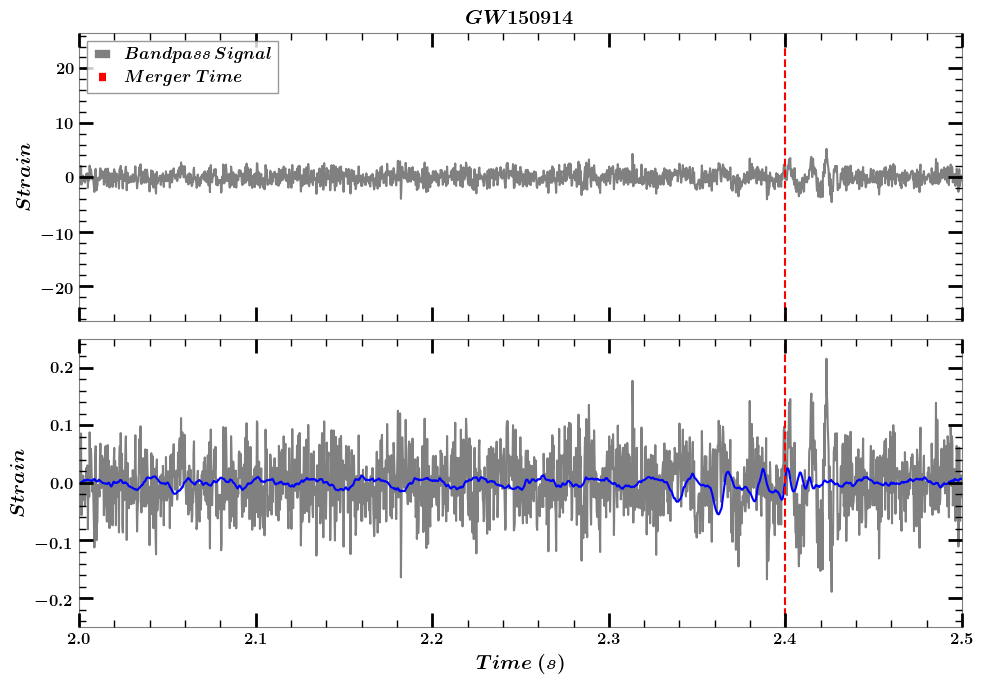

In [40]:
fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex = True)

t_ligo = np.linspace(0, 4, len(eve_sig_bp_whiten.times.value))
signal = eve_sig_bp_whiten.value

# First plot: Bandpass filtered signal
axs[0].plot(t_ligo, signal, color = "gray", label=r'$Bandpass$ $Signal$')
axs[0].axvline(x=2.4, color="red", linestyle="--", label=r'$Merger$ $Time$')
axs[0].set_title(r"$GW150914$")
axs[0].set_ylabel(r"$Strain$")
axs[0].set_xlim(1, 3)
axs[0].legend()
axs[0].grid(False)

# Second plot: Original and denoised signals
axs[1].plot(t_pred_eve, eve_test[:len(t_pred_eve)], color="gray")
axs[1].plot(t_pred_eve, pred_eve, color="blue")
axs[1].axvline(x=2.4, color="red", linestyle="--")

axs[1].set_xlabel(r"$Time$ $(s)$")
axs[1].set_ylabel(r"$Strain$")
# axs[1].legend()
axs[1].set_xlim(2, 2.5)
axs[1].set_ylim(-0.25, 0.25)
axs[1].grid(False)

# Adjust layout and show the plot
plt.tight_layout()
# plt.savefig(graph_dir + f"{event_name}_pred_noise.pdf")
plt.savefig(graph_dir_ae + f"/{event_name}_pred_noise.png")
plt.show()


# End of the Code